Found scenarios: gbc2025_7apr_base, gbc2025_7apr_upper


Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)




Land area by region (km²):


,region,land_area_km2
0,Europe (incl. Spice corridor),2.004120e+07
1,Roman Empire (broad),1.294069e+07
2,East Asia,1.303917e+07
3,Americas (populated core),3.229304e+07


Processing scenario: gbc2025_7apr_base


...

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)

Example usage:
    ds = xr.open_dataset(decode_times=time_coder)




Population density stats preview (mean ± std across scenarios):


,year,region,mean,std
0,0,Americas (populated core),0.795014,0.216822
1,0,East Asia,6.374560,1.738516
2,0,Europe (incl. Spice corridor),4.256409,1.160839
3,0,Roman Empire (broad),5.586027,1.523462
4,100,Americas (populated core),0.836164,0.221470
5,100,East Asia,5.772324,1.528885
6,100,Europe (incl. Spice corridor),4.455423,1.180086
7,100,Roman Empire (broad),5.885152,1.558770
8,200,Americas (populated core),0.879498,0.225882
9,200,East Asia,5.025152,1.290612



Agriculture proxy stats preview (mean ± std across scenarios):


,year,region,class,mean,std
0,0,Americas (populated core),CH₄-dominant agriculture (rice + ruminant graz...,2.727721,0.768528
1,0,Americas (populated core),CO₂-dominant agriculture (non-rice cropland),7.322678,1.997118
2,0,East Asia,CH₄-dominant agriculture (rice + ruminant graz...,30.557432,8.607288
3,0,East Asia,CO₂-dominant agriculture (non-rice cropland),50.734604,13.661116
4,0,Europe (incl. Spice corridor),CH₄-dominant agriculture (rice + ruminant graz...,82.136779,25.311572
5,0,Europe (incl. Spice corridor),CO₂-dominant agriculture (non-rice cropland),86.477708,23.319813
6,0,Roman Empire (broad),CH₄-dominant agriculture (rice + ruminant graz...,51.140361,16.475168
7,0,Roman Empire (broad),CO₂-dominant agriculture (non-rice cropland),75.244121,20.296239
8,100,Americas (populated core),CH₄-dominant agriculture (rice + ruminant graz...,2.902832,0.796782
9,100,Americas (populated core),CO₂-dominant agriculture (non-rice cropland),7.730496,2.047526


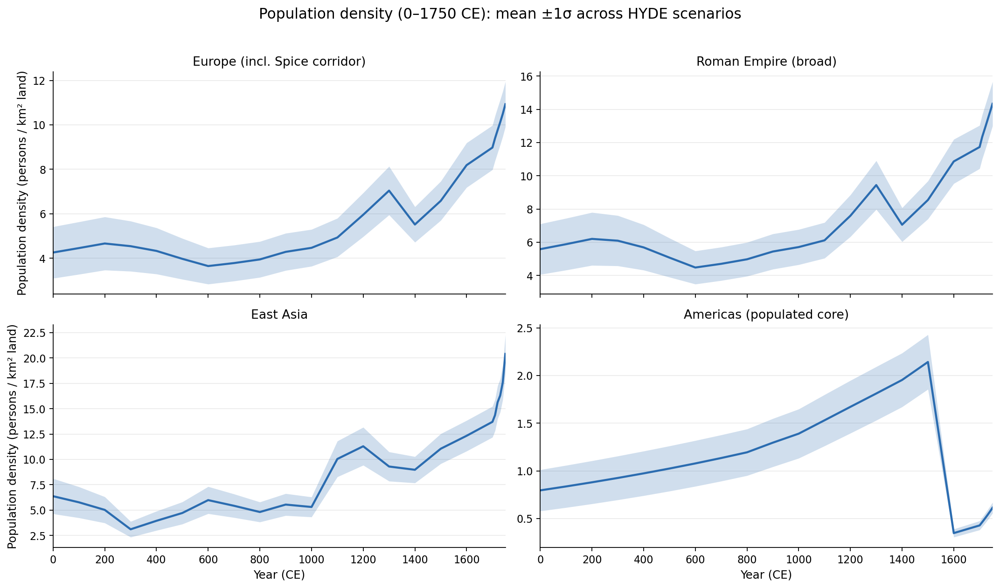

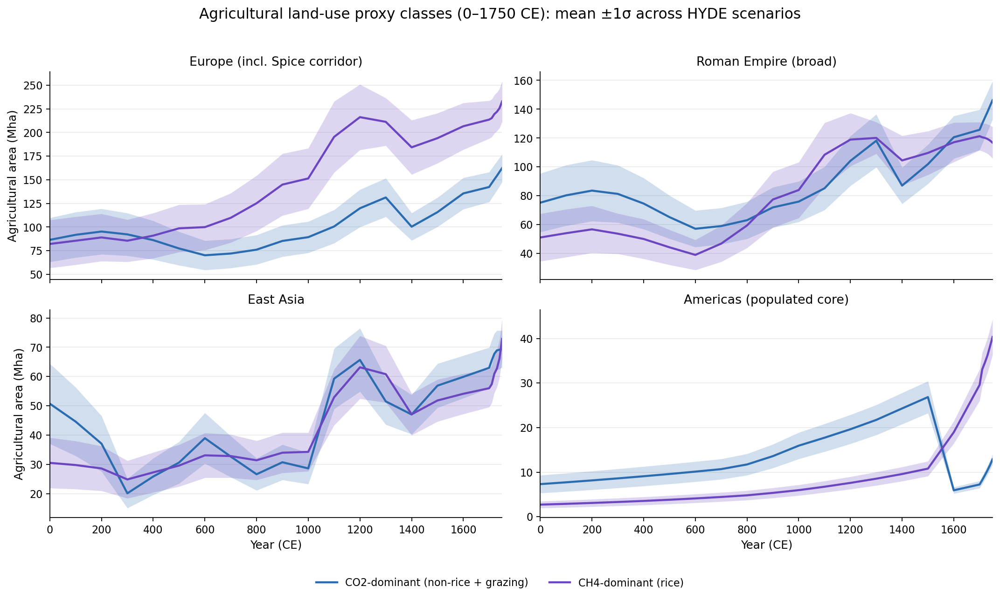

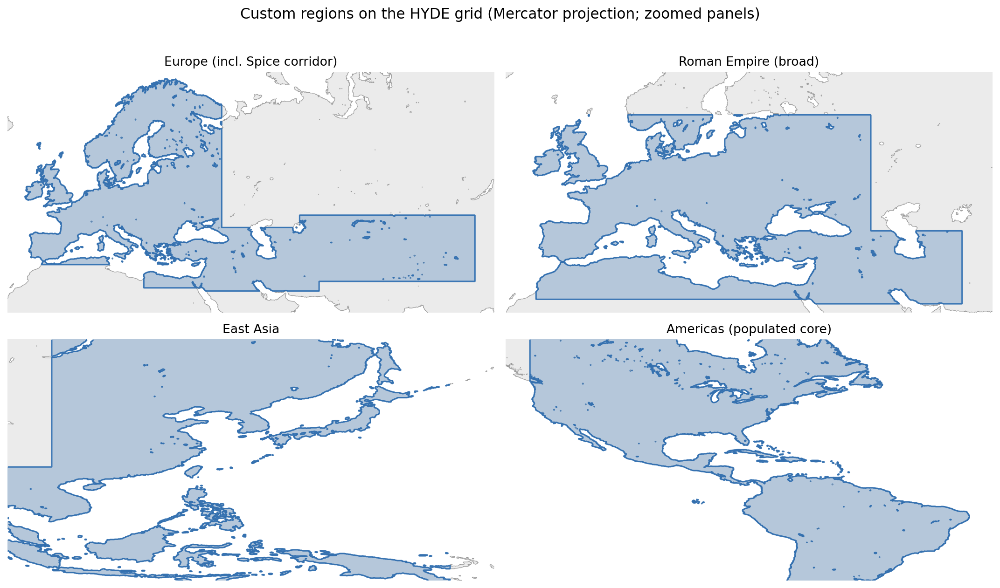

In [3]:
# HYDE 3.5 (0–1750 CE): Custom regions + population density + CO2/CH4 agriculture proxies + hi-res Mercator region maps
#
# HYDE 3.5 structure (per your listing):
#   - Scenarios: gbc2025_7apr_* (base/lower/upper) each with NetCDF/*.nc
#   - Masks:     general_files/general_files/garea_cr.asc, landlake.asc, etc.
#
# Regions (2x2 panels):
#   1) Europe (incl. Spice corridor)  <-- integrates spice route into Europe
#   2) Roman Empire (broad; includes Iraq+Iran; excludes Sahara + Arabia; overlaps allowed)
#   3) East Asia
#   4) Americas (populated core; excludes Alaska/northern Canada; excludes far south)
#
# Outputs:
#   - popdens_stats: mean/std across scenarios by year & region (persons/km² land)
#   - ag_stats: mean/std across scenarios by year, region & class (Mha)
#   - Figure A: population density (solid blue + shaded ±1σ)
#   - Figure B: ag proxy classes (blue=CO2-dominant, purple=CH4-dominant, shaded ±1σ)
#   - Figure C: hi-res Mercator region maps (HYDE grid, zoomed per region)
#
# Notes:
#   * CO2/CH4 "dominant" are PROXIES:
#       - rice area -> CH4-dominant proxy
#       - non-rice cropland + grazing -> CO2-dominant proxy
#     (Not a full GHG budget.)
#
# Dependencies: numpy, pandas, xarray, matplotlib
# No HYDE_country_codes.xlsx needed. No cartopy/geopandas needed.

from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ---- optional: Jupyter-friendly display fallback ----
try:
    from IPython.display import display  # type: ignore
except Exception:
    def display(x):
        print(x)

warnings.filterwarnings("ignore", category=UserWarning, module="xarray") 
# ----------------------------
# User config
# ----------------------------
START_YEAR = 0
END_YEAR = 1750

# Longitude (degE) where we conceptually split west-China corridor vs East Asia.
CHINA_SPLIT_LON = 105  # in [-180,180) logic space

REGION_ORDER = [
    "Europe (incl. Spice corridor)",
    "Roman Empire (broad)",
    "East Asia",
    "Americas (populated core)",
]

AG_CLASSES = [
    "CO₂-dominant agriculture (non-rice cropland)",
    "CH₄-dominant agriculture (rice + ruminant grazing proxy)",
]

# Styling (requested: solid blue/purple; shaded std; no top/right spines)
BLUE = "#2b6cb0"
PURPLE = "#6b46c1"
SHADE_ALPHA = 0.22

plt.rcParams.update({
    "figure.dpi": 160,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ----------------------------
# Scenario discovery (HYDE 3.5-aware)
# ----------------------------
def discover_scenarios(root: Path) -> List[Tuple[str, Path]]:
    """
    HYDE 3.5: scenario dirs like gbc2025_7apr_base, gbc2025_7apr_lower, gbc2025_7apr_upper
    We prefer those; fall back to HYDE 3.3 pattern; then fall back to any */NetCDF/population.nc.
    """
    root = Path(root)

    patterns = [
        "gbc*/NetCDF/population.nc",                 # HYDE 3.5-like
        "hyde33_c7_*_mrt2023/NetCDF/population.nc",  # HYDE 3.3 fallback
        "*/NetCDF/population.nc",                    # generic fallback
    ]

    pop_files: List[Path] = []
    for pat in patterns:
        pop_files = sorted(root.glob(pat))
        if pop_files:
            break

    out: List[Tuple[str, Path]] = []
    for pop_nc in pop_files:
        scen_dir = pop_nc.parent.parent
        label = scen_dir.name
        out.append((label, scen_dir))

    # Stable order: base, lower, upper if present; else alphabetical
    def sort_key(x: Tuple[str, Path]) -> Tuple[int, str]:
        nm = x[0].lower()
        if nm.endswith("base"):
            return (0, nm)
        if nm.endswith("lower"):
            return (1, nm)
        if nm.endswith("upper"):
            return (2, nm)
        return (3, nm)

    return sorted(out, key=sort_key)

# ----------------------------
# ESRI ASCII reader + alignment
# ----------------------------
def read_esri_ascii_grid(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing ASCII grid: {path}")

    header: Dict[str, float] = {}
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(6):
            line = f.readline()
            if not line:
                raise ValueError(f"Unexpected EOF reading header of {path}")
            k, v = line.strip().split()[:2]
            header[k.lower()] = float(v) if ("." in v or "e" in v.lower()) else int(v)
        data = np.loadtxt(f)

    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    cell = float(header["cellsize"])

    if data.shape != (nrows, ncols):
        raise ValueError(f"{path}: header says ({nrows},{ncols}) but data is {data.shape}")

    if "xllcorner" in header:
        xll = float(header["xllcorner"])
    elif "xllcenter" in header:
        xll = float(header["xllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing xllcorner/xllcenter")

    if "yllcorner" in header:
        yll = float(header["yllcorner"])
    elif "yllcenter" in header:
        yll = float(header["yllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing yllcorner/yllcenter")

    nodata = header.get("nodata_value", None)

    lon = xll + cell * (0.5 + np.arange(ncols))
    lat = yll + cell * (nrows - 0.5 - np.arange(nrows))  # north->south rows

    da = xr.DataArray(data, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name=path.stem)
    if nodata is not None:
        da = da.where(da != nodata)
    return da

def lon_to_180_values(lon_vals: np.ndarray) -> np.ndarray:
    lon_vals = np.asarray(lon_vals, dtype=float)
    return (((lon_vals + 180.0) % 360.0) - 180.0)

def normalize_longitudes_to_match(da: xr.DataArray, target_lon: xr.DataArray) -> xr.DataArray:
    """
    Normalize ASCII grid lon coords to match dataset lon convention (either -180..180 or 0..360).
    """
    da = da.copy()
    lon_da = np.asarray(da["lon"].values, dtype=float)
    lon_t = np.asarray(target_lon.values, dtype=float)
    tmin = float(np.nanmin(lon_t))

    # target in [0,360)
    if tmin >= 0 and np.nanmin(lon_da) < 0:
        da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon")

    # target in [-180,180)
    if tmin < 0 and np.nanmin(lon_da) >= 0:
        da = da.assign_coords(lon=lon_to_180_values(da["lon"].values)).sortby("lon")

    return da

def align_grid_to_dataset(da: xr.DataArray, ds_template: xr.Dataset) -> xr.DataArray:
    da2 = normalize_longitudes_to_match(da, ds_template["lon"])
    return da2.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")

# ============================
# Xarray open (fix use_cftime deprecation)
# ============================
def _get_cftime_decoder():
    """
    New xarray API: pass a CFDatetimeCoder via decode_times=...
    This avoids the 'use_cftime' deprecation warning.
    """
    try:
        return xr.coders.CFDatetimeCoder(use_cftime=True)
    except Exception:
        try:
            from xarray.coding.times import CFDatetimeCoder  # type: ignore
            return CFDatetimeCoder(use_cftime=True)
        except Exception:
            return True


CF_DECODER = _get_cftime_decoder()


def open_dataset_robust(path: Path) -> xr.Dataset:
    """
    Try several xarray engines and decode options; returns an OPEN dataset (caller must close()).
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(str(path))

    engines = [None, "netcdf4", "h5netcdf"]
    decode_opts = [CF_DECODER, False]  # cftime-capable decode first, then raw numbers
    chunk_opts = [{"time": 1}, None]

    last_err = None
    for eng in engines:
        for decode in decode_opts:
            for chunks in chunk_opts:
                try:
                    kwargs = {"cache": False, "decode_times": decode}
                    if chunks is not None:
                        kwargs["chunks"] = chunks
                    if eng is None:
                        return xr.open_dataset(path, **kwargs)
                    return xr.open_dataset(path, engine=eng, **kwargs)
                except Exception as e:
                    last_err = e
                    continue

    raise OSError(f"Failed to open {path}. Last error: {last_err}")


def pick_main_var(ds: xr.Dataset, path: Path, prefer_var: Optional[str] = None) -> xr.DataArray:
    data_vars = list(ds.data_vars)
    if not data_vars:
        raise ValueError(f"No data variables found in {path.name}")

    if prefer_var and prefer_var in ds.data_vars:
        return ds[prefer_var]

    if len(data_vars) == 1:
        return ds[data_vars[0]]

    stem = path.stem.lower()
    for v in data_vars:
        if stem in v.lower():
            return ds[v]

    return ds[data_vars[0]]

# ----------------------------
# Time/year handling
# ----------------------------
def coerce_year_index(da: xr.DataArray) -> xr.DataArray:
    """
    Add a 'year' coordinate; if possible, swap dims so 'year' is a dimension.
    Handles numpy datetime64, cftime objects, and numeric year axes.
    """
    if "year" in da.coords:
        t = da["year"]
    elif "time" in da.coords:
        t = da["time"]
    else:
        raise ValueError("No 'time' or 'year' coordinate found.")

    try:
        years = t.dt.year.astype(int).values
    except Exception:
        vals = np.asarray(t.values)
        if vals.size and hasattr(vals.flat[0], "year"):
            years = np.array([v.year for v in vals.ravel()], dtype=int).reshape(vals.shape)
        else:
            years = np.rint(vals.astype(float)).astype(int)

    dim = t.dims[0] if t.dims else None
    if dim is None:
        da = da.assign_coords(year=years)
    else:
        da = da.assign_coords(year=(dim, years))
        if dim != "year" and np.unique(years).size == years.size:
            da = da.swap_dims({dim: "year"})
    return da

def subset_years(da: xr.DataArray, start_year: int, end_year: int) -> xr.DataArray:
    da = coerce_year_index(da)
    if "year" in da.dims:
        da = da.sortby("year")
        return da.sel(year=slice(start_year, end_year))
    if "year" in da.coords:
        mask = (da["year"] >= start_year) & (da["year"] <= end_year)
        return da.where(mask, drop=True)
    raise ValueError("No 'year' coordinate could be constructed.")

# ----------------------------
# Locate general_files masks (HYDE3.5 nested path aware)
# ----------------------------
def find_first_existing(root: Path, rel_candidates: List[str]) -> Path:
    for rel in rel_candidates:
        p = root / rel
        if p.exists():
            return p
    raise FileNotFoundError("None of the candidate paths exist:\n" + "\n".join([str(root / r) for r in rel_candidates]))

def load_cell_area_km2(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    # HYDE3.5 has general_files/general_files/garea_cr.asc in your tree listing
    p = find_first_existing(root, [
        "general_files/garea_cr.asc",
        "general_files/general_files/garea_cr.asc",
        "general_files/garea.asc",
        "general_files/general_files/garea.asc",
    ])
    da = read_esri_ascii_grid(p)
    da = align_grid_to_dataset(da, ds_template)
    da.name = "cell_area_km2"
    return da

def load_land_mask_optional(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    p = None
    try:
        p = find_first_existing(root, [
            "general_files/landlake.asc",
            "general_files/general_files/landlake.asc",
        ])
    except FileNotFoundError:
        p = None

    if p is None:
        warnings.warn("landlake.asc not found. Treating all cells as land (this will bias densities).")
        lat = ds_template["lat"].values
        lon = ds_template["lon"].values
        return xr.DataArray(
            np.ones((lat.size, lon.size), dtype=float),
            dims=("lat", "lon"),
            coords={"lat": lat, "lon": lon},
            name="land_mask",
        )

    da = read_esri_ascii_grid(p)
    da = align_grid_to_dataset(da, ds_template)
    lm = xr.where(da > 0, 1.0, 0.0).fillna(0.0)
    lm.name = "land_mask"
    return lm

# ----------------------------
# Region masks (pure lat/lon logic; overlaps allowed)
# ----------------------------
def build_region_masks(ds_template: xr.Dataset, land_mask: xr.DataArray) -> xr.DataArray:
    """
    Returns DataArray (region, lat, lon) with 0/1 values.
    Overlaps are allowed by design (you requested overlaps are OK).
    Ocean removed via land_mask multiplication.
    """
    lat = ds_template["lat"]
    lon = ds_template["lon"]

    # Build a lon180 "data" array for box logic, but keep ORIGINAL lon coords for alignment
    lon180_vals = lon_to_180_values(lon.values)
    lon180 = xr.DataArray(lon180_vals, dims=("lon",), coords={"lon": lon.values}, name="lon180")

    LON180, LAT = xr.broadcast(lon180, lat)
    # normalize to (lat, lon)
    LON180 = LON180.transpose("lat", "lon")
    LAT = LAT.transpose("lat", "lon")

    def in_box(lon_min, lon_max, lat_min, lat_max):
        return (LON180 >= lon_min) & (LON180 <= lon_max) & (LAT >= lat_min) & (LAT <= lat_max)

    # --- Exclusions requested: Sahara + Arabian Peninsula ---
    # Sahara (rough): exclude belt south of Mediterranean coast (keeps coastal band >= ~28N)
    sahara = in_box(-17, 35, 15, 28)

    # Arabian Peninsula (rough): exclude most of it (keeps Iraq/Levant north of ~27N)
    arabia = in_box(34, 60, 12, 27)

    exclude = sahara | arabia

    # --- Core Europe ---
    europe_core = in_box(-12, 40, 35, 72)

    # --- Spice corridor (overland-ish proxy, avoids Sahara/Arabia) ---
    spice_near_east = in_box(20, 65, 27, 45)                 # Anatolia/Levant/Iraq/Iran band
    spice_central_asia = in_box(60, CHINA_SPLIT_LON, 30, 48)  # Central Asia to west-China corridor
    spice_corridor = spice_near_east | spice_central_asia

    # Integrate spice corridor into Europe (requested)
    europe_incl_spice = europe_core | spice_corridor

    # --- Roman Empire (broad heuristic; overlaps allowed) ---
    # Includes: W/C Europe + Mediterranean littoral + Anatolia/Levant + Iraq/Iran.
    roman_west = in_box(-12, 45, 35, 60)              # Spain/France/UK/Germany/Italy/etc
    roman_n_africa_coast = in_box(-10, 35, 28, 37)    # Mediterranean North Africa coast band
    roman_anatolia_levant = in_box(18, 45, 30, 45)    # Greece/Turkey/Levant
    roman_mesopotamia_iran = in_box(35, 60, 27, 42)   # Iraq + Iran (kept north of Arabia exclusion)
    roman = roman_west | roman_n_africa_coast | roman_anatolia_levant | roman_mesopotamia_iran

    # --- East Asia ---
    eastasia1 = in_box(CHINA_SPLIT_LON, 150, 15, 55)   # eastern China + Korea/Japan
    eastasia2 = in_box(90, 150, -10, 25)               # SE Asia belt
    eastasia = eastasia1 | eastasia2

    # --- Americas (populated core) ---
    americas = in_box(-125, -30, -35, 60)

    def finalize(mask_bool: xr.DataArray) -> xr.DataArray:
        m = mask_bool & (~exclude)
        m = xr.where(m, 1.0, 0.0)
        return (m * land_mask).astype(float)

    masks = xr.concat(
        [
            finalize(europe_incl_spice),
            finalize(roman),
            finalize(eastasia),
            finalize(americas),
        ],
        dim="region",
    )
    masks = masks.assign_coords(region=("region", REGION_ORDER))
    masks.name = "region_mask"
    return masks

# ----------------------------
# Region aggregation (memory-safe: loop over regions to avoid huge broadcast)
# ----------------------------
def region_sum(da: xr.DataArray, region_masks: xr.DataArray) -> xr.DataArray:
    """
    Returns (year, region) sum over lat/lon for each region mask.
    Does NOT create (year, region, lat, lon) intermediate.
    """
    sums = []
    for r in region_masks["region"].values:
        m = region_masks.sel(region=r)
        sums.append((da * m).sum(dim=("lat", "lon"), skipna=True))
    out = xr.concat(sums, dim="region").assign_coords(region=region_masks["region"].values)
    out = coerce_year_index(out)
    return out

def region_area_sum_km2(cell_area_km2: xr.DataArray, region_masks: xr.DataArray) -> xr.DataArray:
    areas = []
    for r in region_masks["region"].values:
        m = region_masks.sel(region=r)
        areas.append((cell_area_km2 * m).sum(dim=("lat", "lon"), skipna=True))
    out = xr.concat(areas, dim="region").assign_coords(region=region_masks["region"].values)
    out.name = "land_area_km2"
    return out.astype(float)

# ----------------------------
# Land-use conversion (to Mha) + regional totals
# ----------------------------
def _string_attr(da: xr.DataArray, key: str) -> str:
    return str(da.attrs.get(key, "")).strip().lower()

def _sample_for_fraction_test(da: xr.DataArray) -> Optional[np.ndarray]:
    idx = {}
    if "year" in da.dims:
        idx["year"] = 0
    elif "time" in da.dims:
        idx["time"] = 0
    else:
        return None
    if "lat" in da.dims:
        idx["lat"] = slice(0, min(da.sizes["lat"], 60))
    if "lon" in da.dims:
        idx["lon"] = slice(0, min(da.sizes["lon"], 60))
    try:
        return np.asarray(da.isel(idx).values)
    except Exception:
        return None

def _looks_like_fraction(da: xr.DataArray) -> bool:
    units = _string_attr(da, "units")
    long_name = (_string_attr(da, "long_name") + " " + _string_attr(da, "standard_name")).strip()

    if ("frac" in units) or ("fraction" in units) or ("fraction" in long_name):
        return True

    if units in ("", "1", "-"):
        samp = _sample_for_fraction_test(da)
        if samp is not None:
            vmin = float(np.nanmin(samp))
            vmax = float(np.nanmax(samp))
            if vmin >= -1e-6 and vmax <= 1.5:
                return True
    return False

def landuse_regional_mha(
    nc_path: Path,
    region_masks: xr.DataArray,   # (region,lat,lon) 0/1
    cell_area_km2: xr.DataArray,  # (lat,lon)
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    """
    Returns DataArray (year, region) in Mha, or None if file missing/unreadable.
    Computes + loads small result, then closes dataset.
    """
    if not nc_path.exists():
        return None

    ds = None
    try:
        ds = open_dataset_robust(nc_path)
        da = pick_main_var(ds, nc_path)
        da = subset_years(da, start_year, end_year)

        units = _string_attr(da, "units")
        frac = _looks_like_fraction(da)

        if frac:
            # fraction * km² -> km²; /1e4 -> Mha
            da_mha = (da * cell_area_km2) / 1e4
        else:
            # assume area-like and convert to Mha
            if "km" in units and ("2" in units or "^2" in units):
                da_mha = da / 1e4
            elif units in ("ha", "hectare", "hectares"):
                da_mha = da / 1e6
            elif "m" in units and ("2" in units or "^2" in units):
                da_mha = da / 1e10
            else:
                # common HYDE case: km² but units missing
                warnings.warn(f"{nc_path.name}: Unrecognized units '{da.attrs.get('units','')}'. Assuming km² -> Mha via /1e4.")
                da_mha = da / 1e4

        reg = region_sum(da_mha.rename("area_mha"), region_masks)
        reg.attrs["units"] = "Mha"
        return reg.load()

    except Exception as e:
        warnings.warn(f"Skipping unreadable NetCDF: {nc_path.name} | {e}")
        return None
    finally:
        if ds is not None:
            try:
                ds.close()
            except Exception:
                pass

# ----------------------------
# Population density (persons/km² land)
# ----------------------------
def population_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> xr.DataArray:
    ds = None
    try:
        ds = open_dataset_robust(nc_path)
        da = pick_main_var(ds, nc_path)
        da = subset_years(da, start_year, end_year)
        reg = region_sum(da.rename("population"), region_masks)
        reg.attrs["units"] = "persons"
        return reg.load()
    finally:
        if ds is not None:
            try:
                ds.close()
            except Exception:
                pass

# ----------------------------
# Plot helpers
# ----------------------------
def style_timeseries_ax(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)

def plot_mean_sigma(ax, x, mean, std, color, label=None):
    ax.plot(x, mean, color=color, linewidth=2.0, label=label)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=SHADE_ALPHA, linewidth=0)

# Mercator helpers (no cartopy)
def mercator_y(lat_deg: np.ndarray) -> np.ndarray:
    lat = np.asarray(lat_deg, dtype=float)
    lat = np.clip(lat, -85.0, 85.0)
    phi = np.deg2rad(lat)
    return np.log(np.tan(np.pi / 4.0 + phi / 2.0))

def coord_edges_1d(coord: np.ndarray) -> np.ndarray:
    c = np.asarray(coord, dtype=float)
    if c.size < 2:
        raise ValueError("Need at least 2 points to compute edges.")
    d = np.diff(c)
    first = c[0] - d[0] / 2.0
    last = c[-1] + d[-1] / 2.0
    mid = c[:-1] + d / 2.0
    return np.concatenate([[first], mid, [last]])

def to_lon180_sorted(da: xr.DataArray) -> xr.DataArray:
    lon180 = lon_to_180_values(da["lon"].values)
    return da.assign_coords(lon=lon180).sortby("lon")

def sel_box_latlon(da: xr.DataArray, lon_min: float, lon_max: float, lat_min: float, lat_max: float) -> xr.DataArray:
    # lat slice robust to coordinate order, then sort ascending for pcolormesh
    lat = da["lat"].values
    if lat[0] < lat[-1]:
        da2 = da.sel(lat=slice(lat_min, lat_max))
    else:
        da2 = da.sel(lat=slice(lat_max, lat_min))
    da2 = da2.sel(lon=slice(lon_min, lon_max))
    return da2.sortby("lat")

# ----------------------------
# Main execution
# ----------------------------
ROOT = Path(".").resolve()
scenarios = discover_scenarios(ROOT)
if not scenarios:
    raise RuntimeError(
        "No HYDE scenario folders found.\n"
        "Expected HYDE 3.5 pattern like gbc2025_7apr_base/NetCDF/population.nc"
    )

print("Found scenarios:", ", ".join([s for s, _ in scenarios]))

# Use the first scenario as grid template
template_label, template_dir = scenarios[0]
template_pop = template_dir / "NetCDF" / "population.nc"

ds_template = open_dataset_robust(template_pop)
try:
    cell_area_km2 = load_cell_area_km2(ROOT, ds_template)      # (lat,lon)
    land_mask = load_land_mask_optional(ROOT, ds_template)     # (lat,lon)
    region_masks = build_region_masks(ds_template, land_mask)  # (region,lat,lon)
finally:
    ds_template.close()

# Land area per region (km²) for density denominators
land_area_reg_km2 = region_area_sum_km2(cell_area_km2, region_masks)
land_area_df = land_area_reg_km2.to_dataframe().reset_index()
print("\nLand area by region (km²):")
display(land_area_df)

# Collect per-scenario time series
pop_rows = []
ag_rows = []

def std0(x: pd.Series) -> float:
    return float(np.std(x.to_numpy(dtype=float), ddof=0))

for scen_label, scen_dir in scenarios:
    print(f"Processing scenario: {scen_label}")

    # --- Population density ---
    pop_path = scen_dir / "NetCDF" / "population.nc"
    try:
        pop_reg = population_regional_persons(pop_path, region_masks, START_YEAR, END_YEAR)  # (year, region)
    except Exception as e:
        warnings.warn(f"{scen_label}: population.nc failed ({e}). Skipping scenario.")
        continue

    dens = pop_reg / xr.where(land_area_reg_km2 > 0, land_area_reg_km2, np.nan)
    dens = dens.rename("pop_density_p_km2")

    dens_df = dens.to_dataframe(name="pop_density_p_km2").reset_index()
    dens_df["scenario"] = scen_label
    dens_df = dens_df[["scenario", "year", "region", "pop_density_p_km2"]]
    pop_rows.append(dens_df)

    # --- Agriculture proxy classes (more careful CO2 vs CH4) ---

    # ========== CH4 component 1: rice (paddy proxy) ==========
    rice_rf = landuse_regional_mha(
        scen_dir / "NetCDF" / "rainfed_rice.nc",
        region_masks, cell_area_km2, START_YEAR, END_YEAR
    )
    rice_ir = landuse_regional_mha(
        scen_dir / "NetCDF" / "irrigated_rice.nc",
        region_masks, cell_area_km2, START_YEAR, END_YEAR
    )

    if (rice_rf is not None) or (rice_ir is not None):
        rice_reg = (0 if rice_rf is None else rice_rf.fillna(0)) + (0 if rice_ir is None else rice_ir.fillna(0))
    else:
        rice_reg = landuse_regional_mha(
            scen_dir / "NetCDF" / "total_rice.nc",
            region_masks, cell_area_km2, START_YEAR, END_YEAR
        )

    # ========== CO2 component: non-rice cropland ==========
    nr_rf = landuse_regional_mha(
        scen_dir / "NetCDF" / "rainfed_not_rice.nc",
        region_masks, cell_area_km2, START_YEAR, END_YEAR
    )
    nr_ir = landuse_regional_mha(
        scen_dir / "NetCDF" / "irrigated_not_rice.nc",
        region_masks, cell_area_km2, START_YEAR, END_YEAR
    )

    if (nr_rf is not None) or (nr_ir is not None):
        cropland_nonrice_reg = (0 if nr_rf is None else nr_rf.fillna(0)) + (0 if nr_ir is None else nr_ir.fillna(0))
    else:
        # fallback: cropland total - rice (if rice exists)
        cropt = landuse_regional_mha(
            scen_dir / "NetCDF" / "cropland.nc",
            region_masks, cell_area_km2, START_YEAR, END_YEAR
        )
        if cropt is not None and rice_reg is not None:
            cropland_nonrice_reg = (cropt - rice_reg.fillna(0)).clip(min=0)
            warnings.warn(f"{scen_dir.name}: Using cropland.nc minus rice as non-rice cropland fallback.")
        else:
            cropland_nonrice_reg = cropt
            if cropt is not None:
                warnings.warn(f"{scen_dir.name}: Using cropland.nc as non-rice cropland fallback (rice unavailable).")

    # ========== CH4 component 2: ruminant grazing proxy ==========
    # Prefer pasture + rangeland (avoids any ambiguity about grazing_land double counting)
    pasture_reg = landuse_regional_mha(
        scen_dir / "NetCDF" / "pasture.nc",
        region_masks, cell_area_km2, START_YEAR, END_YEAR
    )
    rangeland_reg = landuse_regional_mha(
        scen_dir / "NetCDF" / "rangeland.nc",
        region_masks, cell_area_km2, START_YEAR, END_YEAR
    )

    if (pasture_reg is not None) or (rangeland_reg is not None):
        ruminant_reg = (0 if pasture_reg is None else pasture_reg.fillna(0)) + (0 if rangeland_reg is None else rangeland_reg.fillna(0))
    else:
        # fallback: total grazing land
        ruminant_reg = landuse_regional_mha(
            scen_dir / "NetCDF" / "grazing_land.nc",
            region_masks, cell_area_km2, START_YEAR, END_YEAR
        )

    # ========== Build the TWO final classes ==========
    # CO2-dominant: non-rice cropland (area in Mha)
    if cropland_nonrice_reg is not None:
        co2_reg = coerce_year_index(cropland_nonrice_reg)
        df = co2_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = AG_CLASSES[0]
        df = df[["scenario", "year", "region", "class", "area_mha"]]
        ag_rows.append(df)

    # CH4-dominant: rice + ruminant grazing proxy (area in Mha)
    if (rice_reg is not None) or (ruminant_reg is not None):
        r = 0 if rice_reg is None else rice_reg.fillna(0)
        g = 0 if ruminant_reg is None else ruminant_reg.fillna(0)
        ch4_reg = coerce_year_index(r + g)

        df = ch4_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = AG_CLASSES[1]
        df = df[["scenario", "year", "region", "class", "area_mha"]]
        ag_rows.append(df)

# Combine + stats across scenarios
pop_all = pd.concat(pop_rows, ignore_index=True) if pop_rows else pd.DataFrame(columns=["scenario","year","region","pop_density_p_km2"])
ag_all = pd.concat(ag_rows, ignore_index=True) if ag_rows else pd.DataFrame(columns=["scenario","year","region","class","area_mha"])

popdens_stats = (
    pop_all.groupby(["year", "region"], as_index=False)
    .agg(mean=("pop_density_p_km2", "mean"), std=("pop_density_p_km2", std0))
)

ag_stats = (
    ag_all.groupby(["year", "region", "class"], as_index=False)
    .agg(mean=("area_mha", "mean"), std=("area_mha", std0))
)

print("\nPopulation density stats preview (mean ± std across scenarios):")
display(popdens_stats.head(12))

print("\nAgriculture proxy stats preview (mean ± std across scenarios):")
display(ag_stats.head(12))

# ----------------------------
# Figure A: Population density 2x2
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)

    if df.empty:
        continue

    x = df["year"].to_numpy()
    m = df["mean"].to_numpy(dtype=float)
    s = df["std"].to_numpy(dtype=float)
    plot_mean_sigma(ax, x, m, s, color=BLUE)

axs[0].set_ylabel("Population density (persons / km² land)")
axs[2].set_ylabel("Population density (persons / km² land)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")

fig.suptitle("Population density (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# Figure B: Agriculture proxy classes 2x2
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)

    df_r = ag_stats[ag_stats["region"] == region]
    if df_r.empty:
        continue

    d1 = df_r[df_r["class"] == AG_CLASSES[0]].sort_values("year")
    if not d1.empty:
        plot_mean_sigma(
            ax,
            d1["year"].to_numpy(),
            d1["mean"].to_numpy(dtype=float),
            d1["std"].to_numpy(dtype=float),
            color=BLUE,
            label="CO2-dominant (non-rice + grazing)" if i == 0 else None,
        )

    d2 = df_r[df_r["class"] == AG_CLASSES[1]].sort_values("year")
    if not d2.empty:
        plot_mean_sigma(
            ax,
            d2["year"].to_numpy(),
            d2["mean"].to_numpy(dtype=float),
            d2["std"].to_numpy(dtype=float),
            color=PURPLE,
            label="CH4-dominant (rice)" if i == 0 else None,
        )

axs[0].set_ylabel("Agricultural area (Mha)")
axs[2].set_ylabel("Agricultural area (Mha)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")

handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Agricultural land-use proxy classes (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

# ----------------------------
# Figure C: Hi-res Mercator maps (2x2)
# ----------------------------
MAP_EXTENTS = {
    "Europe (incl. Spice corridor)": (-15, CHINA_SPLIT_LON + 5, 20, 72),
    "Roman Empire (broad)": (-15, 65, 25, 65),   # extended eastward to include Iraq/Iran
    "East Asia": (CHINA_SPLIT_LON - 5, 155, -10, 55),
    "Americas (populated core)": (-130, -30, -35, 60),
}

land_plot = to_lon180_sorted(land_mask)
region_plot = to_lon180_sorted(region_masks)

land_cmap = ListedColormap([(1, 1, 1, 0), (0, 0, 0, 0.08)])            # transparent water, faint land
region_cmap = ListedColormap([(0, 0, 0, 0), (0.17, 0.42, 0.69, 0.28)])  # transparent, blue fill

fig, axs = plt.subplots(2, 2, figsize=(13.5, 8))
axs = axs.ravel()

for i, region_name in enumerate(REGION_ORDER):
    ax = axs[i]
    lon_min, lon_max, lat_min, lat_max = MAP_EXTENTS[region_name]

    land_sub = sel_box_latlon(land_plot, lon_min, lon_max, lat_min, lat_max)
    reg_sub = sel_box_latlon(region_plot.sel(region=region_name), lon_min, lon_max, lat_min, lat_max)

    lon = land_sub["lon"].values
    lat = land_sub["lat"].values

    lon_e = coord_edges_1d(lon)
    lat_e = coord_edges_1d(lat)
    y_e = mercator_y(lat_e)
    y = mercator_y(lat)

    ax.pcolormesh(lon_e, y_e, (land_sub.values > 0).astype(float), shading="auto", cmap=land_cmap)
    ax.pcolormesh(lon_e, y_e, reg_sub.values.astype(float), shading="auto", cmap=region_cmap)

    # coastline proxy
    try:
        ax.contour(lon, y, (land_sub.values > 0).astype(float), levels=[0.5], colors="black",
                   linewidths=0.6, alpha=0.35)
    except Exception:
        pass

    # region outline
    try:
        ax.contour(lon, y, reg_sub.values.astype(float), levels=[0.5], colors=BLUE,
                   linewidths=1.4, alpha=0.9)
    except Exception:
        pass

    ax.set_title(region_name)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(mercator_y(lat_min), mercator_y(lat_max))

    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig.suptitle("Custom regions on the HYDE grid (Mercator projection; zoomed panels)", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# Optional: save outputs
# ----------------------------
# pop_all.to_csv("hyde35_pop_density_by_scenario_0_1750.csv", index=False)
# popdens_stats.to_csv("hyde35_pop_density_mean_std_0_1750.csv", index=False)
# ag_all.to_csv("hyde35_ag_proxy_by_scenario_0_1750.csv", index=False)
# ag_stats.to_csv("hyde35_ag_proxy_mean_std_0_1750.csv", index=False)
# fig.savefig("hyde35_regions_mercator.png", dpi=300, bbox_inches="tight")


Found scenarios: base:gbc2025_7apr_base, upper:gbc2025_7apr_upper

Land area by region (km²):


,region,land_area_km2
0,Europe (incl. Spice corridor),NaN
1,Roman Empire (historic-ish),NaN
2,East Asia (incl. all China),NaN
3,Americas (populated core),NaN


Processing: base (gbc2025_7apr_base)
Processing: upper (gbc2025_7apr_upper)

Population density stats preview:


,year,region,mean,std
0,0,Americas (populated core),NaN,NaN
1,0,East Asia (incl. all China),NaN,NaN
2,0,Europe (incl. Spice corridor),NaN,NaN
3,0,Roman Empire (historic-ish),NaN,NaN
4,100,Americas (populated core),NaN,NaN
5,100,East Asia (incl. all China),NaN,NaN
6,100,Europe (incl. Spice corridor),NaN,NaN
7,100,Roman Empire (historic-ish),NaN,NaN
8,200,Americas (populated core),NaN,NaN
9,200,East Asia (incl. all China),NaN,NaN



Ag proxy stats preview:


,year,region,class,mean,std
0,0,Americas (populated core),CH₄ proxy: rice + grazing/pasture,0.0,0.0
1,0,Americas (populated core),CO₂ proxy: non-rice cropland,0.0,0.0
2,0,East Asia (incl. all China),CH₄ proxy: rice + grazing/pasture,0.0,0.0
3,0,East Asia (incl. all China),CO₂ proxy: non-rice cropland,0.0,0.0
4,0,Europe (incl. Spice corridor),CH₄ proxy: rice + grazing/pasture,0.0,0.0
5,0,Europe (incl. Spice corridor),CO₂ proxy: non-rice cropland,0.0,0.0
6,0,Roman Empire (historic-ish),CH₄ proxy: rice + grazing/pasture,0.0,0.0
7,0,Roman Empire (historic-ish),CO₂ proxy: non-rice cropland,0.0,0.0
8,100,Americas (populated core),CH₄ proxy: rice + grazing/pasture,0.0,0.0
9,100,Americas (populated core),CO₂ proxy: non-rice cropland,0.0,0.0


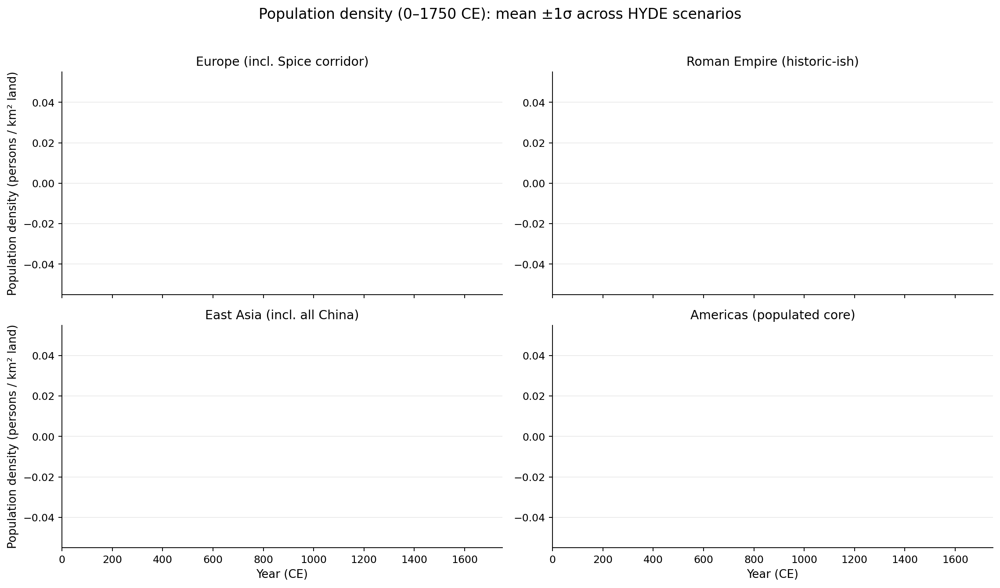

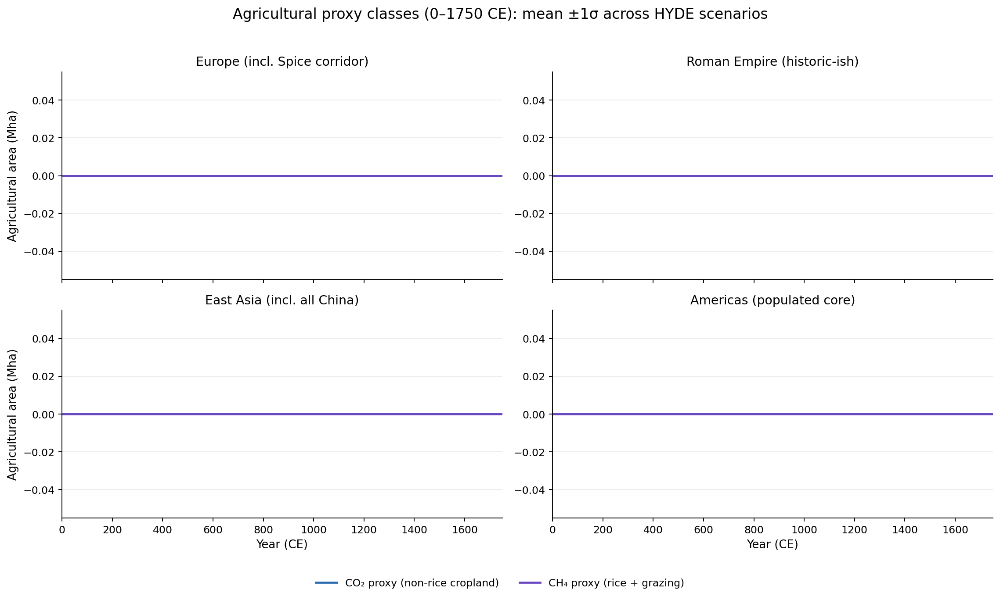

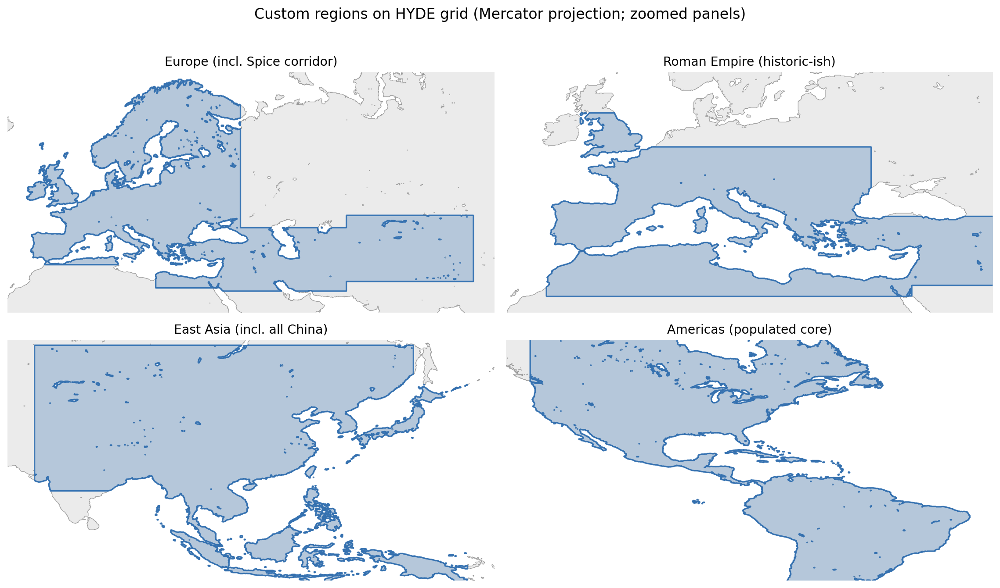

Found scenarios: base:gbc2025_7apr_base, upper:gbc2025_7apr_upper
Template lon range: -179.958 .. 179.958
Template lat range: -89.958 .. 89.958

Land area by region (km²) — if ~0, masks are not aligning (lon-convention bug):


,region,land_area_km2
0,Europe (incl. Spice corridor),2.004120e+07
1,Roman Empire (approx.),9.509715e+06
2,East Asia (incl. China),1.711765e+07
3,Americas (populated core),3.229304e+07


Processing scenario: base (gbc2025_7apr_base)
Processing scenario: upper (gbc2025_7apr_upper)

Population density stats preview:


,year,region,mean,std
0,0,Americas (populated core),0.795014,0.216822
1,0,East Asia (incl. China),5.348555,1.458697
2,0,Europe (incl. Spice corridor),4.256409,1.160839
3,0,Roman Empire (approx.),6.988627,1.905990
4,100,Americas (populated core),0.836164,0.221470
5,100,East Asia (incl. China),4.842544,1.282620
6,100,Europe (incl. Spice corridor),4.455423,1.180086
7,100,Roman Empire (approx.),7.353478,1.947679
8,200,Americas (populated core),0.879498,0.225882
9,200,East Asia (incl. China),4.215442,1.082655



Agriculture proxy stats preview:


,year,region,class,mean,std
0,0,Americas (populated core),CH₄ biogenic proxy (rice + grazing/ruminants),4.343434,1.184569
1,0,Americas (populated core),CO₂ land-use proxy (non-rice cropland),7.322678,1.997118
2,0,East Asia (incl. China),CH₄ biogenic proxy (rice + grazing/ruminants),72.342833,19.739233
3,0,East Asia (incl. China),CO₂ land-use proxy (non-rice cropland),55.149188,14.823645
4,0,Europe (incl. Spice corridor),CH₄ biogenic proxy (rice + grazing/ruminants),111.148464,29.948450
5,0,Europe (incl. Spice corridor),CO₂ land-use proxy (non-rice cropland),86.477708,23.319813
6,0,Roman Empire (approx.),CH₄ biogenic proxy (rice + grazing/ruminants),80.805855,21.387596
7,0,Roman Empire (approx.),CO₂ land-use proxy (non-rice cropland),68.143565,18.367006
8,100,Americas (populated core),CH₄ biogenic proxy (rice + grazing/ruminants),4.611675,1.221468
9,100,Americas (populated core),CO₂ land-use proxy (non-rice cropland),7.730496,2.047526


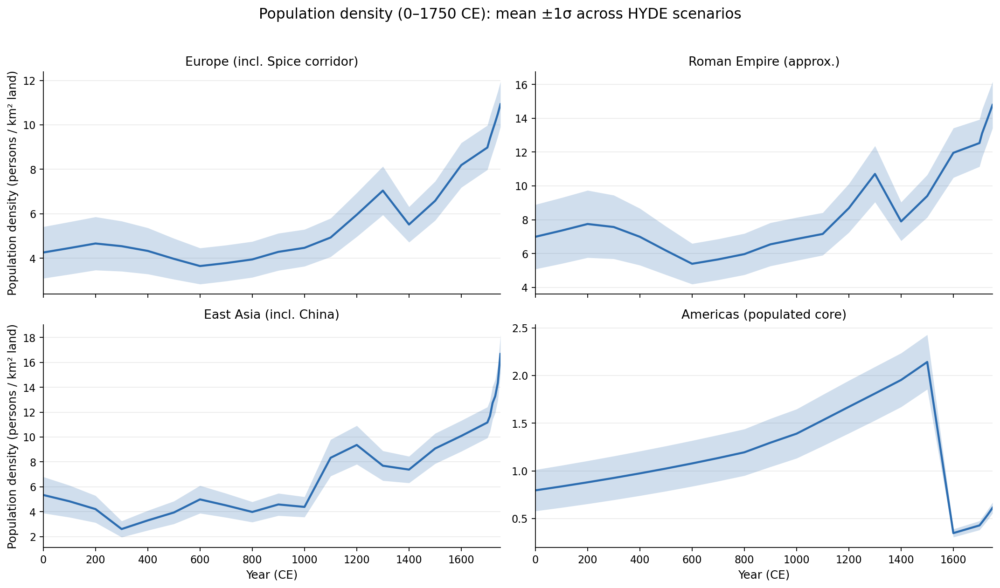

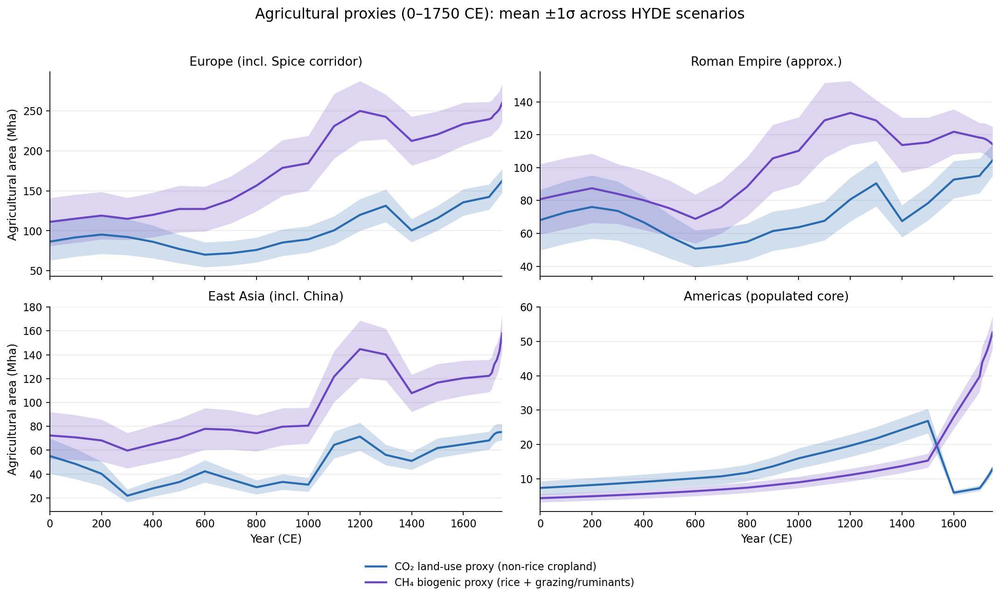

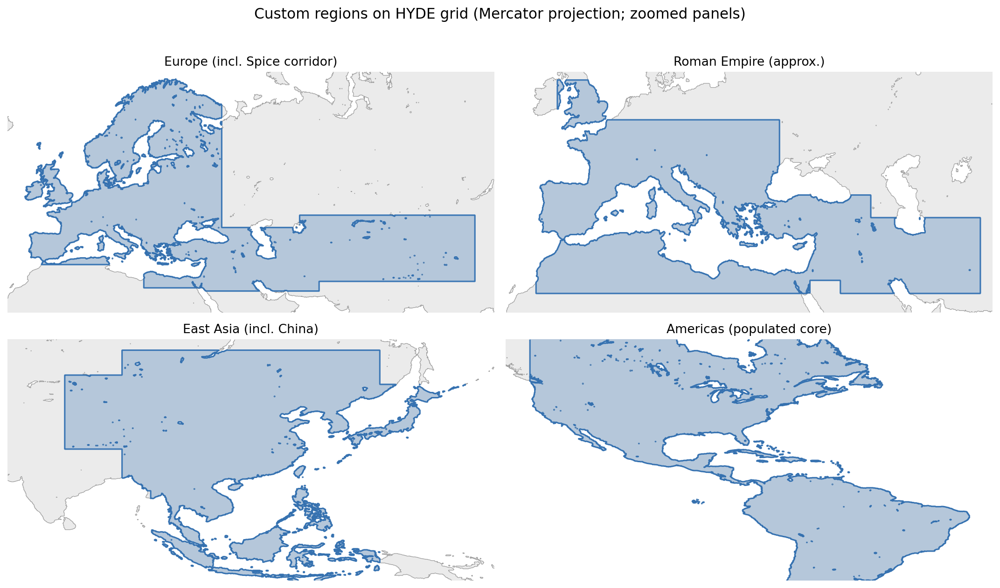

In [5]:
# HYDE 3.5 (0–1750 CE): Custom regions + population density + CH4/CO2 agriculture proxies + Mercator region maps
#
# Fixes vs previous versions:
#   - HYDE 3.5 folder structure (e.g., gbc2025_7apr_base/lower/upper)
#   - general_files path in HYDE 3.5 is nested: general_files/general_files/*.asc
#   - removes xarray DeprecationWarning: no use_cftime kwarg; uses CFDatetimeCoder in decode_times
#   - fixes the common “all-NaN/empty outputs” issue when lon is 0..360:
#       comparisons use lon converted to [-180,180) **as data**, while keeping original lon coordinates
#       so masks align with NetCDF arrays on multiplication.
#
# Regions (2x2 panels):
#   1) Europe (incl. Spice corridor)
#   2) Roman Empire (approx., closer: below Rhine; England+Wales only; no Ireland/Scotland; no Sahara/Arabia)
#   3) East Asia (incl. populated China)
#   4) Americas (populated core; excludes Alaska/northern Canada; excludes Patagonia)
#
# Agriculture proxy classes (two):
#   - CO2-land-use proxy  = non-rice cropland (rainfed_not_rice + irrigated_not_rice; fallback cropland - rice)
#   - CH4-biogenic proxy  = rice + grazing land (ruminants proxy: grazing_land or pasture+rangeland)
#
# Outputs:
#   - popdens_stats: mean/std across scenarios by year & region (persons / km² land)
#   - ag_stats: mean/std across scenarios by year, region & class (Mha)
#   - Figure A: 2x2 population density (solid blue + shaded ±1σ)
#   - Figure B: 2x2 agriculture proxies (blue=CO2 proxy, purple=CH4 proxy + shaded ±1σ)
#   - Figure C: 2x2 Mercator region maps (HYDE grid “hi-res”)
#
# Dependencies: numpy, pandas, xarray, matplotlib

from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

try:
    from IPython.display import display  # noqa: F401
except Exception:
    def display(x):  # type: ignore
        print(x)

# ----------------------------
# User config
# ----------------------------
START_YEAR = 0
END_YEAR = 1750

# Used only for the *Europe spice corridor* extent and map zoom.
SPICE_LON_MAX = 105  # degrees East in [-180,180) convention

REGION_ORDER = [
    "Europe (incl. Spice corridor)",
    "Roman Empire (approx.)",
    "East Asia (incl. China)",
    "Americas (populated core)",
]

CLASS_CO2 = "CO₂ land-use proxy (non-rice cropland)"
CLASS_CH4 = "CH₄ biogenic proxy (rice + grazing/ruminants)"

# Styling (requested: solid blue/purple; shaded std; no top/right spines)
BLUE = "#2b6cb0"
PURPLE = "#6b46c1"
SHADE_ALPHA = 0.22

plt.rcParams.update({
    "figure.dpi": 160,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ----------------------------
# Robust helpers: file discovery (HYDE 3.5 nested general_files)
# ----------------------------
def _first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p.exists():
            return p
    return None

def find_general_file(root: Path, filename: str) -> Path:
    """
    HYDE 3.5 often stores ASCII grids under:
      root/general_files/general_files/<filename>
    but sometimes also under:
      root/general_files/<filename>
    """
    candidates = [
        root / "general_files" / "general_files" / filename,
        root / "general_files" / filename,
        root / filename,
    ]
    hit = _first_existing(candidates)
    if hit:
        return hit

    # Last resort: a limited search under general_files (faster than root.rglob on big trees)
    gf = root / "general_files"
    if gf.exists():
        hits = list(gf.rglob(filename))
        if hits:
            return hits[0]

    # Absolute last resort: global search (can be slow)
    hits = list(root.rglob(filename))
    if hits:
        return hits[0]

    raise FileNotFoundError(f"Could not find '{filename}' under {root} (looked in common HYDE 3.5 locations).")

# ----------------------------
# Scenario discovery (HYDE 3.5 and older)
# ----------------------------
def discover_scenarios(root: Path) -> List[Tuple[str, Path]]:
    """
    Find scenario folders by locating */NetCDF/population.nc.
    Works for HYDE 3.5 (gbc2025_...) and older hyde33_... layouts.
    """
    pop_files = sorted(root.glob("*/NetCDF/population.nc"))
    out: List[Tuple[str, Path]] = []
    for pop_nc in pop_files:
        scen_dir = pop_nc.parent.parent
        label = scen_dir.name

        # Make labels prettier if possible
        m = re.search(r"(base|lower|upper)", label, flags=re.IGNORECASE)
        if m:
            label = m.group(1).lower()

        out.append((label, scen_dir))

    # Stable ordering: base, lower, upper, then others
    order = {"base": 0, "lower": 1, "upper": 2}
    out.sort(key=lambda t: (order.get(t[0], 99), t[0]))
    return out

# ----------------------------
# Standardize lat/lon naming (defensive)
# ----------------------------
def ensure_latlon(ds: xr.Dataset) -> xr.Dataset:
    rename: Dict[str, str] = {}
    for name in list(ds.dims) + list(ds.coords):
        low = name.lower()
        if low in ("latitude", "nav_lat", "y") and "lat" not in ds.dims and "lat" not in ds.coords:
            rename[name] = "lat"
        if low in ("longitude", "nav_lon", "x") and "lon" not in ds.dims and "lon" not in ds.coords:
            rename[name] = "lon"
    if rename:
        ds = ds.rename(rename)
    if "lat" not in ds.coords:
        if "lat" in ds.dims:
            ds = ds.assign_coords(lat=ds["lat"])
        else:
            raise ValueError(f"Dataset missing a 'lat' coordinate/dimension. Found dims={ds.dims}, coords={list(ds.coords)}")
    if "lon" not in ds.coords:
        if "lon" in ds.dims:
            ds = ds.assign_coords(lon=ds["lon"])
        else:
            raise ValueError(f"Dataset missing a 'lon' coordinate/dimension. Found dims={ds.dims}, coords={list(ds.coords)}")
    return ds

# ----------------------------
# ESRI ASCII reader + alignment
# ----------------------------
def read_esri_ascii_grid(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing ASCII grid: {path}")

    header: Dict[str, float] = {}
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(6):
            line = f.readline()
            if not line:
                raise ValueError(f"Unexpected EOF reading header of {path}")
            k, v = line.strip().split()[:2]
            header[k.lower()] = float(v) if ("." in v or "e" in v.lower()) else int(v)
        data = np.loadtxt(f)

    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    cell = float(header["cellsize"])

    if data.shape != (nrows, ncols):
        raise ValueError(f"{path}: header says ({nrows},{ncols}) but data is {data.shape}")

    if "xllcorner" in header:
        xll = float(header["xllcorner"])
    elif "xllcenter" in header:
        xll = float(header["xllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing xllcorner/xllcenter")

    if "yllcorner" in header:
        yll = float(header["yllcorner"])
    elif "yllcenter" in header:
        yll = float(header["yllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing yllcorner/yllcenter")

    nodata = header.get("nodata_value", None)

    lon = xll + cell * (0.5 + np.arange(ncols))
    lat = yll + cell * (nrows - 0.5 - np.arange(nrows))  # north->south

    da = xr.DataArray(data, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name=path.stem)
    if nodata is not None:
        da = da.where(da != nodata)
    return da

def _lon_to_180_vals(lon_vals: np.ndarray) -> np.ndarray:
    lon_vals = np.asarray(lon_vals, dtype=float)
    return (((lon_vals + 180.0) % 360.0) - 180.0)

def normalize_longitudes_to_match(da: xr.DataArray, target_lon: xr.DataArray) -> xr.DataArray:
    """
    Normalize ASCII grid lon coords to match dataset lon convention (either 0..360 or -180..180).
    """
    da = da.copy()
    lon_da = da["lon"].values
    lon_t = target_lon.values
    tmin = float(np.nanmin(lon_t))

    # dataset target in [0,360)
    if tmin >= 0 and np.nanmin(lon_da) < 0:
        da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon")

    # dataset target in [-180,180)
    if tmin < 0 and np.nanmin(lon_da) >= 0:
        da = da.assign_coords(lon=_lon_to_180_vals(da["lon"].values)).sortby("lon")

    return da

def align_grid_to_dataset(da: xr.DataArray, ds_template: xr.Dataset) -> xr.DataArray:
    da2 = normalize_longitudes_to_match(da, ds_template["lon"])
    return da2.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")

# ----------------------------
# NetCDF opening + year handling (no use_cftime kwarg)
# ----------------------------
def open_single_var_nc(path: Path) -> xr.DataArray:
    """
    Open NetCDF and return its main DataArray.
    Tries multiple engines. Uses CFDatetimeCoder(use_cftime=True) to avoid deprecation warnings.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing NetCDF: {path}")

    # New xarray API: pass CFDatetimeCoder via decode_times
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

    engines = [None, "netcdf4", "h5netcdf"]
    last_err = None

    for eng in engines:
        for use_chunks in (True, False):
            try:
                kw = dict(decode_times=time_coder, cache=False)
                if use_chunks:
                    kw["chunks"] = {"time": 1}  # uses dask if installed; falls back to error if not
                ds = xr.open_dataset(path, engine=eng, **kw) if eng else xr.open_dataset(path, **kw)
                ds = ensure_latlon(ds)

                data_vars = list(ds.data_vars)
                if not data_vars:
                    raise ValueError(f"No data variables found in {path}")

                if len(data_vars) == 1:
                    return ds[data_vars[0]]

                stem = path.stem.lower()
                for v in data_vars:
                    if stem in v.lower():
                        return ds[v]
                return ds[data_vars[0]]
            except Exception as e:
                last_err = e
                continue

    raise OSError(f"Failed to open {path}. Last error: {last_err}")

def coerce_year_index(da: xr.DataArray) -> xr.DataArray:
    if "year" in da.coords:
        t = da["year"]
    elif "time" in da.coords:
        t = da["time"]
    else:
        raise ValueError("No 'time' or 'year' coordinate found.")

    try:
        years = t.dt.year.astype(int).values
    except Exception:
        vals = np.asarray(t.values)
        if vals.size and hasattr(vals.flat[0], "year"):
            years = np.array([v.year for v in vals.ravel()], dtype=int).reshape(vals.shape)
        else:
            years = np.rint(vals.astype(float)).astype(int)

    dim = t.dims[0] if t.dims else None
    if dim is None:
        da = da.assign_coords(year=years)
    else:
        da = da.assign_coords(year=(dim, years))
        if dim != "year" and np.unique(years).size == years.size:
            da = da.swap_dims({dim: "year"})
    return da

def subset_years(da: xr.DataArray, start_year: int, end_year: int) -> xr.DataArray:
    da = coerce_year_index(da)
    if "year" in da.dims:
        da = da.sortby("year")
        return da.sel(year=slice(start_year, end_year))
    if "year" in da.coords:
        mask = (da["year"] >= start_year) & (da["year"] <= end_year)
        return da.where(mask, drop=True)
    raise ValueError("No 'year' coordinate could be constructed.")

# ----------------------------
# Constant grids: cell area + land mask
# ----------------------------
def load_cell_area_km2(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    p = find_general_file(root, "garea_cr.asc")
    da = read_esri_ascii_grid(p)
    da = align_grid_to_dataset(da, ds_template)
    da.name = "cell_area_km2"
    return da

def load_land_mask_optional(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    """
    If landlake.asc exists: land=1, water=0.
    Otherwise: treat all grid cells as land (fallback).
    Also includes a sanity check: if the aligned land mask is ~all water, we ignore it.
    """
    try:
        p = find_general_file(root, "landlake.asc")
    except FileNotFoundError:
        p = None

    lat = ds_template["lat"].values
    lon = ds_template["lon"].values

    if p is None or not Path(p).exists():
        warnings.warn("landlake.asc not found. Treating all grid cells as land.")
        return xr.DataArray(np.ones((lat.size, lon.size), dtype=float),
                            dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name="land_mask")

    da = read_esri_ascii_grid(Path(p))
    da = align_grid_to_dataset(da, ds_template)
    lm = xr.where(da > 0, 1.0, 0.0).fillna(0.0)
    lm.name = "land_mask"

    # Sanity check: if almost everything is water, alignment likely failed.
    frac_land = float(lm.mean().values)
    if frac_land < 0.01:
        warnings.warn(
            "Aligned land mask has <1% land. This usually means lon/lat alignment failed "
            "(or you built masks on a different lon convention). Treating all cells as land as a fallback."
        )
        lm = xr.ones_like(lm)

    return lm

# ----------------------------
# Region masks (pure lat/lon logic) — FIXED for 0..360 lon datasets
# ----------------------------
def build_region_masks(ds_template: xr.Dataset, land_mask: xr.DataArray) -> xr.DataArray:
    """
    Returns a mask array with dims (region, lat, lon) with values 0/1 (float).
    Masks can overlap.

    IMPORTANT: comparisons use lon converted to [-180,180) as DATA, but keep the ORIGINAL lon coordinate
    so the resulting masks align with NetCDF arrays during multiplication.
    """
    lat = ds_template["lat"]
    lon = ds_template["lon"]

    # lon180 values for comparisons, but indexed by the original lon coordinate values
    lon180_vals = _lon_to_180_vals(lon.values)
    lon180 = xr.DataArray(lon180_vals, dims=("lon",), coords={"lon": lon.values})

    LON180, LAT = xr.broadcast(lon180, lat)
    LON180 = LON180.transpose("lat", "lon")
    LAT = LAT.transpose("lat", "lon")

    def in_box(lon_min, lon_max, lat_min, lat_max):
        return (LON180 >= lon_min) & (LON180 <= lon_max) & (LAT >= lat_min) & (LAT <= lat_max)

    # --- Exclusions requested: Sahara + Arabian Peninsula ---
    sahara = in_box(-17, 35, 15, 28)
    arabia = in_box(34, 60, 12, 27)
    exclude = sahara | arabia

    # --- 1) Europe + Spice corridor ---
    europe_core = in_box(-12, 40, 35, 72)
    spice_near_east = in_box(20, 65, 27, 45)
    spice_central_asia = in_box(60, SPICE_LON_MAX, 30, 48)
    spice_corridor = spice_near_east | spice_central_asia
    europe = europe_core | spice_corridor

    # --- 2) Roman Empire (approx., closer) ---
    roman_west = in_box(-10, 30, 35, 51)         # below Rhine-ish
    roman_balkans = in_box(10, 30, 35, 46)
    roman_anatolia = in_box(20, 45, 34, 42)
    roman_levant = in_box(30, 42, 30, 38)
    roman_n_africa_coast = in_box(-10, 35, 28, 37)
    roman_iraq_iran = in_box(40, 63, 28, 39)
    roman_britain = in_box(-6.5, 2.5, 49.5, 55.2)  # England+Wales only

    roman = (
        roman_west | roman_balkans | roman_anatolia | roman_levant
        | roman_n_africa_coast | roman_iraq_iran | roman_britain
    )

    # --- 3) East Asia (incl. populated China) ---
    china_core = in_box(90, 135, 18, 53)
    china_west = in_box(80, 95, 30, 48)
    korea_japan = in_box(120, 150, 30, 46)
    se_asia = in_box(95, 135, -10, 25)
    eastasia = china_core | china_west | korea_japan | se_asia

    # --- 4) Americas populated core ---
    americas = in_box(-125, -30, -35, 60)

    def finalize(mask_bool: xr.DataArray) -> xr.DataArray:
        m = mask_bool & (~exclude)
        m = xr.where(m, 1.0, 0.0)
        return (m * land_mask).astype(float)

    masks = xr.concat(
        [finalize(europe), finalize(roman), finalize(eastasia), finalize(americas)],
        dim="region",
    )
    masks = masks.assign_coords(region=("region", REGION_ORDER))
    masks.name = "region_masks"
    return masks

# ----------------------------
# Land-use helpers
# ----------------------------
def _string_attr(da: xr.DataArray, key: str) -> str:
    return str(da.attrs.get(key, "")).strip().lower()

def _looks_like_fraction(da: xr.DataArray) -> bool:
    units = _string_attr(da, "units")
    long_name = _string_attr(da, "long_name") + " " + _string_attr(da, "standard_name")
    if ("frac" in units) or ("fraction" in units) or ("fraction" in long_name):
        return True
    if units in ("", "1", "-"):
        try:
            sample = da.isel(time=0) if "time" in da.dims else (da.isel(year=0) if "year" in da.dims else da)
            vmax = float(sample.max().values)
            vmin = float(sample.min().values)
            return (vmin >= -1e-6) and (vmax <= 1.5)
        except Exception:
            return False
    return False

def landuse_regional_mha(
    nc_path: Path,
    region_masks: xr.DataArray,   # (region,lat,lon) 0/1
    cell_area_km2: xr.DataArray,  # (lat,lon)
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None
    try:
        da = open_single_var_nc(nc_path)
    except Exception as e:
        warnings.warn(f"Skipping unreadable NetCDF: {nc_path.name} | {e}")
        return None

    da = subset_years(da, start_year, end_year)

    units = _string_attr(da, "units")
    frac = _looks_like_fraction(da)

    if frac:
        da_mha = (da * cell_area_km2) / 1e4
    else:
        if "km" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e4
        elif units in ("ha", "hectare", "hectares"):
            da_mha = da / 1e6
        elif "m" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e10
        else:
            warnings.warn(f"{nc_path.name}: Unrecognized units '{da.attrs.get('units','')}'. Assuming km² -> Mha via /1e4.")
            da_mha = da / 1e4

    da_mha = da_mha.rename("area_mha")
    reg = (da_mha * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "Mha"
    return reg

# ----------------------------
# Population helpers (density)
# ----------------------------
def population_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> xr.DataArray:
    da = open_single_var_nc(nc_path)
    da = subset_years(da, start_year, end_year)
    reg = (da * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "persons"
    return reg

# ----------------------------
# Plot helpers
# ----------------------------
def style_timeseries_ax(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)

def plot_mean_sigma(ax, x, mean, std, color, label=None):
    ax.plot(x, mean, color=color, linewidth=2.0, label=label)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=SHADE_ALPHA, linewidth=0)

# Mercator helpers (no cartopy)
def mercator_y(lat_deg: np.ndarray) -> np.ndarray:
    lat = np.asarray(lat_deg, dtype=float)
    lat = np.clip(lat, -85.0, 85.0)
    phi = np.deg2rad(lat)
    return np.log(np.tan(np.pi/4.0 + phi/2.0))

def coord_edges_1d(coord: np.ndarray) -> np.ndarray:
    c = np.asarray(coord, dtype=float)
    if c.size < 2:
        raise ValueError("Need at least 2 points to compute edges.")
    d = np.diff(c)
    first = c[0] - d[0] / 2.0
    last = c[-1] + d[-1] / 2.0
    mid = c[:-1] + d / 2.0
    return np.concatenate([[first], mid, [last]])

def to_lon180_sorted(da: xr.DataArray) -> xr.DataArray:
    lon_vals = da["lon"].values
    lon180_vals = _lon_to_180_vals(lon_vals)
    return da.assign_coords(lon=lon180_vals).sortby("lon")

def sel_box_latlon(da: xr.DataArray, lon_min: float, lon_max: float, lat_min: float, lat_max: float) -> xr.DataArray:
    lat = da["lat"].values
    if lat[0] < lat[-1]:
        da2 = da.sel(lat=slice(lat_min, lat_max))
    else:
        da2 = da.sel(lat=slice(lat_max, lat_min))
    da2 = da2.sel(lon=slice(lon_min, lon_max))
    return da2.sortby("lat")

# ----------------------------
# Main execution
# ----------------------------
ROOT = Path(".").resolve()

scenarios = discover_scenarios(ROOT)
if not scenarios:
    raise RuntimeError(
        "No scenarios found. Expected folders like 'gbc2025_7apr_base' with 'NetCDF/population.nc'. "
        "Run from the HYDE 3.5 root directory."
    )

print("Found scenarios:", ", ".join([f"{lab}:{p.name}" for lab, p in scenarios]))

template_label, template_dir = scenarios[0]
template_ds = xr.open_dataset(template_dir / "NetCDF" / "population.nc")
template_ds = ensure_latlon(template_ds)

print(f"Template lon range: {float(template_ds['lon'].min()):.3f} .. {float(template_ds['lon'].max()):.3f}")
print(f"Template lat range: {float(template_ds['lat'].min()):.3f} .. {float(template_ds['lat'].max()):.3f}")

cell_area_km2 = load_cell_area_km2(ROOT, template_ds)
land_mask = load_land_mask_optional(ROOT, template_ds)
region_masks = build_region_masks(template_ds, land_mask)

land_area_reg_km2 = (cell_area_km2 * region_masks).sum(dim=("lat", "lon"), skipna=True).rename("land_area_km2").astype(float)

print("\nLand area by region (km²) — if ~0, masks are not aligning (lon-convention bug):")
display(land_area_reg_km2.to_dataframe().reset_index())

if float(land_area_reg_km2.max().values) <= 0:
    raise RuntimeError(
        "All region land areas are zero. This almost always means mask/NetCDF lon mismatch. "
        "This script avoids that by keeping original lon coords."
    )

# Collect per-scenario time series
pop_rows = []
ag_rows = []

def std0(x: pd.Series) -> float:
    return float(np.std(x.to_numpy(dtype=float), ddof=0))

for scen_label, scen_dir in scenarios:
    print(f"Processing scenario: {scen_label} ({scen_dir.name})")

    # Population density
    pop_reg = population_regional_persons(scen_dir / "NetCDF" / "population.nc", region_masks, START_YEAR, END_YEAR)
    dens = (pop_reg / xr.where(land_area_reg_km2 > 0, land_area_reg_km2, np.nan)).rename("pop_density_p_km2")

    dens_df = dens.to_dataframe(name="pop_density_p_km2").reset_index()
    dens_df["scenario"] = scen_label
    pop_rows.append(dens_df[["scenario", "year", "region", "pop_density_p_km2"]])

    # Agriculture proxies
    rice_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    rice_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (rice_rf is not None) or (rice_ir is not None):
        rice_reg = (0 if rice_rf is None else rice_rf.fillna(0)) + (0 if rice_ir is None else rice_ir.fillna(0))
    else:
        rice_reg = landuse_regional_mha(scen_dir / "NetCDF" / "total_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    grazing_reg = landuse_regional_mha(scen_dir / "NetCDF" / "grazing_land.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if grazing_reg is None:
        pasture_reg = landuse_regional_mha(scen_dir / "NetCDF" / "pasture.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        rangeland_reg = landuse_regional_mha(scen_dir / "NetCDF" / "rangeland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if (pasture_reg is not None) or (rangeland_reg is not None):
            grazing_reg = (0 if pasture_reg is None else pasture_reg.fillna(0)) + (0 if rangeland_reg is None else rangeland_reg.fillna(0))

    nr_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    nr_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (nr_rf is not None) or (nr_ir is not None):
        nonrice_reg = (0 if nr_rf is None else nr_rf.fillna(0)) + (0 if nr_ir is None else nr_ir.fillna(0))
    else:
        cropt = landuse_regional_mha(scen_dir / "NetCDF" / "cropland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if cropt is not None and rice_reg is not None:
            nonrice_reg = (cropt - rice_reg.fillna(0)).clip(min=0)
            warnings.warn(f"{scen_dir.name}: Using cropland.nc minus rice as non-rice cropland fallback.")
        elif cropt is not None:
            nonrice_reg = cropt
            warnings.warn(f"{scen_dir.name}: Using cropland.nc as non-rice cropland fallback (rice unavailable).")
        else:
            nonrice_reg = None

    # CH4 proxy = rice + grazing
    if (rice_reg is not None) or (grazing_reg is not None):
        r = 0 if rice_reg is None else rice_reg.fillna(0)
        g = 0 if grazing_reg is None else grazing_reg.fillna(0)
        ch4_reg = r + g
        df = ch4_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CH4
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # CO2 proxy = non-rice cropland
    if nonrice_reg is not None:
        df = nonrice_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CO2
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

pop_all = pd.concat(pop_rows, ignore_index=True)
ag_all = pd.concat(ag_rows, ignore_index=True) if ag_rows else pd.DataFrame(columns=["scenario","year","region","class","area_mha"])

popdens_stats = (
    pop_all.groupby(["year", "region"], as_index=False)
    .agg(mean=("pop_density_p_km2", "mean"), std=("pop_density_p_km2", std0))
)

ag_stats = (
    ag_all.groupby(["year", "region", "class"], as_index=False)
    .agg(mean=("area_mha", "mean"), std=("area_mha", std0))
)

print("\nPopulation density stats preview:")
display(popdens_stats.head(12))

print("\nAgriculture proxy stats preview:")
display(ag_stats.head(12))

if popdens_stats["mean"].isna().all():
    raise RuntimeError(
        "Population density means are all NaN. Check the land-area table above; "
        "if land areas are ~0, masks are not aligning."
    )

# Figure A: Population density (blue + shaded ±1σ)
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax,
                    df["year"].to_numpy(),
                    df["mean"].to_numpy(dtype=float),
                    df["std"].to_numpy(dtype=float),
                    color=BLUE)

axs[0].set_ylabel("Population density (persons / km² land)")
axs[2].set_ylabel("Population density (persons / km² land)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Figure B: Agriculture proxies (CO2 blue, CH4 purple + shaded ±1σ)
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    df_r = ag_stats[ag_stats["region"] == region]
    if df_r.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    d_co2 = df_r[df_r["class"] == CLASS_CO2].sort_values("year")
    if not d_co2.empty:
        plot_mean_sigma(ax, d_co2["year"].to_numpy(),
                        d_co2["mean"].to_numpy(dtype=float),
                        d_co2["std"].to_numpy(dtype=float),
                        color=BLUE, label=CLASS_CO2 if i == 0 else None)

    d_ch4 = df_r[df_r["class"] == CLASS_CH4].sort_values("year")
    if not d_ch4.empty:
        plot_mean_sigma(ax, d_ch4["year"].to_numpy(),
                        d_ch4["mean"].to_numpy(dtype=float),
                        d_ch4["std"].to_numpy(dtype=float),
                        color=PURPLE, label=CLASS_CH4 if i == 0 else None)

axs[0].set_ylabel("Agricultural area (Mha)")
axs[2].set_ylabel("Agricultural area (Mha)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")

handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Agricultural proxies (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=1, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# Figure C: Mercator region maps (2x2)
MAP_EXTENTS = {
    "Europe (incl. Spice corridor)": (-15, SPICE_LON_MAX + 5, 20, 72),
    "Roman Empire (approx.)": (-15, 65, 25, 56),
    "East Asia (incl. China)": (70, 155, -10, 55),
    "Americas (populated core)": (-130, -30, -35, 60),
}

land_plot = to_lon180_sorted(land_mask)
region_plot = to_lon180_sorted(region_masks)

land_cmap = ListedColormap([(1,1,1,0), (0,0,0,0.08)])
region_cmap = ListedColormap([(0,0,0,0), (0.17,0.42,0.69,0.28)])

fig, axs = plt.subplots(2, 2, figsize=(13.5, 8))
axs = axs.ravel()

for i, region_name in enumerate(REGION_ORDER):
    ax = axs[i]
    lon_min, lon_max, lat_min, lat_max = MAP_EXTENTS[region_name]

    land_sub = sel_box_latlon(land_plot, lon_min, lon_max, lat_min, lat_max)
    reg_sub = sel_box_latlon(region_plot.sel(region=region_name), lon_min, lon_max, lat_min, lat_max)

    lon = land_sub["lon"].values
    lat = land_sub["lat"].values
    lon_e = coord_edges_1d(lon)
    lat_e = coord_edges_1d(lat)
    y_e = mercator_y(lat_e)
    y = mercator_y(lat)

    ax.pcolormesh(lon_e, y_e, (land_sub.values > 0).astype(float), shading="auto", cmap=land_cmap)
    ax.pcolormesh(lon_e, y_e, reg_sub.values.astype(float), shading="auto", cmap=region_cmap)

    try:
        ax.contour(lon, y, (land_sub.values > 0).astype(float),
                   levels=[0.5], colors="black", linewidths=0.6, alpha=0.35)
    except Exception:
        pass

    try:
        ax.contour(lon, y, reg_sub.values.astype(float),
                   levels=[0.5], colors=BLUE, linewidths=1.4, alpha=0.9)
    except Exception:
        pass

    ax.set_title(region_name)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(mercator_y(lat_min), mercator_y(lat_max))
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig.suptitle("Custom regions on HYDE grid (Mercator projection; zoomed panels)", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [1]:
# HYDE 3.5 (0–1750 CE): Custom regions + population density + CH4/CO2 land-use proxies
# + anthropogenic pressure metrics + productivity scatters + Mercator region maps
#
# Additions vs your version:
#   - Keeps BOTH population totals and population density
#   - Adds optional urban population + urban area (if present) and derives urbanization rate
#   - Builds “anthropogenic pressure” objects:
#       * land-use shares of regional land area
#       * per-capita land use (Mha per million people)
#       * people-per-land (“productivity”) = persons per hectare of proxy land
#       * growth rates and cumulative changes (scenario-level; then mean±std across scenarios)
#       * a simple composite Anthropogenic Pressure Index (API) per region-year
#   - Adds Figure D (2×2): scatter pop vs CO2/CH4 land (colored by year)
#   - Adds Figure E (2×2): scatter productivity (people/ha) vs year for CO2 and CH4 lands
#
# Dependencies: numpy, pandas, xarray, matplotlib

from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ----------------------------
# User config
# ----------------------------
START_YEAR = 0
END_YEAR = 1750

# Used only for the *Europe spice corridor* extent and map zoom.
SPICE_LON_MAX = 105  # degrees East in [-180,180) convention

REGION_ORDER = [
    "Europe (incl. Spice corridor)",
    "Roman Empire (approx.)",
    "East Asia (incl. China)",
    "Americas (populated core)",
]

CLASS_CO2 = "CO₂ land-use proxy (non-rice cropland)"
CLASS_CH4 = "CH₄ biogenic proxy (rice + grazing/ruminants)"

# Styling
BLUE = "#2b6cb0"
PURPLE = "#6b46c1"
SHADE_ALPHA = 0.22

plt.rcParams.update({
    "figure.dpi": 160,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ----------------------------
# Robust helpers: file discovery (HYDE 3.5 nested general_files)
# ----------------------------
def _first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p.exists():
            return p
    return None

def find_general_file(root: Path, filename: str) -> Path:
    """
    HYDE 3.5 often stores ASCII grids under:
      root/general_files/general_files/<filename>
    but sometimes also under:
      root/general_files/<filename>
    """
    candidates = [
        root / "general_files" / "general_files" / filename,
        root / "general_files" / filename,
        root / filename,
    ]
    hit = _first_existing(candidates)
    if hit:
        return hit

    gf = root / "general_files"
    if gf.exists():
        hits = list(gf.rglob(filename))
        if hits:
            return hits[0]

    hits = list(root.rglob(filename))
    if hits:
        return hits[0]

    raise FileNotFoundError(f"Could not find '{filename}' under {root} (looked in common HYDE 3.5 locations).")

# ----------------------------
# Scenario discovery (HYDE 3.5 and older)
# ----------------------------
def discover_scenarios(root: Path) -> List[Tuple[str, Path]]:
    """
    Find scenario folders by locating */NetCDF/population.nc.
    Works for HYDE 3.5 (gbc2025_...) and older hyde33_... layouts.
    """
    pop_files = sorted(root.glob("*/NetCDF/population.nc"))
    out: List[Tuple[str, Path]] = []
    for pop_nc in pop_files:
        scen_dir = pop_nc.parent.parent
        label = scen_dir.name
        m = re.search(r"(base|lower|upper)", label, flags=re.IGNORECASE)
        if m:
            label = m.group(1).lower()
        out.append((label, scen_dir))

    order = {"base": 0, "lower": 1, "upper": 2}
    out.sort(key=lambda t: (order.get(t[0], 99), t[0]))
    return out

# ----------------------------
# Standardize lat/lon naming (defensive)
# ----------------------------
def ensure_latlon(ds: xr.Dataset) -> xr.Dataset:
    rename: Dict[str, str] = {}
    for name in list(ds.dims) + list(ds.coords):
        low = name.lower()
        if low in ("latitude", "nav_lat", "y") and "lat" not in ds.dims and "lat" not in ds.coords:
            rename[name] = "lat"
        if low in ("longitude", "nav_lon", "x") and "lon" not in ds.dims and "lon" not in ds.coords:
            rename[name] = "lon"
    if rename:
        ds = ds.rename(rename)

    if "lat" not in ds.coords:
        if "lat" in ds.dims:
            ds = ds.assign_coords(lat=ds["lat"])
        else:
            raise ValueError(f"Dataset missing a 'lat' coordinate/dimension. Found dims={ds.dims}, coords={list(ds.coords)}")
    if "lon" not in ds.coords:
        if "lon" in ds.dims:
            ds = ds.assign_coords(lon=ds["lon"])
        else:
            raise ValueError(f"Dataset missing a 'lon' coordinate/dimension. Found dims={ds.dims}, coords={list(ds.coords)}")
    return ds

# ----------------------------
# ESRI ASCII reader + alignment
# ----------------------------
def read_esri_ascii_grid(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing ASCII grid: {path}")

    header: Dict[str, float] = {}
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(6):
            line = f.readline()
            if not line:
                raise ValueError(f"Unexpected EOF reading header of {path}")
            k, v = line.strip().split()[:2]
            header[k.lower()] = float(v) if ("." in v or "e" in v.lower()) else int(v)
        data = np.loadtxt(f)

    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    cell = float(header["cellsize"])

    if data.shape != (nrows, ncols):
        raise ValueError(f"{path}: header says ({nrows},{ncols}) but data is {data.shape}")

    if "xllcorner" in header:
        xll = float(header["xllcorner"])
    elif "xllcenter" in header:
        xll = float(header["xllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing xllcorner/xllcenter")

    if "yllcorner" in header:
        yll = float(header["yllcorner"])
    elif "yllcenter" in header:
        yll = float(header["yllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing yllcorner/yllcenter")

    nodata = header.get("nodata_value", None)

    lon = xll + cell * (0.5 + np.arange(ncols))
    lat = yll + cell * (nrows - 0.5 - np.arange(nrows))  # north->south

    da = xr.DataArray(data, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name=path.stem)
    if nodata is not None:
        da = da.where(da != nodata)
    return da

def _lon_to_180_vals(lon_vals: np.ndarray) -> np.ndarray:
    lon_vals = np.asarray(lon_vals, dtype=float)
    return (((lon_vals + 180.0) % 360.0) - 180.0)

def normalize_longitudes_to_match(da: xr.DataArray, target_lon: xr.DataArray) -> xr.DataArray:
    """
    Normalize ASCII grid lon coords to match dataset lon convention (either 0..360 or -180..180).
    """
    da = da.copy()
    lon_da = da["lon"].values
    lon_t = target_lon.values
    tmin = float(np.nanmin(lon_t))

    # dataset target in [0,360)
    if tmin >= 0 and np.nanmin(lon_da) < 0:
        da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon")

    # dataset target in [-180,180)
    if tmin < 0 and np.nanmin(lon_da) >= 0:
        da = da.assign_coords(lon=_lon_to_180_vals(da["lon"].values)).sortby("lon")

    return da

def align_grid_to_dataset(da: xr.DataArray, ds_template: xr.Dataset) -> xr.DataArray:
    da2 = normalize_longitudes_to_match(da, ds_template["lon"])
    return da2.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")

# ----------------------------
# NetCDF opening + year handling
# ----------------------------
def open_single_var_nc(path: Path) -> xr.DataArray:
    """
    Open NetCDF and return its main DataArray.
    Tries multiple engines. Uses CFDatetimeCoder(use_cftime=True).
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing NetCDF: {path}")

    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    engines = [None, "netcdf4", "h5netcdf"]
    last_err = None

    for eng in engines:
        for use_chunks in (True, False):
            try:
                kw = dict(decode_times=time_coder, cache=False)
                if use_chunks:
                    kw["chunks"] = {"time": 1}
                ds = xr.open_dataset(path, engine=eng, **kw) if eng else xr.open_dataset(path, **kw)
                ds = ensure_latlon(ds)

                data_vars = list(ds.data_vars)
                if not data_vars:
                    raise ValueError(f"No data variables found in {path}")

                if len(data_vars) == 1:
                    return ds[data_vars[0]]

                stem = path.stem.lower()
                for v in data_vars:
                    if stem in v.lower():
                        return ds[v]
                return ds[data_vars[0]]
            except Exception as e:
                last_err = e
                continue

    raise OSError(f"Failed to open {path}. Last error: {last_err}")

def coerce_year_index(da: xr.DataArray) -> xr.DataArray:
    if "year" in da.coords:
        t = da["year"]
    elif "time" in da.coords:
        t = da["time"]
    else:
        raise ValueError("No 'time' or 'year' coordinate found.")

    try:
        years = t.dt.year.astype(int).values
    except Exception:
        vals = np.asarray(t.values)
        if vals.size and hasattr(vals.flat[0], "year"):
            years = np.array([v.year for v in vals.ravel()], dtype=int).reshape(vals.shape)
        else:
            years = np.rint(vals.astype(float)).astype(int)

    dim = t.dims[0] if t.dims else None
    if dim is None:
        da = da.assign_coords(year=years)
    else:
        da = da.assign_coords(year=(dim, years))
        if dim != "year" and np.unique(years).size == years.size:
            da = da.swap_dims({dim: "year"})
    return da

def subset_years(da: xr.DataArray, start_year: int, end_year: int) -> xr.DataArray:
    da = coerce_year_index(da)
    if "year" in da.dims:
        da = da.sortby("year")
        return da.sel(year=slice(start_year, end_year))
    if "year" in da.coords:
        mask = (da["year"] >= start_year) & (da["year"] <= end_year)
        return da.where(mask, drop=True)
    raise ValueError("No 'year' coordinate could be constructed.")

# ----------------------------
# Constant grids: cell area + land mask
# ----------------------------
def load_cell_area_km2(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    p = find_general_file(root, "garea_cr.asc")
    da = read_esri_ascii_grid(p)
    da = align_grid_to_dataset(da, ds_template)
    da.name = "cell_area_km2"
    return da

def load_land_mask_optional(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    """
    If landlake.asc exists: land=1, water=0.
    Otherwise: treat all grid cells as land (fallback).
    """
    try:
        p = find_general_file(root, "landlake.asc")
    except FileNotFoundError:
        p = None

    lat = ds_template["lat"].values
    lon = ds_template["lon"].values

    if p is None or not Path(p).exists():
        warnings.warn("landlake.asc not found. Treating all grid cells as land.")
        return xr.DataArray(np.ones((lat.size, lon.size), dtype=float),
                            dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name="land_mask")

    da = read_esri_ascii_grid(Path(p))
    da = align_grid_to_dataset(da, ds_template)
    lm = xr.where(da > 0, 1.0, 0.0).fillna(0.0)
    lm.name = "land_mask"

    frac_land = float(lm.mean().values)
    if frac_land < 0.01:
        warnings.warn("Aligned land mask has <1% land; treating all cells as land as fallback.")
        lm = xr.ones_like(lm)

    return lm

# ----------------------------
# Region masks (pure lat/lon logic) — FIXED for 0..360 lon datasets
# ----------------------------
def build_region_masks(ds_template: xr.Dataset, land_mask: xr.DataArray) -> xr.DataArray:
    lat = ds_template["lat"]
    lon = ds_template["lon"]

    lon180_vals = _lon_to_180_vals(lon.values)
    lon180 = xr.DataArray(lon180_vals, dims=("lon",), coords={"lon": lon.values})

    LON180, LAT = xr.broadcast(lon180, lat)
    LON180 = LON180.transpose("lat", "lon")
    LAT = LAT.transpose("lat", "lon")

    def in_box(lon_min, lon_max, lat_min, lat_max):
        return (LON180 >= lon_min) & (LON180 <= lon_max) & (LAT >= lat_min) & (LAT <= lat_max)

    sahara = in_box(-17, 35, 15, 28)
    arabia = in_box(34, 60, 12, 27)
    exclude = sahara | arabia

    europe_core = in_box(-12, 40, 35, 72)
    spice_near_east = in_box(20, 65, 27, 45)
    spice_central_asia = in_box(60, SPICE_LON_MAX, 30, 48)
    europe = europe_core | (spice_near_east | spice_central_asia)

    roman_west = in_box(-10, 30, 35, 51)
    roman_balkans = in_box(10, 30, 35, 46)
    roman_anatolia = in_box(20, 45, 34, 42)
    roman_levant = in_box(30, 42, 30, 38)
    roman_n_africa_coast = in_box(-10, 35, 28, 37)
    roman_iraq_iran = in_box(40, 63, 28, 39)
    roman_britain = in_box(-6.5, 2.5, 49.5, 55.2)

    roman = (
        roman_west | roman_balkans | roman_anatolia | roman_levant
        | roman_n_africa_coast | roman_iraq_iran | roman_britain
    )

    china_core = in_box(90, 135, 18, 53)
    china_west = in_box(80, 95, 30, 48)
    korea_japan = in_box(120, 150, 30, 46)
    se_asia = in_box(95, 135, -10, 25)
    eastasia = china_core | china_west | korea_japan | se_asia

    americas = in_box(-125, -30, -35, 60)

    def finalize(mask_bool: xr.DataArray) -> xr.DataArray:
        m = mask_bool & (~exclude)
        m = xr.where(m, 1.0, 0.0)
        return (m * land_mask).astype(float)

    masks = xr.concat(
        [finalize(europe), finalize(roman), finalize(eastasia), finalize(americas)],
        dim="region",
    )
    masks = masks.assign_coords(region=("region", REGION_ORDER))
    masks.name = "region_masks"
    return masks

# ----------------------------
# Land-use helpers
# ----------------------------
def _string_attr(da: xr.DataArray, key: str) -> str:
    return str(da.attrs.get(key, "")).strip().lower()

def _looks_like_fraction(da: xr.DataArray) -> bool:
    units = _string_attr(da, "units")
    long_name = _string_attr(da, "long_name") + " " + _string_attr(da, "standard_name")
    if ("frac" in units) or ("fraction" in units) or ("fraction" in long_name):
        return True
    if units in ("", "1", "-"):
        try:
            sample = da.isel(time=0) if "time" in da.dims else (da.isel(year=0) if "year" in da.dims else da)
            vmax = float(sample.max().values)
            vmin = float(sample.min().values)
            return (vmin >= -1e-6) and (vmax <= 1.5)
        except Exception:
            return False
    return False

def landuse_regional_mha(
    nc_path: Path,
    region_masks: xr.DataArray,
    cell_area_km2: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None
    try:
        da = open_single_var_nc(nc_path)
    except Exception as e:
        warnings.warn(f"Skipping unreadable NetCDF: {nc_path.name} | {e}")
        return None

    da = subset_years(da, start_year, end_year)

    units = _string_attr(da, "units")
    frac = _looks_like_fraction(da)

    if frac:
        # fraction * km2 => km2; km2 => Mha
        da_mha = (da * cell_area_km2) / 1e4
    else:
        if "km" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e4
        elif units in ("ha", "hectare", "hectares"):
            da_mha = da / 1e6
        elif "m" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e10
        else:
            warnings.warn(f"{nc_path.name}: Unrecognized units '{da.attrs.get('units','')}'. Assuming km² -> Mha via /1e4.")
            da_mha = da / 1e4

    da_mha = da_mha.rename("area_mha")
    reg = (da_mha * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "Mha"
    return reg

# ----------------------------
# Population helpers
# ----------------------------
def population_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> xr.DataArray:
    da = open_single_var_nc(nc_path)
    da = subset_years(da, start_year, end_year)
    reg = (da * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "persons"
    return reg

def optional_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None
    try:
        return population_regional_persons(nc_path, region_masks, start_year, end_year)
    except Exception as e:
        warnings.warn(f"Could not read optional file {nc_path.name}: {e}")
        return None

# ----------------------------
# Plot helpers
# ----------------------------
def style_timeseries_ax(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)

def plot_mean_sigma(ax, x, mean, std, color, label=None):
    ax.plot(x, mean, color=color, linewidth=2.0, label=label)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=SHADE_ALPHA, linewidth=0)

# Mercator helpers (no cartopy)
def mercator_y(lat_deg: np.ndarray) -> np.ndarray:
    lat = np.asarray(lat_deg, dtype=float)
    lat = np.clip(lat, -85.0, 85.0)
    phi = np.deg2rad(lat)
    return np.log(np.tan(np.pi/4.0 + phi/2.0))

def coord_edges_1d(coord: np.ndarray) -> np.ndarray:
    c = np.asarray(coord, dtype=float)
    if c.size < 2:
        raise ValueError("Need at least 2 points to compute edges.")
    d = np.diff(c)
    first = c[0] - d[0] / 2.0
    last = c[-1] + d[-1] / 2.0
    mid = c[:-1] + d / 2.0
    return np.concatenate([[first], mid, [last]])

def to_lon180_sorted(da: xr.DataArray) -> xr.DataArray:
    lon_vals = da["lon"].values
    lon180_vals = _lon_to_180_vals(lon_vals)
    return da.assign_coords(lon=lon180_vals).sortby("lon")

def sel_box_latlon(da: xr.DataArray, lon_min: float, lon_max: float, lat_min: float, lat_max: float) -> xr.DataArray:
    lat = da["lat"].values
    if lat[0] < lat[-1]:
        da2 = da.sel(lat=slice(lat_min, lat_max))
    else:
        da2 = da.sel(lat=slice(lat_max, lat_min))
    da2 = da2.sel(lon=slice(lon_min, lon_max))
    return da2.sortby("lat")

# ----------------------------
# Stats helpers
# ----------------------------
def std0(x: pd.Series) -> float:
    return float(np.std(x.to_numpy(dtype=float), ddof=0))

def safe_div(numer: np.ndarray, denom: np.ndarray) -> np.ndarray:
    out = np.full_like(numer, np.nan, dtype=float)
    m = np.isfinite(numer) & np.isfinite(denom) & (denom != 0)
    out[m] = numer[m] / denom[m]
    return out

def zscore_by_group(df: pd.DataFrame, col: str, group_cols: List[str]) -> pd.Series:
    # z-score within each group_cols (here: per region)
    def _z(x: pd.Series) -> pd.Series:
        v = x.to_numpy(dtype=float)
        mu = np.nanmean(v)
        sd = np.nanstd(v)
        if not np.isfinite(sd) or sd == 0:
            return pd.Series(np.zeros_like(v), index=x.index)
        return (x - mu) / sd
    return df.groupby(group_cols, group_keys=False)[col].apply(_z)

# ----------------------------
# Main execution
# ----------------------------
ROOT = Path(".").resolve()

scenarios = discover_scenarios(ROOT)
if not scenarios:
    raise RuntimeError(
        "No scenarios found. Expected folders like 'gbc2025_7apr_base' with 'NetCDF/population.nc'. "
        "Run from the HYDE 3.5 root directory."
    )

print("Found scenarios:", ", ".join([f"{lab}:{p.name}" for lab, p in scenarios]))

template_label, template_dir = scenarios[0]
template_ds = xr.open_dataset(template_dir / "NetCDF" / "population.nc")
template_ds = ensure_latlon(template_ds)

print(f"Template lon range: {float(template_ds['lon'].min()):.3f} .. {float(template_ds['lon'].max()):.3f}")
print(f"Template lat range: {float(template_ds['lat'].min()):.3f} .. {float(template_ds['lat'].max()):.3f}")

cell_area_km2 = load_cell_area_km2(ROOT, template_ds)
land_mask = load_land_mask_optional(ROOT, template_ds)
region_masks = build_region_masks(template_ds, land_mask)

land_area_reg_km2 = (cell_area_km2 * region_masks).sum(dim=("lat", "lon"), skipna=True).rename("land_area_km2").astype(float)

print("\nLand area by region (km²) — if ~0, masks are not aligning (lon-convention bug):")
print(land_area_reg_km2.to_dataframe().reset_index().head(20))

if float(land_area_reg_km2.max().values) <= 0:
    raise RuntimeError("All region land areas are zero. Masks are not aligning with NetCDF lon/lat.")

# Collect per-scenario time series
pop_rows = []
ag_rows = []
extra_rows = []  # scenario-level derived metrics (later aggregated)

for scen_label, scen_dir in scenarios:
    print(f"Processing scenario: {scen_label} ({scen_dir.name})")

    # Population totals
    pop_reg = population_regional_persons(scen_dir / "NetCDF" / "population.nc", region_masks, START_YEAR, END_YEAR)

    # Optional: urban population and urban area
    urb_pop_reg = optional_regional_persons(scen_dir / "NetCDF" / "urban_population.nc", region_masks, START_YEAR, END_YEAR)
    # urban_area.nc is an area variable; use landuse_regional_mha to convert to Mha
    urb_area_reg = landuse_regional_mha(scen_dir / "NetCDF" / "urban_area.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    # Population density (persons / km² land)
    dens = (pop_reg / xr.where(land_area_reg_km2 > 0, land_area_reg_km2, np.nan)).rename("pop_density_p_km2")

    # Store population pieces (long)
    dens_df = dens.to_dataframe(name="pop_density_p_km2").reset_index()
    dens_df["scenario"] = scen_label

    pop_df = pop_reg.to_dataframe(name="pop_total").reset_index()
    pop_df["scenario"] = scen_label

    # Optional urbanization rate
    if urb_pop_reg is not None:
        up = urb_pop_reg.to_dataframe(name="urban_pop").reset_index()
        up["scenario"] = scen_label
        base = pop_df.merge(up, on=["year", "region", "scenario"], how="left")
        base["urban_share"] = base["urban_pop"] / base["pop_total"]
    else:
        base = pop_df.copy()
        base["urban_pop"] = np.nan
        base["urban_share"] = np.nan

    if urb_area_reg is not None:
        ua = urb_area_reg.to_dataframe(name="urban_area_mha").reset_index()
        ua["scenario"] = scen_label
        base = base.merge(ua, on=["year", "region", "scenario"], how="left")
    else:
        base["urban_area_mha"] = np.nan

    base = base.merge(dens_df[["scenario", "year", "region", "pop_density_p_km2"]],
                      on=["scenario", "year", "region"], how="left")
    pop_rows.append(base[["scenario", "year", "region", "pop_total", "pop_density_p_km2", "urban_pop", "urban_share", "urban_area_mha"]])

    # ---------------- Agriculture proxies ----------------
    rice_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    rice_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (rice_rf is not None) or (rice_ir is not None):
        rice_reg = (0 if rice_rf is None else rice_rf.fillna(0)) + (0 if rice_ir is None else rice_ir.fillna(0))
    else:
        rice_reg = landuse_regional_mha(scen_dir / "NetCDF" / "total_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    grazing_reg = landuse_regional_mha(scen_dir / "NetCDF" / "grazing_land.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if grazing_reg is None:
        pasture_reg = landuse_regional_mha(scen_dir / "NetCDF" / "pasture.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        rangeland_reg = landuse_regional_mha(scen_dir / "NetCDF" / "rangeland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if (pasture_reg is not None) or (rangeland_reg is not None):
            grazing_reg = (0 if pasture_reg is None else pasture_reg.fillna(0)) + (0 if rangeland_reg is None else rangeland_reg.fillna(0))

    nr_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    nr_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (nr_rf is not None) or (nr_ir is not None):
        nonrice_reg = (0 if nr_rf is None else nr_rf.fillna(0)) + (0 if nr_ir is None else nr_ir.fillna(0))
    else:
        cropt = landuse_regional_mha(scen_dir / "NetCDF" / "cropland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if cropt is not None and rice_reg is not None:
            nonrice_reg = (cropt - rice_reg.fillna(0)).clip(min=0)
            warnings.warn(f"{scen_dir.name}: Using cropland.nc minus rice as non-rice cropland fallback.")
        elif cropt is not None:
            nonrice_reg = cropt
            warnings.warn(f"{scen_dir.name}: Using cropland.nc as non-rice cropland fallback (rice unavailable).")
        else:
            nonrice_reg = None

    # CH4 proxy = rice + grazing
    ch4_reg = None
    if (rice_reg is not None) or (grazing_reg is not None):
        r = 0 if rice_reg is None else rice_reg.fillna(0)
        g = 0 if grazing_reg is None else grazing_reg.fillna(0)
        ch4_reg = r + g
        df = ch4_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CH4
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # CO2 proxy = non-rice cropland
    co2_reg = None
    if nonrice_reg is not None:
        co2_reg = nonrice_reg
        df = co2_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CO2
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # ---------------- Scenario-level derived “pressure / productivity” objects ----------------
    # Merge pop + land proxies (wide), compute intensification/productivity and growth rates
    pop_long = pop_df.copy()
    pop_long.rename(columns={"pop_total": "pop_total"}, inplace=True)
    pop_long["scenario"] = scen_label

    # Make proxy wide at scenario-year-region
    ag_tmp = []
    if co2_reg is not None:
        a = co2_reg.to_dataframe(name="co2_mha").reset_index()
        a["scenario"] = scen_label
        ag_tmp.append(a[["scenario", "year", "region", "co2_mha"]])
    if ch4_reg is not None:
        a = ch4_reg.to_dataframe(name="ch4_mha").reset_index()
        a["scenario"] = scen_label
        ag_tmp.append(a[["scenario", "year", "region", "ch4_mha"]])

    if ag_tmp:
        A = ag_tmp[0]
        for B in ag_tmp[1:]:
            A = A.merge(B, on=["scenario", "year", "region"], how="outer")
    else:
        A = pop_long[["scenario", "year", "region"]].copy()
        A["co2_mha"] = np.nan
        A["ch4_mha"] = np.nan

    P = pop_long.merge(A, on=["scenario", "year", "region"], how="left")
    # Land area in km2 -> Mha (km2 / 1e4) for shares
    land_mha = (land_area_reg_km2 / 1e4).to_dataframe(name="land_mha").reset_index()
    P = P.merge(land_mha, on=["region"], how="left")

    # People per hectare of proxy land:
    #   persons / (Mha * 1e6 ha/Mha) = persons/ha
    P["co2_people_per_ha"] = P["pop_total"] / (P["co2_mha"] * 1e6)
    P["ch4_people_per_ha"] = P["pop_total"] / (P["ch4_mha"] * 1e6)

    # Per-capita land use (Mha per million persons) – nice “intensity” object
    P["co2_mha_per_million"] = P["co2_mha"] / (P["pop_total"] / 1e6)
    P["ch4_mha_per_million"] = P["ch4_mha"] / (P["pop_total"] / 1e6)

    # Land shares (of regional land area)
    P["co2_share_of_land"] = P["co2_mha"] / P["land_mha"]
    P["ch4_share_of_land"] = P["ch4_mha"] / P["land_mha"]

    # Growth rates (log differences) – scenario-level first, then aggregate
    P = P.sort_values(["region", "year"])
    for col in ["pop_total", "co2_mha", "ch4_mha", "co2_share_of_land", "ch4_share_of_land"]:
        gcol = f"dlog_{col}"
        x = P[col].to_numpy(dtype=float)
        # avoid log(0)
        x = np.where(np.isfinite(x) & (x > 0), x, np.nan)
        P[gcol] = np.nan
        # groupwise diff by region
        for r in REGION_ORDER:
            idx = (P["region"].to_numpy() == r)
            xr_ = x[idx]
            d = np.full_like(xr_, np.nan, dtype=float)
            if xr_.size >= 2:
                d[1:] = np.log(xr_[1:]) - np.log(xr_[:-1])
            P.loc[idx, gcol] = d

    extra_rows.append(P[[
        "scenario", "year", "region",
        "co2_mha", "ch4_mha", "land_mha",
        "co2_people_per_ha", "ch4_people_per_ha",
        "co2_mha_per_million", "ch4_mha_per_million",
        "co2_share_of_land", "ch4_share_of_land",
        "dlog_pop_total", "dlog_co2_mha", "dlog_ch4_mha",
        "dlog_co2_share_of_land", "dlog_ch4_share_of_land",
    ]])

pop_all = pd.concat(pop_rows, ignore_index=True)
ag_all = pd.concat(ag_rows, ignore_index=True) if ag_rows else pd.DataFrame(columns=["scenario","year","region","class","area_mha"])
extra_all = pd.concat(extra_rows, ignore_index=True) if extra_rows else pd.DataFrame()

# ----------------------------
# Aggregation across scenarios: mean ± std
# ----------------------------
popdens_stats = (
    pop_all.groupby(["year", "region"], as_index=False)
    .agg(mean=("pop_density_p_km2", "mean"), std=("pop_density_p_km2", std0))
)

ag_stats = (
    ag_all.groupby(["year", "region", "class"], as_index=False)
    .agg(mean=("area_mha", "mean"), std=("area_mha", std0))
)

# Richer stats: totals, productivity, shares, growth rates
extra_stats = (
    extra_all.groupby(["year", "region"], as_index=False)
    .agg(
        co2_mha_mean=("co2_mha", "mean"),
        co2_mha_std=("co2_mha", std0),
        ch4_mha_mean=("ch4_mha", "mean"),
        ch4_mha_std=("ch4_mha", std0),

        co2_people_per_ha_mean=("co2_people_per_ha", "mean"),
        co2_people_per_ha_std=("co2_people_per_ha", std0),
        ch4_people_per_ha_mean=("ch4_people_per_ha", "mean"),
        ch4_people_per_ha_std=("ch4_people_per_ha", std0),

        co2_share_mean=("co2_share_of_land", "mean"),
        co2_share_std=("co2_share_of_land", std0),
        ch4_share_mean=("ch4_share_of_land", "mean"),
        ch4_share_std=("ch4_share_of_land", std0),

        dlog_pop_mean=("dlog_pop_total", "mean"),
        dlog_pop_std=("dlog_pop_total", std0),
        dlog_co2_mean=("dlog_co2_mha", "mean"),
        dlog_co2_std=("dlog_co2_mha", std0),
        dlog_ch4_mean=("dlog_ch4_mha", "mean"),
        dlog_ch4_std=("dlog_ch4_mha", std0),
    )
)

# Composite Anthropogenic Pressure Index (API)
# Working theory: within each region, standardize (z) the log-levels that represent “human forcing channels”:
#   log(pop_total), log(CO2 land area), log(CH4 land area), and optionally log(urban_area) if present.
# Here we build it from the already-aggregated scenario-level panel (extra_all), then aggregate.
api_df = extra_all.merge(
    pop_all[["scenario", "year", "region", "urban_area_mha"]], on=["scenario", "year", "region"], how="left"
)

# log transforms (avoid log(0))
for c in ["pop_total", "co2_mha", "ch4_mha", "urban_area_mha"]:
    if c not in api_df.columns:
        continue
    v = api_df[c].to_numpy(dtype=float)
    v = np.where(np.isfinite(v) & (v > 0), v, np.nan)
    api_df[f"log_{c}"] = np.log(v)

# z-scores within region, then sum
api_df["z_log_pop"] = zscore_by_group(api_df, "log_pop_total", ["region"])
api_df["z_log_co2"] = zscore_by_group(api_df, "log_co2_mha", ["region"])
api_df["z_log_ch4"] = zscore_by_group(api_df, "log_ch4_mha", ["region"])

# urban can be missing; treat as 0 contribution if absent
if api_df["log_urban_area_mha"].notna().any():
    api_df["z_log_urban"] = zscore_by_group(api_df, "log_urban_area_mha", ["region"])
else:
    api_df["z_log_urban"] = 0.0

api_df["API"] = api_df["z_log_pop"] + api_df["z_log_co2"] + api_df["z_log_ch4"] + api_df["z_log_urban"]

api_stats = (
    api_df.groupby(["year", "region"], as_index=False)
    .agg(API_mean=("API", "mean"), API_std=("API", std0))
)

print("\nPreview: extra_stats (pressure/productivity/growth) head:")
print(extra_stats.head(12))

print("\nPreview: API stats head:")
print(api_stats.head(12))

# ----------------------------
# Figure A: Population density (blue + shaded ±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax,
                    df["year"].to_numpy(),
                    df["mean"].to_numpy(dtype=float),
                    df["std"].to_numpy(dtype=float),
                    color=BLUE)

axs[0].set_ylabel("Population density (persons / km² land)")
axs[2].set_ylabel("Population density (persons / km² land)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# Figure B: Agriculture proxies (CO2 blue, CH4 purple + shaded ±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    df_r = ag_stats[ag_stats["region"] == region]
    if df_r.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    d_co2 = df_r[df_r["class"] == CLASS_CO2].sort_values("year")
    if not d_co2.empty:
        plot_mean_sigma(ax, d_co2["year"].to_numpy(),
                        d_co2["mean"].to_numpy(dtype=float),
                        d_co2["std"].to_numpy(dtype=float),
                        color=BLUE, label=CLASS_CO2 if i == 0 else None)

    d_ch4 = df_r[df_r["class"] == CLASS_CH4].sort_values("year")
    if not d_ch4.empty:
        plot_mean_sigma(ax, d_ch4["year"].to_numpy(),
                        d_ch4["mean"].to_numpy(dtype=float),
                        d_ch4["std"].to_numpy(dtype=float),
                        color=PURPLE, label=CLASS_CH4 if i == 0 else None)

axs[0].set_ylabel("Agricultural proxy area (Mha)")
axs[2].set_ylabel("Agricultural proxy area (Mha)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")

handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Agricultural proxies (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=1, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# ----------------------------
# Figure C: Anthropogenic Pressure Index (API) – mean ±1σ
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = api_stats[api_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, df["year"].to_numpy(),
                    df["API_mean"].to_numpy(dtype=float),
                    df["API_std"].to_numpy(dtype=float),
                    color="black")

axs[0].set_ylabel("API (z-scored composite)")
axs[2].set_ylabel("API (z-scored composite)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Anthropogenic Pressure Index (0–1750 CE): mean ±1σ across scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# Figure D: Scatter panels – scale relationships (colored by year)
#   Left: Pop vs CO2 proxy land
#   Right: Pop vs CH4 proxy land
# ----------------------------
# Build region-year means (across scenarios) for scatter clarity.
# Using extra_stats (already across-scenario mean).
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8))
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = extra_stats[extra_stats["region"] == region].sort_values("year")
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    # Need population mean too: get it from pop_all
    pm = (pop_all[pop_all["region"] == region]
          .groupby("year", as_index=False)["pop_total"].mean()
          .rename(columns={"pop_total": "pop_mean"}))
    df = df.merge(pm, on="year", how="left")

    # Two scatters in one panel: pop vs CO2 (circles), pop vs CH4 (triangles)
    x1 = df["co2_mha_mean"].to_numpy(dtype=float)
    x2 = df["ch4_mha_mean"].to_numpy(dtype=float)
    y = (df["pop_mean"].to_numpy(dtype=float) / 1e6)  # millions
    c = df["year"].to_numpy(dtype=float)

    s1 = ax.scatter(x1, y, c=c, s=18, marker="o", cmap="viridis", alpha=0.85, edgecolors="none")
    ax.scatter(x2, y, c=c, s=18, marker="^", cmap="viridis", alpha=0.75, edgecolors="none")

    ax.set_title(region)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.20)
    ax.set_xlabel("Proxy land area (Mha): CO₂=o, CH₄=^")
    ax.set_ylabel("Population (millions)")

fig.suptitle("Scale scatter: population vs CO₂/CH₄ proxy lands (color = year)", y=0.98, fontsize=14)
cbar = fig.colorbar(s1, ax=axs.tolist(), shrink=0.90, pad=0.02)
cbar.set_label("Year (CE)")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# Figure E: “Productivity” scatter panels – people per hectare vs year
#   (people supported per unit of proxy land; an intensification object)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = extra_stats[extra_stats["region"] == region].sort_values("year")
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    ax.set_title(region)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.20)

    x = df["year"].to_numpy(dtype=float)

    # people/ha (CO2 vs CH4), scatter so you can see discreteness + nonlinearity
    y1 = df["co2_people_per_ha_mean"].to_numpy(dtype=float)
    y2 = df["ch4_people_per_ha_mean"].to_numpy(dtype=float)

    ax.scatter(x, y1, s=14, marker="o", alpha=0.85, color=BLUE, label="CO₂ proxy lands" if i == 0 else None)
    ax.scatter(x, y2, s=14, marker="^", alpha=0.75, color=PURPLE, label="CH₄ proxy lands" if i == 0 else None)

    ax.set_xlim(START_YEAR, END_YEAR)
    ax.set_ylabel("People per hectare (persons/ha)")

axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Land productivity (intensification proxy): people supported per hectare of proxy land", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# ----------------------------
# Figure F: Mercator region maps (2×2)
# ----------------------------
MAP_EXTENTS = {
    "Europe (incl. Spice corridor)": (-15, SPICE_LON_MAX + 5, 20, 72),
    "Roman Empire (approx.)": (-15, 65, 25, 56),
    "East Asia (incl. China)": (70, 155, -10, 55),
    "Americas (populated core)": (-130, -30, -35, 60),
}

land_plot = to_lon180_sorted(land_mask)
region_plot = to_lon180_sorted(region_masks)

land_cmap = ListedColormap([(1,1,1,0), (0,0,0,0.08)])
region_cmap = ListedColormap([(0,0,0,0), (0.17,0.42,0.69,0.28)])

fig, axs = plt.subplots(2, 2, figsize=(13.5, 8))
axs = axs.ravel()

for i, region_name in enumerate(REGION_ORDER):
    ax = axs[i]
    lon_min, lon_max, lat_min, lat_max = MAP_EXTENTS[region_name]

    land_sub = sel_box_latlon(land_plot, lon_min, lon_max, lat_min, lat_max)
    reg_sub = sel_box_latlon(region_plot.sel(region=region_name), lon_min, lon_max, lat_min, lat_max)

    lon = land_sub["lon"].values
    lat = land_sub["lat"].values
    lon_e = coord_edges_1d(lon)
    lat_e = coord_edges_1d(lat)
    y_e = mercator_y(lat_e)
    y = mercator_y(lat)

    ax.pcolormesh(lon_e, y_e, (land_sub.values > 0).astype(float), shading="auto", cmap=land_cmap)
    ax.pcolormesh(lon_e, y_e, reg_sub.values.astype(float), shading="auto", cmap=region_cmap)

    try:
        ax.contour(lon, y, (land_sub.values > 0).astype(float),
                   levels=[0.5], colors="black", linewidths=0.6, alpha=0.35)
    except Exception:
        pass

    try:
        ax.contour(lon, y, reg_sub.values.astype(float),
                   levels=[0.5], colors=BLUE, linewidths=1.4, alpha=0.9)
    except Exception:
        pass

    ax.set_title(region_name)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(mercator_y(lat_min), mercator_y(lat_max))
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig.suptitle("Custom regions on HYDE grid (Mercator projection; zoomed panels)", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# Optional: save the “anthropogenic panel” as CSV for econometrics
# ----------------------------
# Scenario-level panel:
panel_scenario = extra_all.merge(
    pop_all[["scenario","year","region","pop_density_p_km2","urban_share","urban_area_mha"]],
    on=["scenario","year","region"], how="left"
)

# Across-scenario mean panel:
panel_mean = extra_stats.merge(popdens_stats[["year","region","mean","std"]], on=["year","region"], how="left")
panel_mean = panel_mean.rename(columns={"mean":"popdens_mean", "std":"popdens_std"})
panel_mean = panel_mean.merge(api_stats, on=["year","region"], how="left")

panel_scenario.to_csv("hyde35_anthropogenic_region_year_by_scenario.csv", index=False)
panel_mean.to_csv("hyde35_anthropogenic_region_year_mean_std.csv", index=False)
print("\nWrote:")
print("  hyde35_anthropogenic_region_year_by_scenario.csv")
print("  hyde35_anthropogenic_region_year_mean_std.csv")

Found scenarios: base:gbc2025_7apr_base, lower:gbc2025_7apr_lower, upper:gbc2025_7apr_upper
Template lon range: -179.958 .. 179.958
Template lat range: -89.958 .. 89.958

Land area by region (km²) — if ~0, masks are not aligning (lon-convention bug):
                          region  land_area_km2
0  Europe (incl. Spice corridor)   2.004120e+07
1         Roman Empire (approx.)   9.509715e+06
2        East Asia (incl. China)   1.711765e+07
3      Americas (populated core)   3.229304e+07
Processing scenario: base (gbc2025_7apr_base)
Processing scenario: lower (gbc2025_7apr_lower)
Processing scenario: upper (gbc2025_7apr_upper)


KeyError: 'Column not found: log_pop_total'

Found scenarios: base:gbc2025_7apr_base, lower:gbc2025_7apr_lower, upper:gbc2025_7apr_upper
Template lon range: -179.958 .. 179.958
Template lat range: -89.958 .. 89.958

Land area by region (km²):
                          region  land_area_km2
0  Europe (incl. Spice corridor)   2.004120e+07
1         Roman Empire (approx.)   9.509715e+06
2        East Asia (incl. China)   1.711765e+07
3      Americas (populated core)   3.229304e+07
Processing scenario: base (gbc2025_7apr_base)
Processing scenario: lower (gbc2025_7apr_lower)
Processing scenario: upper (gbc2025_7apr_upper)

Preview: extra_stats head
   year                         region      pop_mean       pop_std  \
0     0      Americas (populated core)  1.867156e+07  1.143395e+07   
1     0        East Asia (incl. China)  6.658524e+07  4.077496e+07   
2     0  Europe (incl. Spice corridor)  6.203893e+07  3.799094e+07   
3     0         Roman Empire (approx.)  4.833443e+07  2.959868e+07   
4   100      Americas (populated core)  1.9

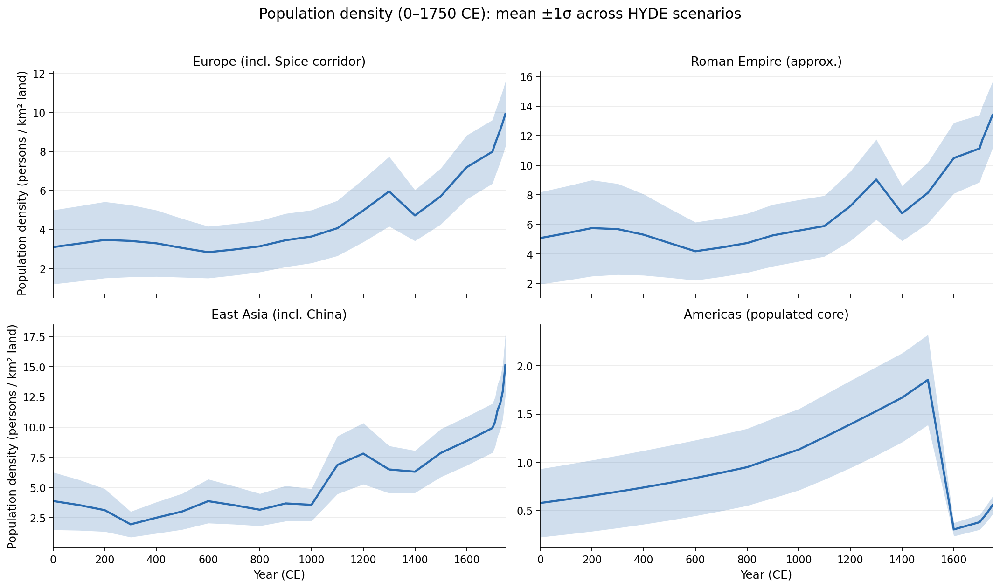

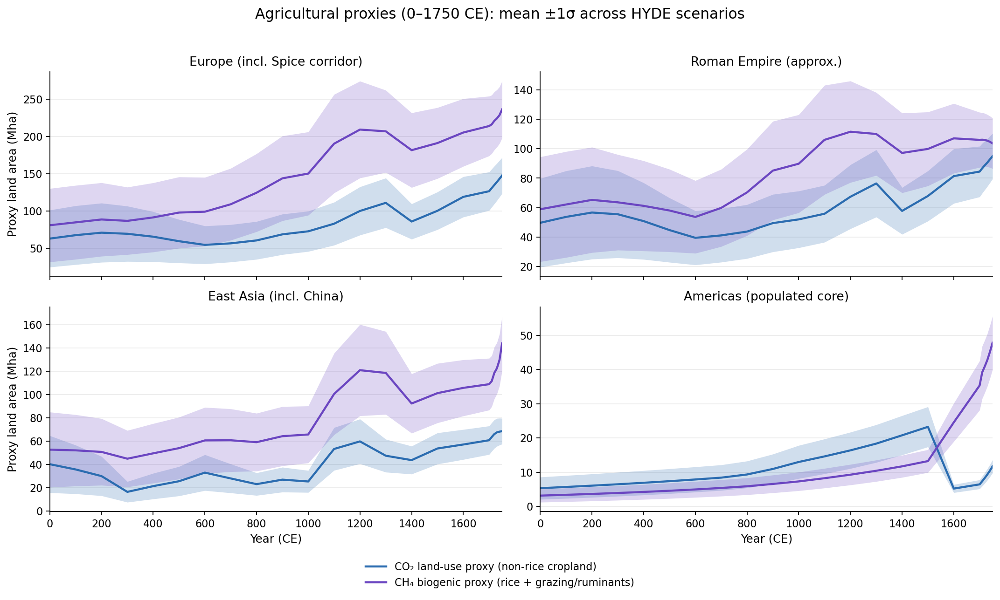

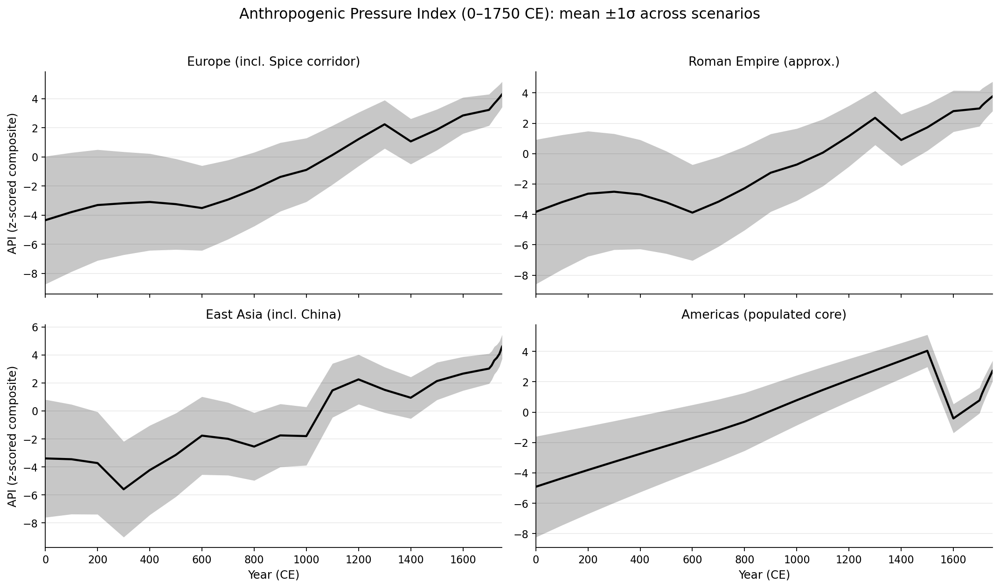

/var/folders/lx/tfh_l1r90j3cp31s1bhtz7ph0000gn/T/ipykernel_3961/887743188.py:977: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


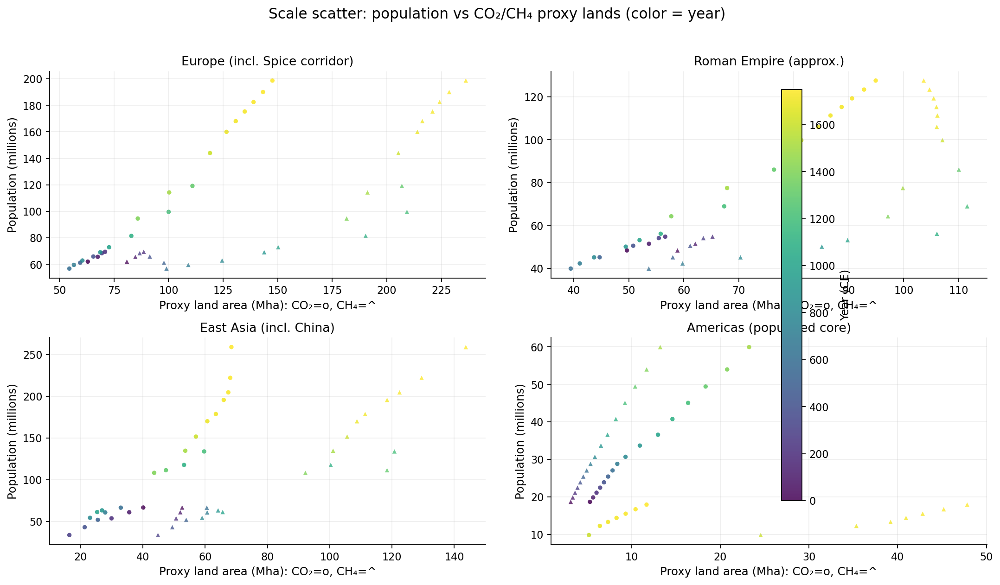

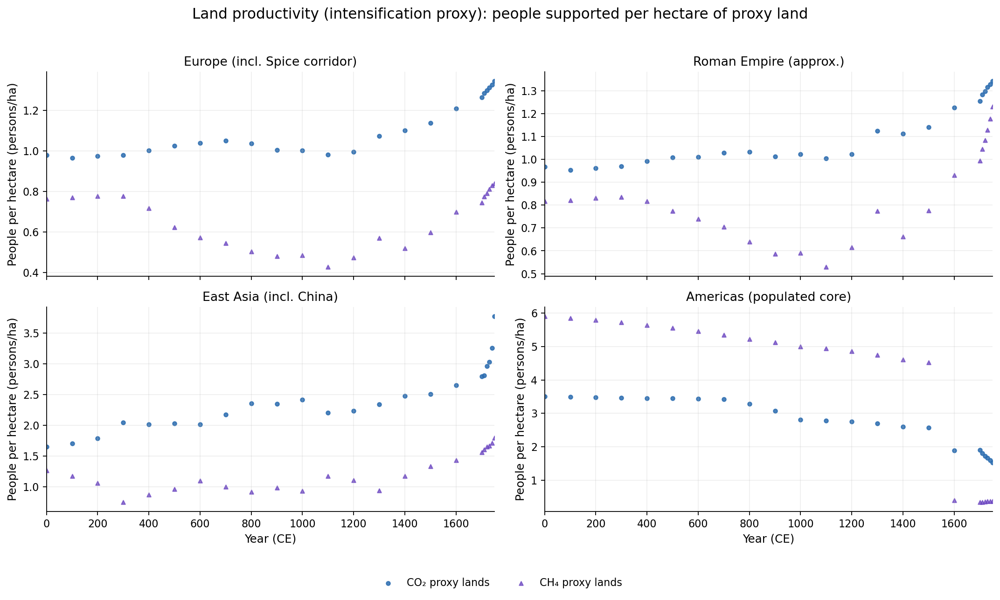

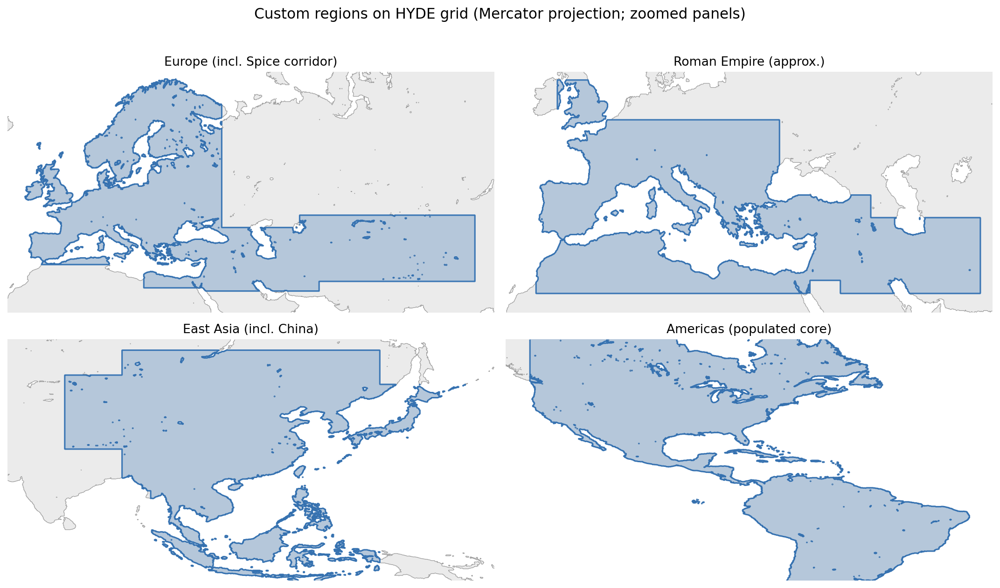


Wrote:
  hyde35_anthropogenic_region_year_by_scenario.csv
  hyde35_anthropogenic_region_year_mean_std.csv


In [2]:
# hyde35_anthropogenic_regions.py
# HYDE 3.5 (0–1750 CE): Custom regions + population density + CH4/CO2 land-use proxies
# + anthropogenic pressure metrics + productivity scatters + Mercator region maps
#
# Plug-and-run:
#   1) cd into your HYDE 3.5 root directory (the one containing gbc2025_* scenario folders + general_files/)
#   2) python hyde35_anthropogenic_regions.py
#
# Outputs:
#   - Figures: population density, land-use proxies, API index, scatter panels, region maps
#   - CSVs:
#       hyde35_anthropogenic_region_year_by_scenario.csv
#       hyde35_anthropogenic_region_year_mean_std.csv
#
# Notes:
#   - Robust to lon 0..360 vs -180..180 by doing comparisons in lon180 space but keeping original lon coords.
#   - Handles missing optional files (urban_population.nc, urban_area.nc, etc.).
#
# Dependencies: numpy, pandas, xarray, matplotlib

from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ----------------------------
# User config
# ----------------------------
START_YEAR = 0
END_YEAR = 1750

SPICE_LON_MAX = 105  # degrees East in [-180,180) convention

REGION_ORDER = [
    "Europe (incl. Spice corridor)",
    "Roman Empire (approx.)",
    "East Asia (incl. China)",
    "Americas (populated core)",
]

CLASS_CO2 = "CO₂ land-use proxy (non-rice cropland)"
CLASS_CH4 = "CH₄ biogenic proxy (rice + grazing/ruminants)"

BLUE = "#2b6cb0"
PURPLE = "#6b46c1"
SHADE_ALPHA = 0.22

plt.rcParams.update(
    {
        "figure.dpi": 160,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

# ----------------------------
# File discovery (HYDE 3.5 nested general_files)
# ----------------------------
def _first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p.exists():
            return p
    return None


def find_general_file(root: Path, filename: str) -> Path:
    candidates = [
        root / "general_files" / "general_files" / filename,
        root / "general_files" / filename,
        root / filename,
    ]
    hit = _first_existing(candidates)
    if hit:
        return hit

    gf = root / "general_files"
    if gf.exists():
        hits = list(gf.rglob(filename))
        if hits:
            return hits[0]

    hits = list(root.rglob(filename))
    if hits:
        return hits[0]

    raise FileNotFoundError(f"Could not find '{filename}' under {root}.")


# ----------------------------
# Scenario discovery
# ----------------------------
def discover_scenarios(root: Path) -> List[Tuple[str, Path]]:
    pop_files = sorted(root.glob("*/NetCDF/population.nc"))
    out: List[Tuple[str, Path]] = []
    for pop_nc in pop_files:
        scen_dir = pop_nc.parent.parent
        label = scen_dir.name
        m = re.search(r"(base|lower|upper)", label, flags=re.IGNORECASE)
        if m:
            label = m.group(1).lower()
        out.append((label, scen_dir))

    order = {"base": 0, "lower": 1, "upper": 2}
    out.sort(key=lambda t: (order.get(t[0], 99), t[0]))
    return out


# ----------------------------
# Lat/lon standardization
# ----------------------------
def ensure_latlon(ds: xr.Dataset) -> xr.Dataset:
    rename: Dict[str, str] = {}
    for name in list(ds.dims) + list(ds.coords):
        low = name.lower()
        if low in ("latitude", "nav_lat", "y") and "lat" not in ds.dims and "lat" not in ds.coords:
            rename[name] = "lat"
        if low in ("longitude", "nav_lon", "x") and "lon" not in ds.dims and "lon" not in ds.coords:
            rename[name] = "lon"
    if rename:
        ds = ds.rename(rename)

    if "lat" not in ds.coords:
        if "lat" in ds.dims:
            ds = ds.assign_coords(lat=ds["lat"])
        else:
            raise ValueError(f"Dataset missing 'lat'. dims={ds.dims}, coords={list(ds.coords)}")
    if "lon" not in ds.coords:
        if "lon" in ds.dims:
            ds = ds.assign_coords(lon=ds["lon"])
        else:
            raise ValueError(f"Dataset missing 'lon'. dims={ds.dims}, coords={list(ds.coords)}")
    return ds


# ----------------------------
# ESRI ASCII reader + alignment
# ----------------------------
def read_esri_ascii_grid(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing ASCII grid: {path}")

    header: Dict[str, float] = {}
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(6):
            line = f.readline()
            if not line:
                raise ValueError(f"Unexpected EOF reading header of {path}")
            k, v = line.strip().split()[:2]
            header[k.lower()] = float(v) if ("." in v or "e" in v.lower()) else int(v)
        data = np.loadtxt(f)

    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    cell = float(header["cellsize"])

    if data.shape != (nrows, ncols):
        raise ValueError(f"{path}: header says ({nrows},{ncols}) but data is {data.shape}")

    if "xllcorner" in header:
        xll = float(header["xllcorner"])
    elif "xllcenter" in header:
        xll = float(header["xllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing xllcorner/xllcenter")

    if "yllcorner" in header:
        yll = float(header["yllcorner"])
    elif "yllcenter" in header:
        yll = float(header["yllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing yllcorner/yllcenter")

    nodata = header.get("nodata_value", None)

    lon = xll + cell * (0.5 + np.arange(ncols))
    lat = yll + cell * (nrows - 0.5 - np.arange(nrows))  # north->south

    da = xr.DataArray(data, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name=path.stem)
    if nodata is not None:
        da = da.where(da != nodata)
    return da


def _lon_to_180_vals(lon_vals: np.ndarray) -> np.ndarray:
    lon_vals = np.asarray(lon_vals, dtype=float)
    return (((lon_vals + 180.0) % 360.0) - 180.0)


def normalize_longitudes_to_match(da: xr.DataArray, target_lon: xr.DataArray) -> xr.DataArray:
    da = da.copy()
    lon_da = da["lon"].values
    lon_t = target_lon.values
    tmin = float(np.nanmin(lon_t))

    if tmin >= 0 and np.nanmin(lon_da) < 0:
        da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon")

    if tmin < 0 and np.nanmin(lon_da) >= 0:
        da = da.assign_coords(lon=_lon_to_180_vals(da["lon"].values)).sortby("lon")

    return da


def align_grid_to_dataset(da: xr.DataArray, ds_template: xr.Dataset) -> xr.DataArray:
    da2 = normalize_longitudes_to_match(da, ds_template["lon"])
    return da2.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")


# ----------------------------
# NetCDF open + year handling
# ----------------------------
def open_single_var_nc(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing NetCDF: {path}")

    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    engines = [None, "netcdf4", "h5netcdf"]
    last_err = None

    for eng in engines:
        for use_chunks in (True, False):
            try:
                kw = dict(decode_times=time_coder, cache=False)
                if use_chunks:
                    kw["chunks"] = {"time": 1}
                ds = xr.open_dataset(path, engine=eng, **kw) if eng else xr.open_dataset(path, **kw)
                ds = ensure_latlon(ds)

                data_vars = list(ds.data_vars)
                if not data_vars:
                    raise ValueError(f"No data variables in {path}")

                if len(data_vars) == 1:
                    return ds[data_vars[0]]

                stem = path.stem.lower()
                for v in data_vars:
                    if stem in v.lower():
                        return ds[v]
                return ds[data_vars[0]]
            except Exception as e:
                last_err = e
                continue

    raise OSError(f"Failed to open {path}. Last error: {last_err}")


def coerce_year_index(da: xr.DataArray) -> xr.DataArray:
    if "year" in da.coords:
        t = da["year"]
    elif "time" in da.coords:
        t = da["time"]
    else:
        raise ValueError("No 'time' or 'year' coordinate found.")

    try:
        years = t.dt.year.astype(int).values
    except Exception:
        vals = np.asarray(t.values)
        if vals.size and hasattr(vals.flat[0], "year"):
            years = np.array([v.year for v in vals.ravel()], dtype=int).reshape(vals.shape)
        else:
            years = np.rint(vals.astype(float)).astype(int)

    dim = t.dims[0] if t.dims else None
    if dim is None:
        da = da.assign_coords(year=years)
    else:
        da = da.assign_coords(year=(dim, years))
        if dim != "year" and np.unique(years).size == years.size:
            da = da.swap_dims({dim: "year"})
    return da


def subset_years(da: xr.DataArray, start_year: int, end_year: int) -> xr.DataArray:
    da = coerce_year_index(da)
    if "year" in da.dims:
        da = da.sortby("year")
        return da.sel(year=slice(start_year, end_year))
    if "year" in da.coords:
        mask = (da["year"] >= start_year) & (da["year"] <= end_year)
        return da.where(mask, drop=True)
    raise ValueError("No 'year' coordinate could be constructed.")


# ----------------------------
# Constant grids: cell area + land mask
# ----------------------------
def load_cell_area_km2(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    p = find_general_file(root, "garea_cr.asc")
    da = read_esri_ascii_grid(p)
    da = align_grid_to_dataset(da, ds_template)
    da.name = "cell_area_km2"
    return da


def load_land_mask_optional(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    try:
        p = find_general_file(root, "landlake.asc")
    except FileNotFoundError:
        p = None

    lat = ds_template["lat"].values
    lon = ds_template["lon"].values

    if p is None or not Path(p).exists():
        warnings.warn("landlake.asc not found. Treating all grid cells as land.")
        return xr.DataArray(
            np.ones((lat.size, lon.size), dtype=float),
            dims=("lat", "lon"),
            coords={"lat": lat, "lon": lon},
            name="land_mask",
        )

    da = read_esri_ascii_grid(Path(p))
    da = align_grid_to_dataset(da, ds_template)
    lm = xr.where(da > 0, 1.0, 0.0).fillna(0.0)
    lm.name = "land_mask"

    frac_land = float(lm.mean().values)
    if frac_land < 0.01:
        warnings.warn("Aligned land mask has <1% land; using all-land fallback.")
        lm = xr.ones_like(lm)

    return lm


# ----------------------------
# Region masks (fixed for lon 0..360 datasets)
# ----------------------------
def build_region_masks(ds_template: xr.Dataset, land_mask: xr.DataArray) -> xr.DataArray:
    lat = ds_template["lat"]
    lon = ds_template["lon"]

    lon180_vals = _lon_to_180_vals(lon.values)
    lon180 = xr.DataArray(lon180_vals, dims=("lon",), coords={"lon": lon.values})

    LON180, LAT = xr.broadcast(lon180, lat)
    LON180 = LON180.transpose("lat", "lon")
    LAT = LAT.transpose("lat", "lon")

    def in_box(lon_min, lon_max, lat_min, lat_max):
        return (LON180 >= lon_min) & (LON180 <= lon_max) & (LAT >= lat_min) & (LAT <= lat_max)

    sahara = in_box(-17, 35, 15, 28)
    arabia = in_box(34, 60, 12, 27)
    exclude = sahara | arabia

    europe_core = in_box(-12, 40, 35, 72)
    spice_near_east = in_box(20, 65, 27, 45)
    spice_central_asia = in_box(60, SPICE_LON_MAX, 30, 48)
    europe = europe_core | (spice_near_east | spice_central_asia)

    roman_west = in_box(-10, 30, 35, 51)
    roman_balkans = in_box(10, 30, 35, 46)
    roman_anatolia = in_box(20, 45, 34, 42)
    roman_levant = in_box(30, 42, 30, 38)
    roman_n_africa_coast = in_box(-10, 35, 28, 37)
    roman_iraq_iran = in_box(40, 63, 28, 39)
    roman_britain = in_box(-6.5, 2.5, 49.5, 55.2)
    roman = (
        roman_west | roman_balkans | roman_anatolia | roman_levant
        | roman_n_africa_coast | roman_iraq_iran | roman_britain
    )

    china_core = in_box(90, 135, 18, 53)
    china_west = in_box(80, 95, 30, 48)
    korea_japan = in_box(120, 150, 30, 46)
    se_asia = in_box(95, 135, -10, 25)
    eastasia = china_core | china_west | korea_japan | se_asia

    americas = in_box(-125, -30, -35, 60)

    def finalize(mask_bool: xr.DataArray) -> xr.DataArray:
        m = mask_bool & (~exclude)
        m = xr.where(m, 1.0, 0.0)
        return (m * land_mask).astype(float)

    masks = xr.concat(
        [finalize(europe), finalize(roman), finalize(eastasia), finalize(americas)],
        dim="region",
    )
    masks = masks.assign_coords(region=("region", REGION_ORDER))
    masks.name = "region_masks"
    return masks


# ----------------------------
# Land-use helpers
# ----------------------------
def _string_attr(da: xr.DataArray, key: str) -> str:
    return str(da.attrs.get(key, "")).strip().lower()


def _looks_like_fraction(da: xr.DataArray) -> bool:
    units = _string_attr(da, "units")
    long_name = _string_attr(da, "long_name") + " " + _string_attr(da, "standard_name")
    if ("frac" in units) or ("fraction" in units) or ("fraction" in long_name):
        return True
    if units in ("", "1", "-"):
        try:
            sample = da.isel(time=0) if "time" in da.dims else (da.isel(year=0) if "year" in da.dims else da)
            vmax = float(sample.max().values)
            vmin = float(sample.min().values)
            return (vmin >= -1e-6) and (vmax <= 1.5)
        except Exception:
            return False
    return False


def landuse_regional_mha(
    nc_path: Path,
    region_masks: xr.DataArray,
    cell_area_km2: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None

    try:
        da = open_single_var_nc(nc_path)
    except Exception as e:
        warnings.warn(f"Skipping unreadable NetCDF: {nc_path.name} | {e}")
        return None

    da = subset_years(da, start_year, end_year)

    units = _string_attr(da, "units")
    frac = _looks_like_fraction(da)

    if frac:
        da_mha = (da * cell_area_km2) / 1e4
    else:
        if "km" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e4
        elif units in ("ha", "hectare", "hectares"):
            da_mha = da / 1e6
        elif "m" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e10
        else:
            warnings.warn(f"{nc_path.name}: Unrecognized units '{da.attrs.get('units','')}'. Assuming km² -> Mha via /1e4.")
            da_mha = da / 1e4

    da_mha = da_mha.rename("area_mha")
    reg = (da_mha * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "Mha"
    return reg


# ----------------------------
# Population helpers
# ----------------------------
def population_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> xr.DataArray:
    da = open_single_var_nc(nc_path)
    da = subset_years(da, start_year, end_year)
    reg = (da * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "persons"
    return reg


def optional_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None
    try:
        return population_regional_persons(nc_path, region_masks, start_year, end_year)
    except Exception as e:
        warnings.warn(f"Could not read optional file {nc_path.name}: {e}")
        return None


# ----------------------------
# Stats + plotting helpers
# ----------------------------
def std0(x: pd.Series) -> float:
    return float(np.std(x.to_numpy(dtype=float), ddof=0))


def style_timeseries_ax(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)


def plot_mean_sigma(ax, x, mean, std, color, label=None):
    ax.plot(x, mean, color=color, linewidth=2.0, label=label)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=SHADE_ALPHA, linewidth=0)


def safe_log_series(s: pd.Series) -> pd.Series:
    v = s.to_numpy(dtype=float)
    v = np.where(np.isfinite(v) & (v > 0), v, np.nan)
    return pd.Series(np.log(v), index=s.index)


def zscore_by_group_safe(df: pd.DataFrame, col: str, group_cols: List[str]) -> pd.Series:
    if col not in df.columns:
        return pd.Series(np.zeros(len(df)), index=df.index, dtype=float)

    def _z(x: pd.Series) -> pd.Series:
        v = x.to_numpy(dtype=float)
        mu = np.nanmean(v)
        sd = np.nanstd(v)
        if not np.isfinite(sd) or sd == 0:
            return pd.Series(np.zeros_like(v), index=x.index)
        return (x - mu) / sd

    return df.groupby(group_cols, group_keys=False)[col].apply(_z)


# Mercator helpers (no cartopy)
def mercator_y(lat_deg: np.ndarray) -> np.ndarray:
    lat = np.asarray(lat_deg, dtype=float)
    lat = np.clip(lat, -85.0, 85.0)
    phi = np.deg2rad(lat)
    return np.log(np.tan(np.pi / 4.0 + phi / 2.0))


def coord_edges_1d(coord: np.ndarray) -> np.ndarray:
    c = np.asarray(coord, dtype=float)
    if c.size < 2:
        raise ValueError("Need at least 2 points to compute edges.")
    d = np.diff(c)
    first = c[0] - d[0] / 2.0
    last = c[-1] + d[-1] / 2.0
    mid = c[:-1] + d / 2.0
    return np.concatenate([[first], mid, [last]])


def to_lon180_sorted(da: xr.DataArray) -> xr.DataArray:
    lon_vals = da["lon"].values
    lon180_vals = _lon_to_180_vals(lon_vals)
    return da.assign_coords(lon=lon180_vals).sortby("lon")


def sel_box_latlon(da: xr.DataArray, lon_min: float, lon_max: float, lat_min: float, lat_max: float) -> xr.DataArray:
    lat = da["lat"].values
    if lat[0] < lat[-1]:
        da2 = da.sel(lat=slice(lat_min, lat_max))
    else:
        da2 = da.sel(lat=slice(lat_max, lat_min))
    da2 = da2.sel(lon=slice(lon_min, lon_max))
    return da2.sortby("lat")


# ----------------------------
# MAIN
# ----------------------------
ROOT = Path(".").resolve()
scenarios = discover_scenarios(ROOT)
if not scenarios:
    raise RuntimeError(
        "No scenarios found. Expected folders like 'gbc2025_7apr_base' with 'NetCDF/population.nc'. "
        "Run from the HYDE 3.5 root directory."
    )

print("Found scenarios:", ", ".join([f"{lab}:{p.name}" for lab, p in scenarios]))

template_label, template_dir = scenarios[0]
template_ds = xr.open_dataset(template_dir / "NetCDF" / "population.nc")
template_ds = ensure_latlon(template_ds)

print(f"Template lon range: {float(template_ds['lon'].min()):.3f} .. {float(template_ds['lon'].max()):.3f}")
print(f"Template lat range: {float(template_ds['lat'].min()):.3f} .. {float(template_ds['lat'].max()):.3f}")

cell_area_km2 = load_cell_area_km2(ROOT, template_ds)
land_mask = load_land_mask_optional(ROOT, template_ds)
region_masks = build_region_masks(template_ds, land_mask)

land_area_reg_km2 = (cell_area_km2 * region_masks).sum(dim=("lat", "lon"), skipna=True).rename("land_area_km2").astype(float)
print("\nLand area by region (km²):")
print(land_area_reg_km2.to_dataframe().reset_index())

if float(land_area_reg_km2.max().values) <= 0:
    raise RuntimeError("All region land areas are zero. Masks are not aligning with NetCDF lon/lat.")

# Collect per-scenario time series
pop_rows = []
ag_rows = []
extra_rows = []

for scen_label, scen_dir in scenarios:
    print(f"Processing scenario: {scen_label} ({scen_dir.name})")

    # Population totals
    pop_reg = population_regional_persons(scen_dir / "NetCDF" / "population.nc", region_masks, START_YEAR, END_YEAR)

    # Optional urban population and urban area
    urb_pop_reg = optional_regional_persons(scen_dir / "NetCDF" / "urban_population.nc", region_masks, START_YEAR, END_YEAR)
    urb_area_reg = landuse_regional_mha(scen_dir / "NetCDF" / "urban_area.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    # Density
    dens = (pop_reg / xr.where(land_area_reg_km2 > 0, land_area_reg_km2, np.nan)).rename("pop_density_p_km2")

    dens_df = dens.to_dataframe(name="pop_density_p_km2").reset_index()
    dens_df["scenario"] = scen_label

    pop_df = pop_reg.to_dataframe(name="pop_total").reset_index()
    pop_df["scenario"] = scen_label

    # Urban merge
    if urb_pop_reg is not None:
        up = urb_pop_reg.to_dataframe(name="urban_pop").reset_index()
        up["scenario"] = scen_label
        base = pop_df.merge(up, on=["year", "region", "scenario"], how="left")
        base["urban_share"] = base["urban_pop"] / base["pop_total"]
    else:
        base = pop_df.copy()
        base["urban_pop"] = np.nan
        base["urban_share"] = np.nan

    if urb_area_reg is not None:
        ua = urb_area_reg.to_dataframe(name="urban_area_mha").reset_index()
        ua["scenario"] = scen_label
        base = base.merge(ua, on=["year", "region", "scenario"], how="left")
    else:
        base["urban_area_mha"] = np.nan

    base = base.merge(
        dens_df[["scenario", "year", "region", "pop_density_p_km2"]],
        on=["scenario", "year", "region"],
        how="left",
    )

    pop_rows.append(
        base[
            [
                "scenario",
                "year",
                "region",
                "pop_total",
                "pop_density_p_km2",
                "urban_pop",
                "urban_share",
                "urban_area_mha",
            ]
        ]
    )

    # -------- Land-use proxies --------
    rice_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    rice_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (rice_rf is not None) or (rice_ir is not None):
        rice_reg = (0 if rice_rf is None else rice_rf.fillna(0)) + (0 if rice_ir is None else rice_ir.fillna(0))
    else:
        rice_reg = landuse_regional_mha(scen_dir / "NetCDF" / "total_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    grazing_reg = landuse_regional_mha(scen_dir / "NetCDF" / "grazing_land.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if grazing_reg is None:
        pasture_reg = landuse_regional_mha(scen_dir / "NetCDF" / "pasture.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        rangeland_reg = landuse_regional_mha(scen_dir / "NetCDF" / "rangeland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if (pasture_reg is not None) or (rangeland_reg is not None):
            grazing_reg = (0 if pasture_reg is None else pasture_reg.fillna(0)) + (0 if rangeland_reg is None else rangeland_reg.fillna(0))

    nr_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    nr_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (nr_rf is not None) or (nr_ir is not None):
        nonrice_reg = (0 if nr_rf is None else nr_rf.fillna(0)) + (0 if nr_ir is None else nr_ir.fillna(0))
    else:
        cropt = landuse_regional_mha(scen_dir / "NetCDF" / "cropland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if cropt is not None and rice_reg is not None:
            nonrice_reg = (cropt - rice_reg.fillna(0)).clip(min=0)
            warnings.warn(f"{scen_dir.name}: Using cropland.nc minus rice as non-rice cropland fallback.")
        elif cropt is not None:
            nonrice_reg = cropt
            warnings.warn(f"{scen_dir.name}: Using cropland.nc as non-rice cropland fallback (rice unavailable).")
        else:
            nonrice_reg = None

    ch4_reg = None
    if (rice_reg is not None) or (grazing_reg is not None):
        r = 0 if rice_reg is None else rice_reg.fillna(0)
        g = 0 if grazing_reg is None else grazing_reg.fillna(0)
        ch4_reg = r + g
        df = ch4_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CH4
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    co2_reg = None
    if nonrice_reg is not None:
        co2_reg = nonrice_reg
        df = co2_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CO2
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # -------- Scenario-level derived objects (keep pop_total inside extra_all!) --------
    P = pop_df.merge(
        (ch4_reg.to_dataframe(name="ch4_mha").reset_index().assign(scenario=scen_label) if ch4_reg is not None else
         pop_df[["scenario", "year", "region"]].assign(ch4_mha=np.nan)),
        on=["scenario", "year", "region"],
        how="left",
    )

    P = P.merge(
        (co2_reg.to_dataframe(name="co2_mha").reset_index().assign(scenario=scen_label) if co2_reg is not None else
         pop_df[["scenario", "year", "region"]].assign(co2_mha=np.nan)),
        on=["scenario", "year", "region"],
        how="left",
    )

    land_mha_df = (land_area_reg_km2 / 1e4).to_dataframe(name="land_mha").reset_index()
    P = P.merge(land_mha_df, on=["region"], how="left")

    # Productivity / intensification
    P["co2_people_per_ha"] = P["pop_total"] / (P["co2_mha"] * 1e6)
    P["ch4_people_per_ha"] = P["pop_total"] / (P["ch4_mha"] * 1e6)

    P["co2_mha_per_million"] = P["co2_mha"] / (P["pop_total"] / 1e6)
    P["ch4_mha_per_million"] = P["ch4_mha"] / (P["pop_total"] / 1e6)

    P["co2_share_of_land"] = P["co2_mha"] / P["land_mha"]
    P["ch4_share_of_land"] = P["ch4_mha"] / P["land_mha"]

    # Growth rates (log diffs) by region
    P = P.sort_values(["region", "year"]).reset_index(drop=True)
    for col in ["pop_total", "co2_mha", "ch4_mha", "co2_share_of_land", "ch4_share_of_land"]:
        gcol = f"dlog_{col}"
        P[gcol] = np.nan
        for rname in REGION_ORDER:
            idx = (P["region"].to_numpy() == rname)
            x = P.loc[idx, col].to_numpy(dtype=float)
            x = np.where(np.isfinite(x) & (x > 0), x, np.nan)
            d = np.full_like(x, np.nan, dtype=float)
            if x.size >= 2:
                d[1:] = np.log(x[1:]) - np.log(x[:-1])
            P.loc[idx, gcol] = d

    extra_rows.append(
        P[
            [
                "scenario",
                "year",
                "region",
                "pop_total",
                "co2_mha",
                "ch4_mha",
                "land_mha",
                "co2_people_per_ha",
                "ch4_people_per_ha",
                "co2_mha_per_million",
                "ch4_mha_per_million",
                "co2_share_of_land",
                "ch4_share_of_land",
                "dlog_pop_total",
                "dlog_co2_mha",
                "dlog_ch4_mha",
                "dlog_co2_share_of_land",
                "dlog_ch4_share_of_land",
            ]
        ]
    )

# Concatenate
pop_all = pd.concat(pop_rows, ignore_index=True)
ag_all = pd.concat(ag_rows, ignore_index=True) if ag_rows else pd.DataFrame(columns=["scenario", "year", "region", "class", "area_mha"])
extra_all = pd.concat(extra_rows, ignore_index=True) if extra_rows else pd.DataFrame()

# Across-scenario stats
popdens_stats = (
    pop_all.groupby(["year", "region"], as_index=False)
    .agg(mean=("pop_density_p_km2", "mean"), std=("pop_density_p_km2", std0))
)

ag_stats = (
    ag_all.groupby(["year", "region", "class"], as_index=False)
    .agg(mean=("area_mha", "mean"), std=("area_mha", std0))
)

extra_stats = (
    extra_all.groupby(["year", "region"], as_index=False)
    .agg(
        pop_mean=("pop_total", "mean"),
        pop_std=("pop_total", std0),
        co2_mha_mean=("co2_mha", "mean"),
        co2_mha_std=("co2_mha", std0),
        ch4_mha_mean=("ch4_mha", "mean"),
        ch4_mha_std=("ch4_mha", std0),
        co2_people_per_ha_mean=("co2_people_per_ha", "mean"),
        co2_people_per_ha_std=("co2_people_per_ha", std0),
        ch4_people_per_ha_mean=("ch4_people_per_ha", "mean"),
        ch4_people_per_ha_std=("ch4_people_per_ha", std0),
        co2_share_mean=("co2_share_of_land", "mean"),
        co2_share_std=("co2_share_of_land", std0),
        ch4_share_mean=("ch4_share_of_land", "mean"),
        ch4_share_std=("ch4_share_of_land", std0),
        dlog_pop_mean=("dlog_pop_total", "mean"),
        dlog_pop_std=("dlog_pop_total", std0),
        dlog_co2_mean=("dlog_co2_mha", "mean"),
        dlog_co2_std=("dlog_co2_mha", std0),
        dlog_ch4_mean=("dlog_ch4_mha", "mean"),
        dlog_ch4_std=("dlog_ch4_mha", std0),
    )
)

# ----------------------------
# API (Anthropogenic Pressure Index) — bulletproof
# ----------------------------
api_df = extra_all.merge(
    pop_all[["scenario", "year", "region", "urban_area_mha"]],
    on=["scenario", "year", "region"],
    how="left",
)

for c in ["pop_total", "co2_mha", "ch4_mha", "urban_area_mha"]:
    if c in api_df.columns:
        api_df[f"log_{c}"] = safe_log_series(api_df[c])

api_df["z_log_pop"] = zscore_by_group_safe(api_df, "log_pop_total", ["region"])
api_df["z_log_co2"] = zscore_by_group_safe(api_df, "log_co2_mha", ["region"])
api_df["z_log_ch4"] = zscore_by_group_safe(api_df, "log_ch4_mha", ["region"])
api_df["z_log_urban"] = zscore_by_group_safe(api_df, "log_urban_area_mha", ["region"])

api_df["API"] = api_df["z_log_pop"] + api_df["z_log_co2"] + api_df["z_log_ch4"] + api_df["z_log_urban"]

api_stats = (
    api_df.groupby(["year", "region"], as_index=False)
    .agg(API_mean=("API", "mean"), API_std=("API", std0))
)

print("\nPreview: extra_stats head")
print(extra_stats.head(10))
print("\nPreview: api_stats head")
print(api_stats.head(10))

# ----------------------------
# FIGURE A: Population density
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, df["year"].to_numpy(), df["mean"].to_numpy(float), df["std"].to_numpy(float), color=BLUE)

axs[0].set_ylabel("Population density (persons / km² land)")
axs[2].set_ylabel("Population density (persons / km² land)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE B: Land-use proxies
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)

    df_r = ag_stats[ag_stats["region"] == region]
    if df_r.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    d_co2 = df_r[df_r["class"] == CLASS_CO2].sort_values("year")
    if not d_co2.empty:
        plot_mean_sigma(ax, d_co2["year"].to_numpy(), d_co2["mean"].to_numpy(float), d_co2["std"].to_numpy(float),
                        color=BLUE, label=CLASS_CO2 if i == 0 else None)

    d_ch4 = df_r[df_r["class"] == CLASS_CH4].sort_values("year")
    if not d_ch4.empty:
        plot_mean_sigma(ax, d_ch4["year"].to_numpy(), d_ch4["mean"].to_numpy(float), d_ch4["std"].to_numpy(float),
                        color=PURPLE, label=CLASS_CH4 if i == 0 else None)

axs[0].set_ylabel("Proxy land area (Mha)")
axs[2].set_ylabel("Proxy land area (Mha)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Agricultural proxies (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=1, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE C: API index
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = api_stats[api_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, df["year"].to_numpy(), df["API_mean"].to_numpy(float), df["API_std"].to_numpy(float), color="black")

axs[0].set_ylabel("API (z-scored composite)")
axs[2].set_ylabel("API (z-scored composite)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Anthropogenic Pressure Index (0–1750 CE): mean ±1σ across scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE D: Scatter — population vs proxy lands (color = year)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8))
axs = axs.ravel()
sc_for_cbar = None

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = extra_stats[extra_stats["region"] == region].sort_values("year")
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    y = df["pop_mean"].to_numpy(dtype=float) / 1e6  # millions
    c = df["year"].to_numpy(dtype=float)

    x_co2 = df["co2_mha_mean"].to_numpy(dtype=float)
    x_ch4 = df["ch4_mha_mean"].to_numpy(dtype=float)

    sc1 = ax.scatter(x_co2, y, c=c, s=18, marker="o", cmap="viridis", alpha=0.85, edgecolors="none")
    ax.scatter(x_ch4, y, c=c, s=18, marker="^", cmap="viridis", alpha=0.75, edgecolors="none")

    if sc_for_cbar is None:
        sc_for_cbar = sc1

    ax.set_title(region)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.20)
    ax.set_xlabel("Proxy land area (Mha): CO₂=o, CH₄=^")
    ax.set_ylabel("Population (millions)")

fig.suptitle("Scale scatter: population vs CO₂/CH₄ proxy lands (color = year)", y=0.98, fontsize=14)
if sc_for_cbar is not None:
    cbar = fig.colorbar(sc_for_cbar, ax=axs.tolist(), shrink=0.90, pad=0.02)
    cbar.set_label("Year (CE)")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE E: Productivity — people per hectare vs year
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = extra_stats[extra_stats["region"] == region].sort_values("year")
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    x = df["year"].to_numpy(dtype=float)
    y1 = df["co2_people_per_ha_mean"].to_numpy(dtype=float)
    y2 = df["ch4_people_per_ha_mean"].to_numpy(dtype=float)

    ax.scatter(x, y1, s=14, marker="o", alpha=0.85, color=BLUE, label="CO₂ proxy lands" if i == 0 else None)
    ax.scatter(x, y2, s=14, marker="^", alpha=0.75, color=PURPLE, label="CH₄ proxy lands" if i == 0 else None)

    ax.set_title(region)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.20)
    ax.set_xlim(START_YEAR, END_YEAR)
    ax.set_ylabel("People per hectare (persons/ha)")

axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Land productivity (intensification proxy): people supported per hectare of proxy land", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE F: Mercator region maps (2×2)
# ----------------------------
MAP_EXTENTS = {
    "Europe (incl. Spice corridor)": (-15, SPICE_LON_MAX + 5, 20, 72),
    "Roman Empire (approx.)": (-15, 65, 25, 56),
    "East Asia (incl. China)": (70, 155, -10, 55),
    "Americas (populated core)": (-130, -30, -35, 60),
}

land_plot = to_lon180_sorted(land_mask)
region_plot = to_lon180_sorted(region_masks)

land_cmap = ListedColormap([(1, 1, 1, 0), (0, 0, 0, 0.08)])
region_cmap = ListedColormap([(0, 0, 0, 0), (0.17, 0.42, 0.69, 0.28)])

fig, axs = plt.subplots(2, 2, figsize=(13.5, 8))
axs = axs.ravel()

for i, region_name in enumerate(REGION_ORDER):
    ax = axs[i]
    lon_min, lon_max, lat_min, lat_max = MAP_EXTENTS[region_name]

    land_sub = sel_box_latlon(land_plot, lon_min, lon_max, lat_min, lat_max)
    reg_sub = sel_box_latlon(region_plot.sel(region=region_name), lon_min, lon_max, lat_min, lat_max)

    lon = land_sub["lon"].values
    lat = land_sub["lat"].values
    lon_e = coord_edges_1d(lon)
    lat_e = coord_edges_1d(lat)
    y_e = mercator_y(lat_e)
    y = mercator_y(lat)

    ax.pcolormesh(lon_e, y_e, (land_sub.values > 0).astype(float), shading="auto", cmap=land_cmap)
    ax.pcolormesh(lon_e, y_e, reg_sub.values.astype(float), shading="auto", cmap=region_cmap)

    try:
        ax.contour(lon, y, (land_sub.values > 0).astype(float), levels=[0.5], colors="black", linewidths=0.6, alpha=0.35)
    except Exception:
        pass

    try:
        ax.contour(lon, y, reg_sub.values.astype(float), levels=[0.5], colors=BLUE, linewidths=1.4, alpha=0.9)
    except Exception:
        pass

    ax.set_title(region_name)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(mercator_y(lat_min), mercator_y(lat_max))
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig.suptitle("Custom regions on HYDE grid (Mercator projection; zoomed panels)", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# SAVE PANELS
# ----------------------------
panel_scenario = extra_all.merge(
    pop_all[["scenario", "year", "region", "pop_density_p_km2", "urban_share", "urban_area_mha"]],
    on=["scenario", "year", "region"],
    how="left",
)

panel_mean = extra_stats.merge(popdens_stats[["year", "region", "mean", "std"]], on=["year", "region"], how="left")
panel_mean = panel_mean.rename(columns={"mean": "popdens_mean", "std": "popdens_std"})
panel_mean = panel_mean.merge(api_stats, on=["year", "region"], how="left")

panel_scenario.to_csv("hyde35_anthropogenic_region_year_by_scenario.csv", index=False)
panel_mean.to_csv("hyde35_anthropogenic_region_year_mean_std.csv", index=False)

print("\nWrote:")
print("  hyde35_anthropogenic_region_year_by_scenario.csv")
print("  hyde35_anthropogenic_region_year_mean_std.csv")

Found scenarios: base:gbc2025_7apr_base, lower:gbc2025_7apr_lower, upper:gbc2025_7apr_upper
Template lon range: -179.958 .. 179.958
Template lat range: -89.958 .. 89.958

Land area by region (km²):
                          region  land_area_km2
0  Europe (incl. Spice corridor)   2.004120e+07
1         Roman Empire (approx.)   9.509715e+06
2        East Asia (incl. China)   1.711765e+07
3      Americas (populated core)   3.229304e+07
Processing scenario: base (gbc2025_7apr_base)
Processing scenario: lower (gbc2025_7apr_lower)
Processing scenario: upper (gbc2025_7apr_upper)

Preview: extra_stats head
   year                         region      pop_mean       pop_std  \
0     0      Americas (populated core)  1.867156e+07  1.143395e+07   
1     0        East Asia (incl. China)  6.658524e+07  4.077496e+07   
2     0  Europe (incl. Spice corridor)  6.203893e+07  3.799094e+07   
3     0         Roman Empire (approx.)  4.833443e+07  2.959868e+07   
4   100      Americas (populated core)  1.9

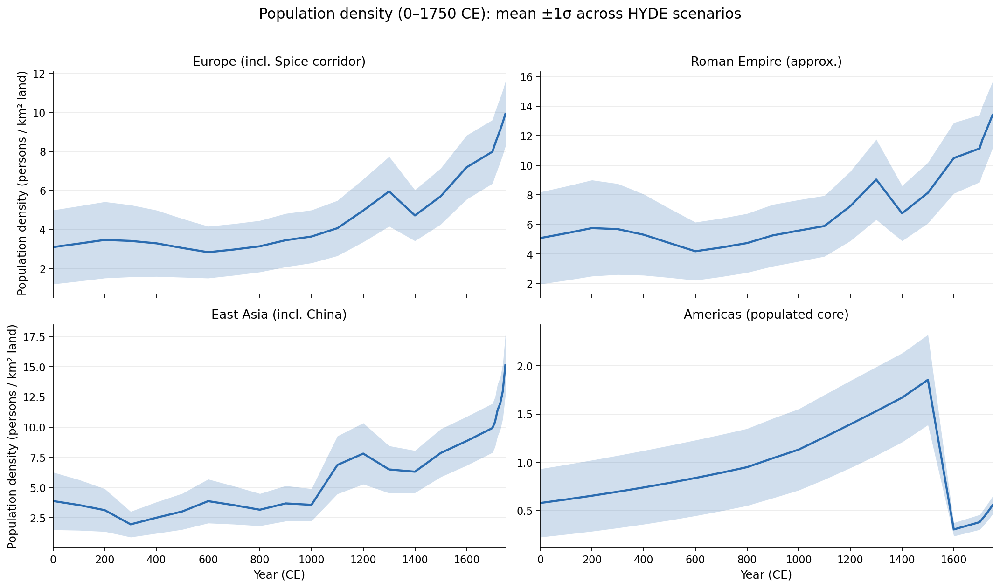

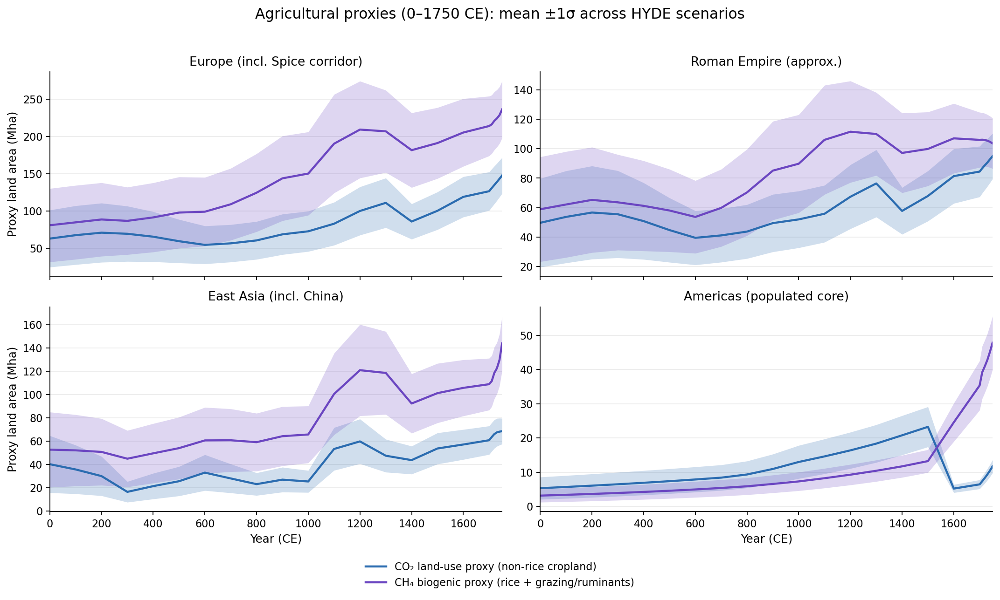

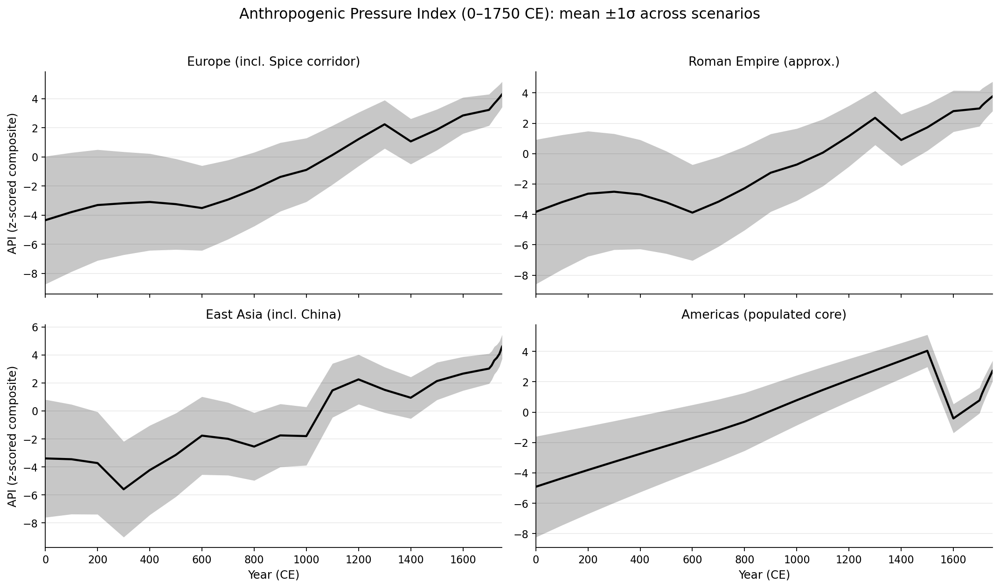

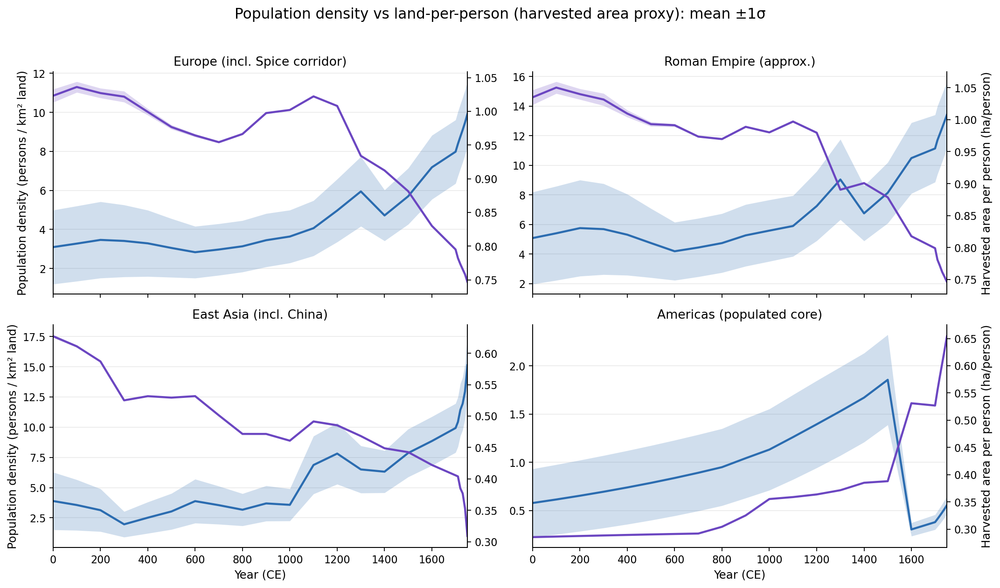

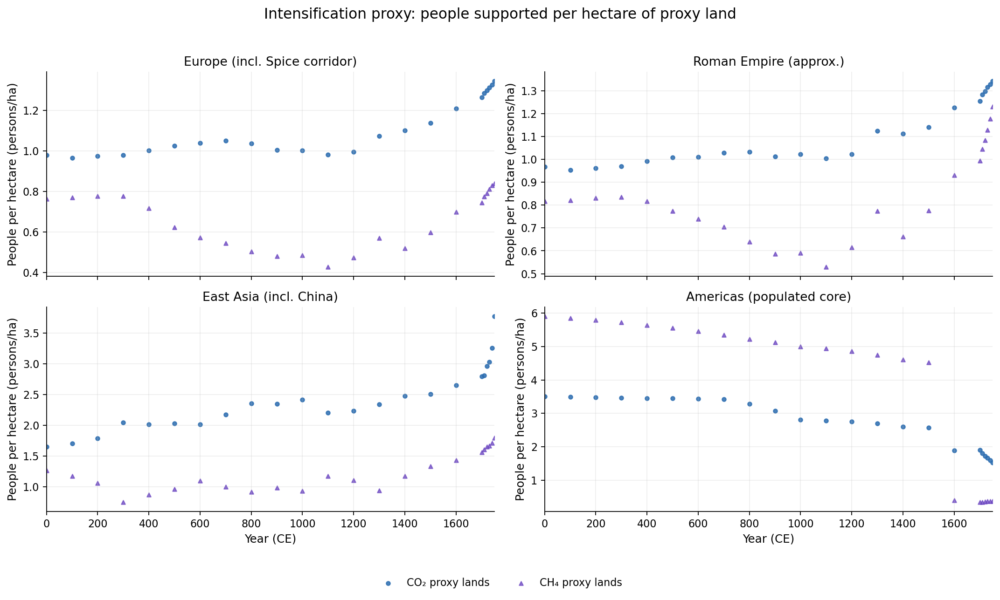

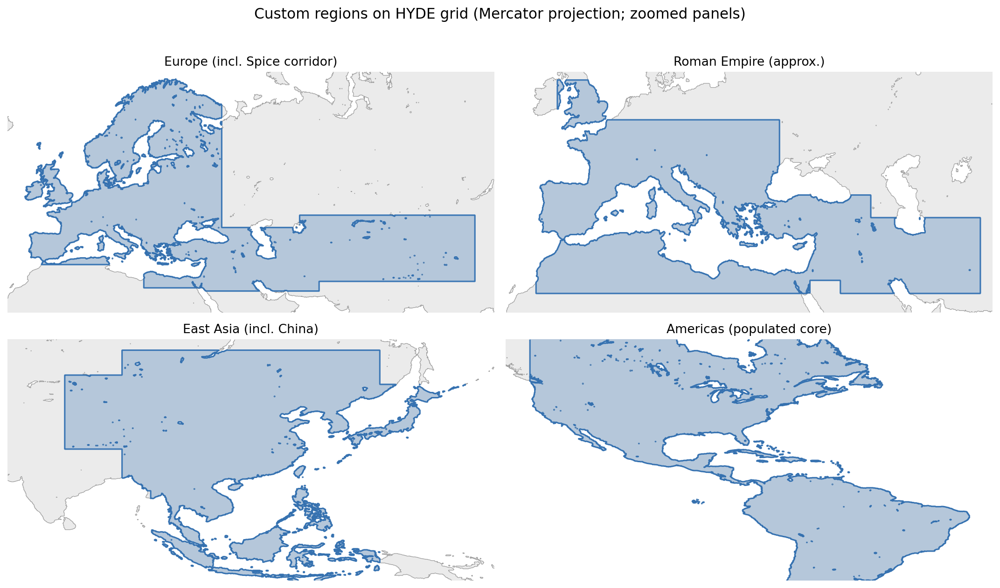


Wrote:
  hyde35_anthropogenic_region_year_by_scenario.csv
  hyde35_anthropogenic_region_year_mean_std.csv


In [ ]:
# hyde35_anthropogenic_regions_dualy.py
# HYDE 3.5 (0–1750 CE): Custom regions + population density + CH4/CO2 land-use proxies
# + anthropogenic pressure metrics + productivity (people/ha) + dual-y plot:
#       population density  vs  harvested area per person (ha/person)
#
# Plug-and-run:
#   1) cd into your HYDE 3.5 root directory (contains gbc2025_* scenario folders + general_files/)
#   2) python hyde35_anthropogenic_regions_dualy.py
#
# Outputs:
#   - Figures:
#       A) Pop density (mean±1σ)
#       B) CO2/CH4 proxy land areas (mean±1σ)
#       C) Anthropogenic Pressure Index (API) (mean±1σ)
#       D) Dual-y: Pop density (left) vs Harvested area per person (right) (mean±1σ)
#       E) Productivity scatter: people per hectare of proxy land (CO2 vs CH4) over time
#       F) Mercator region maps (2×2)
#   - CSVs:
#       hyde35_anthropogenic_region_year_by_scenario.csv
#       hyde35_anthropogenic_region_year_mean_std.csv
#
# Notes:
#   - “Harvested area” proxied by total cropland = rice + non-rice cropland (NOT grazing/pasture).
#   - Robust to lon 0..360 vs -180..180 by doing comparisons in lon180 space but keeping original lon coords.
#   - Handles missing optional files (urban_population.nc, urban_area.nc, etc.).

from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ----------------------------
# User config
# ----------------------------
START_YEAR = 0
END_YEAR = 1750

SPICE_LON_MAX = 105  # degrees East in [-180,180) convention

REGION_ORDER = [
    "Europe (incl. Spice corridor)",
    "Roman Empire (approx.)",
    "East Asia (incl. China)",
    "Americas (populated core)",
]

CLASS_CO2 = "CO₂ land-use proxy (non-rice cropland)"
CLASS_CH4 = "CH₄ biogenic proxy (rice + grazing/ruminants)"

BLUE = "#2b6cb0"
PURPLE = "#6b46c1"
SHADE_ALPHA = 0.22

plt.rcParams.update(
    {
        "figure.dpi": 160,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

# ----------------------------
# File discovery (HYDE 3.5 nested general_files)
# ----------------------------
def _first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p.exists():
            return p
    return None


def find_general_file(root: Path, filename: str) -> Path:
    candidates = [
        root / "general_files" / "general_files" / filename,
        root / "general_files" / filename,
        root / filename,
    ]
    hit = _first_existing(candidates)
    if hit:
        return hit

    gf = root / "general_files"
    if gf.exists():
        hits = list(gf.rglob(filename))
        if hits:
            return hits[0]

    hits = list(root.rglob(filename))
    if hits:
        return hits[0]

    raise FileNotFoundError(f"Could not find '{filename}' under {root}.")


# ----------------------------
# Scenario discovery
# ----------------------------
def discover_scenarios(root: Path) -> List[Tuple[str, Path]]:
    pop_files = sorted(root.glob("*/NetCDF/population.nc"))
    out: List[Tuple[str, Path]] = []
    for pop_nc in pop_files:
        scen_dir = pop_nc.parent.parent
        label = scen_dir.name
        m = re.search(r"(base|lower|upper)", label, flags=re.IGNORECASE)
        if m:
            label = m.group(1).lower()
        out.append((label, scen_dir))

    order = {"base": 0, "lower": 1, "upper": 2}
    out.sort(key=lambda t: (order.get(t[0], 99), t[0]))
    return out


# ----------------------------
# Lat/lon standardization
# ----------------------------
def ensure_latlon(ds: xr.Dataset) -> xr.Dataset:
    rename: Dict[str, str] = {}
    for name in list(ds.dims) + list(ds.coords):
        low = name.lower()
        if low in ("latitude", "nav_lat", "y") and "lat" not in ds.dims and "lat" not in ds.coords:
            rename[name] = "lat"
        if low in ("longitude", "nav_lon", "x") and "lon" not in ds.dims and "lon" not in ds.coords:
            rename[name] = "lon"
    if rename:
        ds = ds.rename(rename)

    if "lat" not in ds.coords:
        if "lat" in ds.dims:
            ds = ds.assign_coords(lat=ds["lat"])
        else:
            raise ValueError(f"Dataset missing 'lat'. dims={ds.dims}, coords={list(ds.coords)}")
    if "lon" not in ds.coords:
        if "lon" in ds.dims:
            ds = ds.assign_coords(lon=ds["lon"])
        else:
            raise ValueError(f"Dataset missing 'lon'. dims={ds.dims}, coords={list(ds.coords)}")
    return ds


# ----------------------------
# ESRI ASCII reader + alignment
# ----------------------------
def read_esri_ascii_grid(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing ASCII grid: {path}")

    header: Dict[str, float] = {}
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(6):
            line = f.readline()
            if not line:
                raise ValueError(f"Unexpected EOF reading header of {path}")
            k, v = line.strip().split()[:2]
            header[k.lower()] = float(v) if ("." in v or "e" in v.lower()) else int(v)
        data = np.loadtxt(f)

    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    cell = float(header["cellsize"])

    if data.shape != (nrows, ncols):
        raise ValueError(f"{path}: header says ({nrows},{ncols}) but data is {data.shape}")

    if "xllcorner" in header:
        xll = float(header["xllcorner"])
    elif "xllcenter" in header:
        xll = float(header["xllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing xllcorner/xllcenter")

    if "yllcorner" in header:
        yll = float(header["yllcorner"])
    elif "yllcenter" in header:
        yll = float(header["yllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing yllcorner/yllcenter")

    nodata = header.get("nodata_value", None)

    lon = xll + cell * (0.5 + np.arange(ncols))
    lat = yll + cell * (nrows - 0.5 - np.arange(nrows))  # north->south

    da = xr.DataArray(data, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name=path.stem)
    if nodata is not None:
        da = da.where(da != nodata)
    return da


def _lon_to_180_vals(lon_vals: np.ndarray) -> np.ndarray:
    lon_vals = np.asarray(lon_vals, dtype=float)
    return (((lon_vals + 180.0) % 360.0) - 180.0)


def normalize_longitudes_to_match(da: xr.DataArray, target_lon: xr.DataArray) -> xr.DataArray:
    da = da.copy()
    lon_da = da["lon"].values
    lon_t = target_lon.values
    tmin = float(np.nanmin(lon_t))

    # target is [0,360)
    if tmin >= 0 and np.nanmin(lon_da) < 0:
        da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon")

    # target is [-180,180)
    if tmin < 0 and np.nanmin(lon_da) >= 0:
        da = da.assign_coords(lon=_lon_to_180_vals(da["lon"].values)).sortby("lon")

    return da


def align_grid_to_dataset(da: xr.DataArray, ds_template: xr.Dataset) -> xr.DataArray:
    da2 = normalize_longitudes_to_match(da, ds_template["lon"])
    return da2.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")


# ----------------------------
# NetCDF open + year handling
# ----------------------------
def open_single_var_nc(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing NetCDF: {path}")

    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    engines = [None, "netcdf4", "h5netcdf"]
    last_err = None

    for eng in engines:
        for use_chunks in (True, False):
            try:
                kw = dict(decode_times=time_coder, cache=False)
                if use_chunks:
                    kw["chunks"] = {"time": 1}
                ds = xr.open_dataset(path, engine=eng, **kw) if eng else xr.open_dataset(path, **kw)
                ds = ensure_latlon(ds)

                data_vars = list(ds.data_vars)
                if not data_vars:
                    raise ValueError(f"No data variables in {path}")

                if len(data_vars) == 1:
                    return ds[data_vars[0]]

                stem = path.stem.lower()
                for v in data_vars:
                    if stem in v.lower():
                        return ds[v]
                return ds[data_vars[0]]
            except Exception as e:
                last_err = e
                continue

    raise OSError(f"Failed to open {path}. Last error: {last_err}")


def coerce_year_index(da: xr.DataArray) -> xr.DataArray:
    if "year" in da.coords:
        t = da["year"]
    elif "time" in da.coords:
        t = da["time"]
    else:
        raise ValueError("No 'time' or 'year' coordinate found.")

    try:
        years = t.dt.year.astype(int).values
    except Exception:
        vals = np.asarray(t.values)
        if vals.size and hasattr(vals.flat[0], "year"):
            years = np.array([v.year for v in vals.ravel()], dtype=int).reshape(vals.shape)
        else:
            years = np.rint(vals.astype(float)).astype(int)

    dim = t.dims[0] if t.dims else None
    if dim is None:
        da = da.assign_coords(year=years)
    else:
        da = da.assign_coords(year=(dim, years))
        if dim != "year" and np.unique(years).size == years.size:
            da = da.swap_dims({dim: "year"})
    return da


def subset_years(da: xr.DataArray, start_year: int, end_year: int) -> xr.DataArray:
    da = coerce_year_index(da)
    if "year" in da.dims:
        da = da.sortby("year")
        return da.sel(year=slice(start_year, end_year))
    if "year" in da.coords:
        mask = (da["year"] >= start_year) & (da["year"] <= end_year)
        return da.where(mask, drop=True)
    raise ValueError("No 'year' coordinate could be constructed.")


# ----------------------------
# Constant grids: cell area + land mask
# ----------------------------
def load_cell_area_km2(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    p = find_general_file(root, "garea_cr.asc")
    da = read_esri_ascii_grid(p)
    da = align_grid_to_dataset(da, ds_template)
    da.name = "cell_area_km2"
    return da


def load_land_mask_optional(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    try:
        p = find_general_file(root, "landlake.asc")
    except FileNotFoundError:
        p = None

    lat = ds_template["lat"].values
    lon = ds_template["lon"].values

    if p is None or not Path(p).exists():
        warnings.warn("landlake.asc not found. Treating all grid cells as land.")
        return xr.DataArray(
            np.ones((lat.size, lon.size), dtype=float),
            dims=("lat", "lon"),
            coords={"lat": lat, "lon": lon},
            name="land_mask",
        )

    da = read_esri_ascii_grid(Path(p))
    da = align_grid_to_dataset(da, ds_template)
    lm = xr.where(da > 0, 1.0, 0.0).fillna(0.0)
    lm.name = "land_mask"

    frac_land = float(lm.mean().values)
    if frac_land < 0.01:
        warnings.warn("Aligned land mask has <1% land; using all-land fallback.")
        lm = xr.ones_like(lm)

    return lm


# ----------------------------
# Region masks (fixed for lon 0..360 datasets)
# ----------------------------
def build_region_masks(ds_template: xr.Dataset, land_mask: xr.DataArray) -> xr.DataArray:
    lat = ds_template["lat"]
    lon = ds_template["lon"]

    lon180_vals = _lon_to_180_vals(lon.values)
    lon180 = xr.DataArray(lon180_vals, dims=("lon",), coords={"lon": lon.values})

    LON180, LAT = xr.broadcast(lon180, lat)
    LON180 = LON180.transpose("lat", "lon")
    LAT = LAT.transpose("lat", "lon")

    def in_box(lon_min, lon_max, lat_min, lat_max):
        return (LON180 >= lon_min) & (LON180 <= lon_max) & (LAT >= lat_min) & (LAT <= lat_max)

    # Exclusions
    sahara = in_box(-17, 35, 15, 28)
    arabia = in_box(34, 60, 12, 27)
    exclude = sahara | arabia

    # 1) Europe + Spice corridor
    europe_core = in_box(-12, 40, 35, 72)
    spice_near_east = in_box(20, 65, 27, 45)
    spice_central_asia = in_box(60, SPICE_LON_MAX, 30, 48)
    europe = europe_core | (spice_near_east | spice_central_asia)

    # 2) Roman Empire (approx.)
    roman_west = in_box(-10, 30, 35, 51)
    roman_balkans = in_box(10, 30, 35, 46)
    roman_anatolia = in_box(20, 45, 34, 42)
    roman_levant = in_box(30, 42, 30, 38)
    roman_n_africa_coast = in_box(-10, 35, 28, 37)
    roman_iraq_iran = in_box(40, 63, 28, 39)
    roman_britain = in_box(-6.5, 2.5, 49.5, 55.2)
    roman = (
        roman_west | roman_balkans | roman_anatolia | roman_levant
        | roman_n_africa_coast | roman_iraq_iran | roman_britain
    )

    # 3) East Asia
    china_core = in_box(90, 135, 18, 53)
    china_west = in_box(80, 95, 30, 48)
    korea_japan = in_box(120, 150, 30, 46)
    se_asia = in_box(95, 135, -10, 25)
    eastasia = china_core | china_west | korea_japan | se_asia

    # 4) Americas core
    americas = in_box(-125, -30, -35, 60)

    def finalize(mask_bool: xr.DataArray) -> xr.DataArray:
        m = mask_bool & (~exclude)
        m = xr.where(m, 1.0, 0.0)
        return (m * land_mask).astype(float)

    masks = xr.concat(
        [finalize(europe), finalize(roman), finalize(eastasia), finalize(americas)],
        dim="region",
    )
    masks = masks.assign_coords(region=("region", REGION_ORDER))
    masks.name = "region_masks"
    return masks


# ----------------------------
# Land-use helpers
# ----------------------------
def _string_attr(da: xr.DataArray, key: str) -> str:
    return str(da.attrs.get(key, "")).strip().lower()


def _looks_like_fraction(da: xr.DataArray) -> bool:
    units = _string_attr(da, "units")
    long_name = _string_attr(da, "long_name") + " " + _string_attr(da, "standard_name")
    if ("frac" in units) or ("fraction" in units) or ("fraction" in long_name):
        return True
    if units in ("", "1", "-"):
        try:
            sample = da.isel(time=0) if "time" in da.dims else (da.isel(year=0) if "year" in da.dims else da)
            vmax = float(sample.max().values)
            vmin = float(sample.min().values)
            return (vmin >= -1e-6) and (vmax <= 1.5)
        except Exception:
            return False
    return False


def landuse_regional_mha(
    nc_path: Path,
    region_masks: xr.DataArray,
    cell_area_km2: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None

    try:
        da = open_single_var_nc(nc_path)
    except Exception as e:
        warnings.warn(f"Skipping unreadable NetCDF: {nc_path.name} | {e}")
        return None

    da = subset_years(da, start_year, end_year)

    units = _string_attr(da, "units")
    frac = _looks_like_fraction(da)

    if frac:
        da_mha = (da * cell_area_km2) / 1e4
    else:
        if "km" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e4
        elif units in ("ha", "hectare", "hectares"):
            da_mha = da / 1e6
        elif "m" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e10
        else:
            warnings.warn(f"{nc_path.name}: Unrecognized units '{da.attrs.get('units','')}'. Assuming km² -> Mha via /1e4.")
            da_mha = da / 1e4

    da_mha = da_mha.rename("area_mha")
    reg = (da_mha * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "Mha"
    return reg


# ----------------------------
# Population helpers
# ----------------------------
def population_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> xr.DataArray:
    da = open_single_var_nc(nc_path)
    da = subset_years(da, start_year, end_year)
    reg = (da * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "persons"
    return reg


def optional_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None
    try:
        return population_regional_persons(nc_path, region_masks, start_year, end_year)
    except Exception as e:
        warnings.warn(f"Could not read optional file {nc_path.name}: {e}")
        return None


# ----------------------------
# Stats + plotting helpers
# ----------------------------
def std0(x: pd.Series) -> float:
    return float(np.std(x.to_numpy(dtype=float), ddof=0))


def style_timeseries_ax(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)


def plot_mean_sigma(ax, x, mean, std, color, label=None):
    ax.plot(x, mean, color=color, linewidth=2.0, label=label)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=SHADE_ALPHA, linewidth=0)


def safe_log_series(s: pd.Series) -> pd.Series:
    v = s.to_numpy(dtype=float)
    v = np.where(np.isfinite(v) & (v > 0), v, np.nan)
    return pd.Series(np.log(v), index=s.index)


def zscore_by_group_safe(df: pd.DataFrame, col: str, group_cols: List[str]) -> pd.Series:
    if col not in df.columns:
        return pd.Series(np.zeros(len(df)), index=df.index, dtype=float)

    def _z(x: pd.Series) -> pd.Series:
        v = x.to_numpy(dtype=float)
        mu = np.nanmean(v)
        sd = np.nanstd(v)
        if not np.isfinite(sd) or sd == 0:
            return pd.Series(np.zeros_like(v), index=x.index)
        return (x - mu) / sd

    return df.groupby(group_cols, group_keys=False)[col].apply(_z)


# Mercator helpers (no cartopy)
def mercator_y(lat_deg: np.ndarray) -> np.ndarray:
    lat = np.asarray(lat_deg, dtype=float)
    lat = np.clip(lat, -85.0, 85.0)
    phi = np.deg2rad(lat)
    return np.log(np.tan(np.pi / 4.0 + phi / 2.0))


def coord_edges_1d(coord: np.ndarray) -> np.ndarray:
    c = np.asarray(coord, dtype=float)
    if c.size < 2:
        raise ValueError("Need at least 2 points to compute edges.")
    d = np.diff(c)
    first = c[0] - d[0] / 2.0
    last = c[-1] + d[-1] / 2.0
    mid = c[:-1] + d / 2.0
    return np.concatenate([[first], mid, [last]])


def to_lon180_sorted(da: xr.DataArray) -> xr.DataArray:
    lon_vals = da["lon"].values
    lon180_vals = _lon_to_180_vals(lon_vals)
    return da.assign_coords(lon=lon180_vals).sortby("lon")


def sel_box_latlon(da: xr.DataArray, lon_min: float, lon_max: float, lat_min: float, lat_max: float) -> xr.DataArray:
    lat = da["lat"].values
    if lat[0] < lat[-1]:
        da2 = da.sel(lat=slice(lat_min, lat_max))
    else:
        da2 = da.sel(lat=slice(lat_max, lat_min))
    da2 = da2.sel(lon=slice(lon_min, lon_max))
    return da2.sortby("lat")


# ----------------------------
# MAIN
# ----------------------------
ROOT = Path(".").resolve()
scenarios = discover_scenarios(ROOT)
if not scenarios:
    raise RuntimeError(
        "No scenarios found. Expected folders like 'gbc2025_7apr_base' with 'NetCDF/population.nc'. "
        "Run from the HYDE 3.5 root directory."
    )

print("Found scenarios:", ", ".join([f"{lab}:{p.name}" for lab, p in scenarios]))

template_label, template_dir = scenarios[0]
template_ds = xr.open_dataset(template_dir / "NetCDF" / "population.nc")
template_ds = ensure_latlon(template_ds)

print(f"Template lon range: {float(template_ds['lon'].min()):.3f} .. {float(template_ds['lon'].max()):.3f}")
print(f"Template lat range: {float(template_ds['lat'].min()):.3f} .. {float(template_ds['lat'].max()):.3f}")

cell_area_km2 = load_cell_area_km2(ROOT, template_ds)
land_mask = load_land_mask_optional(ROOT, template_ds)
region_masks = build_region_masks(template_ds, land_mask)

land_area_reg_km2 = (cell_area_km2 * region_masks).sum(dim=("lat", "lon"), skipna=True).rename("land_area_km2").astype(float)
print("\nLand area by region (km²):")
print(land_area_reg_km2.to_dataframe().reset_index())

if float(land_area_reg_km2.max().values) <= 0:
    raise RuntimeError("All region land areas are zero. Masks are not aligning with NetCDF lon/lat.")

# Collect per-scenario time series
pop_rows: List[pd.DataFrame] = []
ag_rows: List[pd.DataFrame] = []
extra_rows: List[pd.DataFrame] = []

for scen_label, scen_dir in scenarios:
    print(f"Processing scenario: {scen_label} ({scen_dir.name})")

    # Population totals
    pop_reg = population_regional_persons(scen_dir / "NetCDF" / "population.nc", region_masks, START_YEAR, END_YEAR)

    # Optional urban population and urban area
    urb_pop_reg = optional_regional_persons(scen_dir / "NetCDF" / "urban_population.nc", region_masks, START_YEAR, END_YEAR)
    urb_area_reg = landuse_regional_mha(scen_dir / "NetCDF" / "urban_area.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    # Density
    dens = (pop_reg / xr.where(land_area_reg_km2 > 0, land_area_reg_km2, np.nan)).rename("pop_density_p_km2")

    dens_df = dens.to_dataframe(name="pop_density_p_km2").reset_index()
    dens_df["scenario"] = scen_label

    pop_df = pop_reg.to_dataframe(name="pop_total").reset_index()
    pop_df["scenario"] = scen_label

    # Urban merge
    if urb_pop_reg is not None:
        up = urb_pop_reg.to_dataframe(name="urban_pop").reset_index()
        up["scenario"] = scen_label
        base = pop_df.merge(up, on=["year", "region", "scenario"], how="left")
        base["urban_share"] = base["urban_pop"] / base["pop_total"]
    else:
        base = pop_df.copy()
        base["urban_pop"] = np.nan
        base["urban_share"] = np.nan

    if urb_area_reg is not None:
        ua = urb_area_reg.to_dataframe(name="urban_area_mha").reset_index()
        ua["scenario"] = scen_label
        base = base.merge(ua, on=["year", "region", "scenario"], how="left")
    else:
        base["urban_area_mha"] = np.nan

    base = base.merge(
        dens_df[["scenario", "year", "region", "pop_density_p_km2"]],
        on=["scenario", "year", "region"],
        how="left",
    )

    pop_rows.append(
        base[
            [
                "scenario",
                "year",
                "region",
                "pop_total",
                "pop_density_p_km2",
                "urban_pop",
                "urban_share",
                "urban_area_mha",
            ]
        ]
    )

    # -------- Land-use proxies --------
    rice_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    rice_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (rice_rf is not None) or (rice_ir is not None):
        rice_reg = (0 if rice_rf is None else rice_rf.fillna(0)) + (0 if rice_ir is None else rice_ir.fillna(0))
    else:
        rice_reg = landuse_regional_mha(scen_dir / "NetCDF" / "total_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    grazing_reg = landuse_regional_mha(scen_dir / "NetCDF" / "grazing_land.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if grazing_reg is None:
        pasture_reg = landuse_regional_mha(scen_dir / "NetCDF" / "pasture.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        rangeland_reg = landuse_regional_mha(scen_dir / "NetCDF" / "rangeland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if (pasture_reg is not None) or (rangeland_reg is not None):
            grazing_reg = (0 if pasture_reg is None else pasture_reg.fillna(0)) + (0 if rangeland_reg is None else rangeland_reg.fillna(0))

    nr_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    nr_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (nr_rf is not None) or (nr_ir is not None):
        nonrice_reg = (0 if nr_rf is None else nr_rf.fillna(0)) + (0 if nr_ir is None else nr_ir.fillna(0))
    else:
        cropt = landuse_regional_mha(scen_dir / "NetCDF" / "cropland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if cropt is not None and rice_reg is not None:
            nonrice_reg = (cropt - rice_reg.fillna(0)).clip(min=0)
            warnings.warn(f"{scen_dir.name}: Using cropland.nc minus rice as non-rice cropland fallback.")
        elif cropt is not None:
            nonrice_reg = cropt
            warnings.warn(f"{scen_dir.name}: Using cropland.nc as non-rice cropland fallback (rice unavailable).")
        else:
            nonrice_reg = None

    # Harvested-area proxy (total cropland = rice + non-rice), not grazing
    if (rice_reg is not None) or (nonrice_reg is not None):
        rr = 0 if rice_reg is None else rice_reg.fillna(0)
        nn = 0 if nonrice_reg is None else nonrice_reg.fillna(0)
        total_cropland_mha = (rr + nn).rename("total_cropland_mha")
    else:
        total_cropland_mha = None

    # CH4 proxy = rice + grazing
    ch4_reg = None
    if (rice_reg is not None) or (grazing_reg is not None):
        r = 0 if rice_reg is None else rice_reg.fillna(0)
        g = 0 if grazing_reg is None else grazing_reg.fillna(0)
        ch4_reg = r + g
        df = ch4_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CH4
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # CO2 proxy = non-rice cropland
    co2_reg = None
    if nonrice_reg is not None:
        co2_reg = nonrice_reg
        df = co2_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CO2
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # -------- Scenario-level derived objects (keep pop_total inside extra_all) --------
    # Start from pop_df
    P = pop_df.copy()

    # Add CH4 Mha
    if ch4_reg is not None:
        T = ch4_reg.to_dataframe(name="ch4_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "ch4_mha"]], on=["scenario", "year", "region"], how="left")
    else:
        P["ch4_mha"] = np.nan

    # Add CO2 Mha
    if co2_reg is not None:
        T = co2_reg.to_dataframe(name="co2_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "co2_mha"]], on=["scenario", "year", "region"], how="left")
    else:
        P["co2_mha"] = np.nan

    # Add total cropland (harvested proxy)
    if total_cropland_mha is not None:
        T = total_cropland_mha.to_dataframe(name="total_cropland_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "total_cropland_mha"]],
                    on=["scenario", "year", "region"], how="left")
    else:
        P["total_cropland_mha"] = np.nan

    # Add land area in Mha
    land_mha_df = (land_area_reg_km2 / 1e4).to_dataframe(name="land_mha").reset_index()
    P = P.merge(land_mha_df, on=["region"], how="left")

    # Productivity / intensification
    P["co2_people_per_ha"] = P["pop_total"] / (P["co2_mha"] * 1e6)
    P["ch4_people_per_ha"] = P["pop_total"] / (P["ch4_mha"] * 1e6)

    P["co2_mha_per_million"] = P["co2_mha"] / (P["pop_total"] / 1e6)
    P["ch4_mha_per_million"] = P["ch4_mha"] / (P["pop_total"] / 1e6)

    P["co2_share_of_land"] = P["co2_mha"] / P["land_mha"]
    P["ch4_share_of_land"] = P["ch4_mha"] / P["land_mha"]

    # Harvested area per person (ha/person): (Mha*1e6 ha)/persons
    P["harvested_ha_per_person"] = (P["total_cropland_mha"] * 1e6) / P["pop_total"]

    # Growth rates (log diffs) by region
    P = P.sort_values(["region", "year"]).reset_index(drop=True)
    for col in ["pop_total", "co2_mha", "ch4_mha", "co2_share_of_land", "ch4_share_of_land"]:
        gcol = f"dlog_{col}"
        P[gcol] = np.nan
        for rname in REGION_ORDER:
            idx = (P["region"].to_numpy() == rname)
            x = P.loc[idx, col].to_numpy(dtype=float)
            x = np.where(np.isfinite(x) & (x > 0), x, np.nan)
            d = np.full_like(x, np.nan, dtype=float)
            if x.size >= 2:
                d[1:] = np.log(x[1:]) - np.log(x[:-1])
            P.loc[idx, gcol] = d

    extra_rows.append(
        P[
            [
                "scenario",
                "year",
                "region",
                "pop_total",
                "co2_mha",
                "ch4_mha",
                "land_mha",
                "total_cropland_mha",
                "harvested_ha_per_person",
                "co2_people_per_ha",
                "ch4_people_per_ha",
                "co2_mha_per_million",
                "ch4_mha_per_million",
                "co2_share_of_land",
                "ch4_share_of_land",
                "dlog_pop_total",
                "dlog_co2_mha",
                "dlog_ch4_mha",
                "dlog_co2_share_of_land",
                "dlog_ch4_share_of_land",
            ]
        ]
    )

# Concatenate
pop_all = pd.concat(pop_rows, ignore_index=True)
ag_all = pd.concat(ag_rows, ignore_index=True) if ag_rows else pd.DataFrame(columns=["scenario", "year", "region", "class", "area_mha"])
extra_all = pd.concat(extra_rows, ignore_index=True) if extra_rows else pd.DataFrame()

# Across-scenario stats
popdens_stats = (
    pop_all.groupby(["year", "region"], as_index=False)
    .agg(mean=("pop_density_p_km2", "mean"), std=("pop_density_p_km2", std0))
)

ag_stats = (
    ag_all.groupby(["year", "region", "class"], as_index=False)
    .agg(mean=("area_mha", "mean"), std=("area_mha", std0))
)

extra_stats = (
    extra_all.groupby(["year", "region"], as_index=False)
    .agg(
        pop_mean=("pop_total", "mean"),
        pop_std=("pop_total", std0),
        co2_mha_mean=("co2_mha", "mean"),
        co2_mha_std=("co2_mha", std0),
        ch4_mha_mean=("ch4_mha", "mean"),
        ch4_mha_std=("ch4_mha", std0),
        total_cropland_mha_mean=("total_cropland_mha", "mean"),
        total_cropland_mha_std=("total_cropland_mha", std0),
        harvested_ha_per_person_mean=("harvested_ha_per_person", "mean"),
        harvested_ha_per_person_std=("harvested_ha_per_person", std0),
        co2_people_per_ha_mean=("co2_people_per_ha", "mean"),
        co2_people_per_ha_std=("co2_people_per_ha", std0),
        ch4_people_per_ha_mean=("ch4_people_per_ha", "mean"),
        ch4_people_per_ha_std=("ch4_people_per_ha", std0),
        co2_share_mean=("co2_share_of_land", "mean"),
        co2_share_std=("co2_share_of_land", std0),
        ch4_share_mean=("ch4_share_of_land", "mean"),
        ch4_share_std=("ch4_share_of_land", std0),
        dlog_pop_mean=("dlog_pop_total", "mean"),
        dlog_pop_std=("dlog_pop_total", std0),
        dlog_co2_mean=("dlog_co2_mha", "mean"),
        dlog_co2_std=("dlog_co2_mha", std0),
        dlog_ch4_mean=("dlog_ch4_mha", "mean"),
        dlog_ch4_std=("dlog_ch4_mha", std0),
    )
)

# ----------------------------
# API (Anthropogenic Pressure Index) — bulletproof
# ----------------------------
api_df = extra_all.merge(
    pop_all[["scenario", "year", "region", "urban_area_mha"]],
    on=["scenario", "year", "region"],
    how="left",
)

for c in ["pop_total", "co2_mha", "ch4_mha", "urban_area_mha"]:
    if c in api_df.columns:
        api_df[f"log_{c}"] = safe_log_series(api_df[c])

api_df["z_log_pop"] = zscore_by_group_safe(api_df, "log_pop_total", ["region"])
api_df["z_log_co2"] = zscore_by_group_safe(api_df, "log_co2_mha", ["region"])
api_df["z_log_ch4"] = zscore_by_group_safe(api_df, "log_ch4_mha", ["region"])
api_df["z_log_urban"] = zscore_by_group_safe(api_df, "log_urban_area_mha", ["region"])

api_df["API"] = api_df["z_log_pop"] + api_df["z_log_co2"] + api_df["z_log_ch4"] + api_df["z_log_urban"]

api_stats = (
    api_df.groupby(["year", "region"], as_index=False)
    .agg(API_mean=("API", "mean"), API_std=("API", std0))
)

print("\nPreview: extra_stats head")
print(extra_stats.head(10))
print("\nPreview: api_stats head")
print(api_stats.head(10))

# ----------------------------
# FIGURE A: Population density (mean±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, df["year"].to_numpy(), df["mean"].to_numpy(float), df["std"].to_numpy(float), color=BLUE)

axs[0].set_ylabel("Population density (persons / km² land)")
axs[2].set_ylabel("Population density (persons / km² land)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE B: Land-use proxies (mean±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)

    df_r = ag_stats[ag_stats["region"] == region]
    if df_r.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    d_co2 = df_r[df_r["class"] == CLASS_CO2].sort_values("year")
    if not d_co2.empty:
        plot_mean_sigma(ax, d_co2["year"].to_numpy(), d_co2["mean"].to_numpy(float), d_co2["std"].to_numpy(float),
                        color=BLUE, label=CLASS_CO2 if i == 0 else None)

    d_ch4 = df_r[df_r["class"] == CLASS_CH4].sort_values("year")
    if not d_ch4.empty:
        plot_mean_sigma(ax, d_ch4["year"].to_numpy(), d_ch4["mean"].to_numpy(float), d_ch4["std"].to_numpy(float),
                        color=PURPLE, label=CLASS_CH4 if i == 0 else None)

axs[0].set_ylabel("Proxy land area (Mha)")
axs[2].set_ylabel("Proxy land area (Mha)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Agricultural proxies (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=1, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE C: API index (mean±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = api_stats[api_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, df["year"].to_numpy(), df["API_mean"].to_numpy(float), df["API_std"].to_numpy(float), color="black")

axs[0].set_ylabel("API (z-scored composite)")
axs[2].set_ylabel("API (z-scored composite)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Anthropogenic Pressure Index (0–1750 CE): mean ±1σ across scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE D: Dual-y evolution (mean±1σ)
#   Left y: population density (persons/km² land)
#   Right y: harvested area per person (ha/person) = (total cropland ha)/pop
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax2 = ax.twinx()

    d1 = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    d2 = extra_stats[extra_stats["region"] == region].sort_values("year")

    ax.set_title(region)
    ax.spines["top"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax2.spines["top"].set_visible(False)

    ax.set_xlim(START_YEAR, END_YEAR)

    # Left axis: pop density
    if not d1.empty:
        plot_mean_sigma(
            ax,
            d1["year"].to_numpy(),
            d1["mean"].to_numpy(dtype=float),
            d1["std"].to_numpy(dtype=float),
            color=BLUE,
        )

    # Right axis: harvested area per person
    if not d2.empty:
        x = d2["year"].to_numpy()
        y = d2["harvested_ha_per_person_mean"].to_numpy(dtype=float)
        s = d2["harvested_ha_per_person_std"].to_numpy(dtype=float)

        ax2.plot(x, y, color=PURPLE, linewidth=2.0)
        ax2.fill_between(x, y - s, y + s, color=PURPLE, alpha=SHADE_ALPHA, linewidth=0)

    if i in (0, 2):
        ax.set_ylabel("Population density (persons / km² land)")
    if i in (1, 3):
        ax2.set_ylabel("Harvested area per person (ha/person)")

axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density vs land-per-person (harvested area proxy): mean ±1σ", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE E: Productivity scatter — people per hectare of proxy lands vs year
#   (CO2 proxy lands vs CH4 proxy lands)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = extra_stats[extra_stats["region"] == region].sort_values("year")
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    x = df["year"].to_numpy(dtype=float)
    y1 = df["co2_people_per_ha_mean"].to_numpy(dtype=float)
    y2 = df["ch4_people_per_ha_mean"].to_numpy(dtype=float)

    ax.scatter(x, y1, s=14, marker="o", alpha=0.85, color=BLUE, label="CO₂ proxy lands" if i == 0 else None)
    ax.scatter(x, y2, s=14, marker="^", alpha=0.75, color=PURPLE, label="CH₄ proxy lands" if i == 0 else None)

    ax.set_title(region)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.20)
    ax.set_xlim(START_YEAR, END_YEAR)
    ax.set_ylabel("People per hectare (persons/ha)")

axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Intensification proxy: people supported per hectare of proxy land", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE F: Mercator region maps (2×2)
# ----------------------------
MAP_EXTENTS = {
    "Europe (incl. Spice corridor)": (-15, SPICE_LON_MAX + 5, 20, 72),
    "Roman Empire (approx.)": (-15, 65, 25, 56),
    "East Asia (incl. China)": (70, 155, -10, 55),
    "Americas (populated core)": (-130, -30, -35, 60),
}

land_plot = to_lon180_sorted(land_mask)
region_plot = to_lon180_sorted(region_masks)

land_cmap = ListedColormap([(1, 1, 1, 0), (0, 0, 0, 0.08)])
region_cmap = ListedColormap([(0, 0, 0, 0), (0.17, 0.42, 0.69, 0.28)])

fig, axs = plt.subplots(2, 2, figsize=(13.5, 8))
axs = axs.ravel()

for i, region_name in enumerate(REGION_ORDER):
    ax = axs[i]
    lon_min, lon_max, lat_min, lat_max = MAP_EXTENTS[region_name]

    land_sub = sel_box_latlon(land_plot, lon_min, lon_max, lat_min, lat_max)
    reg_sub = sel_box_latlon(region_plot.sel(region=region_name), lon_min, lon_max, lat_min, lat_max)

    lon = land_sub["lon"].values
    lat = land_sub["lat"].values

    # The 
    lon_e = coord_edges_1d(lon)
    lat_e = coord_edges_1d(lat)
    y_e = mercator_y(lat_e)
    y = mercator_y(lat)

    ax.pcolormesh(lon_e, y_e, (land_sub.values > 0).astype(float), shading="auto", cmap=land_cmap)
    ax.pcolormesh(lon_e, y_e, reg_sub.values.astype(float), shading="auto", cmap=region_cmap)

    try:
        ax.contour(lon, y, (land_sub.values > 0).astype(float), levels=[0.5], colors="black", linewidths=0.6, alpha=0.35)
    except Exception:
        pass

    try:
        ax.contour(lon, y, reg_sub.values.astype(float), levels=[0.5], colors=BLUE, linewidths=1.4, alpha=0.9)
    except Exception:
        pass

    ax.set_title(region_name)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(mercator_y(lat_min), mercator_y(lat_max))
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig.suptitle("Custom regions on HYDE grid (Mercator projection; zoomed panels)", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# SAVE PANELS
# ----------------------------
panel_scenario = extra_all.merge(
    pop_all[["scenario", "year", "region", "pop_density_p_km2", "urban_share", "urban_area_mha"]],
    on=["scenario", "year", "region"],
    how="left",
)

panel_mean = extra_stats.merge(popdens_stats[["year", "region", "mean", "std"]], on=["year", "region"], how="left")
panel_mean = panel_mean.rename(columns={"mean": "popdens_mean", "std": "popdens_std"})
panel_mean = panel_mean.merge(api_stats, on=["year", "region"], how="left")

panel_scenario.to_csv("hyde35_anthropogenic_region_year_by_scenario.csv", index=False)
panel_mean.to_csv("hyde35_anthropogenic_region_year_mean_std.csv", index=False)

print("\nWrote:")
print("  hyde35_anthropogenic_region_year_by_scenario.csv")
print("  hyde35_anthropogenic_region_year_mean_std.csv")

Found scenarios: base:gbc2025_7apr_base, lower:gbc2025_7apr_lower, upper:gbc2025_7apr_upper
Template lon range: -179.958 .. 179.958
Template lat range: -89.958 .. 89.958

Land area by region (km²):
                             region  land_area_km2
0     Europe (incl. Spice corridor)   2.004120e+07
1            Roman Empire (approx.)   9.509715e+06
2  East Asia (China+India+Mongolia)   2.307473e+07
3         Americas (populated core)   3.229304e+07
Processing scenario: base (gbc2025_7apr_base)
Processing scenario: lower (gbc2025_7apr_lower)
Processing scenario: upper (gbc2025_7apr_upper)

Preview: extra_stats head
   year                            region      pop_mean       pop_std  \
0     0         Americas (populated core)  1.867156e+07  1.143395e+07   
1     0  East Asia (China+India+Mongolia)  1.469701e+08  9.000042e+07   
2     0     Europe (incl. Spice corridor)  6.203893e+07  3.799094e+07   
3     0            Roman Empire (approx.)  4.833443e+07  2.959868e+07   
4   100      

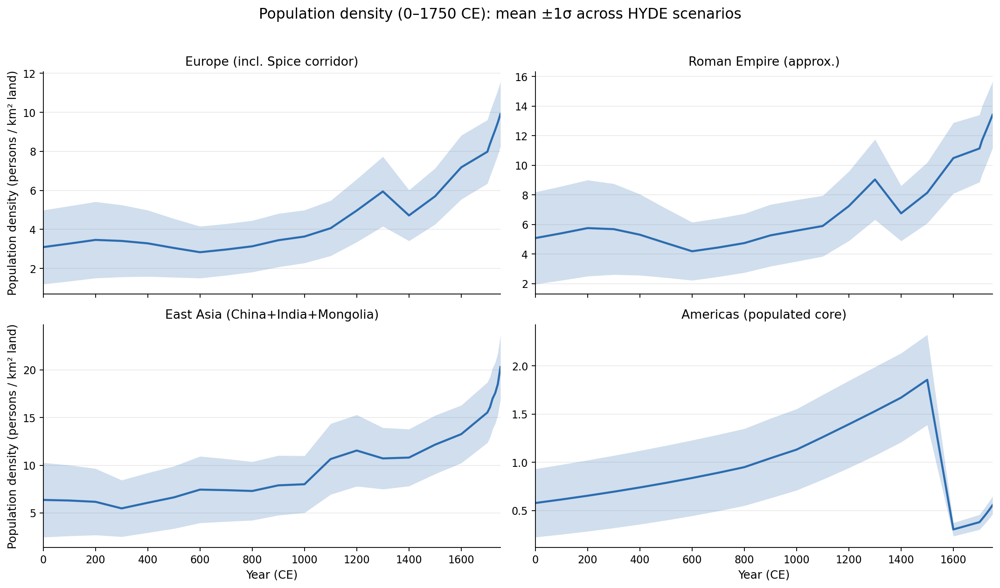

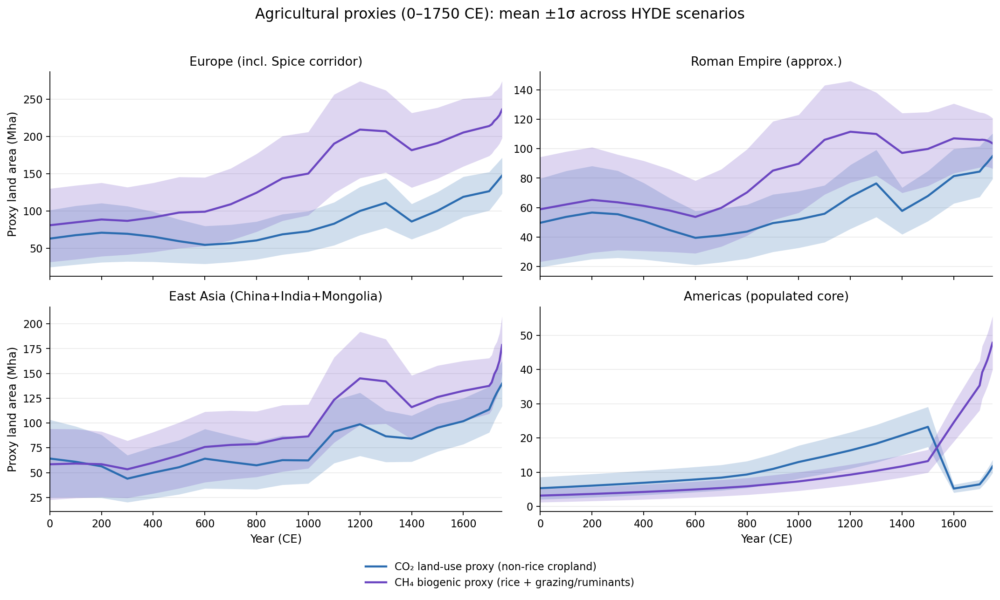

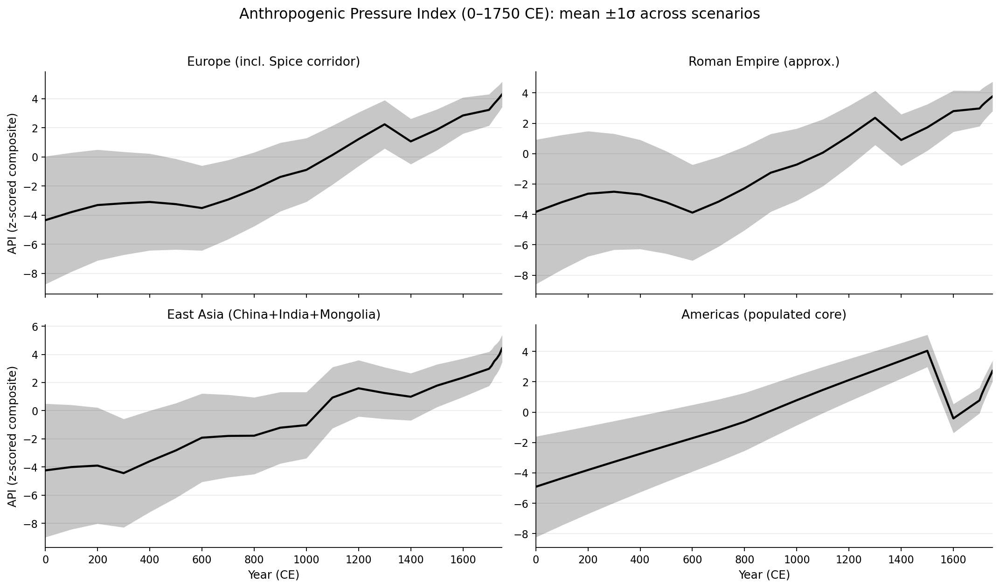

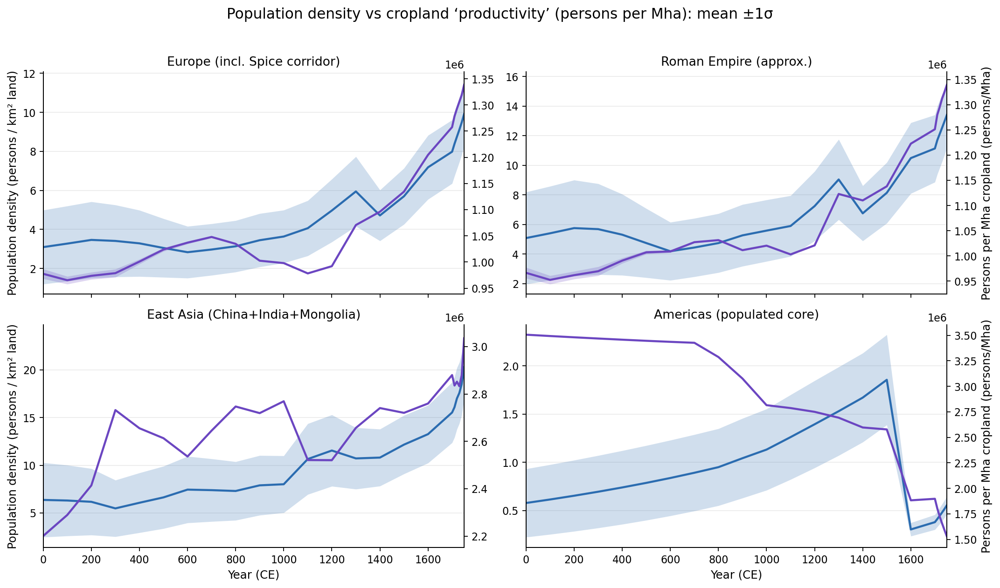

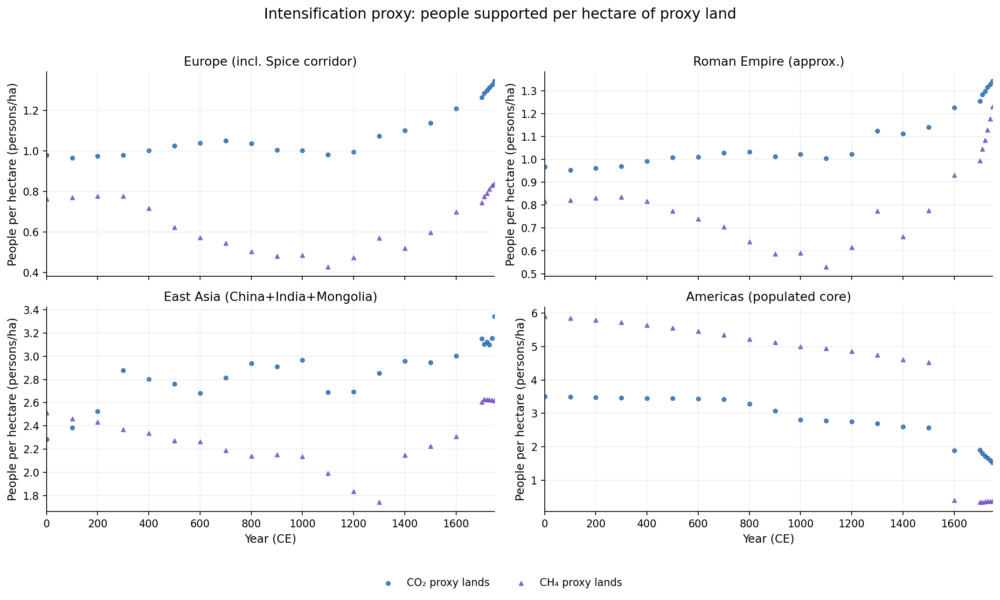

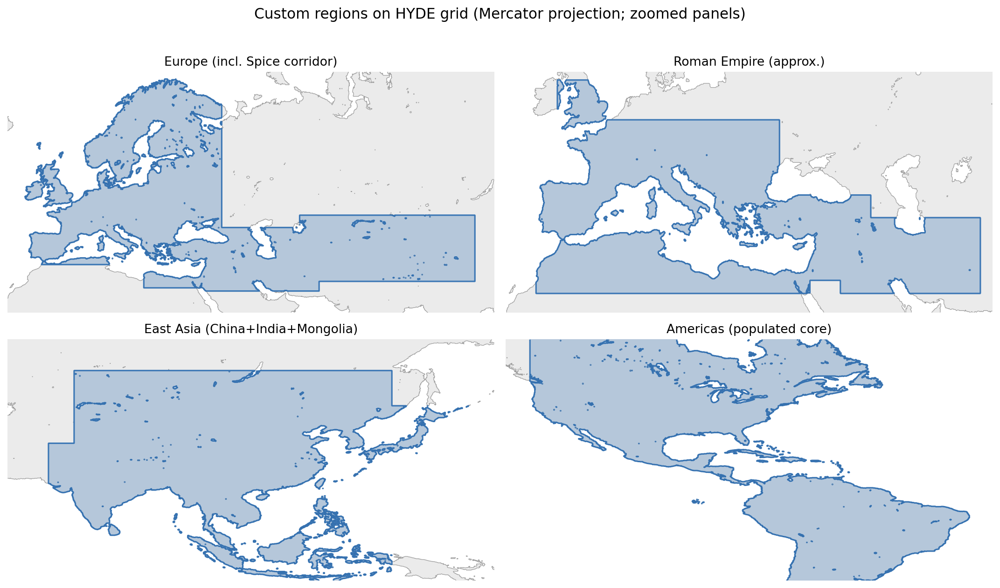


Wrote:
  hyde35_anthropogenic_region_year_by_scenario.csv
  hyde35_anthropogenic_region_year_mean_std.csv


In [4]:
# hyde35_anthropogenic_regions_dualy.py
# HYDE 3.5 (0–1750 CE): Custom regions + population density + CH4/CO2 land-use proxies
# + anthropogenic pressure metrics + dual-y plot:
#       population density  vs  "labor productivity" = persons per Mha of total cropland
#
# Plug-and-run:
#   1) cd into your HYDE 3.5 root directory (contains gbc2025_* scenario folders + general_files/)
#   2) python hyde35_anthropogenic_regions_dualy.py
#
# Outputs:
#   - Figures:
#       A) Pop density (mean±1σ)
#       B) CO2/CH4 proxy land areas (mean±1σ)
#       C) Anthropogenic Pressure Index (API) (mean±1σ)
#       D) Dual-y: Pop density (left) vs persons per Mha cropland (right) (mean±1σ)
#       E) Productivity scatter: people per hectare of proxy land (CO2 vs CH4) over time
#       F) Mercator region maps (2×2)
#   - CSVs:
#       hyde35_anthropogenic_region_year_by_scenario.csv
#       hyde35_anthropogenic_region_year_mean_std.csv
#
# Key definitions:
#   - Total cropland (Mha) = rice + non-rice cropland  (proxy for "harvested area")
#   - "Labor productivity" proxy requested = persons per Mha of total cropland
#       = pop_total / total_cropland_mha   [persons / Mha]
#
# Notes:
#   - Robust to lon 0..360 vs -180..180 by doing comparisons in lon180 space but keeping original lon coords.
#   - East Asia region expanded to include all China, India, and Mongolia (approximate boxes).
#   - Handles missing optional files (urban_population.nc, urban_area.nc, etc.).

from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ----------------------------
# User config
# ----------------------------
START_YEAR = 0
END_YEAR = 1750

SPICE_LON_MAX = 105  # degrees East in [-180,180) convention

REGION_ORDER = [
    "Europe (incl. Spice corridor)",
    "Roman Empire (approx.)",
    "East Asia (China+India+Mongolia)",
    "Americas (populated core)",
]

CLASS_CO2 = "CO₂ land-use proxy (non-rice cropland)"
CLASS_CH4 = "CH₄ biogenic proxy (rice + grazing/ruminants)"

BLUE = "#2b6cb0"
PURPLE = "#6b46c1"
SHADE_ALPHA = 0.22

plt.rcParams.update(
    {
        "figure.dpi": 160,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

# ----------------------------
# File discovery (HYDE 3.5 nested general_files)
# ----------------------------
def _first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p.exists():
            return p
    return None


def find_general_file(root: Path, filename: str) -> Path:
    candidates = [
        root / "general_files" / "general_files" / filename,
        root / "general_files" / filename,
        root / filename,
    ]
    hit = _first_existing(candidates)
    if hit:
        return hit

    gf = root / "general_files"
    if gf.exists():
        hits = list(gf.rglob(filename))
        if hits:
            return hits[0]

    hits = list(root.rglob(filename))
    if hits:
        return hits[0]

    raise FileNotFoundError(f"Could not find '{filename}' under {root}.")


# ----------------------------
# Scenario discovery
# ----------------------------
def discover_scenarios(root: Path) -> List[Tuple[str, Path]]:
    pop_files = sorted(root.glob("*/NetCDF/population.nc"))
    out: List[Tuple[str, Path]] = []
    for pop_nc in pop_files:
        scen_dir = pop_nc.parent.parent
        label = scen_dir.name
        m = re.search(r"(base|lower|upper)", label, flags=re.IGNORECASE)
        if m:
            label = m.group(1).lower()
        out.append((label, scen_dir))

    order = {"base": 0, "lower": 1, "upper": 2}
    out.sort(key=lambda t: (order.get(t[0], 99), t[0]))
    return out


# ----------------------------
# Lat/lon standardization
# ----------------------------
def ensure_latlon(ds: xr.Dataset) -> xr.Dataset:
    rename: Dict[str, str] = {}
    for name in list(ds.dims) + list(ds.coords):
        low = name.lower()
        if low in ("latitude", "nav_lat", "y") and "lat" not in ds.dims and "lat" not in ds.coords:
            rename[name] = "lat"
        if low in ("longitude", "nav_lon", "x") and "lon" not in ds.dims and "lon" not in ds.coords:
            rename[name] = "lon"
    if rename:
        ds = ds.rename(rename)

    if "lat" not in ds.coords:
        if "lat" in ds.dims:
            ds = ds.assign_coords(lat=ds["lat"])
        else:
            raise ValueError(f"Dataset missing 'lat'. dims={ds.dims}, coords={list(ds.coords)}")
    if "lon" not in ds.coords:
        if "lon" in ds.dims:
            ds = ds.assign_coords(lon=ds["lon"])
        else:
            raise ValueError(f"Dataset missing 'lon'. dims={ds.dims}, coords={list(ds.coords)}")
    return ds


# ----------------------------
# ESRI ASCII reader + alignment
# ----------------------------
def read_esri_ascii_grid(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing ASCII grid: {path}")

    header: Dict[str, float] = {}
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(6):
            line = f.readline()
            if not line:
                raise ValueError(f"Unexpected EOF reading header of {path}")
            k, v = line.strip().split()[:2]
            header[k.lower()] = float(v) if ("." in v or "e" in v.lower()) else int(v)
        data = np.loadtxt(f)

    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    cell = float(header["cellsize"])

    if data.shape != (nrows, ncols):
        raise ValueError(f"{path}: header says ({nrows},{ncols}) but data is {data.shape}")

    if "xllcorner" in header:
        xll = float(header["xllcorner"])
    elif "xllcenter" in header:
        xll = float(header["xllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing xllcorner/xllcenter")

    if "yllcorner" in header:
        yll = float(header["yllcorner"])
    elif "yllcenter" in header:
        yll = float(header["yllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing yllcorner/yllcenter")

    nodata = header.get("nodata_value", None)

    lon = xll + cell * (0.5 + np.arange(ncols))
    lat = yll + cell * (nrows - 0.5 - np.arange(nrows))  # north->south

    da = xr.DataArray(data, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name=path.stem)
    if nodata is not None:
        da = da.where(da != nodata)
    return da


def _lon_to_180_vals(lon_vals: np.ndarray) -> np.ndarray:
    lon_vals = np.asarray(lon_vals, dtype=float)
    return (((lon_vals + 180.0) % 360.0) - 180.0)


def normalize_longitudes_to_match(da: xr.DataArray, target_lon: xr.DataArray) -> xr.DataArray:
    da = da.copy()
    lon_da = da["lon"].values
    lon_t = target_lon.values
    tmin = float(np.nanmin(lon_t))

    # target is [0,360)
    if tmin >= 0 and np.nanmin(lon_da) < 0:
        da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon")

    # target is [-180,180)
    if tmin < 0 and np.nanmin(lon_da) >= 0:
        da = da.assign_coords(lon=_lon_to_180_vals(da["lon"].values)).sortby("lon")

    return da


def align_grid_to_dataset(da: xr.DataArray, ds_template: xr.Dataset) -> xr.DataArray:
    da2 = normalize_longitudes_to_match(da, ds_template["lon"])
    return da2.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")


# ----------------------------
# NetCDF open + year handling
# ----------------------------
def open_single_var_nc(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing NetCDF: {path}")

    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    engines = [None, "netcdf4", "h5netcdf"]
    last_err = None

    for eng in engines:
        for use_chunks in (True, False):
            try:
                kw = dict(decode_times=time_coder, cache=False)
                if use_chunks:
                    kw["chunks"] = {"time": 1}
                ds = xr.open_dataset(path, engine=eng, **kw) if eng else xr.open_dataset(path, **kw)
                ds = ensure_latlon(ds)

                data_vars = list(ds.data_vars)
                if not data_vars:
                    raise ValueError(f"No data variables in {path}")

                if len(data_vars) == 1:
                    return ds[data_vars[0]]

                stem = path.stem.lower()
                for v in data_vars:
                    if stem in v.lower():
                        return ds[v]
                return ds[data_vars[0]]
            except Exception as e:
                last_err = e
                continue

    raise OSError(f"Failed to open {path}. Last error: {last_err}")


def coerce_year_index(da: xr.DataArray) -> xr.DataArray:
    if "year" in da.coords:
        t = da["year"]
    elif "time" in da.coords:
        t = da["time"]
    else:
        raise ValueError("No 'time' or 'year' coordinate found.")

    try:
        years = t.dt.year.astype(int).values
    except Exception:
        vals = np.asarray(t.values)
        if vals.size and hasattr(vals.flat[0], "year"):
            years = np.array([v.year for v in vals.ravel()], dtype=int).reshape(vals.shape)
        else:
            years = np.rint(vals.astype(float)).astype(int)

    dim = t.dims[0] if t.dims else None
    if dim is None:
        da = da.assign_coords(year=years)
    else:
        da = da.assign_coords(year=(dim, years))
        if dim != "year" and np.unique(years).size == years.size:
            da = da.swap_dims({dim: "year"})
    return da


def subset_years(da: xr.DataArray, start_year: int, end_year: int) -> xr.DataArray:
    da = coerce_year_index(da)
    if "year" in da.dims:
        da = da.sortby("year")
        return da.sel(year=slice(start_year, end_year))
    if "year" in da.coords:
        mask = (da["year"] >= start_year) & (da["year"] <= end_year)
        return da.where(mask, drop=True)
    raise ValueError("No 'year' coordinate could be constructed.")


# ----------------------------
# Constant grids: cell area + land mask
# ----------------------------
def load_cell_area_km2(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    p = find_general_file(root, "garea_cr.asc")
    da = read_esri_ascii_grid(p)
    da = align_grid_to_dataset(da, ds_template)
    da.name = "cell_area_km2"
    return da


def load_land_mask_optional(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    try:
        p = find_general_file(root, "landlake.asc")
    except FileNotFoundError:
        p = None

    lat = ds_template["lat"].values
    lon = ds_template["lon"].values

    if p is None or not Path(p).exists():
        warnings.warn("landlake.asc not found. Treating all grid cells as land.")
        return xr.DataArray(
            np.ones((lat.size, lon.size), dtype=float),
            dims=("lat", "lon"),
            coords={"lat": lat, "lon": lon},
            name="land_mask",
        )

    da = read_esri_ascii_grid(Path(p))
    da = align_grid_to_dataset(da, ds_template)
    lm = xr.where(da > 0, 1.0, 0.0).fillna(0.0)
    lm.name = "land_mask"

    frac_land = float(lm.mean().values)
    if frac_land < 0.01:
        warnings.warn("Aligned land mask has <1% land; using all-land fallback.")
        lm = xr.ones_like(lm)

    return lm


# ----------------------------
# Region masks (fixed for lon 0..360 datasets)
# ----------------------------
def build_region_masks(ds_template: xr.Dataset, land_mask: xr.DataArray) -> xr.DataArray:
    lat = ds_template["lat"]
    lon = ds_template["lon"]

    lon180_vals = _lon_to_180_vals(lon.values)
    lon180 = xr.DataArray(lon180_vals, dims=("lon",), coords={"lon": lon.values})

    LON180, LAT = xr.broadcast(lon180, lat)
    LON180 = LON180.transpose("lat", "lon")
    LAT = LAT.transpose("lat", "lon")

    def in_box(lon_min, lon_max, lat_min, lat_max):
        return (LON180 >= lon_min) & (LON180 <= lon_max) & (LAT >= lat_min) & (LAT <= lat_max)

    # Exclusions (as before)
    sahara = in_box(-17, 35, 15, 28)
    arabia = in_box(34, 60, 12, 27)
    exclude = sahara | arabia

    # 1) Europe + Spice corridor
    europe_core = in_box(-12, 40, 35, 72)
    spice_near_east = in_box(20, 65, 27, 45)
    spice_central_asia = in_box(60, SPICE_LON_MAX, 30, 48)
    europe = europe_core | (spice_near_east | spice_central_asia)

    # 2) Roman Empire (approx.)
    roman_west = in_box(-10, 30, 35, 51)
    roman_balkans = in_box(10, 30, 35, 46)
    roman_anatolia = in_box(20, 45, 34, 42)
    roman_levant = in_box(30, 42, 30, 38)
    roman_n_africa_coast = in_box(-10, 35, 28, 37)
    roman_iraq_iran = in_box(40, 63, 28, 39)
    roman_britain = in_box(-6.5, 2.5, 49.5, 55.2)
    roman = (
        roman_west | roman_balkans | roman_anatolia | roman_levant
        | roman_n_africa_coast | roman_iraq_iran | roman_britain
    )

    # 3) East Asia expanded: China + India + Mongolia (approx boxes)
    # China (broader box to include all of China; includes Tibet/Xinjiang broadly)
    china = in_box(73, 135, 18, 54)

    # Mongolia (broad)
    mongolia = in_box(87, 120, 41, 53)

    # India (broad; includes most of the subcontinent)
    india = in_box(68, 97, 6, 36)

    # Korea+Japan / SE Asia additions (kept)
    korea_japan = in_box(120, 150, 30, 46)
    se_asia = in_box(95, 135, -10, 25)

    eastasia = china | mongolia | india | korea_japan | se_asia

    # 4) Americas core
    americas = in_box(-125, -30, -35, 60)

    def finalize(mask_bool: xr.DataArray) -> xr.DataArray:
        m = mask_bool & (~exclude)
        m = xr.where(m, 1.0, 0.0)
        return (m * land_mask).astype(float)

    masks = xr.concat(
        [finalize(europe), finalize(roman), finalize(eastasia), finalize(americas)],
        dim="region",
    )
    masks = masks.assign_coords(region=("region", REGION_ORDER))
    masks.name = "region_masks"
    return masks


# ----------------------------
# Land-use helpers
# ----------------------------
def _string_attr(da: xr.DataArray, key: str) -> str:
    return str(da.attrs.get(key, "")).strip().lower()


def _looks_like_fraction(da: xr.DataArray) -> bool:
    units = _string_attr(da, "units")
    long_name = _string_attr(da, "long_name") + " " + _string_attr(da, "standard_name")
    if ("frac" in units) or ("fraction" in units) or ("fraction" in long_name):
        return True
    if units in ("", "1", "-"):
        try:
            sample = da.isel(time=0) if "time" in da.dims else (da.isel(year=0) if "year" in da.dims else da)
            vmax = float(sample.max().values)
            vmin = float(sample.min().values)
            return (vmin >= -1e-6) and (vmax <= 1.5)
        except Exception:
            return False
    return False


def landuse_regional_mha(
    nc_path: Path,
    region_masks: xr.DataArray,
    cell_area_km2: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None

    try:
        da = open_single_var_nc(nc_path)
    except Exception as e:
        warnings.warn(f"Skipping unreadable NetCDF: {nc_path.name} | {e}")
        return None

    da = subset_years(da, start_year, end_year)

    units = _string_attr(da, "units")
    frac = _looks_like_fraction(da)

    if frac:
        da_mha = (da * cell_area_km2) / 1e4
    else:
        if "km" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e4
        elif units in ("ha", "hectare", "hectares"):
            da_mha = da / 1e6
        elif "m" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e10
        else:
            warnings.warn(f"{nc_path.name}: Unrecognized units '{da.attrs.get('units','')}'. Assuming km² -> Mha via /1e4.")
            da_mha = da / 1e4

    da_mha = da_mha.rename("area_mha")
    reg = (da_mha * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "Mha"
    return reg


# ----------------------------
# Population helpers
# ----------------------------
def population_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> xr.DataArray:
    da = open_single_var_nc(nc_path)
    da = subset_years(da, start_year, end_year)
    reg = (da * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "persons"
    return reg


def optional_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None
    try:
        return population_regional_persons(nc_path, region_masks, start_year, end_year)
    except Exception as e:
        warnings.warn(f"Could not read optional file {nc_path.name}: {e}")
        return None


# ----------------------------
# Stats + plotting helpers
# ----------------------------
def std0(x: pd.Series) -> float:
    return float(np.std(x.to_numpy(dtype=float), ddof=0))


def style_timeseries_ax(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)


def plot_mean_sigma(ax, x, mean, std, color, label=None):
    ax.plot(x, mean, color=color, linewidth=2.0, label=label)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=SHADE_ALPHA, linewidth=0)


def safe_log_series(s: pd.Series) -> pd.Series:
    v = s.to_numpy(dtype=float)
    v = np.where(np.isfinite(v) & (v > 0), v, np.nan)
    return pd.Series(np.log(v), index=s.index)


def zscore_by_group_safe(df: pd.DataFrame, col: str, group_cols: List[str]) -> pd.Series:
    if col not in df.columns:
        return pd.Series(np.zeros(len(df)), index=df.index, dtype=float)

    def _z(x: pd.Series) -> pd.Series:
        v = x.to_numpy(dtype=float)
        mu = np.nanmean(v)
        sd = np.nanstd(v)
        if not np.isfinite(sd) or sd == 0:
            return pd.Series(np.zeros_like(v), index=x.index)
        return (x - mu) / sd

    return df.groupby(group_cols, group_keys=False)[col].apply(_z)


# Mercator helpers (no cartopy)
def mercator_y(lat_deg: np.ndarray) -> np.ndarray:
    lat = np.asarray(lat_deg, dtype=float)
    lat = np.clip(lat, -85.0, 85.0)
    phi = np.deg2rad(lat)
    return np.log(np.tan(np.pi / 4.0 + phi / 2.0))


def coord_edges_1d(coord: np.ndarray) -> np.ndarray:
    c = np.asarray(coord, dtype=float)
    if c.size < 2:
        raise ValueError("Need at least 2 points to compute edges.")
    d = np.diff(c)
    first = c[0] - d[0] / 2.0
    last = c[-1] + d[-1] / 2.0
    mid = c[:-1] + d / 2.0
    return np.concatenate([[first], mid, [last]])


def to_lon180_sorted(da: xr.DataArray) -> xr.DataArray:
    lon_vals = da["lon"].values
    lon180_vals = _lon_to_180_vals(lon_vals)
    return da.assign_coords(lon=lon180_vals).sortby("lon")


def sel_box_latlon(da: xr.DataArray, lon_min: float, lon_max: float, lat_min: float, lat_max: float) -> xr.DataArray:
    lat = da["lat"].values
    if lat[0] < lat[-1]:
        da2 = da.sel(lat=slice(lat_min, lat_max))
    else:
        da2 = da.sel(lat=slice(lat_max, lat_min))
    da2 = da2.sel(lon=slice(lon_min, lon_max))
    return da2.sortby("lat")


# ----------------------------
# MAIN
# ----------------------------
ROOT = Path(".").resolve()
scenarios = discover_scenarios(ROOT)
if not scenarios:
    raise RuntimeError(
        "No scenarios found. Expected folders like 'gbc2025_7apr_base' with 'NetCDF/population.nc'. "
        "Run from the HYDE 3.5 root directory."
    )

print("Found scenarios:", ", ".join([f"{lab}:{p.name}" for lab, p in scenarios]))

template_label, template_dir = scenarios[0]
template_ds = xr.open_dataset(template_dir / "NetCDF" / "population.nc")
template_ds = ensure_latlon(template_ds)

print(f"Template lon range: {float(template_ds['lon'].min()):.3f} .. {float(template_ds['lon'].max()):.3f}")
print(f"Template lat range: {float(template_ds['lat'].min()):.3f} .. {float(template_ds['lat'].max()):.3f}")

cell_area_km2 = load_cell_area_km2(ROOT, template_ds)
land_mask = load_land_mask_optional(ROOT, template_ds)
region_masks = build_region_masks(template_ds, land_mask)

land_area_reg_km2 = (cell_area_km2 * region_masks).sum(dim=("lat", "lon"), skipna=True).rename("land_area_km2").astype(float)
print("\nLand area by region (km²):")
print(land_area_reg_km2.to_dataframe().reset_index())

if float(land_area_reg_km2.max().values) <= 0:
    raise RuntimeError("All region land areas are zero. Masks are not aligning with NetCDF lon/lat.")

pop_rows: List[pd.DataFrame] = []
ag_rows: List[pd.DataFrame] = []
extra_rows: List[pd.DataFrame] = []

for scen_label, scen_dir in scenarios:
    print(f"Processing scenario: {scen_label} ({scen_dir.name})")

    # Population totals
    pop_reg = population_regional_persons(scen_dir / "NetCDF" / "population.nc", region_masks, START_YEAR, END_YEAR)

    # Optional urban population and urban area
    urb_pop_reg = optional_regional_persons(scen_dir / "NetCDF" / "urban_population.nc", region_masks, START_YEAR, END_YEAR)
    urb_area_reg = landuse_regional_mha(scen_dir / "NetCDF" / "urban_area.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    # Density
    dens = (pop_reg / xr.where(land_area_reg_km2 > 0, land_area_reg_km2, np.nan)).rename("pop_density_p_km2")

    dens_df = dens.to_dataframe(name="pop_density_p_km2").reset_index()
    dens_df["scenario"] = scen_label

    pop_df = pop_reg.to_dataframe(name="pop_total").reset_index()
    pop_df["scenario"] = scen_label

    # Urban merge
    if urb_pop_reg is not None:
        up = urb_pop_reg.to_dataframe(name="urban_pop").reset_index()
        up["scenario"] = scen_label
        base = pop_df.merge(up, on=["year", "region", "scenario"], how="left")
        base["urban_share"] = base["urban_pop"] / base["pop_total"]
    else:
        base = pop_df.copy()
        base["urban_pop"] = np.nan
        base["urban_share"] = np.nan

    if urb_area_reg is not None:
        ua = urb_area_reg.to_dataframe(name="urban_area_mha").reset_index()
        ua["scenario"] = scen_label
        base = base.merge(ua, on=["year", "region", "scenario"], how="left")
    else:
        base["urban_area_mha"] = np.nan

    base = base.merge(
        dens_df[["scenario", "year", "region", "pop_density_p_km2"]],
        on=["scenario", "year", "region"],
        how="left",
    )

    pop_rows.append(
        base[
            [
                "scenario",
                "year",
                "region",
                "pop_total",
                "pop_density_p_km2",
                "urban_pop",
                "urban_share",
                "urban_area_mha",
            ]
        ]
    )

    # -------- Land-use proxies --------
    rice_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    rice_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (rice_rf is not None) or (rice_ir is not None):
        rice_reg = (0 if rice_rf is None else rice_rf.fillna(0)) + (0 if rice_ir is None else rice_ir.fillna(0))
    else:
        rice_reg = landuse_regional_mha(scen_dir / "NetCDF" / "total_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    grazing_reg = landuse_regional_mha(scen_dir / "NetCDF" / "grazing_land.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if grazing_reg is None:
        pasture_reg = landuse_regional_mha(scen_dir / "NetCDF" / "pasture.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        rangeland_reg = landuse_regional_mha(scen_dir / "NetCDF" / "rangeland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if (pasture_reg is not None) or (rangeland_reg is not None):
            grazing_reg = (0 if pasture_reg is None else pasture_reg.fillna(0)) + (0 if rangeland_reg is None else rangeland_reg.fillna(0))

    nr_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    nr_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (nr_rf is not None) or (nr_ir is not None):
        nonrice_reg = (0 if nr_rf is None else nr_rf.fillna(0)) + (0 if nr_ir is None else nr_ir.fillna(0))
    else:
        cropt = landuse_regional_mha(scen_dir / "NetCDF" / "cropland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if cropt is not None and rice_reg is not None:
            nonrice_reg = (cropt - rice_reg.fillna(0)).clip(min=0)
            warnings.warn(f"{scen_dir.name}: Using cropland.nc minus rice as non-rice cropland fallback.")
        elif cropt is not None:
            nonrice_reg = cropt
            warnings.warn(f"{scen_dir.name}: Using cropland.nc as non-rice cropland fallback (rice unavailable).")
        else:
            nonrice_reg = None

    # Total cropland (Mha) = rice + non-rice
    if (rice_reg is not None) or (nonrice_reg is not None):
        rr = 0 if rice_reg is None else rice_reg.fillna(0)
        nn = 0 if nonrice_reg is None else nonrice_reg.fillna(0)
        total_cropland_mha = (rr + nn).rename("total_cropland_mha")
    else:
        total_cropland_mha = None

    # CH4 proxy = rice + grazing
    ch4_reg = None
    if (rice_reg is not None) or (grazing_reg is not None):
        r = 0 if rice_reg is None else rice_reg.fillna(0)
        g = 0 if grazing_reg is None else grazing_reg.fillna(0)
        ch4_reg = r + g
        df = ch4_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CH4
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # CO2 proxy = non-rice cropland
    co2_reg = None
    if nonrice_reg is not None:
        co2_reg = nonrice_reg
        df = co2_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CO2
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # -------- Scenario-level derived objects --------
    P = pop_df.copy()

    if ch4_reg is not None:
        T = ch4_reg.to_dataframe(name="ch4_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "ch4_mha"]], on=["scenario", "year", "region"], how="left")
    else:
        P["ch4_mha"] = np.nan

    if co2_reg is not None:
        T = co2_reg.to_dataframe(name="co2_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "co2_mha"]], on=["scenario", "year", "region"], how="left")
    else:
        P["co2_mha"] = np.nan

    if total_cropland_mha is not None:
        T = total_cropland_mha.to_dataframe(name="total_cropland_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "total_cropland_mha"]],
                    on=["scenario", "year", "region"], how="left")
    else:
        P["total_cropland_mha"] = np.nan

    land_mha_df = (land_area_reg_km2 / 1e4).to_dataframe(name="land_mha").reset_index()
    P = P.merge(land_mha_df, on=["region"], how="left")

    # Intensification proxies
    P["co2_people_per_ha"] = P["pop_total"] / (P["co2_mha"] * 1e6)   # persons/ha
    P["ch4_people_per_ha"] = P["pop_total"] / (P["ch4_mha"] * 1e6)   # persons/ha

    P["co2_mha_per_million"] = P["co2_mha"] / (P["pop_total"] / 1e6)
    P["ch4_mha_per_million"] = P["ch4_mha"] / (P["pop_total"] / 1e6)

    P["co2_share_of_land"] = P["co2_mha"] / P["land_mha"]
    P["ch4_share_of_land"] = P["ch4_mha"] / P["land_mha"]

    # Requested productivity correction: persons per Mha of total cropland
    # persons/Mha = persons / (million ha)
    P["persons_per_mha_cropland"] = P["pop_total"] / P["total_cropland_mha"]

    # Growth rates (log diffs) by region
    P = P.sort_values(["region", "year"]).reset_index(drop=True)
    for col in ["pop_total", "co2_mha", "ch4_mha", "co2_share_of_land", "ch4_share_of_land"]:
        gcol = f"dlog_{col}"
        P[gcol] = np.nan
        for rname in REGION_ORDER:
            idx = (P["region"].to_numpy() == rname)
            x = P.loc[idx, col].to_numpy(dtype=float)
            x = np.where(np.isfinite(x) & (x > 0), x, np.nan)
            d = np.full_like(x, np.nan, dtype=float)
            if x.size >= 2:
                d[1:] = np.log(x[1:]) - np.log(x[:-1])
            P.loc[idx, gcol] = d

    extra_rows.append(
        P[
            [
                "scenario",
                "year",
                "region",
                "pop_total",
                "co2_mha",
                "ch4_mha",
                "land_mha",
                "total_cropland_mha",
                "persons_per_mha_cropland",
                "co2_people_per_ha",
                "ch4_people_per_ha",
                "co2_mha_per_million",
                "ch4_mha_per_million",
                "co2_share_of_land",
                "ch4_share_of_land",
                "dlog_pop_total",
                "dlog_co2_mha",
                "dlog_ch4_mha",
                "dlog_co2_share_of_land",
                "dlog_ch4_share_of_land",
            ]
        ]
    )

# Concatenate
pop_all = pd.concat(pop_rows, ignore_index=True)
ag_all = pd.concat(ag_rows, ignore_index=True) if ag_rows else pd.DataFrame(columns=["scenario", "year", "region", "class", "area_mha"])
extra_all = pd.concat(extra_rows, ignore_index=True) if extra_rows else pd.DataFrame()

# Across-scenario stats
popdens_stats = (
    pop_all.groupby(["year", "region"], as_index=False)
    .agg(mean=("pop_density_p_km2", "mean"), std=("pop_density_p_km2", std0))
)

ag_stats = (
    ag_all.groupby(["year", "region", "class"], as_index=False)
    .agg(mean=("area_mha", "mean"), std=("area_mha", std0))
)

extra_stats = (
    extra_all.groupby(["year", "region"], as_index=False)
    .agg(
        pop_mean=("pop_total", "mean"),
        pop_std=("pop_total", std0),
        co2_mha_mean=("co2_mha", "mean"),
        co2_mha_std=("co2_mha", std0),
        ch4_mha_mean=("ch4_mha", "mean"),
        ch4_mha_std=("ch4_mha", std0),
        total_cropland_mha_mean=("total_cropland_mha", "mean"),
        total_cropland_mha_std=("total_cropland_mha", std0),
        persons_per_mha_cropland_mean=("persons_per_mha_cropland", "mean"),
        persons_per_mha_cropland_std=("persons_per_mha_cropland", std0),
        co2_people_per_ha_mean=("co2_people_per_ha", "mean"),
        co2_people_per_ha_std=("co2_people_per_ha", std0),
        ch4_people_per_ha_mean=("ch4_people_per_ha", "mean"),
        ch4_people_per_ha_std=("ch4_people_per_ha", std0),
        co2_share_mean=("co2_share_of_land", "mean"),
        co2_share_std=("co2_share_of_land", std0),
        ch4_share_mean=("ch4_share_of_land", "mean"),
        ch4_share_std=("ch4_share_of_land", std0),
        dlog_pop_mean=("dlog_pop_total", "mean"),
        dlog_pop_std=("dlog_pop_total", std0),
        dlog_co2_mean=("dlog_co2_mha", "mean"),
        dlog_co2_std=("dlog_co2_mha", std0),
        dlog_ch4_mean=("dlog_ch4_mha", "mean"),
        dlog_ch4_std=("dlog_ch4_mha", std0),
    )
)

# ----------------------------
# API (Anthropogenic Pressure Index) — bulletproof
# ----------------------------
api_df = extra_all.merge(
    pop_all[["scenario", "year", "region", "urban_area_mha"]],
    on=["scenario", "year", "region"],
    how="left",
)

for c in ["pop_total", "co2_mha", "ch4_mha", "urban_area_mha"]:
    if c in api_df.columns:
        api_df[f"log_{c}"] = safe_log_series(api_df[c])

api_df["z_log_pop"] = zscore_by_group_safe(api_df, "log_pop_total", ["region"])
api_df["z_log_co2"] = zscore_by_group_safe(api_df, "log_co2_mha", ["region"])
api_df["z_log_ch4"] = zscore_by_group_safe(api_df, "log_ch4_mha", ["region"])
api_df["z_log_urban"] = zscore_by_group_safe(api_df, "log_urban_area_mha", ["region"])

api_df["API"] = api_df["z_log_pop"] + api_df["z_log_co2"] + api_df["z_log_ch4"] + api_df["z_log_urban"]

api_stats = (
    api_df.groupby(["year", "region"], as_index=False)
    .agg(API_mean=("API", "mean"), API_std=("API", std0))
)

print("\nPreview: extra_stats head")
print(extra_stats.head(10))
print("\nPreview: api_stats head")
print(api_stats.head(10))

# ----------------------------
# FIGURE A: Population density (mean±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, df["year"].to_numpy(), df["mean"].to_numpy(float), df["std"].to_numpy(float), color=BLUE)

axs[0].set_ylabel("Population density (persons / km² land)")
axs[2].set_ylabel("Population density (persons / km² land)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE B: Land-use proxies (mean±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)

    df_r = ag_stats[ag_stats["region"] == region]
    if df_r.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    d_co2 = df_r[df_r["class"] == CLASS_CO2].sort_values("year")
    if not d_co2.empty:
        plot_mean_sigma(ax, d_co2["year"].to_numpy(), d_co2["mean"].to_numpy(float), d_co2["std"].to_numpy(float),
                        color=BLUE, label=CLASS_CO2 if i == 0 else None)

    d_ch4 = df_r[df_r["class"] == CLASS_CH4].sort_values("year")
    if not d_ch4.empty:
        plot_mean_sigma(ax, d_ch4["year"].to_numpy(), d_ch4["mean"].to_numpy(float), d_ch4["std"].to_numpy(float),
                        color=PURPLE, label=CLASS_CH4 if i == 0 else None)

axs[0].set_ylabel("Proxy land area (Mha)")
axs[2].set_ylabel("Proxy land area (Mha)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Agricultural proxies (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=1, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE C: API index (mean±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = api_stats[api_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, df["year"].to_numpy(), df["API_mean"].to_numpy(float), df["API_std"].to_numpy(float), color="black")

axs[0].set_ylabel("API (z-scored composite)")
axs[2].set_ylabel("API (z-scored composite)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Anthropogenic Pressure Index (0–1750 CE): mean ±1σ across scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE D: Dual-y evolution (mean±1σ)
#   Left y: population density (persons/km² land)
#   Right y: persons per Mha of total cropland
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax2 = ax.twinx()

    d1 = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    d2 = extra_stats[extra_stats["region"] == region].sort_values("year")

    ax.set_title(region)
    ax.spines["top"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax2.spines["top"].set_visible(False)

    ax.set_xlim(START_YEAR, END_YEAR)

    if not d1.empty:
        plot_mean_sigma(
            ax,
            d1["year"].to_numpy(),
            d1["mean"].to_numpy(dtype=float),
            d1["std"].to_numpy(dtype=float),
            color=BLUE,
        )

    if not d2.empty:
        x = d2["year"].to_numpy()
        y = d2["persons_per_mha_cropland_mean"].to_numpy(dtype=float)
        s = d2["persons_per_mha_cropland_std"].to_numpy(dtype=float)

        ax2.plot(x, y, color=PURPLE, linewidth=2.0)
        ax2.fill_between(x, y - s, y + s, color=PURPLE, alpha=SHADE_ALPHA, linewidth=0)

    if i in (0, 2):
        ax.set_ylabel("Population density (persons / km² land)")
    if i in (1, 3):
        ax2.set_ylabel("Persons per Mha cropland (persons/Mha)")

axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density vs cropland ‘productivity’ (persons per Mha): mean ±1σ", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE E: Productivity scatter — people per hectare of proxy lands vs year
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = extra_stats[extra_stats["region"] == region].sort_values("year")
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    x = df["year"].to_numpy(dtype=float)
    y1 = df["co2_people_per_ha_mean"].to_numpy(dtype=float)
    y2 = df["ch4_people_per_ha_mean"].to_numpy(dtype=float)

    ax.scatter(x, y1, s=14, marker="o", alpha=0.85, color=BLUE, label="CO₂ proxy lands" if i == 0 else None)
    ax.scatter(x, y2, s=14, marker="^", alpha=0.75, color=PURPLE, label="CH₄ proxy lands" if i == 0 else None)

    ax.set_title(region)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.20)
    ax.set_xlim(START_YEAR, END_YEAR)
    ax.set_ylabel("People per hectare (persons/ha)")

axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Intensification proxy: people supported per hectare of proxy land", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE F: Mercator region maps (2×2)
# ----------------------------
MAP_EXTENTS = {
    "Europe (incl. Spice corridor)": (-15, SPICE_LON_MAX + 5, 20, 72),
    "Roman Empire (approx.)": (-15, 65, 25, 56),
    "East Asia (China+India+Mongolia)": (60, 155, -10, 60),
    "Americas (populated core)": (-130, -30, -35, 60),
}

land_plot = to_lon180_sorted(land_mask)
region_plot = to_lon180_sorted(region_masks)

land_cmap = ListedColormap([(1, 1, 1, 0), (0, 0, 0, 0.08)])
region_cmap = ListedColormap([(0, 0, 0, 0), (0.17, 0.42, 0.69, 0.28)])

fig, axs = plt.subplots(2, 2, figsize=(13.5, 8))
axs = axs.ravel()

for i, region_name in enumerate(REGION_ORDER):
    ax = axs[i]
    lon_min, lon_max, lat_min, lat_max = MAP_EXTENTS[region_name]

    land_sub = sel_box_latlon(land_plot, lon_min, lon_max, lat_min, lat_max)
    reg_sub = sel_box_latlon(region_plot.sel(region=region_name), lon_min, lon_max, lat_min, lat_max)

    lon = land_sub["lon"].values
    lat = land_sub["lat"].values
    lon_e = coord_edges_1d(lon)
    lat_e = coord_edges_1d(lat)
    y_e = mercator_y(lat_e)
    y = mercator_y(lat)

    ax.pcolormesh(lon_e, y_e, (land_sub.values > 0).astype(float), shading="auto", cmap=land_cmap)
    ax.pcolormesh(lon_e, y_e, reg_sub.values.astype(float), shading="auto", cmap=region_cmap)

    try:
        ax.contour(lon, y, (land_sub.values > 0).astype(float), levels=[0.5], colors="black", linewidths=0.6, alpha=0.35)
    except Exception:
        pass

    try:
        ax.contour(lon, y, reg_sub.values.astype(float), levels=[0.5], colors=BLUE, linewidths=1.4, alpha=0.9)
    except Exception:
        pass

    ax.set_title(region_name)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(mercator_y(lat_min), mercator_y(lat_max))
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig.suptitle("Custom regions on HYDE grid (Mercator projection; zoomed panels)", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# SAVE PANELS
# ----------------------------
panel_scenario = extra_all.merge(
    pop_all[["scenario", "year", "region", "pop_density_p_km2", "urban_share", "urban_area_mha"]],
    on=["scenario", "year", "region"],
    how="left",
)

panel_mean = extra_stats.merge(popdens_stats[["year", "region", "mean", "std"]], on=["year", "region"], how="left")
panel_mean = panel_mean.rename(columns={"mean": "popdens_mean", "std": "popdens_std"})
panel_mean = panel_mean.merge(api_stats, on=["year", "region"], how="left")

panel_scenario.to_csv("hyde35_anthropogenic_region_year_by_scenario.csv", index=False)
panel_mean.to_csv("hyde35_anthropogenic_region_year_mean_std.csv", index=False)

print("\nWrote:")
print("  hyde35_anthropogenic_region_year_by_scenario.csv")
print("  hyde35_anthropogenic_region_year_mean_std.csv")

Found scenarios: base:gbc2025_7apr_base, lower:gbc2025_7apr_lower, upper:gbc2025_7apr_upper
Template lon range: -179.958 .. 179.958
Template lat range: -89.958 .. 89.958

Land area by region (km²):
                          region  land_area_km2
0  Europe (incl. Spice corridor)   2.004120e+07
1         Roman Empire (approx.)   9.509715e+06
2      East Asia (China+SE Asia)   2.154530e+07
3      Americas (populated core)   3.229304e+07
Processing scenario: base (gbc2025_7apr_base)
Processing scenario: lower (gbc2025_7apr_lower)
Processing scenario: upper (gbc2025_7apr_upper)

Preview: extra_stats head
   year                         region  persons_per_mha_cropland_mean  \
0     0      Americas (populated core)                   3.506030e+06   
1     0      East Asia (China+SE Asia)                   2.118731e+06   
2     0  Europe (incl. Spice corridor)                   9.774473e+05   
3     0         Roman Empire (approx.)                   9.663753e+05   
4   100      Americas (popul

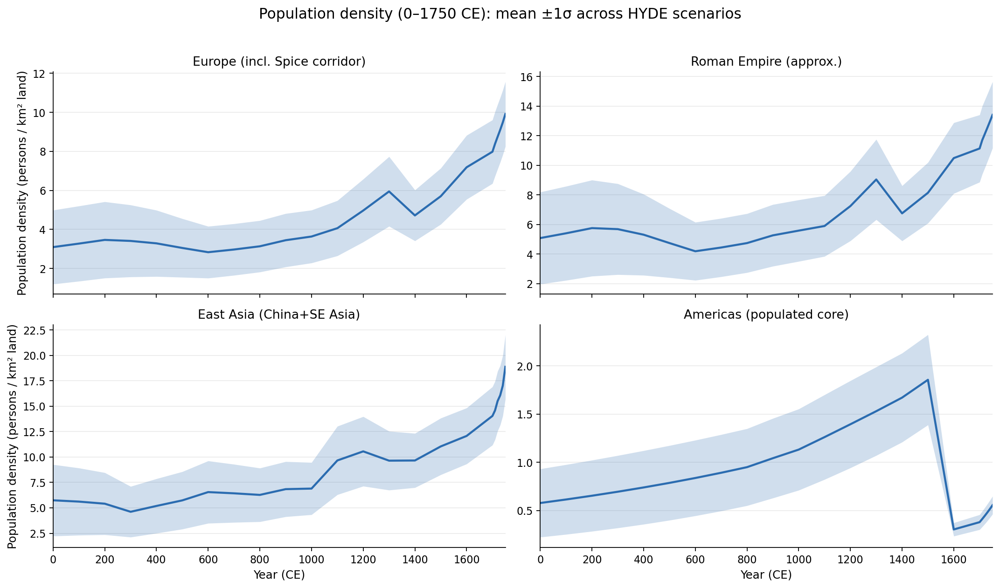

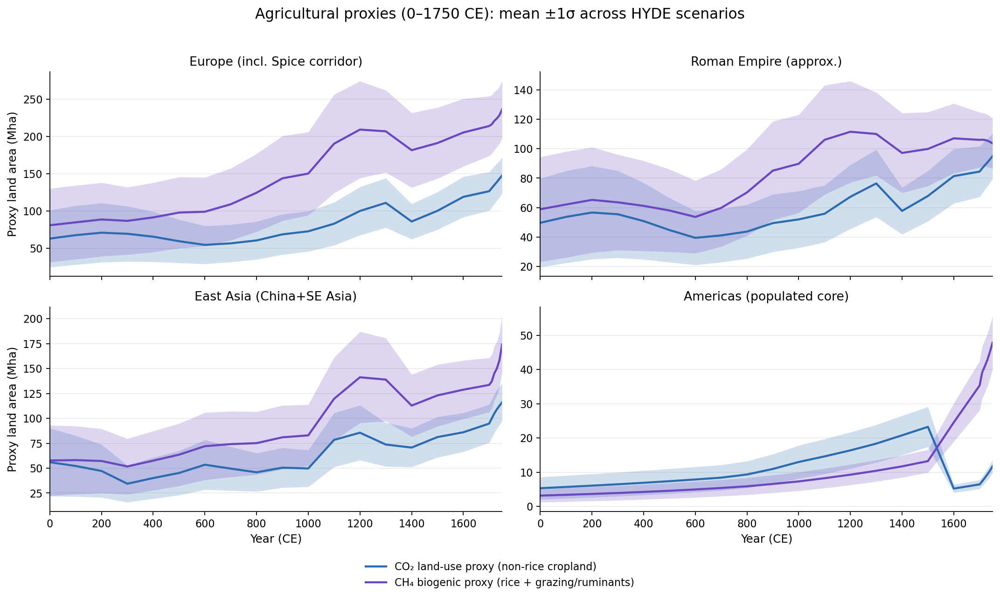

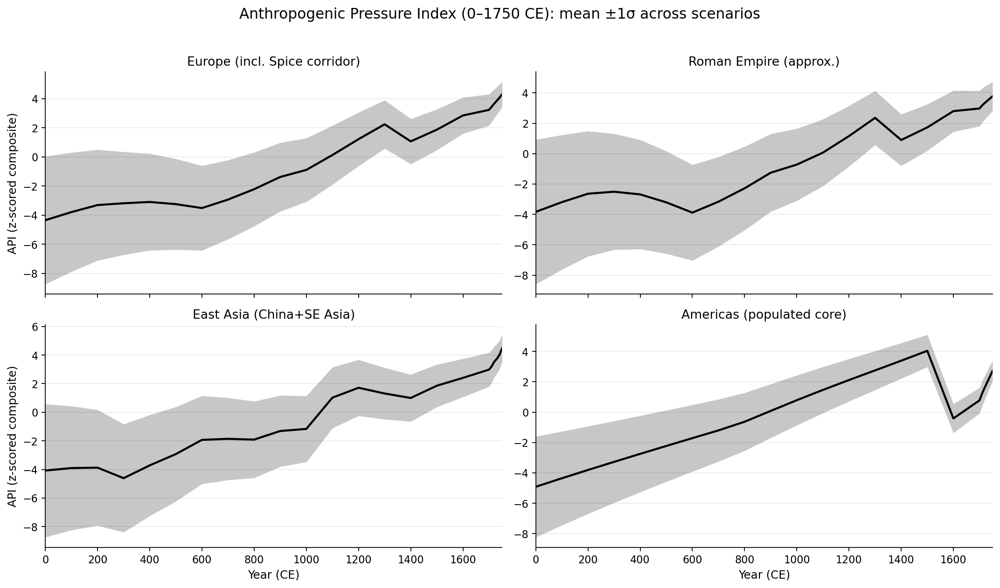

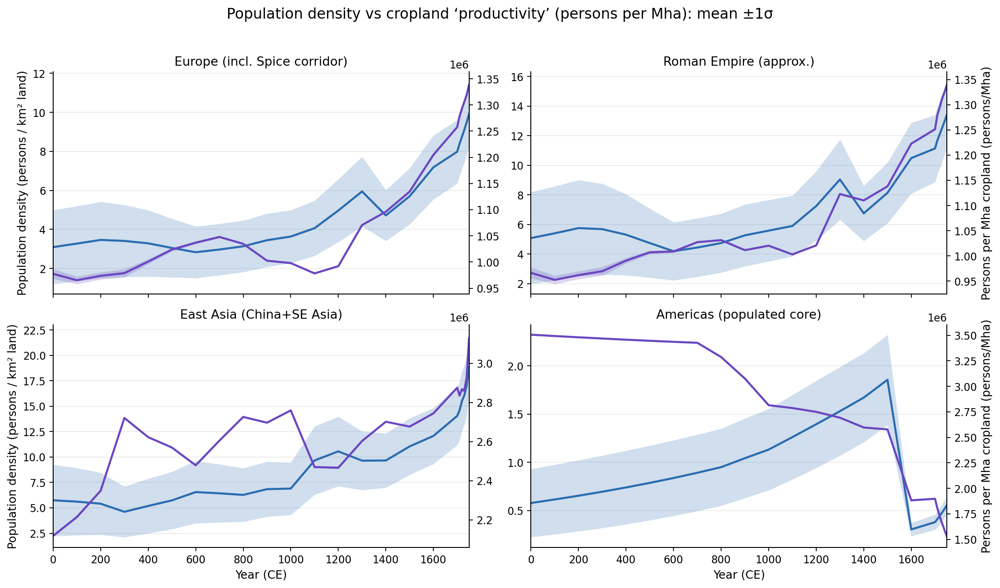

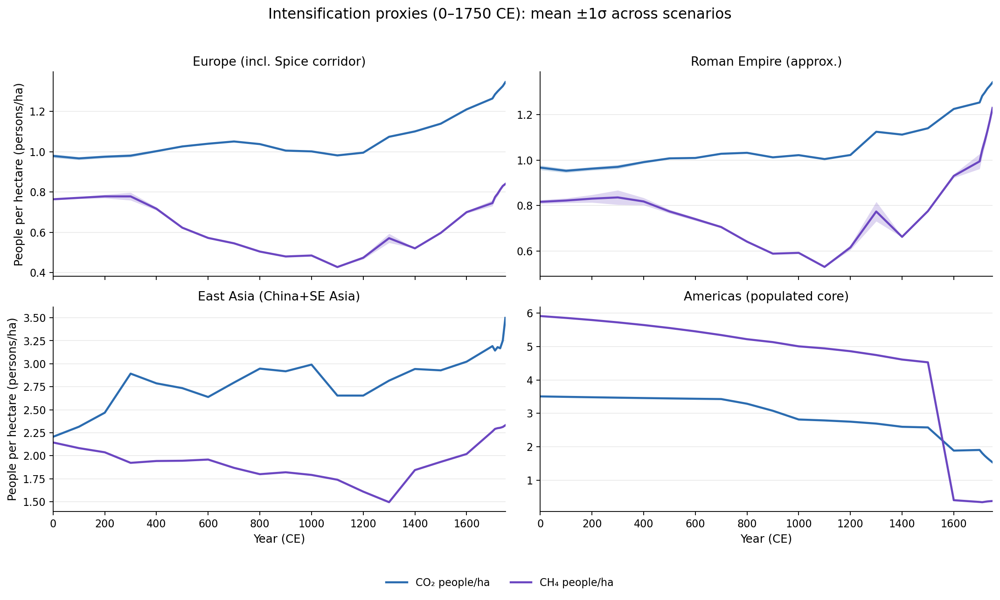

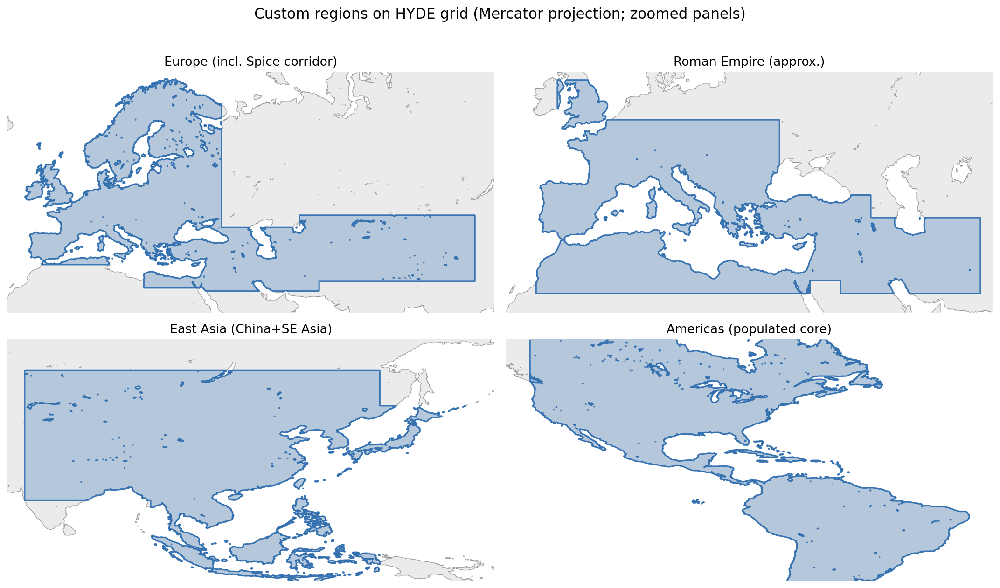


Wrote:
  hyde35_anthropogenic_region_year_by_scenario.csv
  hyde35_anthropogenic_region_year_mean_std.csv


In [5]:
# hyde35_anthropogenic_regions_dualy.py
# HYDE 3.5 (0–1750 CE): Custom regions + population density + CH4/CO2 land-use proxies
# + anthropogenic pressure metrics + dual-y plot:
#       population density  vs  "cropland productivity" = persons per Mha of total cropland
# + line plots (mean±1σ) for intensification proxies (CO2/CH4 people per hectare)
#
# Plug-and-run:
#   1) cd into your HYDE 3.5 root directory (contains gbc2025_* scenario folders + general_files/)
#   2) python hyde35_anthropogenic_regions_dualy.py
#
# Outputs:
#   - Figures:
#       A) Pop density (mean±1σ)
#       B) CO2/CH4 proxy land areas (mean±1σ)
#       C) Anthropogenic Pressure Index (API) (mean±1σ)
#       D) Dual-y: Pop density (left) vs persons per Mha cropland (right) (mean±1σ)
#       E) Intensification proxies (mean±1σ): people per hectare on CO2 proxy lands and CH4 proxy lands
#       F) Mercator region maps (2×2)
#   - CSVs:
#       hyde35_anthropogenic_region_year_by_scenario.csv
#       hyde35_anthropogenic_region_year_mean_std.csv
#
# Key definitions:
#   - CO2 proxy land = non-rice cropland (rainfed_not_rice + irrigated_not_rice; fallback cropland - rice)
#   - CH4 proxy land = rice + grazing land (ruminants proxy)
#   - Total cropland (Mha) = rice + non-rice cropland
#   - “Cropland productivity” requested = persons per Mha of total cropland = pop_total / total_cropland_mha
#   - Intensification proxies (line plots):
#       * CO2 people/ha = pop_total / (co2_mha * 1e6)
#       * CH4 people/ha = pop_total / (ch4_mha * 1e6)
#
# Notes:
#   - Robust to lon 0..360 vs -180..180 by doing comparisons in lon180 space but keeping original lon coords.
#   - East Asia region excludes India and Mongolia; includes China + Korea/Japan + SE Asia (broad).
#   - Standard deviations are computed across scenarios (base/lower/upper) using population std0 (ddof=0).

from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ----------------------------
# User config
# ----------------------------
START_YEAR = 0
END_YEAR = 1750

SPICE_LON_MAX = 105  # degrees East in [-180,180) convention

REGION_ORDER = [
    "Europe (incl. Spice corridor)",
    "Roman Empire (approx.)",
    "East Asia (China+SE Asia)",
    "Americas (populated core)",
]

CLASS_CO2 = "CO₂ land-use proxy (non-rice cropland)"
CLASS_CH4 = "CH₄ biogenic proxy (rice + grazing/ruminants)"

BLUE = "#2b6cb0"
PURPLE = "#6b46c1"
SHADE_ALPHA = 0.22

plt.rcParams.update(
    {
        "figure.dpi": 160,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

# ----------------------------
# File discovery (HYDE 3.5 nested general_files)
# ----------------------------
def _first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p.exists():
            return p
    return None


def find_general_file(root: Path, filename: str) -> Path:
    candidates = [
        root / "general_files" / "general_files" / filename,
        root / "general_files" / filename,
        root / filename,
    ]
    hit = _first_existing(candidates)
    if hit:
        return hit

    gf = root / "general_files"
    if gf.exists():
        hits = list(gf.rglob(filename))
        if hits:
            return hits[0]

    hits = list(root.rglob(filename))
    if hits:
        return hits[0]

    raise FileNotFoundError(f"Could not find '{filename}' under {root}.")


# ----------------------------
# Scenario discovery
# ----------------------------
def discover_scenarios(root: Path) -> List[Tuple[str, Path]]:
    pop_files = sorted(root.glob("*/NetCDF/population.nc"))
    out: List[Tuple[str, Path]] = []
    for pop_nc in pop_files:
        scen_dir = pop_nc.parent.parent
        label = scen_dir.name
        m = re.search(r"(base|lower|upper)", label, flags=re.IGNORECASE)
        if m:
            label = m.group(1).lower()
        out.append((label, scen_dir))

    order = {"base": 0, "lower": 1, "upper": 2}
    out.sort(key=lambda t: (order.get(t[0], 99), t[0]))
    return out


# ----------------------------
# Lat/lon standardization
# ----------------------------
def ensure_latlon(ds: xr.Dataset) -> xr.Dataset:
    rename: Dict[str, str] = {}
    for name in list(ds.dims) + list(ds.coords):
        low = name.lower()
        if low in ("latitude", "nav_lat", "y") and "lat" not in ds.dims and "lat" not in ds.coords:
            rename[name] = "lat"
        if low in ("longitude", "nav_lon", "x") and "lon" not in ds.dims and "lon" not in ds.coords:
            rename[name] = "lon"
    if rename:
        ds = ds.rename(rename)

    if "lat" not in ds.coords:
        if "lat" in ds.dims:
            ds = ds.assign_coords(lat=ds["lat"])
        else:
            raise ValueError(f"Dataset missing 'lat'. dims={ds.dims}, coords={list(ds.coords)}")
    if "lon" not in ds.coords:
        if "lon" in ds.dims:
            ds = ds.assign_coords(lon=ds["lon"])
        else:
            raise ValueError(f"Dataset missing 'lon'. dims={ds.dims}, coords={list(ds.coords)}")
    return ds


# ----------------------------
# ESRI ASCII reader + alignment
# ----------------------------
def read_esri_ascii_grid(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing ASCII grid: {path}")

    header: Dict[str, float] = {}
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(6):
            line = f.readline()
            if not line:
                raise ValueError(f"Unexpected EOF reading header of {path}")
            k, v = line.strip().split()[:2]
            header[k.lower()] = float(v) if ("." in v or "e" in v.lower()) else int(v)
        data = np.loadtxt(f)

    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    cell = float(header["cellsize"])

    if data.shape != (nrows, ncols):
        raise ValueError(f"{path}: header says ({nrows},{ncols}) but data is {data.shape}")

    if "xllcorner" in header:
        xll = float(header["xllcorner"])
    elif "xllcenter" in header:
        xll = float(header["xllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing xllcorner/xllcenter")

    if "yllcorner" in header:
        yll = float(header["yllcorner"])
    elif "yllcenter" in header:
        yll = float(header["yllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing yllcorner/yllcenter")

    nodata = header.get("nodata_value", None)

    lon = xll + cell * (0.5 + np.arange(ncols))
    lat = yll + cell * (nrows - 0.5 - np.arange(nrows))  # north->south

    da = xr.DataArray(data, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name=path.stem)
    if nodata is not None:
        da = da.where(da != nodata)
    return da


def _lon_to_180_vals(lon_vals: np.ndarray) -> np.ndarray:
    lon_vals = np.asarray(lon_vals, dtype=float)
    return (((lon_vals + 180.0) % 360.0) - 180.0)


def normalize_longitudes_to_match(da: xr.DataArray, target_lon: xr.DataArray) -> xr.DataArray:
    da = da.copy()
    lon_da = da["lon"].values
    lon_t = target_lon.values
    tmin = float(np.nanmin(lon_t))

    # target is [0,360)
    if tmin >= 0 and np.nanmin(lon_da) < 0:
        da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon")

    # target is [-180,180)
    if tmin < 0 and np.nanmin(lon_da) >= 0:
        da = da.assign_coords(lon=_lon_to_180_vals(da["lon"].values)).sortby("lon")

    return da


def align_grid_to_dataset(da: xr.DataArray, ds_template: xr.Dataset) -> xr.DataArray:
    da2 = normalize_longitudes_to_match(da, ds_template["lon"])
    return da2.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")


# ----------------------------
# NetCDF open + year handling
# ----------------------------
def open_single_var_nc(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing NetCDF: {path}")

    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    engines = [None, "netcdf4", "h5netcdf"]
    last_err = None

    for eng in engines:
        for use_chunks in (True, False):
            try:
                kw = dict(decode_times=time_coder, cache=False)
                if use_chunks:
                    kw["chunks"] = {"time": 1}
                ds = xr.open_dataset(path, engine=eng, **kw) if eng else xr.open_dataset(path, **kw)
                ds = ensure_latlon(ds)

                data_vars = list(ds.data_vars)
                if not data_vars:
                    raise ValueError(f"No data variables in {path}")

                if len(data_vars) == 1:
                    return ds[data_vars[0]]

                stem = path.stem.lower()
                for v in data_vars:
                    if stem in v.lower():
                        return ds[v]
                return ds[data_vars[0]]
            except Exception as e:
                last_err = e
                continue

    raise OSError(f"Failed to open {path}. Last error: {last_err}")


def coerce_year_index(da: xr.DataArray) -> xr.DataArray:
    if "year" in da.coords:
        t = da["year"]
    elif "time" in da.coords:
        t = da["time"]
    else:
        raise ValueError("No 'time' or 'year' coordinate found.")

    try:
        years = t.dt.year.astype(int).values
    except Exception:
        vals = np.asarray(t.values)
        if vals.size and hasattr(vals.flat[0], "year"):
            years = np.array([v.year for v in vals.ravel()], dtype=int).reshape(vals.shape)
        else:
            years = np.rint(vals.astype(float)).astype(int)

    dim = t.dims[0] if t.dims else None
    if dim is None:
        da = da.assign_coords(year=years)
    else:
        da = da.assign_coords(year=(dim, years))
        if dim != "year" and np.unique(years).size == years.size:
            da = da.swap_dims({dim: "year"})
    return da


def subset_years(da: xr.DataArray, start_year: int, end_year: int) -> xr.DataArray:
    da = coerce_year_index(da)
    if "year" in da.dims:
        da = da.sortby("year")
        return da.sel(year=slice(start_year, end_year))
    if "year" in da.coords:
        mask = (da["year"] >= start_year) & (da["year"] <= end_year)
        return da.where(mask, drop=True)
    raise ValueError("No 'year' coordinate could be constructed.")


# ----------------------------
# Constant grids: cell area + land mask
# ----------------------------
def load_cell_area_km2(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    p = find_general_file(root, "garea_cr.asc")
    da = read_esri_ascii_grid(p)
    da = align_grid_to_dataset(da, ds_template)
    da.name = "cell_area_km2"
    return da


def load_land_mask_optional(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    try:
        p = find_general_file(root, "landlake.asc")
    except FileNotFoundError:
        p = None

    lat = ds_template["lat"].values
    lon = ds_template["lon"].values

    if p is None or not Path(p).exists():
        warnings.warn("landlake.asc not found. Treating all grid cells as land.")
        return xr.DataArray(
            np.ones((lat.size, lon.size), dtype=float),
            dims=("lat", "lon"),
            coords={"lat": lat, "lon": lon},
            name="land_mask",
        )

    da = read_esri_ascii_grid(Path(p))
    da = align_grid_to_dataset(da, ds_template)
    lm = xr.where(da > 0, 1.0, 0.0).fillna(0.0)
    lm.name = "land_mask"

    frac_land = float(lm.mean().values)
    if frac_land < 0.01:
        warnings.warn("Aligned land mask has <1% land; using all-land fallback.")
        lm = xr.ones_like(lm)

    return lm


# ----------------------------
# Region masks (fixed for lon 0..360 datasets)
# ----------------------------
def build_region_masks(ds_template: xr.Dataset, land_mask: xr.DataArray) -> xr.DataArray:
    lat = ds_template["lat"]
    lon = ds_template["lon"]

    lon180_vals = _lon_to_180_vals(lon.values)
    lon180 = xr.DataArray(lon180_vals, dims=("lon",), coords={"lon": lon.values})

    LON180, LAT = xr.broadcast(lon180, lat)
    LON180 = LON180.transpose("lat", "lon")
    LAT = LAT.transpose("lat", "lon")

    def in_box(lon_min, lon_max, lat_min, lat_max):
        return (LON180 >= lon_min) & (LON180 <= lon_max) & (LAT >= lat_min) & (LAT <= lat_max)

    # Exclusions
    sahara = in_box(-17, 35, 15, 28)
    arabia = in_box(34, 60, 12, 27)
    exclude = sahara | arabia

    # 1) Europe + Spice corridor
    europe_core = in_box(-12, 40, 35, 72)
    spice_near_east = in_box(20, 65, 27, 45)
    spice_central_asia = in_box(60, SPICE_LON_MAX, 30, 48)
    europe = europe_core | (spice_near_east | spice_central_asia)

    # 2) Roman Empire (approx.)
    roman_west = in_box(-10, 30, 35, 51)
    roman_balkans = in_box(10, 30, 35, 46)
    roman_anatolia = in_box(20, 45, 34, 42)
    roman_levant = in_box(30, 42, 30, 38)
    roman_n_africa_coast = in_box(-10, 35, 28, 37)
    roman_iraq_iran = in_box(40, 63, 28, 39)
    roman_britain = in_box(-6.5, 2.5, 49.5, 55.2)
    roman = (
        roman_west | roman_balkans | roman_anatolia | roman_levant
        | roman_n_africa_coast | roman_iraq_iran | roman_britain
    )

    # 3) East Asia (China + SE Asia + Korea/Japan), excluding India and Mongolia
    # Broad China (includes Tibet/Xinjiang broadly)
    china = in_box(73, 135, 18, 54)
    korea_japan = in_box(120, 150, 30, 46)
    se_asia = in_box(95, 135, -10, 25)
    eastasia = china | korea_japan | se_asia

    # 4) Americas core
    americas = in_box(-125, -30, -35, 60)

    def finalize(mask_bool: xr.DataArray) -> xr.DataArray:
        m = mask_bool & (~exclude)
        m = xr.where(m, 1.0, 0.0)
        return (m * land_mask).astype(float)

    masks = xr.concat(
        [finalize(europe), finalize(roman), finalize(eastasia), finalize(americas)],
        dim="region",
    )
    masks = masks.assign_coords(region=("region", REGION_ORDER))
    masks.name = "region_masks"
    return masks


# ----------------------------
# Land-use helpers
# ----------------------------
def _string_attr(da: xr.DataArray, key: str) -> str:
    return str(da.attrs.get(key, "")).strip().lower()


def _looks_like_fraction(da: xr.DataArray) -> bool:
    units = _string_attr(da, "units")
    long_name = _string_attr(da, "long_name") + " " + _string_attr(da, "standard_name")
    if ("frac" in units) or ("fraction" in units) or ("fraction" in long_name):
        return True
    if units in ("", "1", "-"):
        try:
            sample = da.isel(time=0) if "time" in da.dims else (da.isel(year=0) if "year" in da.dims else da)
            vmax = float(sample.max().values)
            vmin = float(sample.min().values)
            return (vmin >= -1e-6) and (vmax <= 1.5)
        except Exception:
            return False
    return False


def landuse_regional_mha(
    nc_path: Path,
    region_masks: xr.DataArray,
    cell_area_km2: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None

    try:
        da = open_single_var_nc(nc_path)
    except Exception as e:
        warnings.warn(f"Skipping unreadable NetCDF: {nc_path.name} | {e}")
        return None

    da = subset_years(da, start_year, end_year)

    units = _string_attr(da, "units")
    frac = _looks_like_fraction(da)

    if frac:
        da_mha = (da * cell_area_km2) / 1e4
    else:
        if "km" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e4
        elif units in ("ha", "hectare", "hectares"):
            da_mha = da / 1e6
        elif "m" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e10
        else:
            warnings.warn(f"{nc_path.name}: Unrecognized units '{da.attrs.get('units','')}'. Assuming km² -> Mha via /1e4.")
            da_mha = da / 1e4

    da_mha = da_mha.rename("area_mha")
    reg = (da_mha * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "Mha"
    return reg


# ----------------------------
# Population helpers
# ----------------------------
def population_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> xr.DataArray:
    da = open_single_var_nc(nc_path)
    da = subset_years(da, start_year, end_year)
    reg = (da * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "persons"
    return reg


def optional_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None
    try:
        return population_regional_persons(nc_path, region_masks, start_year, end_year)
    except Exception as e:
        warnings.warn(f"Could not read optional file {nc_path.name}: {e}")
        return None


# ----------------------------
# Stats + plotting helpers
# ----------------------------
def std0(x: pd.Series) -> float:
    return float(np.std(x.to_numpy(dtype=float), ddof=0))


def style_timeseries_ax(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)


def plot_mean_sigma(ax, x, mean, std, color, label=None):
    ax.plot(x, mean, color=color, linewidth=2.0, label=label)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=SHADE_ALPHA, linewidth=0)


def safe_log_series(s: pd.Series) -> pd.Series:
    v = s.to_numpy(dtype=float)
    v = np.where(np.isfinite(v) & (v > 0), v, np.nan)
    return pd.Series(np.log(v), index=s.index)


def zscore_by_group_safe(df: pd.DataFrame, col: str, group_cols: List[str]) -> pd.Series:
    if col not in df.columns:
        return pd.Series(np.zeros(len(df)), index=df.index, dtype=float)

    def _z(x: pd.Series) -> pd.Series:
        v = x.to_numpy(dtype=float)
        mu = np.nanmean(v)
        sd = np.nanstd(v)
        if not np.isfinite(sd) or sd == 0:
            return pd.Series(np.zeros_like(v), index=x.index)
        return (x - mu) / sd

    return df.groupby(group_cols, group_keys=False)[col].apply(_z)


# Mercator helpers (no cartopy)
def mercator_y(lat_deg: np.ndarray) -> np.ndarray:
    lat = np.asarray(lat_deg, dtype=float)
    lat = np.clip(lat, -85.0, 85.0)
    phi = np.deg2rad(lat)
    return np.log(np.tan(np.pi / 4.0 + phi / 2.0))


def coord_edges_1d(coord: np.ndarray) -> np.ndarray:
    c = np.asarray(coord, dtype=float)
    if c.size < 2:
        raise ValueError("Need at least 2 points to compute edges.")
    d = np.diff(c)
    first = c[0] - d[0] / 2.0
    last = c[-1] + d[-1] / 2.0
    mid = c[:-1] + d / 2.0
    return np.concatenate([[first], mid, [last]])


def to_lon180_sorted(da: xr.DataArray) -> xr.DataArray:
    lon_vals = da["lon"].values
    lon180_vals = _lon_to_180_vals(lon_vals)
    return da.assign_coords(lon=lon180_vals).sortby("lon")


def sel_box_latlon(da: xr.DataArray, lon_min: float, lon_max: float, lat_min: float, lat_max: float) -> xr.DataArray:
    lat = da["lat"].values
    if lat[0] < lat[-1]:
        da2 = da.sel(lat=slice(lat_min, lat_max))
    else:
        da2 = da.sel(lat=slice(lat_max, lat_min))
    da2 = da2.sel(lon=slice(lon_min, lon_max))
    return da2.sortby("lat")


# ----------------------------
# MAIN
# ----------------------------
ROOT = Path(".").resolve()
scenarios = discover_scenarios(ROOT)
if not scenarios:
    raise RuntimeError(
        "No scenarios found. Expected folders like 'gbc2025_7apr_base' with 'NetCDF/population.nc'. "
        "Run from the HYDE 3.5 root directory."
    )

print("Found scenarios:", ", ".join([f"{lab}:{p.name}" for lab, p in scenarios]))

template_label, template_dir = scenarios[0]
template_ds = xr.open_dataset(template_dir / "NetCDF" / "population.nc")
template_ds = ensure_latlon(template_ds)

print(f"Template lon range: {float(template_ds['lon'].min()):.3f} .. {float(template_ds['lon'].max()):.3f}")
print(f"Template lat range: {float(template_ds['lat'].min()):.3f} .. {float(template_ds['lat'].max()):.3f}")

cell_area_km2 = load_cell_area_km2(ROOT, template_ds)
land_mask = load_land_mask_optional(ROOT, template_ds)
region_masks = build_region_masks(template_ds, land_mask)

land_area_reg_km2 = (cell_area_km2 * region_masks).sum(dim=("lat", "lon"), skipna=True).rename("land_area_km2").astype(float)
print("\nLand area by region (km²):")
print(land_area_reg_km2.to_dataframe().reset_index())

if float(land_area_reg_km2.max().values) <= 0:
    raise RuntimeError("All region land areas are zero. Masks are not aligning with NetCDF lon/lat.")

pop_rows: List[pd.DataFrame] = []
ag_rows: List[pd.DataFrame] = []
extra_rows: List[pd.DataFrame] = []

for scen_label, scen_dir in scenarios:
    print(f"Processing scenario: {scen_label} ({scen_dir.name})")

    # Population totals
    pop_reg = population_regional_persons(scen_dir / "NetCDF" / "population.nc", region_masks, START_YEAR, END_YEAR)

    # Optional urban population and urban area
    urb_pop_reg = optional_regional_persons(scen_dir / "NetCDF" / "urban_population.nc", region_masks, START_YEAR, END_YEAR)
    urb_area_reg = landuse_regional_mha(scen_dir / "NetCDF" / "urban_area.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    # Density
    dens = (pop_reg / xr.where(land_area_reg_km2 > 0, land_area_reg_km2, np.nan)).rename("pop_density_p_km2")

    dens_df = dens.to_dataframe(name="pop_density_p_km2").reset_index()
    dens_df["scenario"] = scen_label

    pop_df = pop_reg.to_dataframe(name="pop_total").reset_index()
    pop_df["scenario"] = scen_label

    # Urban merge
    if urb_pop_reg is not None:
        up = urb_pop_reg.to_dataframe(name="urban_pop").reset_index()
        up["scenario"] = scen_label
        base = pop_df.merge(up, on=["year", "region", "scenario"], how="left")
        base["urban_share"] = base["urban_pop"] / base["pop_total"]
    else:
        base = pop_df.copy()
        base["urban_pop"] = np.nan
        base["urban_share"] = np.nan

    if urb_area_reg is not None:
        ua = urb_area_reg.to_dataframe(name="urban_area_mha").reset_index()
        ua["scenario"] = scen_label
        base = base.merge(ua, on=["year", "region", "scenario"], how="left")
    else:
        base["urban_area_mha"] = np.nan

    base = base.merge(
        dens_df[["scenario", "year", "region", "pop_density_p_km2"]],
        on=["scenario", "year", "region"],
        how="left",
    )

    pop_rows.append(
        base[
            [
                "scenario",
                "year",
                "region",
                "pop_total",
                "pop_density_p_km2",
                "urban_pop",
                "urban_share",
                "urban_area_mha",
            ]
        ]
    )

    # -------- Land-use proxies --------
    rice_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    rice_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (rice_rf is not None) or (rice_ir is not None):
        rice_reg = (0 if rice_rf is None else rice_rf.fillna(0)) + (0 if rice_ir is None else rice_ir.fillna(0))
    else:
        rice_reg = landuse_regional_mha(scen_dir / "NetCDF" / "total_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    grazing_reg = landuse_regional_mha(scen_dir / "NetCDF" / "grazing_land.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if grazing_reg is None:
        pasture_reg = landuse_regional_mha(scen_dir / "NetCDF" / "pasture.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        rangeland_reg = landuse_regional_mha(scen_dir / "NetCDF" / "rangeland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if (pasture_reg is not None) or (rangeland_reg is not None):
            grazing_reg = (0 if pasture_reg is None else pasture_reg.fillna(0)) + (0 if rangeland_reg is None else rangeland_reg.fillna(0))

    nr_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    nr_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (nr_rf is not None) or (nr_ir is not None):
        nonrice_reg = (0 if nr_rf is None else nr_rf.fillna(0)) + (0 if nr_ir is None else nr_ir.fillna(0))
    else:
        cropt = landuse_regional_mha(scen_dir / "NetCDF" / "cropland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if cropt is not None and rice_reg is not None:
            nonrice_reg = (cropt - rice_reg.fillna(0)).clip(min=0)
            warnings.warn(f"{scen_dir.name}: Using cropland.nc minus rice as non-rice cropland fallback.")
        elif cropt is not None:
            nonrice_reg = cropt
            warnings.warn(f"{scen_dir.name}: Using cropland.nc as non-rice cropland fallback (rice unavailable).")
        else:
            nonrice_reg = None

    # Total cropland (Mha) = rice + non-rice
    if (rice_reg is not None) or (nonrice_reg is not None):
        rr = 0 if rice_reg is None else rice_reg.fillna(0)
        nn = 0 if nonrice_reg is None else nonrice_reg.fillna(0)
        total_cropland_mha = (rr + nn).rename("total_cropland_mha")
    else:
        total_cropland_mha = None

    # CH4 proxy = rice + grazing
    ch4_reg = None
    if (rice_reg is not None) or (grazing_reg is not None):
        r = 0 if rice_reg is None else rice_reg.fillna(0)
        g = 0 if grazing_reg is None else grazing_reg.fillna(0)
        ch4_reg = r + g
        df = ch4_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CH4
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # CO2 proxy = non-rice cropland
    co2_reg = None
    if nonrice_reg is not None:
        co2_reg = nonrice_reg
        df = co2_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CO2
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # -------- Scenario-level derived objects --------
    P = pop_df.copy()

    if ch4_reg is not None:
        T = ch4_reg.to_dataframe(name="ch4_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "ch4_mha"]], on=["scenario", "year", "region"], how="left")
    else:
        P["ch4_mha"] = np.nan

    if co2_reg is not None:
        T = co2_reg.to_dataframe(name="co2_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "co2_mha"]], on=["scenario", "year", "region"], how="left")
    else:
        P["co2_mha"] = np.nan

    if total_cropland_mha is not None:
        T = total_cropland_mha.to_dataframe(name="total_cropland_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "total_cropland_mha"]],
                    on=["scenario", "year", "region"], how="left")
    else:
        P["total_cropland_mha"] = np.nan

    land_mha_df = (land_area_reg_km2 / 1e4).to_dataframe(name="land_mha").reset_index()
    P = P.merge(land_mha_df, on=["region"], how="left")

    # Intensification proxies (persons/ha)
    P["co2_people_per_ha"] = P["pop_total"] / (P["co2_mha"] * 1e6)
    P["ch4_people_per_ha"] = P["pop_total"] / (P["ch4_mha"] * 1e6)

    P["co2_share_of_land"] = P["co2_mha"] / P["land_mha"]
    P["ch4_share_of_land"] = P["ch4_mha"] / P["land_mha"]

    # “Cropland productivity”: persons per Mha of total cropland
    P["persons_per_mha_cropland"] = P["pop_total"] / P["total_cropland_mha"]

    # Growth rates (log diffs) by region (kept minimal)
    P = P.sort_values(["region", "year"]).reset_index(drop=True)
    for col in ["pop_total", "co2_mha", "ch4_mha"]:
        gcol = f"dlog_{col}"
        P[gcol] = np.nan
        for rname in REGION_ORDER:
            idx = (P["region"].to_numpy() == rname)
            x = P.loc[idx, col].to_numpy(dtype=float)
            x = np.where(np.isfinite(x) & (x > 0), x, np.nan)
            d = np.full_like(x, np.nan, dtype=float)
            if x.size >= 2:
                d[1:] = np.log(x[1:]) - np.log(x[:-1])
            P.loc[idx, gcol] = d

    extra_rows.append(
        P[
            [
                "scenario",
                "year",
                "region",
                "pop_total",
                "co2_mha",
                "ch4_mha",
                "land_mha",
                "total_cropland_mha",
                "persons_per_mha_cropland",
                "co2_people_per_ha",
                "ch4_people_per_ha",
                "co2_share_of_land",
                "ch4_share_of_land",
                "dlog_pop_total",
                "dlog_co2_mha",
                "dlog_ch4_mha",
            ]
        ]
    )

# Concatenate
pop_all = pd.concat(pop_rows, ignore_index=True)
ag_all = pd.concat(ag_rows, ignore_index=True) if ag_rows else pd.DataFrame(columns=["scenario", "year", "region", "class", "area_mha"])
extra_all = pd.concat(extra_rows, ignore_index=True) if extra_rows else pd.DataFrame()

# Across-scenario stats (std computed across scenarios)
popdens_stats = (
    pop_all.groupby(["year", "region"], as_index=False)
    .agg(mean=("pop_density_p_km2", "mean"), std=("pop_density_p_km2", std0))
)

ag_stats = (
    ag_all.groupby(["year", "region", "class"], as_index=False)
    .agg(mean=("area_mha", "mean"), std=("area_mha", std0))
)

extra_stats = (
    extra_all.groupby(["year", "region"], as_index=False)
    .agg(
        persons_per_mha_cropland_mean=("persons_per_mha_cropland", "mean"),
        persons_per_mha_cropland_std=("persons_per_mha_cropland", std0),

        co2_people_per_ha_mean=("co2_people_per_ha", "mean"),
        co2_people_per_ha_std=("co2_people_per_ha", std0),

        ch4_people_per_ha_mean=("ch4_people_per_ha", "mean"),
        ch4_people_per_ha_std=("ch4_people_per_ha", std0),

        dlog_pop_mean=("dlog_pop_total", "mean"),
        dlog_pop_std=("dlog_pop_total", std0),
        dlog_co2_mean=("dlog_co2_mha", "mean"),
        dlog_co2_std=("dlog_co2_mha", std0),
        dlog_ch4_mean=("dlog_ch4_mha", "mean"),
        dlog_ch4_std=("dlog_ch4_mha", std0),
    )
)

# ----------------------------
# API (Anthropogenic Pressure Index) — bulletproof
# ----------------------------
api_df = extra_all.merge(
    pop_all[["scenario", "year", "region", "urban_area_mha"]],
    on=["scenario", "year", "region"],
    how="left",
)

for c in ["pop_total", "co2_mha", "ch4_mha", "urban_area_mha"]:
    if c in api_df.columns:
        api_df[f"log_{c}"] = safe_log_series(api_df[c])

api_df["z_log_pop"] = zscore_by_group_safe(api_df, "log_pop_total", ["region"])
api_df["z_log_co2"] = zscore_by_group_safe(api_df, "log_co2_mha", ["region"])
api_df["z_log_ch4"] = zscore_by_group_safe(api_df, "log_ch4_mha", ["region"])
api_df["z_log_urban"] = zscore_by_group_safe(api_df, "log_urban_area_mha", ["region"])

api_df["API"] = api_df["z_log_pop"] + api_df["z_log_co2"] + api_df["z_log_ch4"] + api_df["z_log_urban"]

api_stats = (
    api_df.groupby(["year", "region"], as_index=False)
    .agg(API_mean=("API", "mean"), API_std=("API", std0))
)

print("\nPreview: extra_stats head")
print(extra_stats.head(10))
print("\nPreview: api_stats head")
print(api_stats.head(10))

# ----------------------------
# FIGURE A: Population density (mean±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, df["year"].to_numpy(), df["mean"].to_numpy(float), df["std"].to_numpy(float), color=BLUE)

axs[0].set_ylabel("Population density (persons / km² land)")
axs[2].set_ylabel("Population density (persons / km² land)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE B: Land-use proxies (mean±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)

    df_r = ag_stats[ag_stats["region"] == region]
    if df_r.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    d_co2 = df_r[df_r["class"] == CLASS_CO2].sort_values("year")
    if not d_co2.empty:
        plot_mean_sigma(ax, d_co2["year"].to_numpy(), d_co2["mean"].to_numpy(float), d_co2["std"].to_numpy(float),
                        color=BLUE, label=CLASS_CO2 if i == 0 else None)

    d_ch4 = df_r[df_r["class"] == CLASS_CH4].sort_values("year")
    if not d_ch4.empty:
        plot_mean_sigma(ax, d_ch4["year"].to_numpy(), d_ch4["mean"].to_numpy(float), d_ch4["std"].to_numpy(float),
                        color=PURPLE, label=CLASS_CH4 if i == 0 else None)

axs[0].set_ylabel("Proxy land area (Mha)")
axs[2].set_ylabel("Proxy land area (Mha)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Agricultural proxies (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=1, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE C: API index (mean±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = api_stats[api_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, df["year"].to_numpy(), df["API_mean"].to_numpy(float), df["API_std"].to_numpy(float), color="black")

axs[0].set_ylabel("API (z-scored composite)")
axs[2].set_ylabel("API (z-scored composite)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Anthropogenic Pressure Index (0–1750 CE): mean ±1σ across scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE D: Dual-y evolution (mean±1σ)
#   Left y: population density (persons/km² land)
#   Right y: persons per Mha of total cropland
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax2 = ax.twinx()

    d1 = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    d2 = extra_stats[extra_stats["region"] == region].sort_values("year")

    ax.set_title(region)
    ax.spines["top"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax2.spines["top"].set_visible(False)

    ax.set_xlim(START_YEAR, END_YEAR)

    if not d1.empty:
        plot_mean_sigma(
            ax,
            d1["year"].to_numpy(),
            d1["mean"].to_numpy(dtype=float),
            d1["std"].to_numpy(dtype=float),
            color=BLUE,
        )

    if not d2.empty:
        x = d2["year"].to_numpy()
        y = d2["persons_per_mha_cropland_mean"].to_numpy(dtype=float)
        s = d2["persons_per_mha_cropland_std"].to_numpy(dtype=float)

        ax2.plot(x, y, color=PURPLE, linewidth=2.0)
        ax2.fill_between(x, y - s, y + s, color=PURPLE, alpha=SHADE_ALPHA, linewidth=0)

    if i in (0, 2):
        ax.set_ylabel("Population density (persons / km² land)")
    if i in (1, 3):
        ax2.set_ylabel("Persons per Mha cropland (persons/Mha)")

axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density vs cropland ‘productivity’ (persons per Mha): mean ±1σ", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE E: Intensification proxies as line plots (mean±1σ)
#   CO2 people/ha (blue) vs CH4 people/ha (purple)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = extra_stats[extra_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)

    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    # CO2 people/ha
    x = df["year"].to_numpy()
    y = df["co2_people_per_ha_mean"].to_numpy(dtype=float)
    s = df["co2_people_per_ha_std"].to_numpy(dtype=float)
    ax.plot(x, y, color=BLUE, linewidth=2.0, label="CO₂ people/ha" if i == 0 else None)
    ax.fill_between(x, y - s, y + s, color=BLUE, alpha=SHADE_ALPHA, linewidth=0)

    # CH4 people/ha
    y = df["ch4_people_per_ha_mean"].to_numpy(dtype=float)
    s = df["ch4_people_per_ha_std"].to_numpy(dtype=float)
    ax.plot(x, y, color=PURPLE, linewidth=2.0, label="CH₄ people/ha" if i == 0 else None)
    ax.fill_between(x, y - s, y + s, color=PURPLE, alpha=SHADE_ALPHA, linewidth=0)

    if i in (0, 2):
        ax.set_ylabel("People per hectare (persons/ha)")

axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Intensification proxies (0–1750 CE): mean ±1σ across scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE F: Mercator region maps (2×2)
# ----------------------------
MAP_EXTENTS = {
    "Europe (incl. Spice corridor)": (-15, SPICE_LON_MAX + 5, 20, 72),
    "Roman Empire (approx.)": (-15, 65, 25, 56),
    "East Asia (China+SE Asia)": (70, 155, -10, 60),
    "Americas (populated core)": (-130, -30, -35, 60),
}

land_plot = to_lon180_sorted(land_mask)
region_plot = to_lon180_sorted(region_masks)

land_cmap = ListedColormap([(1, 1, 1, 0), (0, 0, 0, 0.08)])
region_cmap = ListedColormap([(0, 0, 0, 0), (0.17, 0.42, 0.69, 0.28)])

fig, axs = plt.subplots(2, 2, figsize=(13.5, 8))
axs = axs.ravel()

for i, region_name in enumerate(REGION_ORDER):
    ax = axs[i]
    lon_min, lon_max, lat_min, lat_max = MAP_EXTENTS[region_name]

    land_sub = sel_box_latlon(land_plot, lon_min, lon_max, lat_min, lat_max)
    reg_sub = sel_box_latlon(region_plot.sel(region=region_name), lon_min, lon_max, lat_min, lat_max)

    lon = land_sub["lon"].values
    lat = land_sub["lat"].values
    lon_e = coord_edges_1d(lon)
    lat_e = coord_edges_1d(lat)
    y_e = mercator_y(lat_e)
    y = mercator_y(lat)

    ax.pcolormesh(lon_e, y_e, (land_sub.values > 0).astype(float), shading="auto", cmap=land_cmap)
    ax.pcolormesh(lon_e, y_e, reg_sub.values.astype(float), shading="auto", cmap=region_cmap)

    try:
        ax.contour(lon, y, (land_sub.values > 0).astype(float), levels=[0.5], colors="black", linewidths=0.6, alpha=0.35)
    except Exception:
        pass

    try:
        ax.contour(lon, y, reg_sub.values.astype(float), levels=[0.5], colors=BLUE, linewidths=1.4, alpha=0.9)
    except Exception:
        pass

    ax.set_title(region_name)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(mercator_y(lat_min), mercator_y(lat_max))
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig.suptitle("Custom regions on HYDE grid (Mercator projection; zoomed panels)", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# SAVE PANELS
# ----------------------------
panel_scenario = extra_all.merge(
    pop_all[["scenario", "year", "region", "pop_density_p_km2", "urban_share", "urban_area_mha"]],
    on=["scenario", "year", "region"],
    how="left",
)

panel_mean = extra_stats.merge(popdens_stats[["year", "region", "mean", "std"]], on=["year", "region"], how="left")
panel_mean = panel_mean.rename(columns={"mean": "popdens_mean", "std": "popdens_std"})
panel_mean = panel_mean.merge(api_stats, on=["year", "region"], how="left")

panel_scenario.to_csv("hyde35_anthropogenic_region_year_by_scenario.csv", index=False)
panel_mean.to_csv("hyde35_anthropogenic_region_year_mean_std.csv", index=False)

print("\nWrote:")
print("  hyde35_anthropogenic_region_year_by_scenario.csv")
print("  hyde35_anthropogenic_region_year_mean_std.csv")

Found scenarios: base:gbc2025_7apr_base, lower:gbc2025_7apr_lower, upper:gbc2025_7apr_upper
Template lon range: -179.958 .. 179.958
Template lat range: -89.958 .. 89.958

Land area by region (km²):
                          region  land_area_km2
0  Europe (incl. Spice corridor)   2.004120e+07
1         Roman Empire (approx.)   9.509715e+06
2      East Asia (China+SE Asia)   2.154530e+07
3      Americas (populated core)   3.229304e+07
Processing scenario: base (gbc2025_7apr_base)
Processing scenario: lower (gbc2025_7apr_lower)
Processing scenario: upper (gbc2025_7apr_upper)

Preview: extra_stats head
   year                         region  persons_per_mha_cropland_mean  \
0     0      Americas (populated core)                   3.506030e+06   
1     0      East Asia (China+SE Asia)                   2.118731e+06   
2     0  Europe (incl. Spice corridor)                   9.774473e+05   
3     0         Roman Empire (approx.)                   9.663753e+05   
4   100      Americas (popul

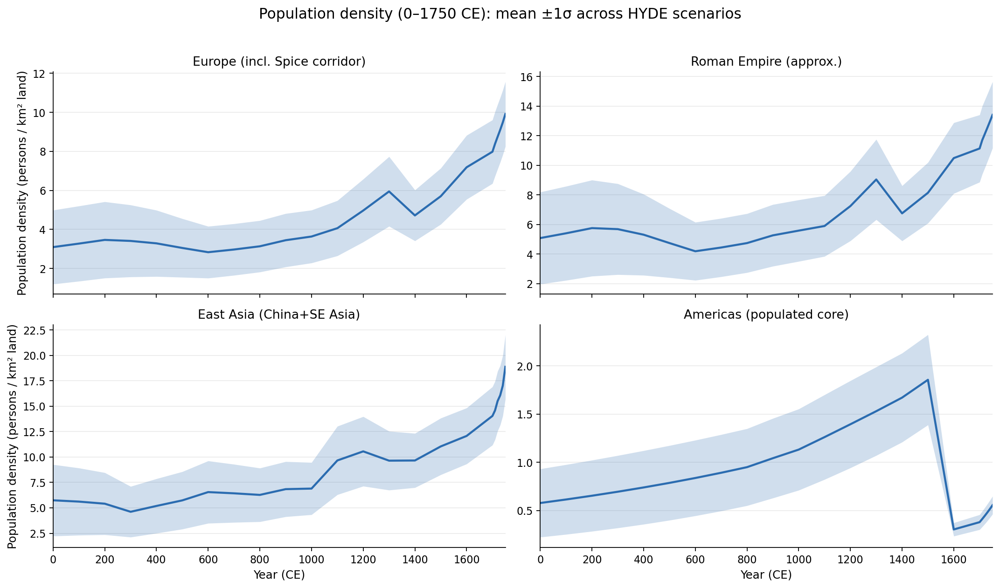

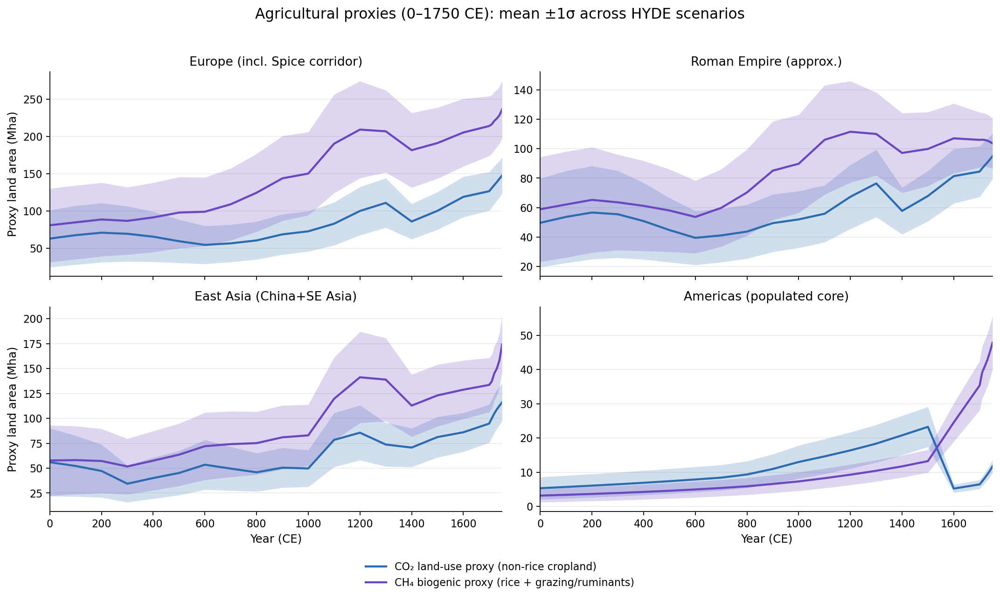

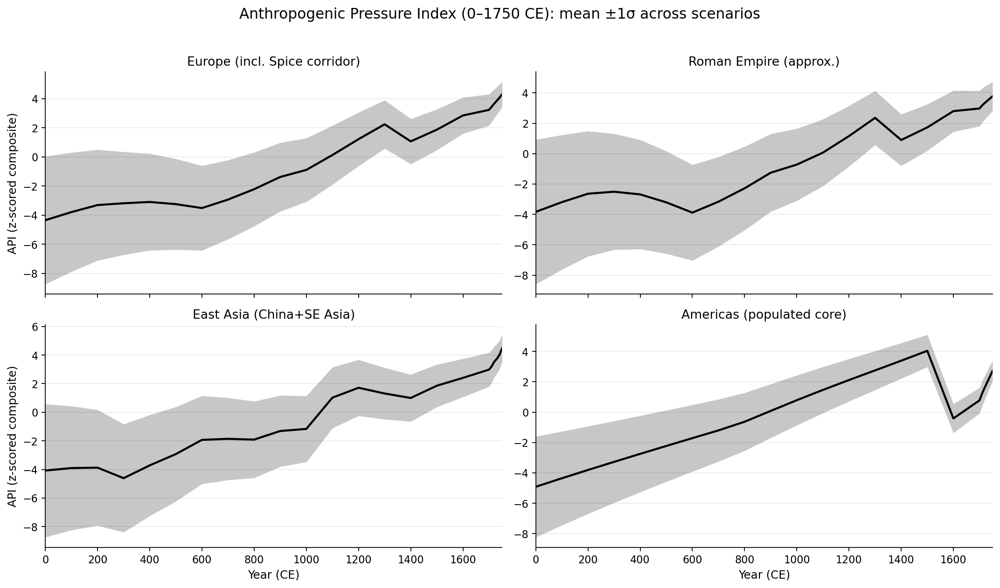

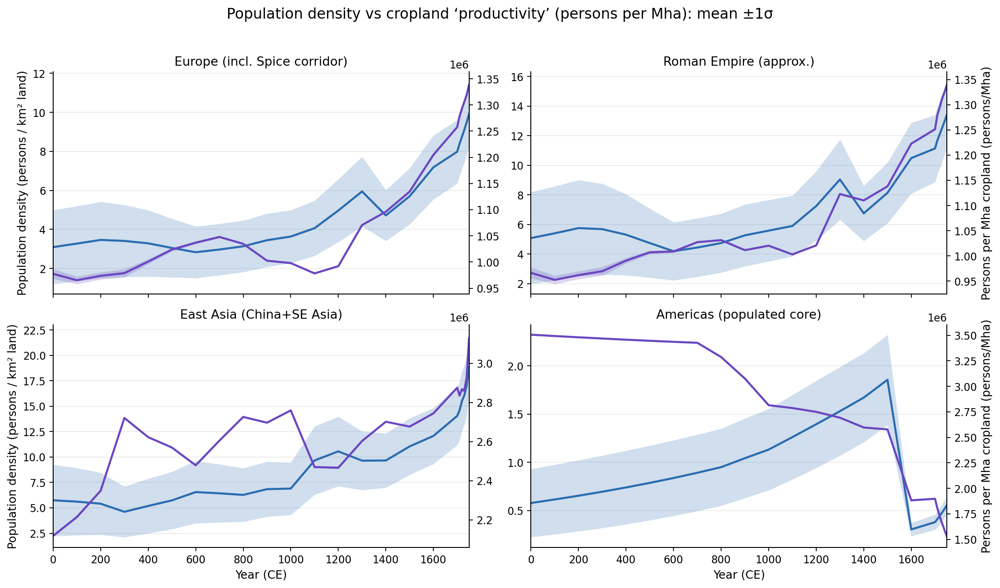

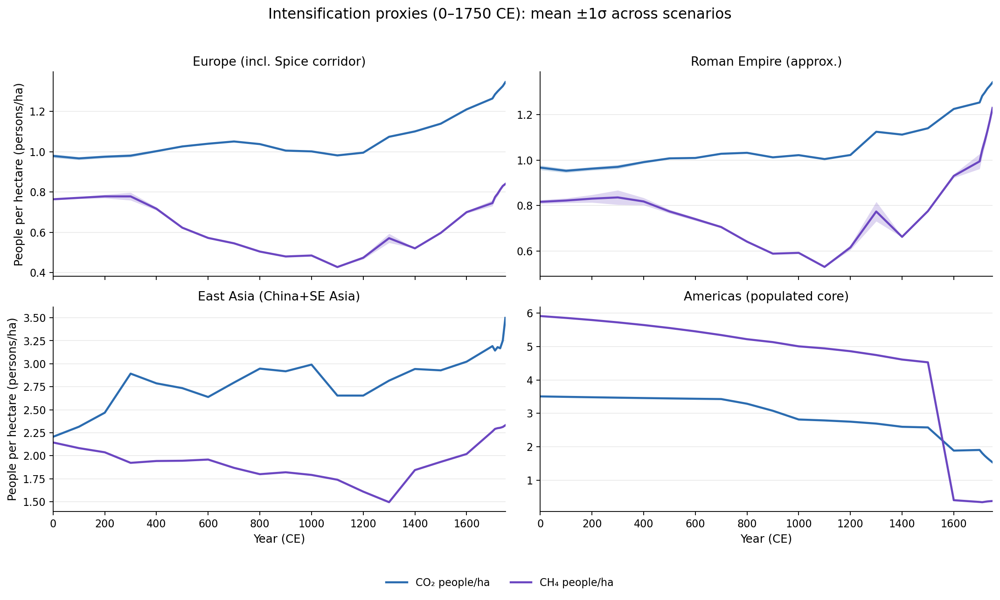

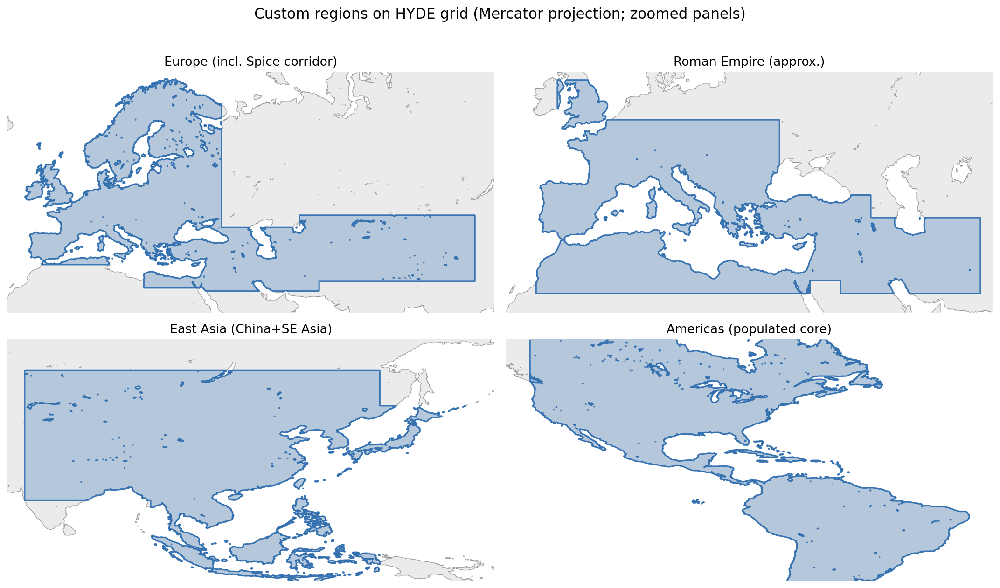


Wrote:
  hyde35_anthropogenic_region_year_by_scenario.csv
  hyde35_anthropogenic_region_year_mean_std.csv


In [6]:
# hyde35_anthropogenic_regions_dualy.py
# HYDE 3.5 (0–1750 CE): Custom regions + population density + CH4/CO2 land-use proxies
# + anthropogenic pressure metrics + dual-y plot:
#       population density  vs  "cropland productivity" = persons per Mha of total cropland
# + line plots (mean±1σ) for intensification proxies (CO2/CH4 people per hectare)
#
# Plug-and-run:
#   1) cd into your HYDE 3.5 root directory (contains gbc2025_* scenario folders + general_files/)
#   2) python hyde35_anthropogenic_regions_dualy.py
#
# Outputs:
#   - Figures:
#       A) Pop density (mean±1σ)
#       B) CO2/CH4 proxy land areas (mean±1σ)
#       C) Anthropogenic Pressure Index (API) (mean±1σ)
#       D) Dual-y: Pop density (left) vs persons per Mha cropland (right) (mean±1σ)
#       E) Intensification proxies (mean±1σ): people per hectare on CO2 proxy lands and CH4 proxy lands
#       F) Mercator region maps (2×2)
#   - CSVs:
#       hyde35_anthropogenic_region_year_by_scenario.csv
#       hyde35_anthropogenic_region_year_mean_std.csv
#
# Key definitions:
#   - CO2 proxy land = non-rice cropland (rainfed_not_rice + irrigated_not_rice; fallback cropland - rice)
#   - CH4 proxy land = rice + grazing land (ruminants proxy)
#   - Total cropland (Mha) = rice + non-rice cropland
#   - “Cropland productivity” requested = persons per Mha of total cropland = pop_total / total_cropland_mha
#   - Intensification proxies (line plots):
#       * CO2 people/ha = pop_total / (co2_mha * 1e6)
#       * CH4 people/ha = pop_total / (ch4_mha * 1e6)
#
# Notes:
#   - Robust to lon 0..360 vs -180..180 by doing comparisons in lon180 space but keeping original lon coords.
#   - East Asia region excludes India and Mongolia; includes China + Korea/Japan + SE Asia (broad).
#   - Standard deviations are computed across scenarios (base/lower/upper) using population std0 (ddof=0).

from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ----------------------------
# User config
# ----------------------------
START_YEAR = 0
END_YEAR = 1750

SPICE_LON_MAX = 105  # degrees East in [-180,180) convention

REGION_ORDER = [
    "Europe (incl. Spice corridor)",
    "Roman Empire (approx.)",
    "East Asia (China+SE Asia)",
    "Americas (populated core)",
]

CLASS_CO2 = "CO₂ land-use proxy (non-rice cropland)"
CLASS_CH4 = "CH₄ biogenic proxy (rice + grazing/ruminants)"

BLUE = "#2b6cb0"
PURPLE = "#6b46c1"
SHADE_ALPHA = 0.22

plt.rcParams.update(
    {
        "figure.dpi": 160,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

# ----------------------------
# File discovery (HYDE 3.5 nested general_files)
# ----------------------------
def _first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p.exists():
            return p
    return None


def find_general_file(root: Path, filename: str) -> Path:
    candidates = [
        root / "general_files" / "general_files" / filename,
        root / "general_files" / filename,
        root / filename,
    ]
    hit = _first_existing(candidates)
    if hit:
        return hit

    gf = root / "general_files"
    if gf.exists():
        hits = list(gf.rglob(filename))
        if hits:
            return hits[0]

    hits = list(root.rglob(filename))
    if hits:
        return hits[0]

    raise FileNotFoundError(f"Could not find '{filename}' under {root}.")


# ----------------------------
# Scenario discovery
# ----------------------------
def discover_scenarios(root: Path) -> List[Tuple[str, Path]]:
    pop_files = sorted(root.glob("*/NetCDF/population.nc"))
    out: List[Tuple[str, Path]] = []
    for pop_nc in pop_files:
        scen_dir = pop_nc.parent.parent
        label = scen_dir.name
        m = re.search(r"(base|lower|upper)", label, flags=re.IGNORECASE)
        if m:
            label = m.group(1).lower()
        out.append((label, scen_dir))

    order = {"base": 0, "lower": 1, "upper": 2}
    out.sort(key=lambda t: (order.get(t[0], 99), t[0]))
    return out


# ----------------------------
# Lat/lon standardization
# ----------------------------
def ensure_latlon(ds: xr.Dataset) -> xr.Dataset:
    rename: Dict[str, str] = {}
    for name in list(ds.dims) + list(ds.coords):
        low = name.lower()
        if low in ("latitude", "nav_lat", "y") and "lat" not in ds.dims and "lat" not in ds.coords:
            rename[name] = "lat"
        if low in ("longitude", "nav_lon", "x") and "lon" not in ds.dims and "lon" not in ds.coords:
            rename[name] = "lon"
    if rename:
        ds = ds.rename(rename)

    if "lat" not in ds.coords:
        if "lat" in ds.dims:
            ds = ds.assign_coords(lat=ds["lat"])
        else:
            raise ValueError(f"Dataset missing 'lat'. dims={ds.dims}, coords={list(ds.coords)}")
    if "lon" not in ds.coords:
        if "lon" in ds.dims:
            ds = ds.assign_coords(lon=ds["lon"])
        else:
            raise ValueError(f"Dataset missing 'lon'. dims={ds.dims}, coords={list(ds.coords)}")
    return ds


# ----------------------------
# ESRI ASCII reader + alignment
# ----------------------------
def read_esri_ascii_grid(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing ASCII grid: {path}")

    header: Dict[str, float] = {}
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(6):
            line = f.readline()
            if not line:
                raise ValueError(f"Unexpected EOF reading header of {path}")
            k, v = line.strip().split()[:2]
            header[k.lower()] = float(v) if ("." in v or "e" in v.lower()) else int(v)
        data = np.loadtxt(f)

    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    cell = float(header["cellsize"])

    if data.shape != (nrows, ncols):
        raise ValueError(f"{path}: header says ({nrows},{ncols}) but data is {data.shape}")

    if "xllcorner" in header:
        xll = float(header["xllcorner"])
    elif "xllcenter" in header:
        xll = float(header["xllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing xllcorner/xllcenter")

    if "yllcorner" in header:
        yll = float(header["yllcorner"])
    elif "yllcenter" in header:
        yll = float(header["yllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing yllcorner/yllcenter")

    nodata = header.get("nodata_value", None)

    lon = xll + cell * (0.5 + np.arange(ncols))
    lat = yll + cell * (nrows - 0.5 - np.arange(nrows))  # north->south

    da = xr.DataArray(data, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name=path.stem)
    if nodata is not None:
        da = da.where(da != nodata)
    return da


def _lon_to_180_vals(lon_vals: np.ndarray) -> np.ndarray:
    lon_vals = np.asarray(lon_vals, dtype=float)
    return (((lon_vals + 180.0) % 360.0) - 180.0)


def normalize_longitudes_to_match(da: xr.DataArray, target_lon: xr.DataArray) -> xr.DataArray:
    da = da.copy()
    lon_da = da["lon"].values
    lon_t = target_lon.values
    tmin = float(np.nanmin(lon_t))

    # target is [0,360)
    if tmin >= 0 and np.nanmin(lon_da) < 0:
        da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon")

    # target is [-180,180)
    if tmin < 0 and np.nanmin(lon_da) >= 0:
        da = da.assign_coords(lon=_lon_to_180_vals(da["lon"].values)).sortby("lon")

    return da


def align_grid_to_dataset(da: xr.DataArray, ds_template: xr.Dataset) -> xr.DataArray:
    da2 = normalize_longitudes_to_match(da, ds_template["lon"])
    return da2.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")


# ----------------------------
# NetCDF open + year handling
# ----------------------------
def open_single_var_nc(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing NetCDF: {path}")

    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    engines = [None, "netcdf4", "h5netcdf"]
    last_err = None

    for eng in engines:
        for use_chunks in (True, False):
            try:
                kw = dict(decode_times=time_coder, cache=False)
                if use_chunks:
                    kw["chunks"] = {"time": 1}
                ds = xr.open_dataset(path, engine=eng, **kw) if eng else xr.open_dataset(path, **kw)
                ds = ensure_latlon(ds)

                data_vars = list(ds.data_vars)
                if not data_vars:
                    raise ValueError(f"No data variables in {path}")

                if len(data_vars) == 1:
                    return ds[data_vars[0]]

                stem = path.stem.lower()
                for v in data_vars:
                    if stem in v.lower():
                        return ds[v]
                return ds[data_vars[0]]
            except Exception as e:
                last_err = e
                continue

    raise OSError(f"Failed to open {path}. Last error: {last_err}")


def coerce_year_index(da: xr.DataArray) -> xr.DataArray:
    if "year" in da.coords:
        t = da["year"]
    elif "time" in da.coords:
        t = da["time"]
    else:
        raise ValueError("No 'time' or 'year' coordinate found.")

    try:
        years = t.dt.year.astype(int).values
    except Exception:
        vals = np.asarray(t.values)
        if vals.size and hasattr(vals.flat[0], "year"):
            years = np.array([v.year for v in vals.ravel()], dtype=int).reshape(vals.shape)
        else:
            years = np.rint(vals.astype(float)).astype(int)

    dim = t.dims[0] if t.dims else None
    if dim is None:
        da = da.assign_coords(year=years)
    else:
        da = da.assign_coords(year=(dim, years))
        if dim != "year" and np.unique(years).size == years.size:
            da = da.swap_dims({dim: "year"})
    return da


def subset_years(da: xr.DataArray, start_year: int, end_year: int) -> xr.DataArray:
    da = coerce_year_index(da)
    if "year" in da.dims:
        da = da.sortby("year")
        return da.sel(year=slice(start_year, end_year))
    if "year" in da.coords:
        mask = (da["year"] >= start_year) & (da["year"] <= end_year)
        return da.where(mask, drop=True)
    raise ValueError("No 'year' coordinate could be constructed.")


# ----------------------------
# Constant grids: cell area + land mask
# ----------------------------
def load_cell_area_km2(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    p = find_general_file(root, "garea_cr.asc")
    da = read_esri_ascii_grid(p)
    da = align_grid_to_dataset(da, ds_template)
    da.name = "cell_area_km2"
    return da


def load_land_mask_optional(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    try:
        p = find_general_file(root, "landlake.asc")
    except FileNotFoundError:
        p = None

    lat = ds_template["lat"].values
    lon = ds_template["lon"].values

    if p is None or not Path(p).exists():
        warnings.warn("landlake.asc not found. Treating all grid cells as land.")
        return xr.DataArray(
            np.ones((lat.size, lon.size), dtype=float),
            dims=("lat", "lon"),
            coords={"lat": lat, "lon": lon},
            name="land_mask",
        )

    da = read_esri_ascii_grid(Path(p))
    da = align_grid_to_dataset(da, ds_template)
    lm = xr.where(da > 0, 1.0, 0.0).fillna(0.0)
    lm.name = "land_mask"

    frac_land = float(lm.mean().values)
    if frac_land < 0.01:
        warnings.warn("Aligned land mask has <1% land; using all-land fallback.")
        lm = xr.ones_like(lm)

    return lm


# ----------------------------
# Region masks (fixed for lon 0..360 datasets)
# ----------------------------
def build_region_masks(ds_template: xr.Dataset, land_mask: xr.DataArray) -> xr.DataArray:
    lat = ds_template["lat"]
    lon = ds_template["lon"]

    lon180_vals = _lon_to_180_vals(lon.values)
    lon180 = xr.DataArray(lon180_vals, dims=("lon",), coords={"lon": lon.values})

    LON180, LAT = xr.broadcast(lon180, lat)
    LON180 = LON180.transpose("lat", "lon")
    LAT = LAT.transpose("lat", "lon")

    def in_box(lon_min, lon_max, lat_min, lat_max):
        return (LON180 >= lon_min) & (LON180 <= lon_max) & (LAT >= lat_min) & (LAT <= lat_max)

    # Exclusions
    sahara = in_box(-17, 35, 15, 28)
    arabia = in_box(34, 60, 12, 27)
    exclude = sahara | arabia

    # 1) Europe + Spice corridor
    europe_core = in_box(-12, 40, 35, 72)
    spice_near_east = in_box(20, 65, 27, 45)
    spice_central_asia = in_box(60, SPICE_LON_MAX, 30, 48)
    europe = europe_core | (spice_near_east | spice_central_asia)

    # 2) Roman Empire (approx.)
    roman_west = in_box(-10, 30, 35, 51)
    roman_balkans = in_box(10, 30, 35, 46)
    roman_anatolia = in_box(20, 45, 34, 42)
    roman_levant = in_box(30, 42, 30, 38)
    roman_n_africa_coast = in_box(-10, 35, 28, 37)
    roman_iraq_iran = in_box(40, 63, 28, 39)
    roman_britain = in_box(-6.5, 2.5, 49.5, 55.2)
    roman = (
        roman_west | roman_balkans | roman_anatolia | roman_levant
        | roman_n_africa_coast | roman_iraq_iran | roman_britain
    )

    # 3) East Asia (China + SE Asia + Korea/Japan), excluding India and Mongolia
    # Broad China (includes Tibet/Xinjiang broadly)
    china = in_box(73, 135, 18, 54)
    korea_japan = in_box(120, 150, 30, 46)
    se_asia = in_box(95, 135, -10, 25)
    eastasia = china | korea_japan | se_asia

    # 4) Americas core
    americas = in_box(-125, -30, -35, 60)

    def finalize(mask_bool: xr.DataArray) -> xr.DataArray:
        m = mask_bool & (~exclude)
        m = xr.where(m, 1.0, 0.0)
        return (m * land_mask).astype(float)

    masks = xr.concat(
        [finalize(europe), finalize(roman), finalize(eastasia), finalize(americas)],
        dim="region",
    )
    masks = masks.assign_coords(region=("region", REGION_ORDER))
    masks.name = "region_masks"
    return masks


# ----------------------------
# Land-use helpers
# ----------------------------
def _string_attr(da: xr.DataArray, key: str) -> str:
    return str(da.attrs.get(key, "")).strip().lower()


def _looks_like_fraction(da: xr.DataArray) -> bool:
    units = _string_attr(da, "units")
    long_name = _string_attr(da, "long_name") + " " + _string_attr(da, "standard_name")
    if ("frac" in units) or ("fraction" in units) or ("fraction" in long_name):
        return True
    if units in ("", "1", "-"):
        try:
            sample = da.isel(time=0) if "time" in da.dims else (da.isel(year=0) if "year" in da.dims else da)
            vmax = float(sample.max().values)
            vmin = float(sample.min().values)
            return (vmin >= -1e-6) and (vmax <= 1.5)
        except Exception:
            return False
    return False


def landuse_regional_mha(
    nc_path: Path,
    region_masks: xr.DataArray,
    cell_area_km2: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None

    try:
        da = open_single_var_nc(nc_path)
    except Exception as e:
        warnings.warn(f"Skipping unreadable NetCDF: {nc_path.name} | {e}")
        return None

    da = subset_years(da, start_year, end_year)

    units = _string_attr(da, "units")
    frac = _looks_like_fraction(da)

    if frac:
        da_mha = (da * cell_area_km2) / 1e4
    else:
        if "km" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e4
        elif units in ("ha", "hectare", "hectares"):
            da_mha = da / 1e6
        elif "m" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e10
        else:
            warnings.warn(f"{nc_path.name}: Unrecognized units '{da.attrs.get('units','')}'. Assuming km² -> Mha via /1e4.")
            da_mha = da / 1e4

    da_mha = da_mha.rename("area_mha")
    reg = (da_mha * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "Mha"
    return reg


# ----------------------------
# Population helpers
# ----------------------------
def population_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> xr.DataArray:
    da = open_single_var_nc(nc_path)
    da = subset_years(da, start_year, end_year)
    reg = (da * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "persons"
    return reg


def optional_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None
    try:
        return population_regional_persons(nc_path, region_masks, start_year, end_year)
    except Exception as e:
        warnings.warn(f"Could not read optional file {nc_path.name}: {e}")
        return None


# ----------------------------
# Stats + plotting helpers
# ----------------------------
def std0(x: pd.Series) -> float:
    return float(np.std(x.to_numpy(dtype=float), ddof=0))


def style_timeseries_ax(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)


def plot_mean_sigma(ax, x, mean, std, color, label=None):
    ax.plot(x, mean, color=color, linewidth=2.0, label=label)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=SHADE_ALPHA, linewidth=0)


def safe_log_series(s: pd.Series) -> pd.Series:
    v = s.to_numpy(dtype=float)
    v = np.where(np.isfinite(v) & (v > 0), v, np.nan)
    return pd.Series(np.log(v), index=s.index)


def zscore_by_group_safe(df: pd.DataFrame, col: str, group_cols: List[str]) -> pd.Series:
    if col not in df.columns:
        return pd.Series(np.zeros(len(df)), index=df.index, dtype=float)

    def _z(x: pd.Series) -> pd.Series:
        v = x.to_numpy(dtype=float)
        mu = np.nanmean(v)
        sd = np.nanstd(v)
        if not np.isfinite(sd) or sd == 0:
            return pd.Series(np.zeros_like(v), index=x.index)
        return (x - mu) / sd

    return df.groupby(group_cols, group_keys=False)[col].apply(_z)


# Mercator helpers (no cartopy)
def mercator_y(lat_deg: np.ndarray) -> np.ndarray:
    lat = np.asarray(lat_deg, dtype=float)
    lat = np.clip(lat, -85.0, 85.0)
    phi = np.deg2rad(lat)
    return np.log(np.tan(np.pi / 4.0 + phi / 2.0))


def coord_edges_1d(coord: np.ndarray) -> np.ndarray:
    c = np.asarray(coord, dtype=float)
    if c.size < 2:
        raise ValueError("Need at least 2 points to compute edges.")
    d = np.diff(c)
    first = c[0] - d[0] / 2.0
    last = c[-1] + d[-1] / 2.0
    mid = c[:-1] + d / 2.0
    return np.concatenate([[first], mid, [last]])


def to_lon180_sorted(da: xr.DataArray) -> xr.DataArray:
    lon_vals = da["lon"].values
    lon180_vals = _lon_to_180_vals(lon_vals)
    return da.assign_coords(lon=lon180_vals).sortby("lon")


def sel_box_latlon(da: xr.DataArray, lon_min: float, lon_max: float, lat_min: float, lat_max: float) -> xr.DataArray:
    lat = da["lat"].values
    if lat[0] < lat[-1]:
        da2 = da.sel(lat=slice(lat_min, lat_max))
    else:
        da2 = da.sel(lat=slice(lat_max, lat_min))
    da2 = da2.sel(lon=slice(lon_min, lon_max))
    return da2.sortby("lat")


# ----------------------------
# MAIN
# ----------------------------
ROOT = Path(".").resolve()
scenarios = discover_scenarios(ROOT)
if not scenarios:
    raise RuntimeError(
        "No scenarios found. Expected folders like 'gbc2025_7apr_base' with 'NetCDF/population.nc'. "
        "Run from the HYDE 3.5 root directory."
    )

print("Found scenarios:", ", ".join([f"{lab}:{p.name}" for lab, p in scenarios]))

template_label, template_dir = scenarios[0]
template_ds = xr.open_dataset(template_dir / "NetCDF" / "population.nc")
template_ds = ensure_latlon(template_ds)

print(f"Template lon range: {float(template_ds['lon'].min()):.3f} .. {float(template_ds['lon'].max()):.3f}")
print(f"Template lat range: {float(template_ds['lat'].min()):.3f} .. {float(template_ds['lat'].max()):.3f}")

cell_area_km2 = load_cell_area_km2(ROOT, template_ds)
land_mask = load_land_mask_optional(ROOT, template_ds)
region_masks = build_region_masks(template_ds, land_mask)

land_area_reg_km2 = (cell_area_km2 * region_masks).sum(dim=("lat", "lon"), skipna=True).rename("land_area_km2").astype(float)
print("\nLand area by region (km²):")
print(land_area_reg_km2.to_dataframe().reset_index())

if float(land_area_reg_km2.max().values) <= 0:
    raise RuntimeError("All region land areas are zero. Masks are not aligning with NetCDF lon/lat.")

pop_rows: List[pd.DataFrame] = []
ag_rows: List[pd.DataFrame] = []
extra_rows: List[pd.DataFrame] = []

for scen_label, scen_dir in scenarios:
    print(f"Processing scenario: {scen_label} ({scen_dir.name})")

    # Population totals
    pop_reg = population_regional_persons(scen_dir / "NetCDF" / "population.nc", region_masks, START_YEAR, END_YEAR)

    # Optional urban population and urban area
    urb_pop_reg = optional_regional_persons(scen_dir / "NetCDF" / "urban_population.nc", region_masks, START_YEAR, END_YEAR)
    urb_area_reg = landuse_regional_mha(scen_dir / "NetCDF" / "urban_area.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    # Density
    dens = (pop_reg / xr.where(land_area_reg_km2 > 0, land_area_reg_km2, np.nan)).rename("pop_density_p_km2")

    dens_df = dens.to_dataframe(name="pop_density_p_km2").reset_index()
    dens_df["scenario"] = scen_label

    pop_df = pop_reg.to_dataframe(name="pop_total").reset_index()
    pop_df["scenario"] = scen_label

    # Urban merge
    if urb_pop_reg is not None:
        up = urb_pop_reg.to_dataframe(name="urban_pop").reset_index()
        up["scenario"] = scen_label
        base = pop_df.merge(up, on=["year", "region", "scenario"], how="left")
        base["urban_share"] = base["urban_pop"] / base["pop_total"]
    else:
        base = pop_df.copy()
        base["urban_pop"] = np.nan
        base["urban_share"] = np.nan

    if urb_area_reg is not None:
        ua = urb_area_reg.to_dataframe(name="urban_area_mha").reset_index()
        ua["scenario"] = scen_label
        base = base.merge(ua, on=["year", "region", "scenario"], how="left")
    else:
        base["urban_area_mha"] = np.nan

    base = base.merge(
        dens_df[["scenario", "year", "region", "pop_density_p_km2"]],
        on=["scenario", "year", "region"],
        how="left",
    )

    pop_rows.append(
        base[
            [
                "scenario",
                "year",
                "region",
                "pop_total",
                "pop_density_p_km2",
                "urban_pop",
                "urban_share",
                "urban_area_mha",
            ]
        ]
    )

    # -------- Land-use proxies --------
    rice_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    rice_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (rice_rf is not None) or (rice_ir is not None):
        rice_reg = (0 if rice_rf is None else rice_rf.fillna(0)) + (0 if rice_ir is None else rice_ir.fillna(0))
    else:
        rice_reg = landuse_regional_mha(scen_dir / "NetCDF" / "total_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    grazing_reg = landuse_regional_mha(scen_dir / "NetCDF" / "grazing_land.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if grazing_reg is None:
        pasture_reg = landuse_regional_mha(scen_dir / "NetCDF" / "pasture.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        rangeland_reg = landuse_regional_mha(scen_dir / "NetCDF" / "rangeland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if (pasture_reg is not None) or (rangeland_reg is not None):
            grazing_reg = (0 if pasture_reg is None else pasture_reg.fillna(0)) + (0 if rangeland_reg is None else rangeland_reg.fillna(0))

    nr_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    nr_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (nr_rf is not None) or (nr_ir is not None):
        nonrice_reg = (0 if nr_rf is None else nr_rf.fillna(0)) + (0 if nr_ir is None else nr_ir.fillna(0))
    else:
        cropt = landuse_regional_mha(scen_dir / "NetCDF" / "cropland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if cropt is not None and rice_reg is not None:
            nonrice_reg = (cropt - rice_reg.fillna(0)).clip(min=0)
            warnings.warn(f"{scen_dir.name}: Using cropland.nc minus rice as non-rice cropland fallback.")
        elif cropt is not None:
            nonrice_reg = cropt
            warnings.warn(f"{scen_dir.name}: Using cropland.nc as non-rice cropland fallback (rice unavailable).")
        else:
            nonrice_reg = None

    # Total cropland (Mha) = rice + non-rice
    if (rice_reg is not None) or (nonrice_reg is not None):
        rr = 0 if rice_reg is None else rice_reg.fillna(0)
        nn = 0 if nonrice_reg is None else nonrice_reg.fillna(0)
        total_cropland_mha = (rr + nn).rename("total_cropland_mha")
    else:
        total_cropland_mha = None

    # CH4 proxy = rice + grazing
    ch4_reg = None
    if (rice_reg is not None) or (grazing_reg is not None):
        r = 0 if rice_reg is None else rice_reg.fillna(0)
        g = 0 if grazing_reg is None else grazing_reg.fillna(0)
        ch4_reg = r + g
        df = ch4_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CH4
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # CO2 proxy = non-rice cropland
    co2_reg = None
    if nonrice_reg is not None:
        co2_reg = nonrice_reg
        df = co2_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CO2
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # -------- Scenario-level derived objects --------
    P = pop_df.copy()

    if ch4_reg is not None:
        T = ch4_reg.to_dataframe(name="ch4_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "ch4_mha"]], on=["scenario", "year", "region"], how="left")
    else:
        P["ch4_mha"] = np.nan

    if co2_reg is not None:
        T = co2_reg.to_dataframe(name="co2_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "co2_mha"]], on=["scenario", "year", "region"], how="left")
    else:
        P["co2_mha"] = np.nan

    if total_cropland_mha is not None:
        T = total_cropland_mha.to_dataframe(name="total_cropland_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "total_cropland_mha"]],
                    on=["scenario", "year", "region"], how="left")
    else:
        P["total_cropland_mha"] = np.nan

    land_mha_df = (land_area_reg_km2 / 1e4).to_dataframe(name="land_mha").reset_index()
    P = P.merge(land_mha_df, on=["region"], how="left")

    # Intensification proxies (persons/ha)
    P["co2_people_per_ha"] = P["pop_total"] / (P["co2_mha"] * 1e6)
    P["ch4_people_per_ha"] = P["pop_total"] / (P["ch4_mha"] * 1e6)

    P["co2_share_of_land"] = P["co2_mha"] / P["land_mha"]
    P["ch4_share_of_land"] = P["ch4_mha"] / P["land_mha"]

    # “Cropland productivity”: persons per Mha of total cropland
    P["persons_per_mha_cropland"] = P["pop_total"] / P["total_cropland_mha"]

    # Growth rates (log diffs) by region (kept minimal)
    P = P.sort_values(["region", "year"]).reset_index(drop=True)
    for col in ["pop_total", "co2_mha", "ch4_mha"]:
        gcol = f"dlog_{col}"
        P[gcol] = np.nan
        for rname in REGION_ORDER:
            idx = (P["region"].to_numpy() == rname)
            x = P.loc[idx, col].to_numpy(dtype=float)
            x = np.where(np.isfinite(x) & (x > 0), x, np.nan)
            d = np.full_like(x, np.nan, dtype=float)
            if x.size >= 2:
                d[1:] = np.log(x[1:]) - np.log(x[:-1])
            P.loc[idx, gcol] = d

    extra_rows.append(
        P[
            [
                "scenario",
                "year",
                "region",
                "pop_total",
                "co2_mha",
                "ch4_mha",
                "land_mha",
                "total_cropland_mha",
                "persons_per_mha_cropland",
                "co2_people_per_ha",
                "ch4_people_per_ha",
                "co2_share_of_land",
                "ch4_share_of_land",
                "dlog_pop_total",
                "dlog_co2_mha",
                "dlog_ch4_mha",
            ]
        ]
    )

# Concatenate
pop_all = pd.concat(pop_rows, ignore_index=True)
ag_all = pd.concat(ag_rows, ignore_index=True) if ag_rows else pd.DataFrame(columns=["scenario", "year", "region", "class", "area_mha"])
extra_all = pd.concat(extra_rows, ignore_index=True) if extra_rows else pd.DataFrame()

# Across-scenario stats (std computed across scenarios)
popdens_stats = (
    pop_all.groupby(["year", "region"], as_index=False)
    .agg(mean=("pop_density_p_km2", "mean"), std=("pop_density_p_km2", std0))
)

ag_stats = (
    ag_all.groupby(["year", "region", "class"], as_index=False)
    .agg(mean=("area_mha", "mean"), std=("area_mha", std0))
)

extra_stats = (
    extra_all.groupby(["year", "region"], as_index=False)
    .agg(
        persons_per_mha_cropland_mean=("persons_per_mha_cropland", "mean"),
        persons_per_mha_cropland_std=("persons_per_mha_cropland", std0),

        co2_people_per_ha_mean=("co2_people_per_ha", "mean"),
        co2_people_per_ha_std=("co2_people_per_ha", std0),

        ch4_people_per_ha_mean=("ch4_people_per_ha", "mean"),
        ch4_people_per_ha_std=("ch4_people_per_ha", std0),

        dlog_pop_mean=("dlog_pop_total", "mean"),
        dlog_pop_std=("dlog_pop_total", std0),
        dlog_co2_mean=("dlog_co2_mha", "mean"),
        dlog_co2_std=("dlog_co2_mha", std0),
        dlog_ch4_mean=("dlog_ch4_mha", "mean"),
        dlog_ch4_std=("dlog_ch4_mha", std0),
    )
)

# ----------------------------
# API (Anthropogenic Pressure Index) — bulletproof
# ----------------------------
api_df = extra_all.merge(
    pop_all[["scenario", "year", "region", "urban_area_mha"]],
    on=["scenario", "year", "region"],
    how="left",
)

for c in ["pop_total", "co2_mha", "ch4_mha", "urban_area_mha"]:
    if c in api_df.columns:
        api_df[f"log_{c}"] = safe_log_series(api_df[c])

api_df["z_log_pop"] = zscore_by_group_safe(api_df, "log_pop_total", ["region"])
api_df["z_log_co2"] = zscore_by_group_safe(api_df, "log_co2_mha", ["region"])
api_df["z_log_ch4"] = zscore_by_group_safe(api_df, "log_ch4_mha", ["region"])
api_df["z_log_urban"] = zscore_by_group_safe(api_df, "log_urban_area_mha", ["region"])

api_df["API"] = api_df["z_log_pop"] + api_df["z_log_co2"] + api_df["z_log_ch4"] + api_df["z_log_urban"]

api_stats = (
    api_df.groupby(["year", "region"], as_index=False)
    .agg(API_mean=("API", "mean"), API_std=("API", std0))
)

print("\nPreview: extra_stats head")
print(extra_stats.head(10))
print("\nPreview: api_stats head")
print(api_stats.head(10))

# ----------------------------
# FIGURE A: Population density (mean±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, df["year"].to_numpy(), df["mean"].to_numpy(float), df["std"].to_numpy(float), color=BLUE)

axs[0].set_ylabel("Population density (persons / km² land)")
axs[2].set_ylabel("Population density (persons / km² land)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE B: Land-use proxies (mean±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)

    df_r = ag_stats[ag_stats["region"] == region]
    if df_r.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    d_co2 = df_r[df_r["class"] == CLASS_CO2].sort_values("year")
    if not d_co2.empty:
        plot_mean_sigma(ax, d_co2["year"].to_numpy(), d_co2["mean"].to_numpy(float), d_co2["std"].to_numpy(float),
                        color=BLUE, label=CLASS_CO2 if i == 0 else None)

    d_ch4 = df_r[df_r["class"] == CLASS_CH4].sort_values("year")
    if not d_ch4.empty:
        plot_mean_sigma(ax, d_ch4["year"].to_numpy(), d_ch4["mean"].to_numpy(float), d_ch4["std"].to_numpy(float),
                        color=PURPLE, label=CLASS_CH4 if i == 0 else None)

axs[0].set_ylabel("Proxy land area (Mha)")
axs[2].set_ylabel("Proxy land area (Mha)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Agricultural proxies (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=1, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE C: API index (mean±1σ)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = api_stats[api_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, df["year"].to_numpy(), df["API_mean"].to_numpy(float), df["API_std"].to_numpy(float), color="black")

axs[0].set_ylabel("API (z-scored composite)")
axs[2].set_ylabel("API (z-scored composite)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Anthropogenic Pressure Index (0–1750 CE): mean ±1σ across scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE D: Dual-y evolution (mean±1σ)
#   Left y: population density (persons/km² land)
#   Right y: persons per Mha of total cropland
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax2 = ax.twinx()

    d1 = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    d2 = extra_stats[extra_stats["region"] == region].sort_values("year")

    ax.set_title(region)
    ax.spines["top"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax2.spines["top"].set_visible(False)

    ax.set_xlim(START_YEAR, END_YEAR)

    if not d1.empty:
        plot_mean_sigma(
            ax,
            d1["year"].to_numpy(),
            d1["mean"].to_numpy(dtype=float),
            d1["std"].to_numpy(dtype=float),
            color=BLUE,
        )

    if not d2.empty:
        x = d2["year"].to_numpy()
        y = d2["persons_per_mha_cropland_mean"].to_numpy(dtype=float)
        s = d2["persons_per_mha_cropland_std"].to_numpy(dtype=float)

        ax2.plot(x, y, color=PURPLE, linewidth=2.0)
        ax2.fill_between(x, y - s, y + s, color=PURPLE, alpha=SHADE_ALPHA, linewidth=0)

    if i in (0, 2):
        ax.set_ylabel("Population density (persons / km² land)")
    if i in (1, 3):
        ax2.set_ylabel("Persons per Mha cropland (persons/Mha)")

axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density vs cropland ‘productivity’ (persons per Mha): mean ±1σ", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE E: Intensification proxies as line plots (mean±1σ)
#   CO2 people/ha (blue) vs CH4 people/ha (purple)
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = extra_stats[extra_stats["region"] == region].sort_values("year")
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)

    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    # CO2 people/ha
    x = df["year"].to_numpy()
    y = df["co2_people_per_ha_mean"].to_numpy(dtype=float)
    s = df["co2_people_per_ha_std"].to_numpy(dtype=float)
    ax.plot(x, y, color=BLUE, linewidth=2.0, label="CO₂ people/ha" if i == 0 else None)
    ax.fill_between(x, y - s, y + s, color=BLUE, alpha=SHADE_ALPHA, linewidth=0)

    # CH4 people/ha
    y = df["ch4_people_per_ha_mean"].to_numpy(dtype=float)
    s = df["ch4_people_per_ha_std"].to_numpy(dtype=float)
    ax.plot(x, y, color=PURPLE, linewidth=2.0, label="CH₄ people/ha" if i == 0 else None)
    ax.fill_between(x, y - s, y + s, color=PURPLE, alpha=SHADE_ALPHA, linewidth=0)

    if i in (0, 2):
        ax.set_ylabel("People per hectare (persons/ha)")

axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Intensification proxies (0–1750 CE): mean ±1σ across scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# ----------------------------
# FIGURE F: Mercator region maps (2×2)
# ----------------------------
MAP_EXTENTS = {
    "Europe (incl. Spice corridor)": (-15, SPICE_LON_MAX + 5, 20, 72),
    "Roman Empire (approx.)": (-15, 65, 25, 56),
    "East Asia (China+SE Asia)": (70, 155, -10, 60),
    "Americas (populated core)": (-130, -30, -35, 60),
}

land_plot = to_lon180_sorted(land_mask)
region_plot = to_lon180_sorted(region_masks)

land_cmap = ListedColormap([(1, 1, 1, 0), (0, 0, 0, 0.08)])
region_cmap = ListedColormap([(0, 0, 0, 0), (0.17, 0.42, 0.69, 0.28)])

fig, axs = plt.subplots(2, 2, figsize=(13.5, 8))
axs = axs.ravel()

for i, region_name in enumerate(REGION_ORDER):
    ax = axs[i]
    lon_min, lon_max, lat_min, lat_max = MAP_EXTENTS[region_name]

    land_sub = sel_box_latlon(land_plot, lon_min, lon_max, lat_min, lat_max)
    reg_sub = sel_box_latlon(region_plot.sel(region=region_name), lon_min, lon_max, lat_min, lat_max)

    lon = land_sub["lon"].values
    lat = land_sub["lat"].values
    lon_e = coord_edges_1d(lon)
    lat_e = coord_edges_1d(lat)
    y_e = mercator_y(lat_e)
    y = mercator_y(lat)

    ax.pcolormesh(lon_e, y_e, (land_sub.values > 0).astype(float), shading="auto", cmap=land_cmap)
    ax.pcolormesh(lon_e, y_e, reg_sub.values.astype(float), shading="auto", cmap=region_cmap)

    try:
        ax.contour(lon, y, (land_sub.values > 0).astype(float), levels=[0.5], colors="black", linewidths=0.6, alpha=0.35)
    except Exception:
        pass

    try:
        ax.contour(lon, y, reg_sub.values.astype(float), levels=[0.5], colors=BLUE, linewidths=1.4, alpha=0.9)
    except Exception:
        pass

    ax.set_title(region_name)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(mercator_y(lat_min), mercator_y(lat_max))
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig.suptitle("Custom regions on HYDE grid (Mercator projection; zoomed panels)", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# SAVE PANELS
# ----------------------------
panel_scenario = extra_all.merge(
    pop_all[["scenario", "year", "region", "pop_density_p_km2", "urban_share", "urban_area_mha"]],
    on=["scenario", "year", "region"],
    how="left",
)

panel_mean = extra_stats.merge(popdens_stats[["year", "region", "mean", "std"]], on=["year", "region"], how="left")
panel_mean = panel_mean.rename(columns={"mean": "popdens_mean", "std": "popdens_std"})
panel_mean = panel_mean.merge(api_stats, on=["year", "region"], how="left")

panel_scenario.to_csv("hyde35_anthropogenic_region_year_by_scenario.csv", index=False)
panel_mean.to_csv("hyde35_anthropogenic_region_year_mean_std.csv", index=False)

print("\nWrote:")
print("  hyde35_anthropogenic_region_year_by_scenario.csv")
print("  hyde35_anthropogenic_region_year_mean_std.csv")

Found scenarios: base:gbc2025_7apr_base, lower:gbc2025_7apr_lower, upper:gbc2025_7apr_upper
Template lon range: -179.958 .. 179.958
Template lat range: -89.958 .. 89.958

Land area by region (km²):
                            region  land_area_km2
0    Europe (incl. Spice corridor)   2.004120e+07
1           Roman Empire (approx.)   9.509715e+06
2  East Asia (China+Mongolia core)   2.182023e+07
3        Americas (populated core)   3.229304e+07
Processing scenario: base (gbc2025_7apr_base)
Processing scenario: lower (gbc2025_7apr_lower)
Processing scenario: upper (gbc2025_7apr_upper)


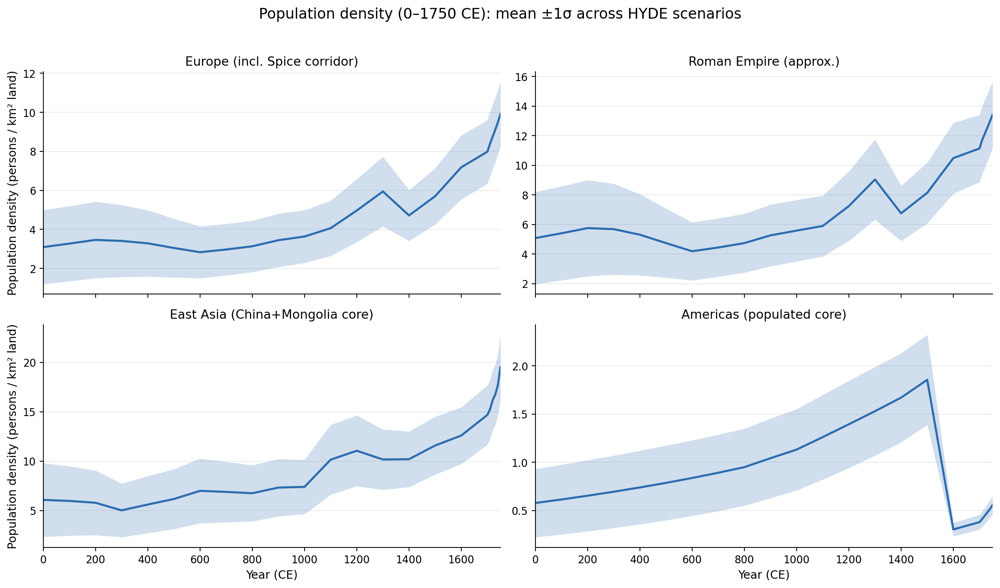

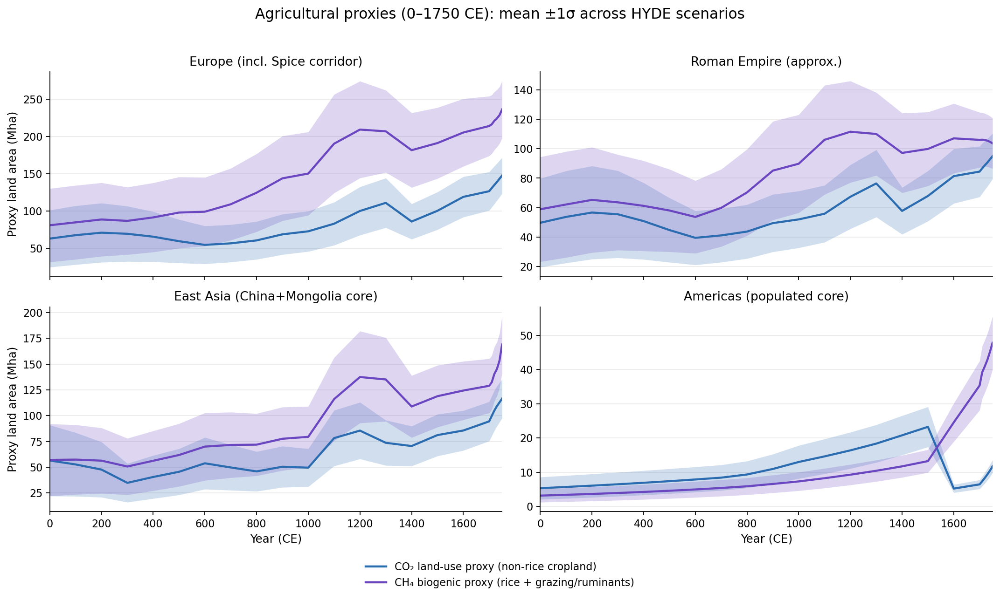

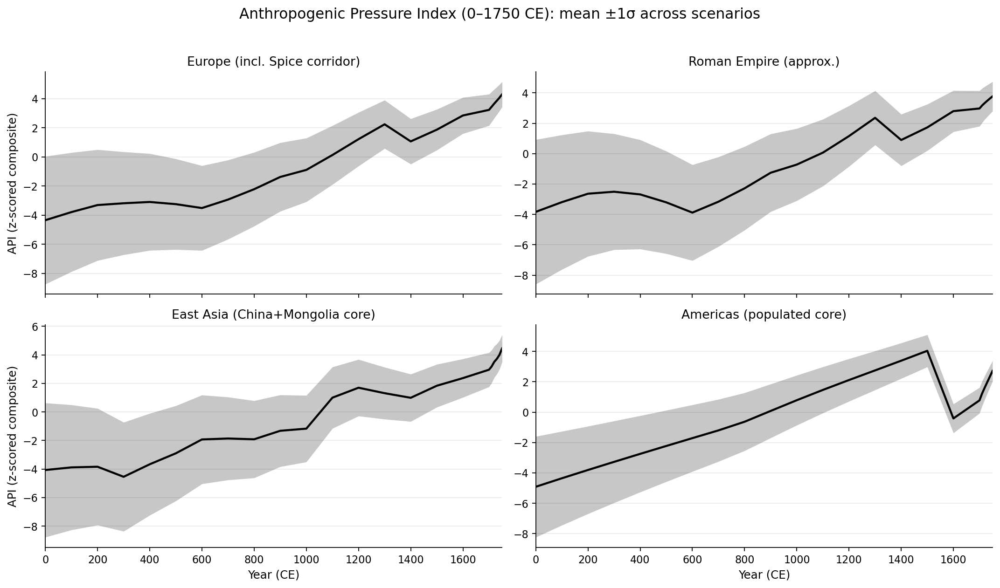

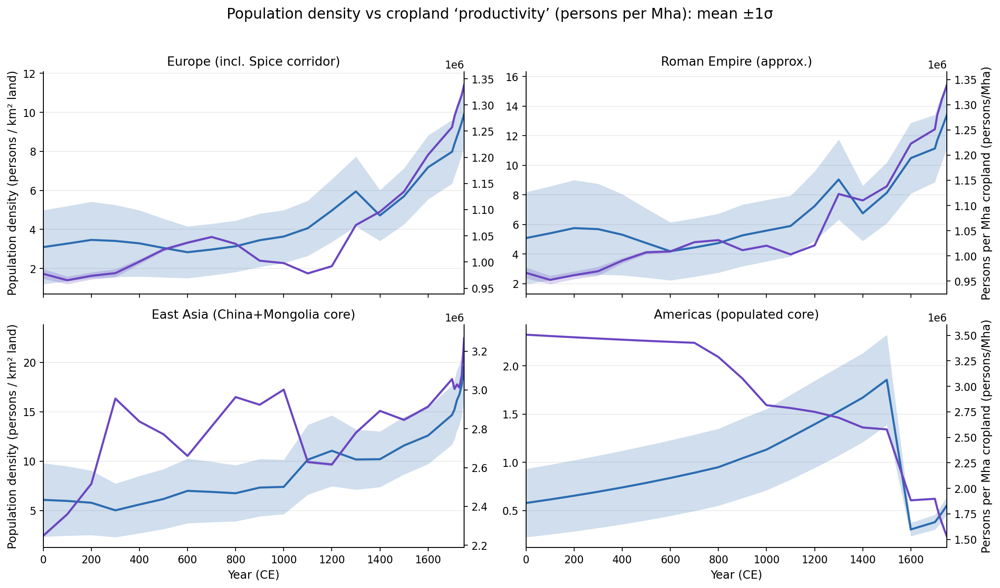

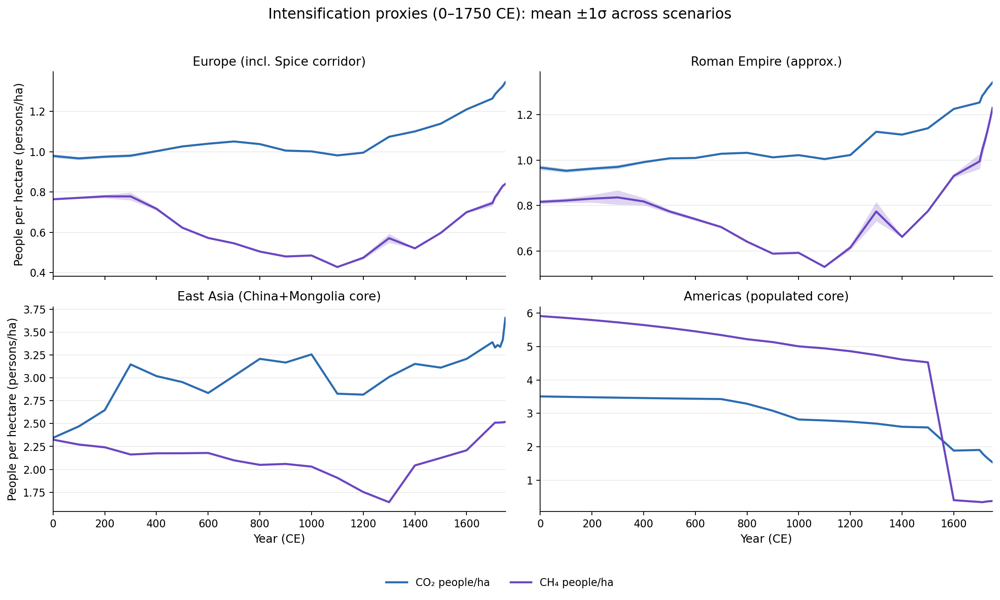

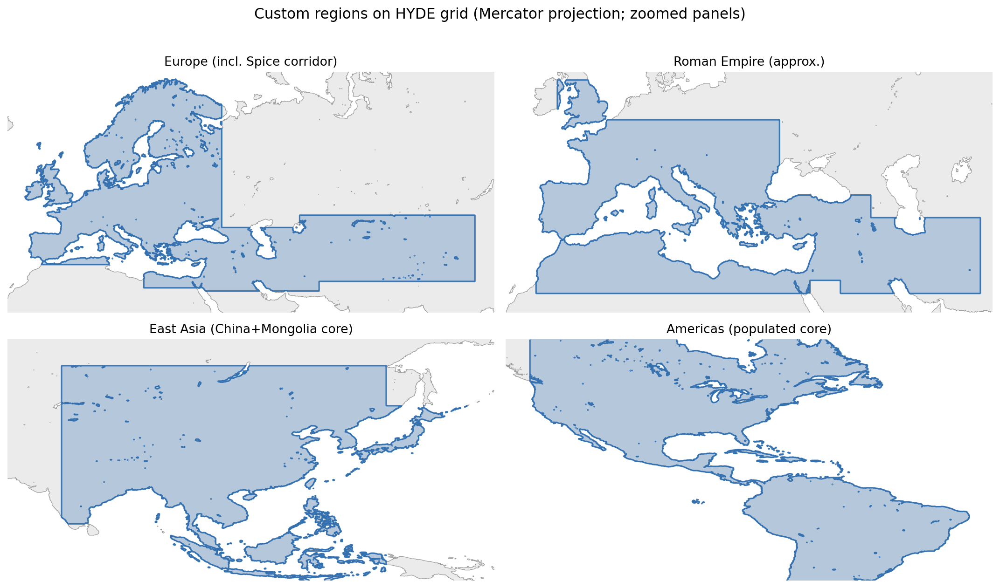


Wrote:
  hyde35_anthropogenic_region_year_by_scenario.csv
  hyde35_anthropogenic_region_year_mean_std.csv


In [7]:
# hyde35_anthropogenic_regions_dualy.py
# HYDE 3.5 (0–1750 CE): Custom regions + population density + CH4/CO2 land-use proxies
# + anthropogenic pressure metrics + dual-y plot:
#       population density  vs  "cropland productivity" = persons per Mha of total cropland
# + line plots (mean±1σ) for intensification proxies (CO2/CH4 people per hectare)
#
# Key updates requested:
#   - East Asia mask: include more of China + Mongolia, exclude more of Central Asia
#   - Smoother plots when time resolution is sufficiently fine (auto-rolling smoothing for plotting only)
#
# Plug-and-run:
#   1) cd into your HYDE 3.5 root directory (contains gbc2025_* scenario folders + general_files/)
#   2) python hyde35_anthropogenic_regions_dualy.py
#
# Outputs:
#   - Figures:
#       A) Pop density (mean±1σ)
#       B) CO2/CH4 proxy land areas (mean±1σ)
#       C) Anthropogenic Pressure Index (API) (mean±1σ)
#       D) Dual-y: Pop density (left) vs persons per Mha cropland (right) (mean±1σ)
#       E) Intensification proxies (mean±1σ): CO2 people/ha and CH4 people/ha
#       F) Mercator region maps (2×2)
#   - CSVs:
#       hyde35_anthropogenic_region_year_by_scenario.csv
#       hyde35_anthropogenic_region_year_mean_std.csv
#
# Definitions:
#   - CO2 proxy land = non-rice cropland
#   - CH4 proxy land = rice + grazing land
#   - Total cropland (Mha) = rice + non-rice cropland
#   - “Cropland productivity” = persons per Mha of total cropland = pop_total / total_cropland_mha
#   - Intensification proxies (persons/ha):
#       CO2 people/ha = pop_total / (co2_mha * 1e6)
#       CH4 people/ha = pop_total / (ch4_mha * 1e6)
#
# Smoothing:
#   - Only affects plotted series (not the exported CSVs).
#   - If median year step <= 5: uses centered rolling window 7
#     if median year step <= 10: uses centered rolling window 5
#     else: no smoothing.

from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ----------------------------
# User config
# ----------------------------
START_YEAR = 0
END_YEAR = 1750

SPICE_LON_MAX = 105  # degrees East in [-180,180) convention

REGION_ORDER = [
    "Europe (incl. Spice corridor)",
    "Roman Empire (approx.)",
    "East Asia (China+Mongolia core)",
    "Americas (populated core)",
]

CLASS_CO2 = "CO₂ land-use proxy (non-rice cropland)"
CLASS_CH4 = "CH₄ biogenic proxy (rice + grazing/ruminants)"

BLUE = "#2b6cb0"
PURPLE = "#6b46c1"
SHADE_ALPHA = 0.22

AUTO_SMOOTH_PLOTS = True

plt.rcParams.update(
    {
        "figure.dpi": 160,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

# ----------------------------
# File discovery (HYDE 3.5 nested general_files)
# ----------------------------
def _first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p.exists():
            return p
    return None


def find_general_file(root: Path, filename: str) -> Path:
    candidates = [
        root / "general_files" / "general_files" / filename,
        root / "general_files" / filename,
        root / filename,
    ]
    hit = _first_existing(candidates)
    if hit:
        return hit

    gf = root / "general_files"
    if gf.exists():
        hits = list(gf.rglob(filename))
        if hits:
            return hits[0]

    hits = list(root.rglob(filename))
    if hits:
        return hits[0]

    raise FileNotFoundError(f"Could not find '{filename}' under {root}.")


# ----------------------------
# Scenario discovery
# ----------------------------
def discover_scenarios(root: Path) -> List[Tuple[str, Path]]:
    pop_files = sorted(root.glob("*/NetCDF/population.nc"))
    out: List[Tuple[str, Path]] = []
    for pop_nc in pop_files:
        scen_dir = pop_nc.parent.parent
        label = scen_dir.name
        m = re.search(r"(base|lower|upper)", label, flags=re.IGNORECASE)
        if m:
            label = m.group(1).lower()
        out.append((label, scen_dir))

    order = {"base": 0, "lower": 1, "upper": 2}
    out.sort(key=lambda t: (order.get(t[0], 99), t[0]))
    return out


# ----------------------------
# Lat/lon standardization
# ----------------------------
def ensure_latlon(ds: xr.Dataset) -> xr.Dataset:
    rename: Dict[str, str] = {}
    for name in list(ds.dims) + list(ds.coords):
        low = name.lower()
        if low in ("latitude", "nav_lat", "y") and "lat" not in ds.dims and "lat" not in ds.coords:
            rename[name] = "lat"
        if low in ("longitude", "nav_lon", "x") and "lon" not in ds.dims and "lon" not in ds.coords:
            rename[name] = "lon"
    if rename:
        ds = ds.rename(rename)

    if "lat" not in ds.coords:
        if "lat" in ds.dims:
            ds = ds.assign_coords(lat=ds["lat"])
        else:
            raise ValueError(f"Dataset missing 'lat'. dims={ds.dims}, coords={list(ds.coords)}")
    if "lon" not in ds.coords:
        if "lon" in ds.dims:
            ds = ds.assign_coords(lon=ds["lon"])
        else:
            raise ValueError(f"Dataset missing 'lon'. dims={ds.dims}, coords={list(ds.coords)}")
    return ds


# ----------------------------
# ESRI ASCII reader + alignment
# ----------------------------
def read_esri_ascii_grid(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing ASCII grid: {path}")

    header: Dict[str, float] = {}
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(6):
            line = f.readline()
            if not line:
                raise ValueError(f"Unexpected EOF reading header of {path}")
            k, v = line.strip().split()[:2]
            header[k.lower()] = float(v) if ("." in v or "e" in v.lower()) else int(v)
        data = np.loadtxt(f)

    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    cell = float(header["cellsize"])

    if data.shape != (nrows, ncols):
        raise ValueError(f"{path}: header says ({nrows},{ncols}) but data is {data.shape}")

    if "xllcorner" in header:
        xll = float(header["xllcorner"])
    elif "xllcenter" in header:
        xll = float(header["xllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing xllcorner/xllcenter")

    if "yllcorner" in header:
        yll = float(header["yllcorner"])
    elif "yllcenter" in header:
        yll = float(header["yllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing yllcorner/yllcenter")

    nodata = header.get("nodata_value", None)

    lon = xll + cell * (0.5 + np.arange(ncols))
    lat = yll + cell * (nrows - 0.5 - np.arange(nrows))  # north->south

    da = xr.DataArray(data, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name=path.stem)
    if nodata is not None:
        da = da.where(da != nodata)
    return da


def _lon_to_180_vals(lon_vals: np.ndarray) -> np.ndarray:
    lon_vals = np.asarray(lon_vals, dtype=float)
    return (((lon_vals + 180.0) % 360.0) - 180.0)


def normalize_longitudes_to_match(da: xr.DataArray, target_lon: xr.DataArray) -> xr.DataArray:
    da = da.copy()
    lon_da = da["lon"].values
    lon_t = target_lon.values
    tmin = float(np.nanmin(lon_t))

    # target is [0,360)
    if tmin >= 0 and np.nanmin(lon_da) < 0:
        da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon")

    # target is [-180,180)
    if tmin < 0 and np.nanmin(lon_da) >= 0:
        da = da.assign_coords(lon=_lon_to_180_vals(da["lon"].values)).sortby("lon")

    return da


def align_grid_to_dataset(da: xr.DataArray, ds_template: xr.Dataset) -> xr.DataArray:
    da2 = normalize_longitudes_to_match(da, ds_template["lon"])
    return da2.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")


# ----------------------------
# NetCDF open + year handling
# ----------------------------
def open_single_var_nc(path: Path) -> xr.DataArray:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing NetCDF: {path}")

    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    engines = [None, "netcdf4", "h5netcdf"]
    last_err = None

    for eng in engines:
        for use_chunks in (True, False):
            try:
                kw = dict(decode_times=time_coder, cache=False)
                if use_chunks:
                    kw["chunks"] = {"time": 1}
                ds = xr.open_dataset(path, engine=eng, **kw) if eng else xr.open_dataset(path, **kw)
                ds = ensure_latlon(ds)

                data_vars = list(ds.data_vars)
                if not data_vars:
                    raise ValueError(f"No data variables in {path}")

                if len(data_vars) == 1:
                    return ds[data_vars[0]]

                stem = path.stem.lower()
                for v in data_vars:
                    if stem in v.lower():
                        return ds[v]
                return ds[data_vars[0]]
            except Exception as e:
                last_err = e
                continue

    raise OSError(f"Failed to open {path}. Last error: {last_err}")


def coerce_year_index(da: xr.DataArray) -> xr.DataArray:
    if "year" in da.coords:
        t = da["year"]
    elif "time" in da.coords:
        t = da["time"]
    else:
        raise ValueError("No 'time' or 'year' coordinate found.")

    try:
        years = t.dt.year.astype(int).values
    except Exception:
        vals = np.asarray(t.values)
        if vals.size and hasattr(vals.flat[0], "year"):
            years = np.array([v.year for v in vals.ravel()], dtype=int).reshape(vals.shape)
        else:
            years = np.rint(vals.astype(float)).astype(int)

    dim = t.dims[0] if t.dims else None
    if dim is None:
        da = da.assign_coords(year=years)
    else:
        da = da.assign_coords(year=(dim, years))
        if dim != "year" and np.unique(years).size == years.size:
            da = da.swap_dims({dim: "year"})
    return da


def subset_years(da: xr.DataArray, start_year: int, end_year: int) -> xr.DataArray:
    da = coerce_year_index(da)
    if "year" in da.dims:
        da = da.sortby("year")
        return da.sel(year=slice(start_year, end_year))
    if "year" in da.coords:
        mask = (da["year"] >= start_year) & (da["year"] <= end_year)
        return da.where(mask, drop=True)
    raise ValueError("No 'year' coordinate could be constructed.")


# ----------------------------
# Constant grids: cell area + land mask
# ----------------------------
def load_cell_area_km2(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    p = find_general_file(root, "garea_cr.asc")
    da = read_esri_ascii_grid(p)
    da = align_grid_to_dataset(da, ds_template)
    da.name = "cell_area_km2"
    return da


def load_land_mask_optional(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    try:
        p = find_general_file(root, "landlake.asc")
    except FileNotFoundError:
        p = None

    lat = ds_template["lat"].values
    lon = ds_template["lon"].values

    if p is None or not Path(p).exists():
        warnings.warn("landlake.asc not found. Treating all grid cells as land.")
        return xr.DataArray(
            np.ones((lat.size, lon.size), dtype=float),
            dims=("lat", "lon"),
            coords={"lat": lat, "lon": lon},
            name="land_mask",
        )

    da = read_esri_ascii_grid(Path(p))
    da = align_grid_to_dataset(da, ds_template)
    lm = xr.where(da > 0, 1.0, 0.0).fillna(0.0)
    lm.name = "land_mask"

    frac_land = float(lm.mean().values)
    if frac_land < 0.01:
        warnings.warn("Aligned land mask has <1% land; using all-land fallback.")
        lm = xr.ones_like(lm)

    return lm


# ----------------------------
# Region masks (fixed for lon 0..360 datasets)
# ----------------------------
def build_region_masks(ds_template: xr.Dataset, land_mask: xr.DataArray) -> xr.DataArray:
    lat = ds_template["lat"]
    lon = ds_template["lon"]

    lon180_vals = _lon_to_180_vals(lon.values)
    lon180 = xr.DataArray(lon180_vals, dims=("lon",), coords={"lon": lon.values})

    LON180, LAT = xr.broadcast(lon180, lat)
    LON180 = LON180.transpose("lat", "lon")
    LAT = LAT.transpose("lat", "lon")

    def in_box(lon_min, lon_max, lat_min, lat_max):
        return (LON180 >= lon_min) & (LON180 <= lon_max) & (LAT >= lat_min) & (LAT <= lat_max)

    # Exclusions
    sahara = in_box(-17, 35, 15, 28)
    arabia = in_box(34, 60, 12, 27)
    exclude = sahara | arabia

    # 1) Europe + Spice corridor
    europe_core = in_box(-12, 40, 35, 72)
    spice_near_east = in_box(20, 65, 27, 45)
    spice_central_asia = in_box(60, SPICE_LON_MAX, 30, 48)
    europe = europe_core | (spice_near_east | spice_central_asia)

    # 2) Roman Empire (approx.)
    roman_west = in_box(-10, 30, 35, 51)
    roman_balkans = in_box(10, 30, 35, 46)
    roman_anatolia = in_box(20, 45, 34, 42)
    roman_levant = in_box(30, 42, 30, 38)
    roman_n_africa_coast = in_box(-10, 35, 28, 37)
    roman_iraq_iran = in_box(40, 63, 28, 39)
    roman_britain = in_box(-6.5, 2.5, 49.5, 55.2)
    roman = (
        roman_west | roman_balkans | roman_anatolia | roman_levant
        | roman_n_africa_coast | roman_iraq_iran | roman_britain
    )

    # 3) East Asia tuned:
    #    - "More of China": include Xinjiang/Tibet broadly (west to ~75E), south to ~10N, north to ~55N
    #    - "More of Mongolia": include broad Mongolia box
    #    - "Less Central Asia": exclude the 60–75E band (Kazakhstan/Central Asia) at mid-high latitudes
    china_broad = in_box(75, 135, 10, 55)
    mongolia_broad = in_box(85, 125, 38, 55)
    korea_japan = in_box(120, 150, 30, 46)
    se_asia = in_box(95, 135, -10, 25)
    manchuria = in_box(115, 135, 40, 55)

    # Central Asia exclusion (cuts the "Kazakh steppe / Central Asia" west band)
    # Keep Xinjiang (>=75E) and Mongolia (>=85E) intact.
    central_asia_excl = in_box(60, 75, 30, 55)

    eastasia = (china_broad | mongolia_broad | korea_japan | se_asia | manchuria) & (~central_asia_excl)

    # 4) Americas core
    americas = in_box(-125, -30, -35, 60)

    def finalize(mask_bool: xr.DataArray) -> xr.DataArray:
        m = mask_bool & (~exclude)
        m = xr.where(m, 1.0, 0.0)
        return (m * land_mask).astype(float)

    masks = xr.concat(
        [finalize(europe), finalize(roman), finalize(eastasia), finalize(americas)],
        dim="region",
    )
    masks = masks.assign_coords(region=("region", REGION_ORDER))
    masks.name = "region_masks"
    return masks


# ----------------------------
# Land-use helpers
# ----------------------------
def _string_attr(da: xr.DataArray, key: str) -> str:
    return str(da.attrs.get(key, "")).strip().lower()


def _looks_like_fraction(da: xr.DataArray) -> bool:
    units = _string_attr(da, "units")
    long_name = _string_attr(da, "long_name") + " " + _string_attr(da, "standard_name")
    if ("frac" in units) or ("fraction" in units) or ("fraction" in long_name):
        return True
    if units in ("", "1", "-"):
        try:
            sample = da.isel(time=0) if "time" in da.dims else (da.isel(year=0) if "year" in da.dims else da)
            vmax = float(sample.max().values)
            vmin = float(sample.min().values)
            return (vmin >= -1e-6) and (vmax <= 1.5)
        except Exception:
            return False
    return False


def landuse_regional_mha(
    nc_path: Path,
    region_masks: xr.DataArray,
    cell_area_km2: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None

    try:
        da = open_single_var_nc(nc_path)
    except Exception as e:
        warnings.warn(f"Skipping unreadable NetCDF: {nc_path.name} | {e}")
        return None

    da = subset_years(da, start_year, end_year)

    units = _string_attr(da, "units")
    frac = _looks_like_fraction(da)

    if frac:
        da_mha = (da * cell_area_km2) / 1e4
    else:
        if "km" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e4
        elif units in ("ha", "hectare", "hectares"):
            da_mha = da / 1e6
        elif "m" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e10
        else:
            warnings.warn(f"{nc_path.name}: Unrecognized units '{da.attrs.get('units','')}'. Assuming km² -> Mha via /1e4.")
            da_mha = da / 1e4

    da_mha = da_mha.rename("area_mha")
    reg = (da_mha * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "Mha"
    return reg


# ----------------------------
# Population helpers
# ----------------------------
def population_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> xr.DataArray:
    da = open_single_var_nc(nc_path)
    da = subset_years(da, start_year, end_year)
    reg = (da * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "persons"
    return reg


def optional_regional_persons(
    nc_path: Path,
    region_masks: xr.DataArray,
    start_year: int,
    end_year: int,
) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None
    try:
        return population_regional_persons(nc_path, region_masks, start_year, end_year)
    except Exception as e:
        warnings.warn(f"Could not read optional file {nc_path.name}: {e}")
        return None


# ----------------------------
# Stats + plotting helpers
# ----------------------------
def std0(x: pd.Series) -> float:
    return float(np.std(x.to_numpy(dtype=float), ddof=0))


def style_timeseries_ax(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)


def plot_mean_sigma(ax, x, mean, std, color, label=None):
    ax.plot(x, mean, color=color, linewidth=2.0, label=label)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=SHADE_ALPHA, linewidth=0)


def safe_log_series(s: pd.Series) -> pd.Series:
    v = s.to_numpy(dtype=float)
    v = np.where(np.isfinite(v) & (v > 0), v, np.nan)
    return pd.Series(np.log(v), index=s.index)


def zscore_by_group_safe(df: pd.DataFrame, col: str, group_cols: List[str]) -> pd.Series:
    if col not in df.columns:
        return pd.Series(np.zeros(len(df)), index=df.index, dtype=float)

    def _z(x: pd.Series) -> pd.Series:
        v = x.to_numpy(dtype=float)
        mu = np.nanmean(v)
        sd = np.nanstd(v)
        if not np.isfinite(sd) or sd == 0:
            return pd.Series(np.zeros_like(v), index=x.index)
        return (x - mu) / sd

    return df.groupby(group_cols, group_keys=False)[col].apply(_z)


def smooth_for_plot(df: pd.DataFrame, ycols: List[str], year_col: str = "year") -> pd.DataFrame:
    """
    Plot-only smoothing: centered rolling mean on ycols, leaving other cols untouched.
    Window is chosen based on median year step.
    """
    if not AUTO_SMOOTH_PLOTS or df.empty:
        return df

    years = df[year_col].to_numpy(dtype=float)
    if years.size < 10:
        return df

    dy = np.diff(np.sort(np.unique(years)))
    dy = dy[np.isfinite(dy) & (dy > 0)]
    if dy.size == 0:
        return df
    step = float(np.median(dy))

    if step <= 5:
        win = 7
    elif step <= 10:
        win = 5
    else:
        return df

    out = df.copy()
    out = out.sort_values(year_col)
    for c in ycols:
        if c in out.columns:
            out[c] = out[c].rolling(window=win, center=True, min_periods=max(2, win // 2)).mean()
    return out


# Mercator helpers (no cartopy)
def mercator_y(lat_deg: np.ndarray) -> np.ndarray:
    lat = np.asarray(lat_deg, dtype=float)
    lat = np.clip(lat, -85.0, 85.0)
    phi = np.deg2rad(lat)
    return np.log(np.tan(np.pi / 4.0 + phi / 2.0))


def coord_edges_1d(coord: np.ndarray) -> np.ndarray:
    c = np.asarray(coord, dtype=float)
    if c.size < 2:
        raise ValueError("Need at least 2 points to compute edges.")
    d = np.diff(c)
    first = c[0] - d[0] / 2.0
    last = c[-1] + d[-1] / 2.0
    mid = c[:-1] + d / 2.0
    return np.concatenate([[first], mid, [last]])


def to_lon180_sorted(da: xr.DataArray) -> xr.DataArray:
    lon_vals = da["lon"].values
    lon180_vals = _lon_to_180_vals(lon_vals)
    return da.assign_coords(lon=lon180_vals).sortby("lon")


def sel_box_latlon(da: xr.DataArray, lon_min: float, lon_max: float, lat_min: float, lat_max: float) -> xr.DataArray:
    lat = da["lat"].values
    if lat[0] < lat[-1]:
        da2 = da.sel(lat=slice(lat_min, lat_max))
    else:
        da2 = da.sel(lat=slice(lat_max, lat_min))
    da2 = da2.sel(lon=slice(lon_min, lon_max))
    return da2.sortby("lat")


# ----------------------------
# MAIN
# ----------------------------
ROOT = Path(".").resolve()
scenarios = discover_scenarios(ROOT)
if not scenarios:
    raise RuntimeError(
        "No scenarios found. Expected folders like 'gbc2025_7apr_base' with 'NetCDF/population.nc'. "
        "Run from the HYDE 3.5 root directory."
    )

print("Found scenarios:", ", ".join([f"{lab}:{p.name}" for lab, p in scenarios]))

template_label, template_dir = scenarios[0]
template_ds = xr.open_dataset(template_dir / "NetCDF" / "population.nc")
template_ds = ensure_latlon(template_ds)

print(f"Template lon range: {float(template_ds['lon'].min()):.3f} .. {float(template_ds['lon'].max()):.3f}")
print(f"Template lat range: {float(template_ds['lat'].min()):.3f} .. {float(template_ds['lat'].max()):.3f}")

cell_area_km2 = load_cell_area_km2(ROOT, template_ds)
land_mask = load_land_mask_optional(ROOT, template_ds)
region_masks = build_region_masks(template_ds, land_mask)

land_area_reg_km2 = (cell_area_km2 * region_masks).sum(dim=("lat", "lon"), skipna=True).rename("land_area_km2").astype(float)
print("\nLand area by region (km²):")
print(land_area_reg_km2.to_dataframe().reset_index())

if float(land_area_reg_km2.max().values) <= 0:
    raise RuntimeError("All region land areas are zero. Masks are not aligning with NetCDF lon/lat.")

pop_rows: List[pd.DataFrame] = []
ag_rows: List[pd.DataFrame] = []
extra_rows: List[pd.DataFrame] = []

for scen_label, scen_dir in scenarios:
    print(f"Processing scenario: {scen_label} ({scen_dir.name})")

    # Population totals
    pop_reg = population_regional_persons(scen_dir / "NetCDF" / "population.nc", region_masks, START_YEAR, END_YEAR)

    # Optional urban population and urban area
    urb_pop_reg = optional_regional_persons(scen_dir / "NetCDF" / "urban_population.nc", region_masks, START_YEAR, END_YEAR)
    urb_area_reg = landuse_regional_mha(scen_dir / "NetCDF" / "urban_area.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    # Density
    dens = (pop_reg / xr.where(land_area_reg_km2 > 0, land_area_reg_km2, np.nan)).rename("pop_density_p_km2")

    dens_df = dens.to_dataframe(name="pop_density_p_km2").reset_index()
    dens_df["scenario"] = scen_label

    pop_df = pop_reg.to_dataframe(name="pop_total").reset_index()
    pop_df["scenario"] = scen_label

    # Urban merge
    if urb_pop_reg is not None:
        up = urb_pop_reg.to_dataframe(name="urban_pop").reset_index()
        up["scenario"] = scen_label
        base = pop_df.merge(up, on=["year", "region", "scenario"], how="left")
        base["urban_share"] = base["urban_pop"] / base["pop_total"]
    else:
        base = pop_df.copy()
        base["urban_pop"] = np.nan
        base["urban_share"] = np.nan

    if urb_area_reg is not None:
        ua = urb_area_reg.to_dataframe(name="urban_area_mha").reset_index()
        ua["scenario"] = scen_label
        base = base.merge(ua, on=["year", "region", "scenario"], how="left")
    else:
        base["urban_area_mha"] = np.nan

    base = base.merge(
        dens_df[["scenario", "year", "region", "pop_density_p_km2"]],
        on=["scenario", "year", "region"],
        how="left",
    )

    pop_rows.append(
        base[
            [
                "scenario",
                "year",
                "region",
                "pop_total",
                "pop_density_p_km2",
                "urban_pop",
                "urban_share",
                "urban_area_mha",
            ]
        ]
    )

    # -------- Land-use proxies --------
    rice_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    rice_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (rice_rf is not None) or (rice_ir is not None):
        rice_reg = (0 if rice_rf is None else rice_rf.fillna(0)) + (0 if rice_ir is None else rice_ir.fillna(0))
    else:
        rice_reg = landuse_regional_mha(scen_dir / "NetCDF" / "total_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    grazing_reg = landuse_regional_mha(scen_dir / "NetCDF" / "grazing_land.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if grazing_reg is None:
        pasture_reg = landuse_regional_mha(scen_dir / "NetCDF" / "pasture.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        rangeland_reg = landuse_regional_mha(scen_dir / "NetCDF" / "rangeland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if (pasture_reg is not None) or (rangeland_reg is not None):
            grazing_reg = (0 if pasture_reg is None else pasture_reg.fillna(0)) + (0 if rangeland_reg is None else rangeland_reg.fillna(0))

    nr_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    nr_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (nr_rf is not None) or (nr_ir is not None):
        nonrice_reg = (0 if nr_rf is None else nr_rf.fillna(0)) + (0 if nr_ir is None else nr_ir.fillna(0))
    else:
        cropt = landuse_regional_mha(scen_dir / "NetCDF" / "cropland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if cropt is not None and rice_reg is not None:
            nonrice_reg = (cropt - rice_reg.fillna(0)).clip(min=0)
            warnings.warn(f"{scen_dir.name}: Using cropland.nc minus rice as non-rice cropland fallback.")
        elif cropt is not None:
            nonrice_reg = cropt
            warnings.warn(f"{scen_dir.name}: Using cropland.nc as non-rice cropland fallback (rice unavailable).")
        else:
            nonrice_reg = None

    # Total cropland (Mha) = rice + non-rice
    if (rice_reg is not None) or (nonrice_reg is not None):
        rr = 0 if rice_reg is None else rice_reg.fillna(0)
        nn = 0 if nonrice_reg is None else nonrice_reg.fillna(0)
        total_cropland_mha = (rr + nn).rename("total_cropland_mha")
    else:
        total_cropland_mha = None

    # CH4 proxy = rice + grazing
    ch4_reg = None
    if (rice_reg is not None) or (grazing_reg is not None):
        r = 0 if rice_reg is None else rice_reg.fillna(0)
        g = 0 if grazing_reg is None else grazing_reg.fillna(0)
        ch4_reg = r + g
        df = ch4_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CH4
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # CO2 proxy = non-rice cropland
    co2_reg = None
    if nonrice_reg is not None:
        co2_reg = nonrice_reg
        df = co2_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CO2
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # -------- Scenario-level derived objects --------
    P = pop_df.copy()

    if ch4_reg is not None:
        T = ch4_reg.to_dataframe(name="ch4_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "ch4_mha"]], on=["scenario", "year", "region"], how="left")
    else:
        P["ch4_mha"] = np.nan

    if co2_reg is not None:
        T = co2_reg.to_dataframe(name="co2_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "co2_mha"]], on=["scenario", "year", "region"], how="left")
    else:
        P["co2_mha"] = np.nan

    if total_cropland_mha is not None:
        T = total_cropland_mha.to_dataframe(name="total_cropland_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario", "year", "region", "total_cropland_mha"]],
                    on=["scenario", "year", "region"], how="left")
    else:
        P["total_cropland_mha"] = np.nan

    land_mha_df = (land_area_reg_km2 / 1e4).to_dataframe(name="land_mha").reset_index()
    P = P.merge(land_mha_df, on=["region"], how="left")

    # Intensification proxies (persons/ha)
    P["co2_people_per_ha"] = P["pop_total"] / (P["co2_mha"] * 1e6)
    P["ch4_people_per_ha"] = P["pop_total"] / (P["ch4_mha"] * 1e6)

    # Cropland productivity (persons/Mha)
    P["persons_per_mha_cropland"] = P["pop_total"] / P["total_cropland_mha"]

    extra_rows.append(
        P[
            [
                "scenario",
                "year",
                "region",
                "pop_total",
                "co2_mha",
                "ch4_mha",
                "total_cropland_mha",
                "co2_people_per_ha",
                "ch4_people_per_ha",
                "persons_per_mha_cropland",
            ]
        ]
    )

# Concatenate
pop_all = pd.concat(pop_rows, ignore_index=True)
ag_all = pd.concat(ag_rows, ignore_index=True) if ag_rows else pd.DataFrame(columns=["scenario", "year", "region", "class", "area_mha"])
extra_all = pd.concat(extra_rows, ignore_index=True) if extra_rows else pd.DataFrame()

# Across-scenario stats (std across scenarios)
popdens_stats = (
    pop_all.groupby(["year", "region"], as_index=False)
    .agg(mean=("pop_density_p_km2", "mean"), std=("pop_density_p_km2", lambda x: float(np.std(x.to_numpy(float), ddof=0))))
)

ag_stats = (
    ag_all.groupby(["year", "region", "class"], as_index=False)
    .agg(mean=("area_mha", "mean"), std=("area_mha", lambda x: float(np.std(x.to_numpy(float), ddof=0))))
)

extra_stats = (
    extra_all.groupby(["year", "region"], as_index=False)
    .agg(
        persons_per_mha_cropland_mean=("persons_per_mha_cropland", lambda x: float(np.nanmean(x.to_numpy(float)))),
        persons_per_mha_cropland_std=("persons_per_mha_cropland", lambda x: float(np.nanstd(x.to_numpy(float), ddof=0))),

        co2_people_per_ha_mean=("co2_people_per_ha", lambda x: float(np.nanmean(x.to_numpy(float)))),
        co2_people_per_ha_std=("co2_people_per_ha", lambda x: float(np.nanstd(x.to_numpy(float), ddof=0))),

        ch4_people_per_ha_mean=("ch4_people_per_ha", lambda x: float(np.nanmean(x.to_numpy(float)))),
        ch4_people_per_ha_std=("ch4_people_per_ha", lambda x: float(np.nanstd(x.to_numpy(float), ddof=0))),
    )
)

# ----------------------------
# API (Anthropogenic Pressure Index) — bulletproof
# ----------------------------
api_df = extra_all.merge(
    pop_all[["scenario", "year", "region", "urban_area_mha"]],
    on=["scenario", "year", "region"],
    how="left",
)

for c in ["pop_total", "co2_mha", "ch4_mha", "urban_area_mha"]:
    if c in api_df.columns:
        api_df[f"log_{c}"] = safe_log_series(api_df[c])

api_df["z_log_pop"] = zscore_by_group_safe(api_df, "log_pop_total", ["region"])
api_df["z_log_co2"] = zscore_by_group_safe(api_df, "log_co2_mha", ["region"])
api_df["z_log_ch4"] = zscore_by_group_safe(api_df, "log_ch4_mha", ["region"])
api_df["z_log_urban"] = zscore_by_group_safe(api_df, "log_urban_area_mha", ["region"])
api_df["API"] = api_df["z_log_pop"] + api_df["z_log_co2"] + api_df["z_log_ch4"] + api_df["z_log_urban"]

api_stats = (
    api_df.groupby(["year", "region"], as_index=False)
    .agg(API_mean=("API", "mean"), API_std=("API", lambda x: float(np.std(x.to_numpy(float), ddof=0))))
)

# ----------------------------
# Plotting (smoothed where appropriate)
# ----------------------------

# FIGURE A: Population density
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()
for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    dfp = smooth_for_plot(df, ["mean", "std"])
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if dfp.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, dfp["year"].to_numpy(), dfp["mean"].to_numpy(float), dfp["std"].to_numpy(float), color=BLUE)

axs[0].set_ylabel("Population density (persons / km² land)")
axs[2].set_ylabel("Population density (persons / km² land)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# FIGURE B: Land-use proxies
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()
for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    df_r = ag_stats[ag_stats["region"] == region]
    if df_r.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    d_co2 = df_r[df_r["class"] == CLASS_CO2].sort_values("year")
    d_co2p = smooth_for_plot(d_co2, ["mean", "std"])
    if not d_co2p.empty:
        plot_mean_sigma(ax, d_co2p["year"].to_numpy(), d_co2p["mean"].to_numpy(float), d_co2p["std"].to_numpy(float),
                        color=BLUE, label=CLASS_CO2 if i == 0 else None)

    d_ch4 = df_r[df_r["class"] == CLASS_CH4].sort_values("year")
    d_ch4p = smooth_for_plot(d_ch4, ["mean", "std"])
    if not d_ch4p.empty:
        plot_mean_sigma(ax, d_ch4p["year"].to_numpy(), d_ch4p["mean"].to_numpy(float), d_ch4p["std"].to_numpy(float),
                        color=PURPLE, label=CLASS_CH4 if i == 0 else None)

axs[0].set_ylabel("Proxy land area (Mha)")
axs[2].set_ylabel("Proxy land area (Mha)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Agricultural proxies (0–1750 CE): mean ±1σ across HYDE scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=1, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# FIGURE C: API index
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()
for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = api_stats[api_stats["region"] == region].sort_values("year")
    dfp = smooth_for_plot(df, ["API_mean", "API_std"])
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if dfp.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue
    plot_mean_sigma(ax, dfp["year"].to_numpy(), dfp["API_mean"].to_numpy(float), dfp["API_std"].to_numpy(float), color="black")

axs[0].set_ylabel("API (z-scored composite)")
axs[2].set_ylabel("API (z-scored composite)")
axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Anthropogenic Pressure Index (0–1750 CE): mean ±1σ across scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# FIGURE D: Dual-y evolution — pop density vs persons/Mha cropland
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()
for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax2 = ax.twinx()

    d1 = popdens_stats[popdens_stats["region"] == region].sort_values("year")
    d2 = extra_stats[extra_stats["region"] == region].sort_values("year")
    d1p = smooth_for_plot(d1, ["mean", "std"])
    d2p = smooth_for_plot(d2, ["persons_per_mha_cropland_mean", "persons_per_mha_cropland_std"])

    ax.set_title(region)
    ax.spines["top"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax2.spines["top"].set_visible(False)
    ax.set_xlim(START_YEAR, END_YEAR)

    if not d1p.empty:
        plot_mean_sigma(ax, d1p["year"].to_numpy(), d1p["mean"].to_numpy(float), d1p["std"].to_numpy(float), color=BLUE)

    if not d2p.empty:
        x = d2p["year"].to_numpy()
        y = d2p["persons_per_mha_cropland_mean"].to_numpy(float)
        s = d2p["persons_per_mha_cropland_std"].to_numpy(float)
        ax2.plot(x, y, color=PURPLE, linewidth=2.0)
        ax2.fill_between(x, y - s, y + s, color=PURPLE, alpha=SHADE_ALPHA, linewidth=0)

    if i in (0, 2):
        ax.set_ylabel("Population density (persons / km² land)")
    if i in (1, 3):
        ax2.set_ylabel("Persons per Mha cropland (persons/Mha)")

axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density vs cropland ‘productivity’ (persons per Mha): mean ±1σ", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# FIGURE E: Intensification proxies as line plots — CO2 people/ha vs CH4 people/ha
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()
for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = extra_stats[extra_stats["region"] == region].sort_values("year")
    dfp = smooth_for_plot(df, ["co2_people_per_ha_mean", "co2_people_per_ha_std", "ch4_people_per_ha_mean", "ch4_people_per_ha_std"])
    ax.set_title(region)
    style_timeseries_ax(ax)
    ax.set_xlim(START_YEAR, END_YEAR)
    if dfp.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6)
        continue

    x = dfp["year"].to_numpy()

    y = dfp["co2_people_per_ha_mean"].to_numpy(float)
    s = dfp["co2_people_per_ha_std"].to_numpy(float)
    ax.plot(x, y, color=BLUE, linewidth=2.0, label="CO₂ people/ha" if i == 0 else None)
    ax.fill_between(x, y - s, y + s, color=BLUE, alpha=SHADE_ALPHA, linewidth=0)

    y = dfp["ch4_people_per_ha_mean"].to_numpy(float)
    s = dfp["ch4_people_per_ha_std"].to_numpy(float)
    ax.plot(x, y, color=PURPLE, linewidth=2.0, label="CH₄ people/ha" if i == 0 else None)
    ax.fill_between(x, y - s, y + s, color=PURPLE, alpha=SHADE_ALPHA, linewidth=0)

    if i in (0, 2):
        ax.set_ylabel("People per hectare (persons/ha)")

axs[2].set_xlabel("Year (CE)")
axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Intensification proxies (0–1750 CE): mean ±1σ across scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

# FIGURE F: Mercator region maps (2×2)
MAP_EXTENTS = {
    "Europe (incl. Spice corridor)": (-15, SPICE_LON_MAX + 5, 20, 72),
    "Roman Empire (approx.)": (-15, 65, 25, 56),
    "East Asia (China+Mongolia core)": (65, 155, -10, 60),
    "Americas (populated core)": (-130, -30, -35, 60),
}

land_plot = to_lon180_sorted(land_mask)
region_plot = to_lon180_sorted(region_masks)

land_cmap = ListedColormap([(1, 1, 1, 0), (0, 0, 0, 0.08)])
region_cmap = ListedColormap([(0, 0, 0, 0), (0.17, 0.42, 0.69, 0.28)])

fig, axs = plt.subplots(2, 2, figsize=(13.5, 8))
axs = axs.ravel()
for i, region_name in enumerate(REGION_ORDER):
    ax = axs[i]
    lon_min, lon_max, lat_min, lat_max = MAP_EXTENTS[region_name]

    land_sub = sel_box_latlon(land_plot, lon_min, lon_max, lat_min, lat_max)
    reg_sub = sel_box_latlon(region_plot.sel(region=region_name), lon_min, lon_max, lat_min, lat_max)

    lon = land_sub["lon"].values
    lat = land_sub["lat"].values
    lon_e = coord_edges_1d(lon)
    lat_e = coord_edges_1d(lat)
    y_e = mercator_y(lat_e)
    y = mercator_y(lat)

    ax.pcolormesh(lon_e, y_e, (land_sub.values > 0).astype(float), shading="auto", cmap=land_cmap)
    ax.pcolormesh(lon_e, y_e, reg_sub.values.astype(float), shading="auto", cmap=region_cmap)

    try:
        ax.contour(lon, y, (land_sub.values > 0).astype(float), levels=[0.5], colors="black", linewidths=0.6, alpha=0.35)
    except Exception:
        pass
    try:
        ax.contour(lon, y, reg_sub.values.astype(float), levels=[0.5], colors=BLUE, linewidths=1.4, alpha=0.9)
    except Exception:
        pass

    ax.set_title(region_name)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(mercator_y(lat_min), mercator_y(lat_max))
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig.suptitle("Custom regions on HYDE grid (Mercator projection; zoomed panels)", y=0.98, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------
# SAVE PANELS
# ----------------------------
panel_scenario = extra_all.merge(
    pop_all[["scenario", "year", "region", "pop_density_p_km2", "urban_share", "urban_area_mha"]],
    on=["scenario", "year", "region"],
    how="left",
)

panel_mean = (
    extra_stats.merge(popdens_stats[["year", "region", "mean", "std"]], on=["year", "region"], how="left")
    .rename(columns={"mean": "popdens_mean", "std": "popdens_std"})
    .merge(api_stats, on=["year", "region"], how="left")
)

panel_scenario.to_csv("hyde35_anthropogenic_region_year_by_scenario.csv", index=False)
panel_mean.to_csv("hyde35_anthropogenic_region_year_mean_std.csv", index=False)

print("\nWrote:")
print("  hyde35_anthropogenic_region_year_by_scenario.csv")
print("  hyde35_anthropogenic_region_year_mean_std.csv")

Found scenarios: base:gbc2025_7apr_base, lower:gbc2025_7apr_lower, upper:gbc2025_7apr_upper

Land area by region after inhabited pruning (km²):
                                 region  land_area_km2
0                         Europe (core)   7.363181e+06
1                Roman Empire (approx.)   7.402564e+06
2  Asia (China+Mongolia+Spice corridor)   2.189597e+07
3             Americas (populated core)   2.306108e+07
Processing scenario: base (gbc2025_7apr_base)
Processing scenario: lower (gbc2025_7apr_lower)
Processing scenario: upper (gbc2025_7apr_upper)


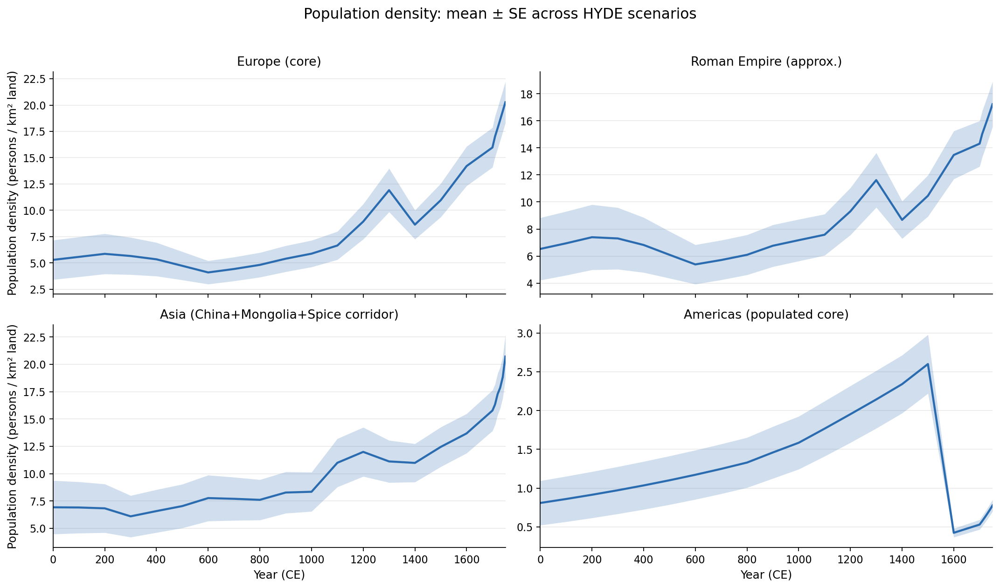

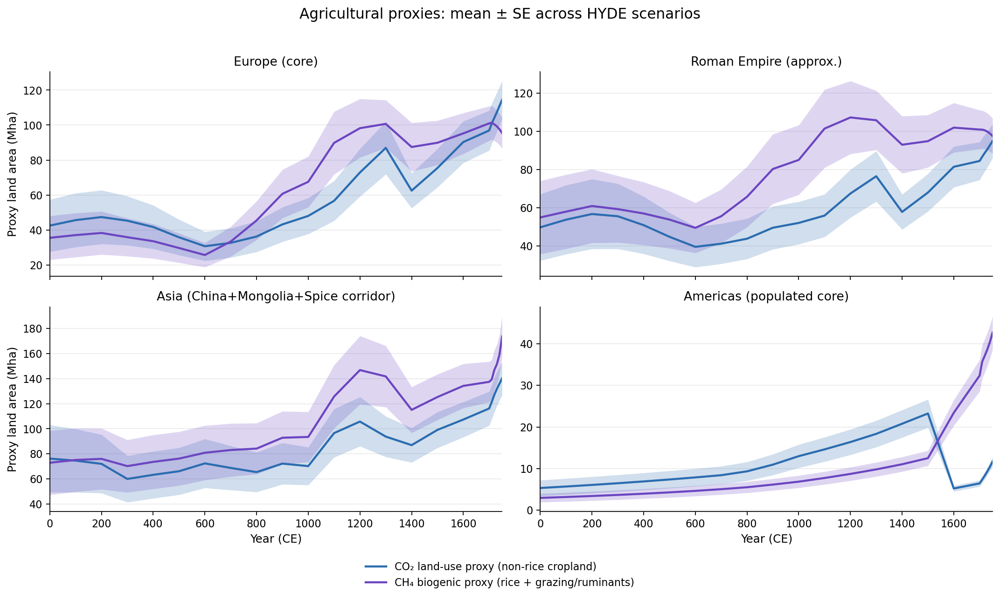

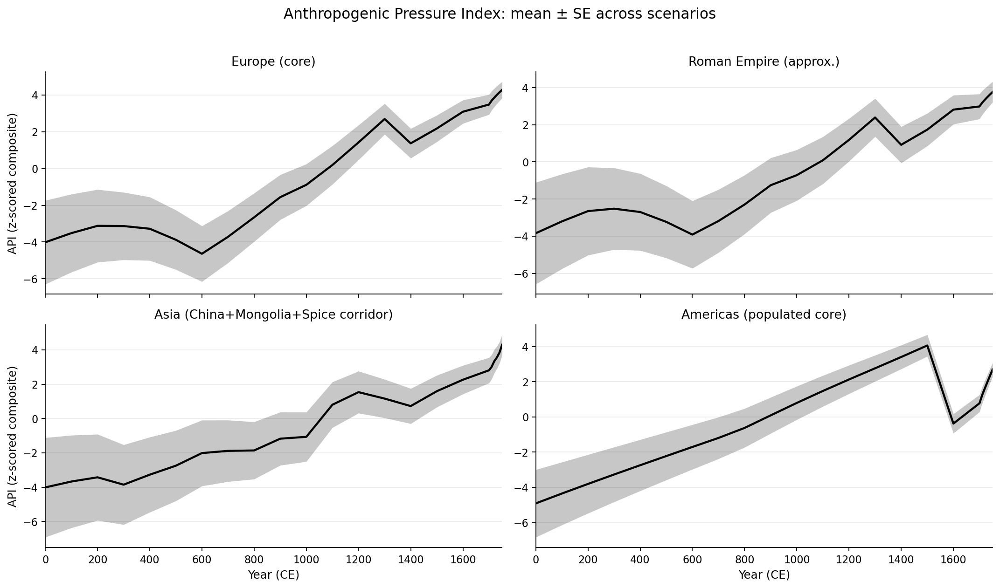

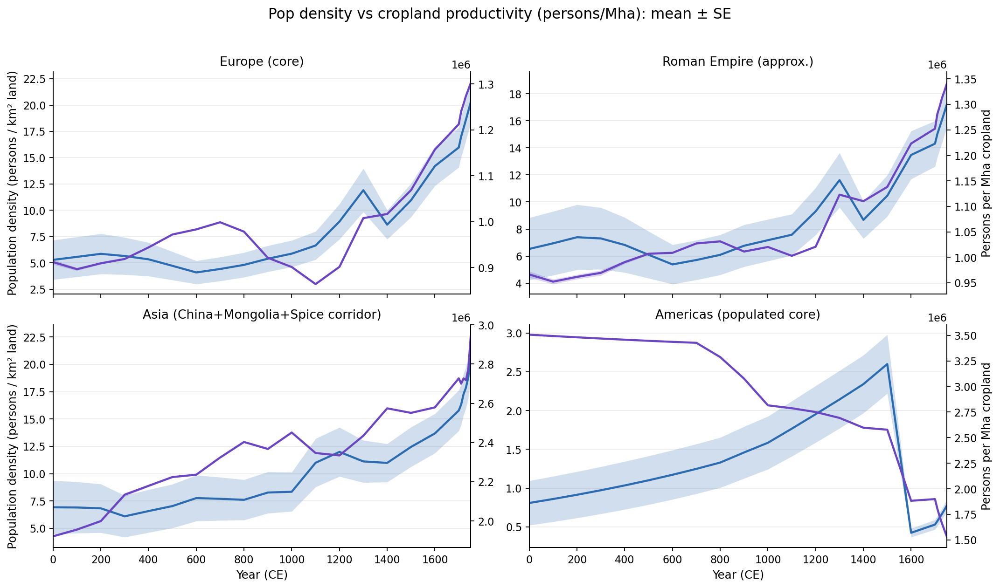

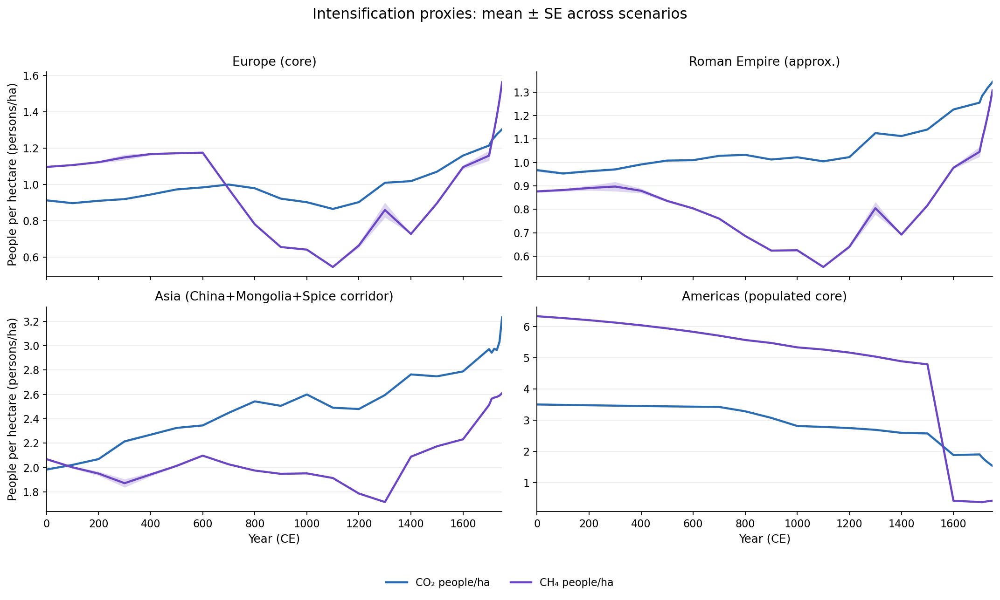

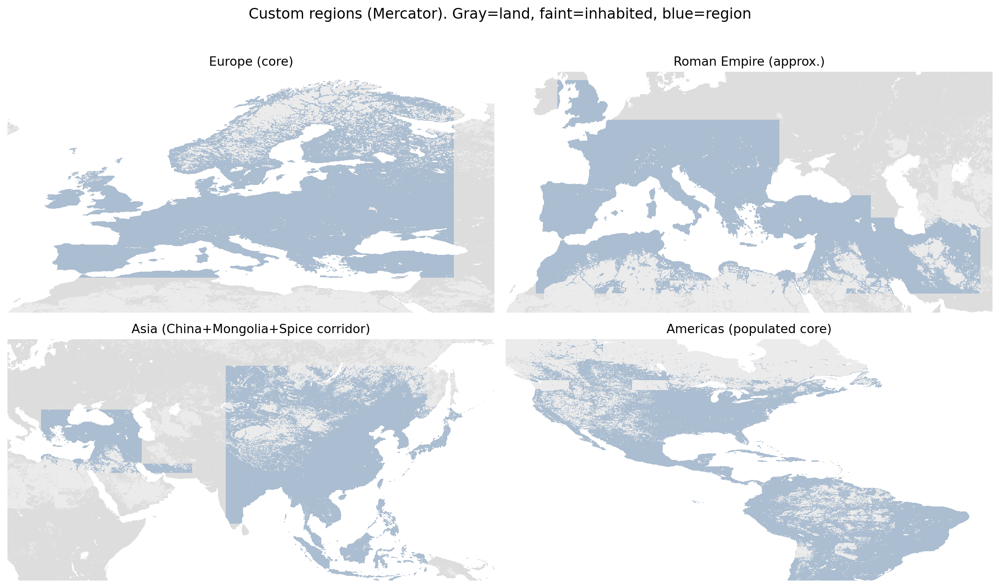


Wrote:
  hyde35_anthropogenic_region_year_by_scenario.csv
  hyde35_anthropogenic_region_year_mean_std_se.csv
  hyde35_anthropogenic_region_year_class_mean_std_se.csv


In [9]:
# hyde35_anthropogenic_regions_se_fix.py
# HYDE 3.5 (0–1750 CE): Custom regions + population density + CH4/CO2 land-use proxies
# + dual-y plot: pop density vs persons per Mha cropland
# + intensification line plots (CO2/CH4 people per hectare)
# + standard errors (SE) for everything (across scenarios)
#
# Fix vs last version:
#   - Replaced the failing groupby.apply(mean_std_se) with groupby.agg computing n/mean/std/se robustly.
#
# Requested region logic:
#   - Europe excludes spice corridor (Europe core only)
#   - Spice corridor moved into Asia
#   - Asia includes more of China + Mongolia, excludes much of Central Asia
#   - Prune non-populated areas via "ever inhabited" mask built from HYDE population (template scenario)
#
# Outputs:
#   - CSVs:
#       hyde35_anthropogenic_region_year_by_scenario.csv
#       hyde35_anthropogenic_region_year_mean_std_se.csv
#       hyde35_anthropogenic_region_year_class_mean_std_se.csv
#
# Dependencies: numpy, pandas, xarray, matplotlib

from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ----------------------------
# User config
# ----------------------------
START_YEAR = 0
END_YEAR = 1750

# spice corridor longitude max
SPICE_LON_MAX = 105

# population-based pruning threshold: a cell is "inhabited" if max pop over time >= this
POP_CELL_MIN_PERSONS = 1.0

# plot-only smoothing
AUTO_SMOOTH_PLOTS = True

REGION_ORDER = [
    "Europe (core)",
    "Roman Empire (approx.)",
    "Asia (China+Mongolia+Spice corridor)",
    "Americas (populated core)",
]

CLASS_CO2 = "CO₂ land-use proxy (non-rice cropland)"
CLASS_CH4 = "CH₄ biogenic proxy (rice + grazing/ruminants)"

BLUE = "#2b6cb0"
PURPLE = "#6b46c1"
SHADE_ALPHA = 0.22

plt.rcParams.update(
    {
        "figure.dpi": 160,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

# ----------------------------
# Helpers: file discovery
# ----------------------------
def _first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p.exists():
            return p
    return None

def find_general_file(root: Path, filename: str) -> Path:
    candidates = [
        root / "general_files" / "general_files" / filename,
        root / "general_files" / filename,
        root / filename,
    ]
    hit = _first_existing(candidates)
    if hit:
        return hit
    gf = root / "general_files"
    if gf.exists():
        hits = list(gf.rglob(filename))
        if hits:
            return hits[0]
    hits = list(root.rglob(filename))
    if hits:
        return hits[0]
    raise FileNotFoundError(f"Could not find '{filename}' under {root}.")

# ----------------------------
# Scenario discovery
# ----------------------------
def discover_scenarios(root: Path) -> List[Tuple[str, Path]]:
    pop_files = sorted(root.glob("*/NetCDF/population.nc"))
    out: List[Tuple[str, Path]] = []
    for pop_nc in pop_files:
        scen_dir = pop_nc.parent.parent
        label = scen_dir.name
        m = re.search(r"(base|lower|upper)", label, flags=re.IGNORECASE)
        if m:
            label = m.group(1).lower()
        out.append((label, scen_dir))
    order = {"base": 0, "lower": 1, "upper": 2}
    out.sort(key=lambda t: (order.get(t[0], 99), t[0]))
    return out

# ----------------------------
# Lat/lon and grids
# ----------------------------
def ensure_latlon(ds: xr.Dataset) -> xr.Dataset:
    rename: Dict[str, str] = {}
    for name in list(ds.dims) + list(ds.coords):
        low = name.lower()
        if low in ("latitude", "nav_lat", "y") and "lat" not in ds.dims and "lat" not in ds.coords:
            rename[name] = "lat"
        if low in ("longitude", "nav_lon", "x") and "lon" not in ds.dims and "lon" not in ds.coords:
            rename[name] = "lon"
    if rename:
        ds = ds.rename(rename)
    if "lat" not in ds.coords:
        if "lat" in ds.dims:
            ds = ds.assign_coords(lat=ds["lat"])
        else:
            raise ValueError("Dataset missing 'lat'.")
    if "lon" not in ds.coords:
        if "lon" in ds.dims:
            ds = ds.assign_coords(lon=ds["lon"])
        else:
            raise ValueError("Dataset missing 'lon'.")
    return ds

def read_esri_ascii_grid(path: Path) -> xr.DataArray:
    header: Dict[str, float] = {}
    with Path(path).open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(6):
            line = f.readline()
            k, v = line.strip().split()[:2]
            header[k.lower()] = float(v) if ("." in v or "e" in v.lower()) else int(v)
        data = np.loadtxt(f)

    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    cell = float(header["cellsize"])
    if data.shape != (nrows, ncols):
        raise ValueError(f"{path}: header says ({nrows},{ncols}) but data is {data.shape}")

    if "xllcorner" in header:
        xll = float(header["xllcorner"])
    elif "xllcenter" in header:
        xll = float(header["xllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing xllcorner/xllcenter")

    if "yllcorner" in header:
        yll = float(header["yllcorner"])
    elif "yllcenter" in header:
        yll = float(header["yllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing yllcorner/yllcenter")

    nodata = header.get("nodata_value", None)

    lon = xll + cell * (0.5 + np.arange(ncols))
    lat = yll + cell * (nrows - 0.5 - np.arange(nrows))  # north->south
    da = xr.DataArray(data, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name=Path(path).stem)
    if nodata is not None:
        da = da.where(da != nodata)
    return da

def _lon_to_180_vals(lon_vals: np.ndarray) -> np.ndarray:
    lon_vals = np.asarray(lon_vals, dtype=float)
    return (((lon_vals + 180.0) % 360.0) - 180.0)

def normalize_longitudes_to_match(da: xr.DataArray, target_lon: xr.DataArray) -> xr.DataArray:
    da = da.copy()
    lon_da = da["lon"].values
    lon_t = target_lon.values
    tmin = float(np.nanmin(lon_t))
    if tmin >= 0 and np.nanmin(lon_da) < 0:
        da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon")
    if tmin < 0 and np.nanmin(lon_da) >= 0:
        da = da.assign_coords(lon=_lon_to_180_vals(da["lon"].values)).sortby("lon")
    return da

def align_grid_to_dataset(da: xr.DataArray, ds_template: xr.Dataset) -> xr.DataArray:
    da2 = normalize_longitudes_to_match(da, ds_template["lon"])
    return da2.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")

def load_cell_area_km2(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    p = find_general_file(root, "garea_cr.asc")
    da = read_esri_ascii_grid(p)
    da = align_grid_to_dataset(da, ds_template)
    da.name = "cell_area_km2"
    return da

def load_land_mask_optional(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    try:
        p = find_general_file(root, "landlake.asc")
    except FileNotFoundError:
        p = None
    lat = ds_template["lat"].values
    lon = ds_template["lon"].values
    if p is None or not Path(p).exists():
        warnings.warn("landlake.asc not found. Treating all grid cells as land.")
        return xr.DataArray(np.ones((lat.size, lon.size), dtype=float), dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name="land_mask")
    da = read_esri_ascii_grid(Path(p))
    da = align_grid_to_dataset(da, ds_template)
    lm = xr.where(da > 0, 1.0, 0.0).fillna(0.0)
    lm.name = "land_mask"
    if float(lm.mean().values) < 0.01:
        warnings.warn("Aligned land mask has <1% land; using all-land fallback.")
        lm = xr.ones_like(lm)
    return lm

# ----------------------------
# NetCDF open + year handling
# ----------------------------
def open_single_var_nc(path: Path) -> xr.DataArray:
    path = Path(path)
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    engines = [None, "netcdf4", "h5netcdf"]
    last_err = None
    for eng in engines:
        for use_chunks in (True, False):
            try:
                kw = dict(decode_times=time_coder, cache=False)
                if use_chunks:
                    kw["chunks"] = {"time": 1}
                ds = xr.open_dataset(path, engine=eng, **kw) if eng else xr.open_dataset(path, **kw)
                ds = ensure_latlon(ds)
                dvs = list(ds.data_vars)
                if not dvs:
                    raise ValueError(f"No data variables in {path}")
                if len(dvs) == 1:
                    return ds[dvs[0]]
                stem = path.stem.lower()
                for v in dvs:
                    if stem in v.lower():
                        return ds[v]
                return ds[dvs[0]]
            except Exception as e:
                last_err = e
    raise OSError(f"Failed to open {path}. Last error: {last_err}")

def coerce_year_index(da: xr.DataArray) -> xr.DataArray:
    if "year" in da.coords:
        t = da["year"]
    elif "time" in da.coords:
        t = da["time"]
    else:
        raise ValueError("No 'time' or 'year' coordinate found.")
    try:
        years = t.dt.year.astype(int).values
    except Exception:
        vals = np.asarray(t.values)
        if vals.size and hasattr(vals.flat[0], "year"):
            years = np.array([v.year for v in vals.ravel()], dtype=int).reshape(vals.shape)
        else:
            years = np.rint(vals.astype(float)).astype(int)
    dim = t.dims[0] if t.dims else None
    if dim is None:
        da = da.assign_coords(year=years)
    else:
        da = da.assign_coords(year=(dim, years))
        if dim != "year" and np.unique(years).size == years.size:
            da = da.swap_dims({dim: "year"})
    return da

def subset_years(da: xr.DataArray, start_year: int, end_year: int) -> xr.DataArray:
    da = coerce_year_index(da)
    if "year" in da.dims:
        da = da.sortby("year")
        return da.sel(year=slice(start_year, end_year))
    mask = (da["year"] >= start_year) & (da["year"] <= end_year)
    return da.where(mask, drop=True)

# ----------------------------
# Inhabited mask (population-based pruning)
# ----------------------------
def build_inhabited_mask_from_population(population_nc: Path, ds_template: xr.Dataset) -> xr.DataArray:
    pop = open_single_var_nc(population_nc)
    pop = subset_years(pop, START_YEAR, END_YEAR)
    pop = coerce_year_index(pop)
    if "year" not in pop.dims:
        raise ValueError("Population has no year dimension; cannot build inhabited mask.")
    popmax = pop.max(dim="year", skipna=True)
    inh = xr.where(popmax >= float(POP_CELL_MIN_PERSONS), 1.0, 0.0).fillna(0.0)
    inh = inh.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")
    inh.name = "inhabited_mask"
    return inh

# ----------------------------
# Region masks (lon-safe; Europe excludes spice; Asia includes spice+China+Mongolia)
# ----------------------------
def build_region_masks(ds_template: xr.Dataset, land_mask: xr.DataArray, inhabited_mask: xr.DataArray) -> xr.DataArray:
    lat = ds_template["lat"]
    lon = ds_template["lon"]
    lon180_vals = _lon_to_180_vals(lon.values)
    lon180 = xr.DataArray(lon180_vals, dims=("lon",), coords={"lon": lon.values})
    LON180, LAT = xr.broadcast(lon180, lat)
    LON180 = LON180.transpose("lat", "lon")
    LAT = LAT.transpose("lat", "lon")

    def in_box(lon_min, lon_max, lat_min, lat_max):
        return (LON180 >= lon_min) & (LON180 <= lon_max) & (LAT >= lat_min) & (LAT <= lat_max)

    # Structural exclusions
    sahara = in_box(-17, 35, 15, 28)
    arabia = in_box(34, 60, 12, 27)
    exclude_structural = sahara | arabia

    # Europe core (no spice)
    europe = in_box(-12, 40, 35, 72)

    # Roman (as before)
    roman = (
        in_box(-10, 30, 35, 51)
        | in_box(10, 30, 35, 46)
        | in_box(20, 45, 34, 42)
        | in_box(30, 42, 30, 38)
        | in_box(-10, 35, 28, 37)
        | in_box(40, 63, 28, 39)
        | in_box(-6.5, 2.5, 49.5, 55.2)
    )

    # Asia: China+Mongolia + Korea/Japan + SE Asia + spice corridor
    china_broad = in_box(75, 135, 10, 55)
    mongolia_broad = in_box(85, 125, 38, 55)
    korea_japan = in_box(120, 150, 30, 46)
    se_asia = in_box(95, 135, -10, 25)
    manchuria = in_box(115, 135, 40, 55)

    spice_near_east = in_box(20, 65, 27, 45)
    spice_central_asia = in_box(60, SPICE_LON_MAX, 30, 48)
    spice_corridor = spice_near_east | spice_central_asia

    # Exclude most “Central Asia” west band to reduce Kazakhstan bleed, but keep Xinjiang (>=75E)
    central_asia_excl = in_box(50, 75, 30, 55)

    asia = (china_broad | mongolia_broad | korea_japan | se_asia | manchuria | spice_corridor) & (~central_asia_excl)

    # Americas core
    americas = in_box(-125, -30, -35, 60)

    def finalize(mask_bool: xr.DataArray) -> xr.DataArray:
        m = mask_bool & (~exclude_structural)
        m = xr.where(m, 1.0, 0.0)
        return (m * land_mask * inhabited_mask).astype(float)

    masks = xr.concat(
        [finalize(europe), finalize(roman), finalize(asia), finalize(americas)],
        dim="region",
    )
    masks = masks.assign_coords(region=("region", REGION_ORDER))
    masks.name = "region_masks"
    return masks

# ----------------------------
# Land-use helpers
# ----------------------------
def _string_attr(da: xr.DataArray, key: str) -> str:
    return str(da.attrs.get(key, "")).strip().lower()

def _looks_like_fraction(da: xr.DataArray) -> bool:
    units = _string_attr(da, "units")
    long_name = _string_attr(da, "long_name") + " " + _string_attr(da, "standard_name")
    if ("frac" in units) or ("fraction" in units) or ("fraction" in long_name):
        return True
    if units in ("", "1", "-"):
        try:
            sample = da.isel(time=0) if "time" in da.dims else (da.isel(year=0) if "year" in da.dims else da)
            vmax = float(sample.max().values)
            vmin = float(sample.min().values)
            return (vmin >= -1e-6) and (vmax <= 1.5)
        except Exception:
            return False
    return False

def landuse_regional_mha(nc_path: Path, region_masks: xr.DataArray, cell_area_km2: xr.DataArray) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None
    try:
        da = open_single_var_nc(nc_path)
    except Exception as e:
        warnings.warn(f"Skipping unreadable NetCDF: {nc_path.name} | {e}")
        return None
    da = subset_years(da, START_YEAR, END_YEAR)
    units = _string_attr(da, "units")
    frac = _looks_like_fraction(da)
    if frac:
        da_mha = (da * cell_area_km2) / 1e4
    else:
        if "km" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e4
        elif units in ("ha", "hectare", "hectares"):
            da_mha = da / 1e6
        elif "m" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e10
        else:
            warnings.warn(f"{nc_path.name}: Unrecognized units '{da.attrs.get('units','')}'. Assuming km² -> Mha via /1e4.")
            da_mha = da / 1e4
    da_mha = da_mha.rename("area_mha")
    reg = (da_mha * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "Mha"
    return reg

def population_regional_persons(nc_path: Path, region_masks: xr.DataArray) -> xr.DataArray:
    da = open_single_var_nc(nc_path)
    da = subset_years(da, START_YEAR, END_YEAR)
    reg = (da * region_masks).sum(dim=("lat", "lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "persons"
    return reg

# ----------------------------
# Stats: robust n/mean/std/se for a column
# ----------------------------
def agg_n_mean_std_se(group: pd.core.groupby.generic.SeriesGroupBy) -> pd.DataFrame:
    # not used; we compute via groupby.agg with lambdas below
    raise NotImplementedError

def _n_finite(s: pd.Series) -> int:
    return int(np.isfinite(s.to_numpy(dtype=float)).sum())

def _mean_nan(s: pd.Series) -> float:
    return float(np.nanmean(s.to_numpy(dtype=float))) if _n_finite(s) else np.nan

def _std_nan_ddof0(s: pd.Series) -> float:
    x = s.to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.std(x, ddof=0)) if x.size else np.nan

def _se_from(s: pd.Series) -> float:
    x = s.to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n == 0:
        return np.nan
    sd = float(np.std(x, ddof=0))
    return float(sd / np.sqrt(n))

# ----------------------------
# Plot helpers (SE shading)
# ----------------------------
def style_timeseries_ax(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)

def plot_mean_se(ax, x, mean, se, color, label=None):
    ax.plot(x, mean, color=color, linewidth=2.0, label=label)
    ax.fill_between(x, mean - se, mean + se, color=color, alpha=SHADE_ALPHA, linewidth=0)

def smooth_for_plot(df: pd.DataFrame, ycols: List[str], year_col: str = "year") -> pd.DataFrame:
    if not AUTO_SMOOTH_PLOTS or df.empty:
        return df
    years = df[year_col].to_numpy(dtype=float)
    if years.size < 10:
        return df
    dy = np.diff(np.sort(np.unique(years)))
    dy = dy[np.isfinite(dy) & (dy > 0)]
    if dy.size == 0:
        return df
    step = float(np.median(dy))
    if step <= 5:
        win = 7
    elif step <= 10:
        win = 5
    else:
        return df
    out = df.sort_values(year_col).copy()
    for c in ycols:
        if c in out.columns:
            out[c] = out[c].rolling(window=win, center=True, min_periods=max(2, win // 2)).mean()
    return out

# Mercator helpers (no cartopy)
def mercator_y(lat_deg: np.ndarray) -> np.ndarray:
    lat = np.asarray(lat_deg, dtype=float)
    lat = np.clip(lat, -85.0, 85.0)
    phi = np.deg2rad(lat)
    return np.log(np.tan(np.pi / 4.0 + phi / 2.0))

def coord_edges_1d(coord: np.ndarray) -> np.ndarray:
    c = np.asarray(coord, dtype=float)
    if c.size < 2:
        raise ValueError("Need >=2 points for edges.")
    d = np.diff(c)
    first = c[0] - d[0] / 2.0
    last = c[-1] + d[-1] / 2.0
    mid = c[:-1] + d / 2.0
    return np.concatenate([[first], mid, [last]])

def to_lon180_sorted(da: xr.DataArray) -> xr.DataArray:
    lon_vals = da["lon"].values
    lon180_vals = _lon_to_180_vals(lon_vals)
    return da.assign_coords(lon=lon180_vals).sortby("lon")

def sel_box_latlon(da: xr.DataArray, lon_min: float, lon_max: float, lat_min: float, lat_max: float) -> xr.DataArray:
    lat = da["lat"].values
    if lat[0] < lat[-1]:
        da2 = da.sel(lat=slice(lat_min, lat_max))
    else:
        da2 = da.sel(lat=slice(lat_max, lat_min))
    da2 = da2.sel(lon=slice(lon_min, lon_max))
    return da2.sortby("lat")

# ----------------------------
# MAIN
# ----------------------------
ROOT = Path(".").resolve()
scenarios = discover_scenarios(ROOT)
if not scenarios:
    raise RuntimeError("No scenarios found (expected */NetCDF/population.nc). Run from HYDE root directory.")
print("Found scenarios:", ", ".join([f"{lab}:{p.name}" for lab, p in scenarios]))

template_label, template_dir = scenarios[0]
template_ds = ensure_latlon(xr.open_dataset(template_dir / "NetCDF" / "population.nc"))

cell_area_km2 = load_cell_area_km2(ROOT, template_ds)
land_mask = load_land_mask_optional(ROOT, template_ds)
inhabited_mask = build_inhabited_mask_from_population(template_dir / "NetCDF" / "population.nc", template_ds)

region_masks = build_region_masks(template_ds, land_mask, inhabited_mask)
land_area_reg_km2 = (cell_area_km2 * region_masks).sum(dim=("lat", "lon"), skipna=True).rename("land_area_km2").astype(float)

print("\nLand area by region after inhabited pruning (km²):")
print(land_area_reg_km2.to_dataframe().reset_index())

if float(land_area_reg_km2.max().values) <= 0:
    raise RuntimeError("All region land areas are zero. Mask alignment failed.")

# collect scenario-level rows
pop_rows, ag_rows, extra_rows = [], [], []

for scen_label, scen_dir in scenarios:
    print(f"Processing scenario: {scen_label} ({scen_dir.name})")

    # population totals + density
    pop_reg = population_regional_persons(scen_dir / "NetCDF" / "population.nc", region_masks)
    dens = (pop_reg / xr.where(land_area_reg_km2 > 0, land_area_reg_km2, np.nan)).rename("pop_density_p_km2")

    pop_df = pop_reg.to_dataframe(name="pop_total").reset_index()
    pop_df["scenario"] = scen_label
    dens_df = dens.to_dataframe(name="pop_density_p_km2").reset_index()
    dens_df["scenario"] = scen_label

    base = pop_df.merge(dens_df[["scenario", "year", "region", "pop_density_p_km2"]], on=["scenario", "year", "region"], how="left")

    # optional urban_area for API
    urb_area = landuse_regional_mha(scen_dir / "NetCDF" / "urban_area.nc", region_masks, cell_area_km2) if (scen_dir / "NetCDF" / "urban_area.nc").exists() else None
    if urb_area is not None:
        ua = urb_area.to_dataframe(name="urban_area_mha").reset_index()
        ua["scenario"] = scen_label
        base = base.merge(ua[["scenario", "year", "region", "urban_area_mha"]], on=["scenario", "year", "region"], how="left")
    else:
        base["urban_area_mha"] = np.nan

    pop_rows.append(base[["scenario", "year", "region", "pop_total", "pop_density_p_km2", "urban_area_mha"]])

    # land-use pieces
    rice_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_rice.nc", region_masks, cell_area_km2)
    rice_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_rice.nc", region_masks, cell_area_km2)
    if (rice_rf is not None) or (rice_ir is not None):
        rice_reg = (0 if rice_rf is None else rice_rf.fillna(0)) + (0 if rice_ir is None else rice_ir.fillna(0))
    else:
        rice_reg = landuse_regional_mha(scen_dir / "NetCDF" / "total_rice.nc", region_masks, cell_area_km2)

    grazing_reg = landuse_regional_mha(scen_dir / "NetCDF" / "grazing_land.nc", region_masks, cell_area_km2)
    if grazing_reg is None:
        pasture_reg = landuse_regional_mha(scen_dir / "NetCDF" / "pasture.nc", region_masks, cell_area_km2)
        rangeland_reg = landuse_regional_mha(scen_dir / "NetCDF" / "rangeland.nc", region_masks, cell_area_km2)
        if (pasture_reg is not None) or (rangeland_reg is not None):
            grazing_reg = (0 if pasture_reg is None else pasture_reg.fillna(0)) + (0 if rangeland_reg is None else rangeland_reg.fillna(0))

    nr_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_not_rice.nc", region_masks, cell_area_km2)
    nr_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_not_rice.nc", region_masks, cell_area_km2)
    if (nr_rf is not None) or (nr_ir is not None):
        nonrice_reg = (0 if nr_rf is None else nr_rf.fillna(0)) + (0 if nr_ir is None else nr_ir.fillna(0))
    else:
        cropt = landuse_regional_mha(scen_dir / "NetCDF" / "cropland.nc", region_masks, cell_area_km2)
        if cropt is not None and rice_reg is not None:
            nonrice_reg = (cropt - rice_reg.fillna(0)).clip(min=0)
        elif cropt is not None:
            nonrice_reg = cropt
        else:
            nonrice_reg = None

    # proxies
    ch4_reg = None
    if (rice_reg is not None) or (grazing_reg is not None):
        r = 0 if rice_reg is None else rice_reg.fillna(0)
        g = 0 if grazing_reg is None else grazing_reg.fillna(0)
        ch4_reg = r + g
        df = ch4_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CH4
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    co2_reg = None
    if nonrice_reg is not None:
        co2_reg = nonrice_reg
        df = co2_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CO2
        ag_rows.append(df[["scenario", "year", "region", "class", "area_mha"]])

    # total cropland
    if (rice_reg is not None) or (nonrice_reg is not None):
        rr = 0 if rice_reg is None else rice_reg.fillna(0)
        nn = 0 if nonrice_reg is None else nonrice_reg.fillna(0)
        total_cropland_mha = (rr + nn).rename("total_cropland_mha")
    else:
        total_cropland_mha = None

    # scenario derived panel
    P = pop_df[["scenario", "year", "region", "pop_total"]].copy()
    if ch4_reg is not None:
        T = ch4_reg.to_dataframe(name="ch4_mha").reset_index(); T["scenario"] = scen_label
        P = P.merge(T[["scenario","year","region","ch4_mha"]], on=["scenario","year","region"], how="left")
    else:
        P["ch4_mha"] = np.nan
    if co2_reg is not None:
        T = co2_reg.to_dataframe(name="co2_mha").reset_index(); T["scenario"] = scen_label
        P = P.merge(T[["scenario","year","region","co2_mha"]], on=["scenario","year","region"], how="left")
    else:
        P["co2_mha"] = np.nan
    if total_cropland_mha is not None:
        T = total_cropland_mha.to_dataframe(name="total_cropland_mha").reset_index(); T["scenario"] = scen_label
        P = P.merge(T[["scenario","year","region","total_cropland_mha"]], on=["scenario","year","region"], how="left")
    else:
        P["total_cropland_mha"] = np.nan

    P["persons_per_mha_cropland"] = P["pop_total"] / P["total_cropland_mha"]
    P["co2_people_per_ha"] = P["pop_total"] / (P["co2_mha"] * 1e6)
    P["ch4_people_per_ha"] = P["pop_total"] / (P["ch4_mha"] * 1e6)

    extra_rows.append(P)

pop_all = pd.concat(pop_rows, ignore_index=True)
ag_all = pd.concat(ag_rows, ignore_index=True) if ag_rows else pd.DataFrame(columns=["scenario","year","region","class","area_mha"])
extra_all = pd.concat(extra_rows, ignore_index=True) if extra_rows else pd.DataFrame()

# ----------------------------
# Stats tables with n/mean/std/se (FIXED)
# ----------------------------
pop_stats = (
    pop_all.groupby(["year","region"], as_index=False)
    .agg(
        popdens_n=("pop_density_p_km2", _n_finite),
        popdens_mean=("pop_density_p_km2", _mean_nan),
        popdens_std=("pop_density_p_km2", _std_nan_ddof0),
        popdens_se=("pop_density_p_km2", _se_from),
    )
)

ag_stats = (
    ag_all.groupby(["year","region","class"], as_index=False)
    .agg(
        area_mha_n=("area_mha", _n_finite),
        area_mha_mean=("area_mha", _mean_nan),
        area_mha_std=("area_mha", _std_nan_ddof0),
        area_mha_se=("area_mha", _se_from),
    )
)

extra_stats = (
    extra_all.groupby(["year","region"], as_index=False)
    .agg(
        persons_per_mha_cropland_n=("persons_per_mha_cropland", _n_finite),
        persons_per_mha_cropland_mean=("persons_per_mha_cropland", _mean_nan),
        persons_per_mha_cropland_std=("persons_per_mha_cropland", _std_nan_ddof0),
        persons_per_mha_cropland_se=("persons_per_mha_cropland", _se_from),

        co2_people_per_ha_n=("co2_people_per_ha", _n_finite),
        co2_people_per_ha_mean=("co2_people_per_ha", _mean_nan),
        co2_people_per_ha_std=("co2_people_per_ha", _std_nan_ddof0),
        co2_people_per_ha_se=("co2_people_per_ha", _se_from),

        ch4_people_per_ha_n=("ch4_people_per_ha", _n_finite),
        ch4_people_per_ha_mean=("ch4_people_per_ha", _mean_nan),
        ch4_people_per_ha_std=("ch4_people_per_ha", _std_nan_ddof0),
        ch4_people_per_ha_se=("ch4_people_per_ha", _se_from),
    )
)

# ----------------------------
# API with n/mean/std/se
# ----------------------------
api_df = extra_all.merge(
    pop_all[["scenario","year","region","urban_area_mha"]],
    on=["scenario","year","region"], how="left"
)

def _safe_log_arr(a: np.ndarray) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    a = np.where(np.isfinite(a) & (a > 0), a, np.nan)
    return np.log(a)

for col in ["pop_total","co2_mha","ch4_mha","urban_area_mha"]:
    api_df[f"log_{col}"] = _safe_log_arr(api_df[col].to_numpy())

def zscore_within_region(df: pd.DataFrame, col: str) -> pd.Series:
    def _z(s: pd.Series) -> pd.Series:
        x = s.to_numpy(dtype=float)
        mu = np.nanmean(x); sd = np.nanstd(x)
        if not np.isfinite(sd) or sd == 0:
            return pd.Series(np.zeros_like(x), index=s.index)
        return (s - mu) / sd
    if col not in df.columns:
        return pd.Series(np.zeros(len(df)), index=df.index, dtype=float)
    return df.groupby("region", group_keys=False)[col].apply(_z)

api_df["z_log_pop"] = zscore_within_region(api_df, "log_pop_total")
api_df["z_log_co2"] = zscore_within_region(api_df, "log_co2_mha")
api_df["z_log_ch4"] = zscore_within_region(api_df, "log_ch4_mha")
api_df["z_log_urban"] = zscore_within_region(api_df, "log_urban_area_mha").fillna(0.0)

api_df["API"] = api_df["z_log_pop"] + api_df["z_log_co2"] + api_df["z_log_ch4"] + api_df["z_log_urban"]

api_stats = (
    api_df.groupby(["year","region"], as_index=False)
    .agg(
        API_n=("API", _n_finite),
        API_mean=("API", _mean_nan),
        API_std=("API", _std_nan_ddof0),
        API_se=("API", _se_from),
    )
)

# ----------------------------
# PLOTS (mean ± SE)
# ----------------------------
# A) pop density
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()
for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = pop_stats[pop_stats["region"] == region].sort_values("year")
    dfp = smooth_for_plot(df, ["popdens_mean","popdens_se"])
    ax.set_title(region); style_timeseries_ax(ax); ax.set_xlim(START_YEAR, END_YEAR)
    if dfp.empty:
        ax.text(0.5,0.5,"No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6); continue
    plot_mean_se(ax, dfp["year"].to_numpy(), dfp["popdens_mean"].to_numpy(float), dfp["popdens_se"].to_numpy(float), color=BLUE)
axs[0].set_ylabel("Population density (persons / km² land)")
axs[2].set_ylabel("Population density (persons / km² land)")
axs[2].set_xlabel("Year (CE)"); axs[3].set_xlabel("Year (CE)")
fig.suptitle("Population density: mean ± SE across HYDE scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0,0,1,0.96]); plt.show()

# B) ag proxies
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()
for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax.set_title(region); style_timeseries_ax(ax); ax.set_xlim(START_YEAR, END_YEAR)
    df_r = ag_stats[ag_stats["region"] == region]
    if df_r.empty:
        ax.text(0.5,0.5,"No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6); continue
    d_co2 = df_r[df_r["class"] == CLASS_CO2].sort_values("year")
    d_co2p = smooth_for_plot(d_co2, ["area_mha_mean","area_mha_se"])
    if not d_co2p.empty:
        plot_mean_se(ax, d_co2p["year"].to_numpy(), d_co2p["area_mha_mean"].to_numpy(float), d_co2p["area_mha_se"].to_numpy(float),
                     color=BLUE, label=CLASS_CO2 if i==0 else None)
    d_ch4 = df_r[df_r["class"] == CLASS_CH4].sort_values("year")
    d_ch4p = smooth_for_plot(d_ch4, ["area_mha_mean","area_mha_se"])
    if not d_ch4p.empty:
        plot_mean_se(ax, d_ch4p["year"].to_numpy(), d_ch4p["area_mha_mean"].to_numpy(float), d_ch4p["area_mha_se"].to_numpy(float),
                     color=PURPLE, label=CLASS_CH4 if i==0 else None)
axs[0].set_ylabel("Proxy land area (Mha)")
axs[2].set_ylabel("Proxy land area (Mha)")
axs[2].set_xlabel("Year (CE)"); axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Agricultural proxies: mean ± SE across HYDE scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=1, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0,0.06,1,0.96]); plt.show()

# C) API
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()
for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = api_stats[api_stats["region"] == region].sort_values("year")
    dfp = smooth_for_plot(df, ["API_mean","API_se"])
    ax.set_title(region); style_timeseries_ax(ax); ax.set_xlim(START_YEAR, END_YEAR)
    if dfp.empty:
        ax.text(0.5,0.5,"No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6); continue
    plot_mean_se(ax, dfp["year"].to_numpy(), dfp["API_mean"].to_numpy(float), dfp["API_se"].to_numpy(float), color="black")
axs[0].set_ylabel("API (z-scored composite)")
axs[2].set_ylabel("API (z-scored composite)")
axs[2].set_xlabel("Year (CE)"); axs[3].set_xlabel("Year (CE)")
fig.suptitle("Anthropogenic Pressure Index: mean ± SE across scenarios", y=0.98, fontsize=14)
fig.tight_layout(rect=[0,0,1,0.96]); plt.show()

# D) dual-y: pop density vs persons/Mha cropland
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()
for i, region in enumerate(REGION_ORDER):
    ax = axs[i]; ax2 = ax.twinx()
    d1 = pop_stats[pop_stats["region"] == region].sort_values("year")
    d2 = extra_stats[extra_stats["region"] == region].sort_values("year")
    d1p = smooth_for_plot(d1, ["popdens_mean","popdens_se"])
    d2p = smooth_for_plot(d2, ["persons_per_mha_cropland_mean","persons_per_mha_cropland_se"])
    ax.set_title(region)
    ax.spines["top"].set_visible(False); ax.grid(True, axis="y", alpha=0.25); ax.set_axisbelow(True)
    ax2.spines["top"].set_visible(False)
    ax.set_xlim(START_YEAR, END_YEAR)
    if not d1p.empty:
        plot_mean_se(ax, d1p["year"].to_numpy(), d1p["popdens_mean"].to_numpy(float), d1p["popdens_se"].to_numpy(float), color=BLUE)
    if not d2p.empty:
        x = d2p["year"].to_numpy()
        y = d2p["persons_per_mha_cropland_mean"].to_numpy(float)
        se = d2p["persons_per_mha_cropland_se"].to_numpy(float)
        ax2.plot(x, y, color=PURPLE, linewidth=2.0)
        ax2.fill_between(x, y-se, y+se, color=PURPLE, alpha=SHADE_ALPHA, linewidth=0)
    if i in (0,2):
        ax.set_ylabel("Population density (persons / km² land)")
    if i in (1,3):
        ax2.set_ylabel("Persons per Mha cropland")
axs[2].set_xlabel("Year (CE)"); axs[3].set_xlabel("Year (CE)")
fig.suptitle("Pop density vs cropland productivity (persons/Mha): mean ± SE", y=0.98, fontsize=14)
fig.tight_layout(rect=[0,0,1,0.96]); plt.show()

# E) intensification line plots
fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True)
axs = axs.ravel()
for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    df = extra_stats[extra_stats["region"] == region].sort_values("year")
    dfp = smooth_for_plot(df, ["co2_people_per_ha_mean","co2_people_per_ha_se","ch4_people_per_ha_mean","ch4_people_per_ha_se"])
    ax.set_title(region); style_timeseries_ax(ax); ax.set_xlim(START_YEAR, END_YEAR)
    if dfp.empty:
        ax.text(0.5,0.5,"No data", transform=ax.transAxes, ha="center", va="center", alpha=0.6); continue
    x = dfp["year"].to_numpy()
    y = dfp["co2_people_per_ha_mean"].to_numpy(float); se = dfp["co2_people_per_ha_se"].to_numpy(float)
    ax.plot(x, y, color=BLUE, linewidth=2.0, label="CO₂ people/ha" if i==0 else None)
    ax.fill_between(x, y-se, y+se, color=BLUE, alpha=SHADE_ALPHA, linewidth=0)
    y = dfp["ch4_people_per_ha_mean"].to_numpy(float); se = dfp["ch4_people_per_ha_se"].to_numpy(float)
    ax.plot(x, y, color=PURPLE, linewidth=2.0, label="CH₄ people/ha" if i==0 else None)
    ax.fill_between(x, y-se, y+se, color=PURPLE, alpha=SHADE_ALPHA, linewidth=0)
    if i in (0,2):
        ax.set_ylabel("People per hectare (persons/ha)")
axs[2].set_xlabel("Year (CE)"); axs[3].set_xlabel("Year (CE)")
handles, labels = axs[0].get_legend_handles_labels()
fig.suptitle("Intensification proxies: mean ± SE across scenarios", y=0.98, fontsize=14)
if handles and labels:
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0,0.06,1,0.96]); plt.show()

# F) region map panels
MAP_EXTENTS = {
    "Europe (core)": (-15, 45, 25, 72),
    "Roman Empire (approx.)": (-15, 65, 25, 56),
    "Asia (China+Mongolia+Spice corridor)": (10, 155, -10, 60),
    "Americas (populated core)": (-130, -30, -35, 60),
}

land_plot = to_lon180_sorted(land_mask)
region_plot = to_lon180_sorted(region_masks)
inh_plot = to_lon180_sorted(inhabited_mask)

land_cmap = ListedColormap([(1,1,1,0), (0,0,0,0.08)])
region_cmap = ListedColormap([(0,0,0,0), (0.17,0.42,0.69,0.28)])
inh_cmap = ListedColormap([(0,0,0,0), (0,0,0,0.06)])

fig, axs = plt.subplots(2, 2, figsize=(13.5, 8))
axs = axs.ravel()
for i, region_name in enumerate(REGION_ORDER):
    ax = axs[i]
    lon_min, lon_max, lat_min, lat_max = MAP_EXTENTS[region_name]
    land_sub = sel_box_latlon(land_plot, lon_min, lon_max, lat_min, lat_max)
    reg_sub  = sel_box_latlon(region_plot.sel(region=region_name), lon_min, lon_max, lat_min, lat_max)
    inh_sub  = sel_box_latlon(inh_plot, lon_min, lon_max, lat_min, lat_max)

    lon = land_sub["lon"].values
    lat = land_sub["lat"].values
    lon_e = coord_edges_1d(lon)
    lat_e = coord_edges_1d(lat)
    y_e = mercator_y(lat_e)

    ax.pcolormesh(lon_e, y_e, (land_sub.values > 0).astype(float), shading="auto", cmap=land_cmap)
    ax.pcolormesh(lon_e, y_e, inh_sub.values.astype(float), shading="auto", cmap=inh_cmap)
    ax.pcolormesh(lon_e, y_e, reg_sub.values.astype(float), shading="auto", cmap=region_cmap)

    ax.set_title(region_name)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(mercator_y(lat_min), mercator_y(lat_max))
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig.suptitle("Custom regions (Mercator). Gray=land, faint=inhabited, blue=region", y=0.98, fontsize=14)
fig.tight_layout(rect=[0,0,1,0.96]); plt.show()

# ----------------------------
# SAVE
# ----------------------------
panel_scenario = pop_all.merge(extra_all, on=["scenario","year","region"], how="left")
panel_scenario.to_csv("hyde35_anthropogenic_region_year_by_scenario.csv", index=False)

panel_mean = pop_stats.merge(extra_stats, on=["year","region"], how="left").merge(api_stats, on=["year","region"], how="left")
panel_mean.to_csv("hyde35_anthropogenic_region_year_mean_std_se.csv", index=False)
ag_stats.to_csv("hyde35_anthropogenic_region_year_class_mean_std_se.csv", index=False)

print("\nWrote:")
print("  hyde35_anthropogenic_region_year_by_scenario.csv")
print("  hyde35_anthropogenic_region_year_mean_std_se.csv")
print("  hyde35_anthropogenic_region_year_class_mean_std_se.csv")

Found scenarios: base:gbc2025_7apr_base, lower:gbc2025_7apr_lower, upper:gbc2025_7apr_upper
Using time span: -10000 to 2025

Land area by pseudo-continent after inhabited pruning (km²):
                  region  land_area_km2
0          North America   1.041061e+07
1  Central+South America   1.515168e+07
2          Europe+Russia   1.027331e+07
3                 Africa   2.587365e+07
4           Central Asia   3.012210e+06
5    East Asia + Oceania   2.754325e+07
Processing scenario: base (gbc2025_7apr_base)
Processing scenario: lower (gbc2025_7apr_lower)
Processing scenario: upper (gbc2025_7apr_upper)

Wrote:
  hyde35_world_region_year_by_scenario.csv
  hyde35_world_region_year_mean_std_se.csv
  hyde35_world_region_year_class_mean_std_se.csv


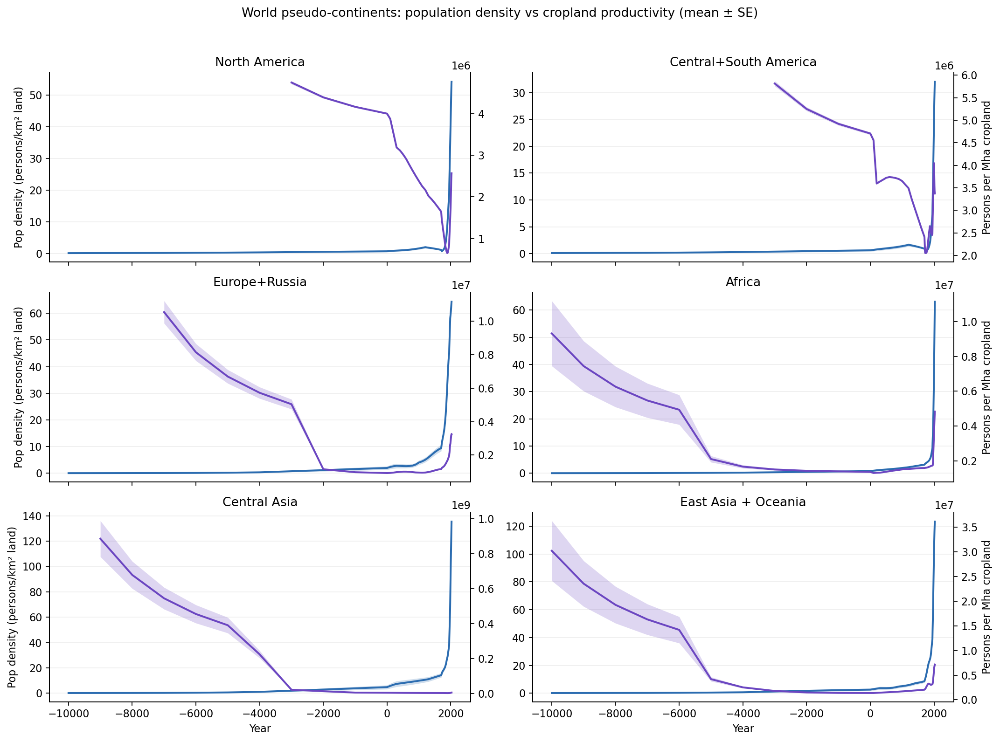

In [1]:
# hyde35_world_pseudocontinents_se.py
# HYDE 3.5: World pseudo-continents + population density + CH4/CO2 land-use proxies
# + cropland "productivity" (persons per Mha cropland)
# + intensification (people per hectare on CO2/CH4 proxy lands)
# + standard errors (SE) across scenarios
# + automatic inhabited-area pruning
#
# Requested:
#   - Regions: North America; Central+South America; Europe+Russia; Africa; Central Asia;
#              East Asia (incl. Australia + New Zealand)
#   - Exclude uninhabitable/clearly unpopulated areas (done via land mask * "ever inhabited" mask from HYDE pop)
#   - Full sample span: START_YEAR=-10000, END_YEAR = last available year in HYDE NetCDF
#
# Plug-and-run:
#   cd into HYDE root directory (contains scenario folders like gbc2025_* and general_files/)
#   python hyde35_world_pseudocontinents_se.py
#
# Outputs:
#   - hyde35_world_region_year_by_scenario.csv
#   - hyde35_world_region_year_mean_std_se.csv
#   - hyde35_world_region_year_class_mean_std_se.csv
#
# Dependencies: numpy, pandas, xarray, matplotlib

from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ----------------------------
# User config
# ----------------------------
START_YEAR = -10000  # requested
# END_YEAR auto-detected from population.nc

# Population-based pruning:
# A cell is "inhabited" if max(population over time) >= POP_CELL_MIN_PERSONS
POP_CELL_MIN_PERSONS = 1.0

AUTO_SMOOTH_PLOTS = True

REGION_ORDER = [
    "North America",
    "Central+South America",
    "Europe+Russia",
    "Africa",
    "Central Asia",
    "East Asia + Oceania",
]

CLASS_CO2 = "CO₂ land-use proxy (non-rice cropland)"
CLASS_CH4 = "CH₄ biogenic proxy (rice + grazing/ruminants)"

BLUE = "#2b6cb0"
PURPLE = "#6b46c1"
SHADE_ALPHA = 0.22

plt.rcParams.update({"figure.dpi": 160})

# ----------------------------
# File discovery / scenario discovery
# ----------------------------
def _first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p.exists():
            return p
    return None

def find_general_file(root: Path, filename: str) -> Path:
    candidates = [
        root / "general_files" / "general_files" / filename,
        root / "general_files" / filename,
        root / filename,
    ]
    hit = _first_existing(candidates)
    if hit:
        return hit
    gf = root / "general_files"
    if gf.exists():
        hits = list(gf.rglob(filename))
        if hits:
            return hits[0]
    hits = list(root.rglob(filename))
    if hits:
        return hits[0]
    raise FileNotFoundError(f"Could not find '{filename}' under {root}.")

def discover_scenarios(root: Path) -> List[Tuple[str, Path]]:
    pop_files = sorted(root.glob("*/NetCDF/population.nc"))
    out: List[Tuple[str, Path]] = []
    for pop_nc in pop_files:
        scen_dir = pop_nc.parent.parent
        label = scen_dir.name
        m = re.search(r"(base|lower|upper)", label, flags=re.IGNORECASE)
        if m:
            label = m.group(1).lower()
        out.append((label, scen_dir))
    order = {"base": 0, "lower": 1, "upper": 2}
    out.sort(key=lambda t: (order.get(t[0], 99), t[0]))
    return out

# ----------------------------
# Lat/lon + grids
# ----------------------------
def ensure_latlon(ds: xr.Dataset) -> xr.Dataset:
    rename: Dict[str, str] = {}
    for name in list(ds.dims) + list(ds.coords):
        low = name.lower()
        if low in ("latitude", "nav_lat", "y") and "lat" not in ds.dims and "lat" not in ds.coords:
            rename[name] = "lat"
        if low in ("longitude", "nav_lon", "x") and "lon" not in ds.dims and "lon" not in ds.coords:
            rename[name] = "lon"
    if rename:
        ds = ds.rename(rename)
    if "lat" not in ds.coords:
        if "lat" in ds.dims:
            ds = ds.assign_coords(lat=ds["lat"])
        else:
            raise ValueError("Dataset missing lat.")
    if "lon" not in ds.coords:
        if "lon" in ds.dims:
            ds = ds.assign_coords(lon=ds["lon"])
        else:
            raise ValueError("Dataset missing lon.")
    return ds

def read_esri_ascii_grid(path: Path) -> xr.DataArray:
    header: Dict[str, float] = {}
    with Path(path).open("r", encoding="utf-8", errors="ignore") as f:
        for _ in range(6):
            line = f.readline()
            k, v = line.strip().split()[:2]
            header[k.lower()] = float(v) if ("." in v or "e" in v.lower()) else int(v)
        data = np.loadtxt(f)

    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    cell = float(header["cellsize"])
    if data.shape != (nrows, ncols):
        raise ValueError(f"{path}: header says ({nrows},{ncols}) but data is {data.shape}")

    if "xllcorner" in header:
        xll = float(header["xllcorner"])
    elif "xllcenter" in header:
        xll = float(header["xllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing xllcorner/xllcenter")

    if "yllcorner" in header:
        yll = float(header["yllcorner"])
    elif "yllcenter" in header:
        yll = float(header["yllcenter"]) - cell / 2
    else:
        raise ValueError(f"{path} missing yllcorner/yllcenter")

    nodata = header.get("nodata_value", None)

    lon = xll + cell * (0.5 + np.arange(ncols))
    lat = yll + cell * (nrows - 0.5 - np.arange(nrows))  # north->south
    da = xr.DataArray(data, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name=Path(path).stem)
    if nodata is not None:
        da = da.where(da != nodata)
    return da

def _lon_to_180_vals(lon_vals: np.ndarray) -> np.ndarray:
    lon_vals = np.asarray(lon_vals, dtype=float)
    return (((lon_vals + 180.0) % 360.0) - 180.0)

def normalize_longitudes_to_match(da: xr.DataArray, target_lon: xr.DataArray) -> xr.DataArray:
    da = da.copy()
    lon_da = da["lon"].values
    lon_t = target_lon.values
    tmin = float(np.nanmin(lon_t))
    if tmin >= 0 and np.nanmin(lon_da) < 0:
        da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon")
    if tmin < 0 and np.nanmin(lon_da) >= 0:
        da = da.assign_coords(lon=_lon_to_180_vals(da["lon"].values)).sortby("lon")
    return da

def align_grid_to_dataset(da: xr.DataArray, ds_template: xr.Dataset) -> xr.DataArray:
    da2 = normalize_longitudes_to_match(da, ds_template["lon"])
    return da2.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")

def load_cell_area_km2(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    p = find_general_file(root, "garea_cr.asc")
    da = read_esri_ascii_grid(p)
    da = align_grid_to_dataset(da, ds_template)
    da.name = "cell_area_km2"
    return da

def load_land_mask_optional(root: Path, ds_template: xr.Dataset) -> xr.DataArray:
    try:
        p = find_general_file(root, "landlake.asc")
    except FileNotFoundError:
        p = None
    lat = ds_template["lat"].values
    lon = ds_template["lon"].values
    if p is None or not Path(p).exists():
        warnings.warn("landlake.asc not found. Treating all grid cells as land.")
        return xr.DataArray(np.ones((lat.size, lon.size), dtype=float), dims=("lat","lon"), coords={"lat": lat, "lon": lon}, name="land_mask")
    da = read_esri_ascii_grid(Path(p))
    da = align_grid_to_dataset(da, ds_template)
    lm = xr.where(da > 0, 1.0, 0.0).fillna(0.0)
    lm.name = "land_mask"
    if float(lm.mean().values) < 0.01:
        warnings.warn("Aligned land mask has <1% land; using all-land fallback.")
        lm = xr.ones_like(lm)
    return lm

# ----------------------------
# NetCDF open + year handling
# ----------------------------
def open_single_var_nc(path: Path) -> xr.DataArray:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    engines = [None, "netcdf4", "h5netcdf"]
    last_err = None
    for eng in engines:
        for use_chunks in (True, False):
            try:
                kw = dict(decode_times=time_coder, cache=False)
                if use_chunks:
                    kw["chunks"] = {"time": 1}
                ds = xr.open_dataset(path, engine=eng, **kw) if eng else xr.open_dataset(path, **kw)
                ds = ensure_latlon(ds)
                dvs = list(ds.data_vars)
                if not dvs:
                    raise ValueError(f"No data variables in {path}")
                if len(dvs) == 1:
                    return ds[dvs[0]]
                stem = Path(path).stem.lower()
                for v in dvs:
                    if stem in v.lower():
                        return ds[v]
                return ds[dvs[0]]
            except Exception as e:
                last_err = e
    raise OSError(f"Failed to open {path}. Last error: {last_err}")

def coerce_year_index(da: xr.DataArray) -> xr.DataArray:
    if "year" in da.coords:
        t = da["year"]
    elif "time" in da.coords:
        t = da["time"]
    else:
        raise ValueError("No 'time' or 'year' coordinate found.")
    try:
        years = t.dt.year.astype(int).values
    except Exception:
        vals = np.asarray(t.values)
        if vals.size and hasattr(vals.flat[0], "year"):
            years = np.array([v.year for v in vals.ravel()], dtype=int).reshape(vals.shape)
        else:
            years = np.rint(vals.astype(float)).astype(int)
    dim = t.dims[0] if t.dims else None
    if dim is None:
        da = da.assign_coords(year=years)
    else:
        da = da.assign_coords(year=(dim, years))
        if dim != "year" and np.unique(years).size == years.size:
            da = da.swap_dims({dim: "year"})
    return da

def subset_years(da: xr.DataArray, start_year: int, end_year: int) -> xr.DataArray:
    da = coerce_year_index(da)
    if "year" in da.dims:
        da = da.sortby("year")
        return da.sel(year=slice(start_year, end_year))
    mask = (da["year"] >= start_year) & (da["year"] <= end_year)
    return da.where(mask, drop=True)

def detect_end_year(pop_nc: Path) -> int:
    pop = open_single_var_nc(pop_nc)
    pop = coerce_year_index(pop)
    yrs = pop["year"].values
    yrs = np.asarray(yrs).astype(int)
    return int(np.nanmax(yrs))

# ----------------------------
# Inhabited mask (population-based pruning)
# ----------------------------
def build_inhabited_mask_from_population(population_nc: Path, ds_template: xr.Dataset, start_year: int, end_year: int) -> xr.DataArray:
    pop = open_single_var_nc(population_nc)
    pop = subset_years(pop, start_year, end_year)
    pop = coerce_year_index(pop)
    if "year" not in pop.dims:
        raise ValueError("Population has no year dimension after coercion.")
    popmax = pop.max(dim="year", skipna=True)
    inh = xr.where(popmax >= float(POP_CELL_MIN_PERSONS), 1.0, 0.0).fillna(0.0)
    inh = inh.reindex(lat=ds_template["lat"], lon=ds_template["lon"], method="nearest")
    inh.name = "inhabited_mask"
    return inh

# ----------------------------
# Region masks (pseudo-continents; then prune by land * inhabited)
# ----------------------------
def build_region_masks(ds_template: xr.Dataset, land_mask: xr.DataArray, inhabited_mask: xr.DataArray) -> xr.DataArray:
    lat = ds_template["lat"]
    lon = ds_template["lon"]

    lon180 = xr.DataArray(_lon_to_180_vals(lon.values), dims=("lon",), coords={"lon": lon.values})
    LON180, LAT = xr.broadcast(lon180, lat)
    LON180 = LON180.transpose("lat","lon")
    LAT = LAT.transpose("lat","lon")

    def in_box(lon_min, lon_max, lat_min, lat_max):
        return (LON180 >= lon_min) & (LON180 <= lon_max) & (LAT >= lat_min) & (LAT <= lat_max)

    # Base boxes (overlaps resolved by explicit exclusions)
    na = in_box(-170, -50, 15, 83)                     # North America
    csa = in_box(-120, -30, -60, 15)                   # Central+South America
    africa = in_box(-20, 55, -35, 37)                  # Africa
    central_asia = in_box(45, 90, 25, 55)              # Central Asia (Kazakhstan+stans)
    east_asia = in_box(90, 180, 0, 55)                 # East Asia (China/Korea/Japan/SEA)
    oceania = in_box(110, 180, -50, 0)                 # Australia+NZ broad
    spice = in_box(20, 105, 27, 48)                    # Spice corridor (Near East -> Central Asia)
    europe_russia = in_box(-25, 180, 35, 82)           # Europe+Russia broad

    # Exclusions to reduce double counting
    # Remove Americas from Europe+Russia obviously by lon, but already excluded.
    # Remove Africa from Europe+Russia by lat/lon overlap: use africa box.
    # Remove Central Asia and East Asia from Europe+Russia, since those are their own pseudo-continents.
    europe_russia = europe_russia & (~central_asia) & (~east_asia) & (~oceania) & (~spice)

    # Put spice into East Asia block (as requested earlier style): here "East Asia + Oceania" includes spice
    east_asia_oceania = (east_asia | oceania | spice)

    # Ensure Central Asia excludes spice corridor explicitly (so spice is not double counted)
    central_asia = central_asia & (~spice)

    # Make sure NA excludes CSA (boundary at 15N already does most of it; just in case)
    na = na & (~csa)

    # Finalize: land * inhabited
    def finalize(mask_bool):
        m = xr.where(mask_bool, 1.0, 0.0)
        return (m * land_mask * inhabited_mask).astype(float)

    masks = xr.concat(
        [
            finalize(na),
            finalize(csa),
            finalize(europe_russia),
            finalize(africa),
            finalize(central_asia),
            finalize(east_asia_oceania),
        ],
        dim="region"
    )
    masks = masks.assign_coords(region=("region", REGION_ORDER))
    masks.name = "region_masks"
    return masks

# ----------------------------
# Land-use conversions / aggregation
# ----------------------------
def _string_attr(da: xr.DataArray, key: str) -> str:
    return str(da.attrs.get(key, "")).strip().lower()

def _looks_like_fraction(da: xr.DataArray) -> bool:
    units = _string_attr(da, "units")
    long_name = _string_attr(da, "long_name") + " " + _string_attr(da, "standard_name")
    if ("frac" in units) or ("fraction" in units) or ("fraction" in long_name):
        return True
    if units in ("", "1", "-"):
        try:
            sample = da.isel(time=0) if "time" in da.dims else (da.isel(year=0) if "year" in da.dims else da)
            vmax = float(sample.max().values)
            vmin = float(sample.min().values)
            return (vmin >= -1e-6) and (vmax <= 1.5)
        except Exception:
            return False
    return False

def landuse_regional_mha(nc_path: Path, region_masks: xr.DataArray, cell_area_km2: xr.DataArray, start_year: int, end_year: int) -> Optional[xr.DataArray]:
    if not nc_path.exists():
        return None
    da = open_single_var_nc(nc_path)
    da = subset_years(da, start_year, end_year)

    units = _string_attr(da, "units")
    frac = _looks_like_fraction(da)

    if frac:
        da_mha = (da * cell_area_km2) / 1e4
    else:
        if "km" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e4
        elif units in ("ha", "hectare", "hectares"):
            da_mha = da / 1e6
        elif "m" in units and ("2" in units or "^2" in units):
            da_mha = da / 1e10
        else:
            da_mha = da / 1e4  # assume km2
    da_mha = da_mha.rename("area_mha")
    reg = (da_mha * region_masks).sum(dim=("lat","lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "Mha"
    return reg

def population_regional_persons(nc_path: Path, region_masks: xr.DataArray, start_year: int, end_year: int) -> xr.DataArray:
    da = open_single_var_nc(nc_path)
    da = subset_years(da, start_year, end_year)
    reg = (da * region_masks).sum(dim=("lat","lon"), skipna=True)
    reg = coerce_year_index(reg)
    reg.attrs["units"] = "persons"
    return reg

# ----------------------------
# Stats: n/mean/std/se robust
# ----------------------------
def _n_finite(s: pd.Series) -> int:
    return int(np.isfinite(s.to_numpy(dtype=float)).sum())

def _mean_nan(s: pd.Series) -> float:
    x = s.to_numpy(dtype=float)
    return float(np.nanmean(x)) if np.isfinite(x).any() else np.nan

def _std_nan_ddof0(s: pd.Series) -> float:
    x = s.to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.std(x, ddof=0)) if x.size else np.nan

def _se_from(s: pd.Series) -> float:
    x = s.to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return float(np.std(x, ddof=0) / np.sqrt(x.size))

# ----------------------------
# Optional smoothing (plot-only)
# ----------------------------
def smooth_for_plot(df: pd.DataFrame, ycols: List[str], year_col: str = "year") -> pd.DataFrame:
    if not AUTO_SMOOTH_PLOTS or df.empty:
        return df
    yrs = np.asarray(df[year_col].to_numpy(dtype=float))
    if yrs.size < 15:
        return df
    dy = np.diff(np.sort(np.unique(yrs)))
    dy = dy[np.isfinite(dy) & (dy > 0)]
    if dy.size == 0:
        return df
    step = float(np.median(dy))
    if step <= 5:
        win = 7
    elif step <= 10:
        win = 5
    elif step <= 25:
        win = 3
    else:
        return df
    out = df.sort_values(year_col).copy()
    for c in ycols:
        if c in out.columns:
            out[c] = out[c].rolling(window=win, center=True, min_periods=max(2, win//2)).mean()
    return out

# ----------------------------
# MAIN
# ----------------------------
ROOT = Path(".").resolve()
scenarios = discover_scenarios(ROOT)
if not scenarios:
    raise RuntimeError("No scenarios found (expected */NetCDF/population.nc). Run from HYDE root.")

print("Found scenarios:", ", ".join([f"{lab}:{p.name}" for lab, p in scenarios]))

template_label, template_dir = scenarios[0]
pop_nc_template = template_dir / "NetCDF" / "population.nc"
ds_template = ensure_latlon(xr.open_dataset(pop_nc_template))

END_YEAR = detect_end_year(pop_nc_template)
print(f"Using time span: {START_YEAR} to {END_YEAR}")

cell_area_km2 = load_cell_area_km2(ROOT, ds_template)
land_mask = load_land_mask_optional(ROOT, ds_template)
inhabited_mask = build_inhabited_mask_from_population(pop_nc_template, ds_template, START_YEAR, END_YEAR)
region_masks = build_region_masks(ds_template, land_mask, inhabited_mask)

land_area_reg_km2 = (cell_area_km2 * region_masks).sum(dim=("lat","lon"), skipna=True).astype(float)
print("\nLand area by pseudo-continent after inhabited pruning (km²):")
print(land_area_reg_km2.to_dataframe(name="land_area_km2").reset_index())

# Scenario-level collection
pop_rows, ag_rows, extra_rows = [], [], []

for scen_label, scen_dir in scenarios:
    print(f"Processing scenario: {scen_label} ({scen_dir.name})")

    # Population totals & density
    pop_reg = population_regional_persons(scen_dir / "NetCDF" / "population.nc", region_masks, START_YEAR, END_YEAR)

    land_area = land_area_reg_km2.rename("land_area_km2")
    dens = (pop_reg / xr.where(land_area > 0, land_area, np.nan)).rename("pop_density_p_km2")

    pop_df = pop_reg.to_dataframe(name="pop_total").reset_index()
    pop_df["scenario"] = scen_label
    dens_df = dens.to_dataframe(name="pop_density_p_km2").reset_index()
    dens_df["scenario"] = scen_label
    pop_rows.append(pop_df.merge(dens_df, on=["scenario","year","region"], how="left"))

    # Land-use components
    rice_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    rice_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (rice_rf is not None) or (rice_ir is not None):
        rice_reg = (0 if rice_rf is None else rice_rf.fillna(0)) + (0 if rice_ir is None else rice_ir.fillna(0))
    else:
        rice_reg = landuse_regional_mha(scen_dir / "NetCDF" / "total_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)

    grazing_reg = landuse_regional_mha(scen_dir / "NetCDF" / "grazing_land.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if grazing_reg is None:
        pasture_reg = landuse_regional_mha(scen_dir / "NetCDF" / "pasture.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        rangeland_reg = landuse_regional_mha(scen_dir / "NetCDF" / "rangeland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if (pasture_reg is not None) or (rangeland_reg is not None):
            grazing_reg = (0 if pasture_reg is None else pasture_reg.fillna(0)) + (0 if rangeland_reg is None else rangeland_reg.fillna(0))

    nr_rf = landuse_regional_mha(scen_dir / "NetCDF" / "rainfed_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    nr_ir = landuse_regional_mha(scen_dir / "NetCDF" / "irrigated_not_rice.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
    if (nr_rf is not None) or (nr_ir is not None):
        nonrice_reg = (0 if nr_rf is None else nr_rf.fillna(0)) + (0 if nr_ir is None else nr_ir.fillna(0))
    else:
        cropt = landuse_regional_mha(scen_dir / "NetCDF" / "cropland.nc", region_masks, cell_area_km2, START_YEAR, END_YEAR)
        if cropt is not None and rice_reg is not None:
            nonrice_reg = (cropt - rice_reg.fillna(0)).clip(min=0)
        elif cropt is not None:
            nonrice_reg = cropt
        else:
            nonrice_reg = None

    # Proxies
    ch4_reg = None
    if (rice_reg is not None) or (grazing_reg is not None):
        r = 0 if rice_reg is None else rice_reg.fillna(0)
        g = 0 if grazing_reg is None else grazing_reg.fillna(0)
        ch4_reg = r + g
        df = ch4_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CH4
        ag_rows.append(df[["scenario","year","region","class","area_mha"]])

    co2_reg = None
    if nonrice_reg is not None:
        co2_reg = nonrice_reg
        df = co2_reg.to_dataframe(name="area_mha").reset_index()
        df["scenario"] = scen_label
        df["class"] = CLASS_CO2
        ag_rows.append(df[["scenario","year","region","class","area_mha"]])

    # Total cropland (rice + non-rice)
    if (rice_reg is not None) or (nonrice_reg is not None):
        rr = 0 if rice_reg is None else rice_reg.fillna(0)
        nn = 0 if nonrice_reg is None else nonrice_reg.fillna(0)
        total_cropland_mha = (rr + nn).rename("total_cropland_mha")
    else:
        total_cropland_mha = None

    # Scenario derived panel
    P = pop_df[["scenario","year","region","pop_total"]].copy()

    if total_cropland_mha is not None:
        T = total_cropland_mha.to_dataframe(name="total_cropland_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario","year","region","total_cropland_mha"]], on=["scenario","year","region"], how="left")
    else:
        P["total_cropland_mha"] = np.nan

    if co2_reg is not None:
        T = co2_reg.to_dataframe(name="co2_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario","year","region","co2_mha"]], on=["scenario","year","region"], how="left")
    else:
        P["co2_mha"] = np.nan

    if ch4_reg is not None:
        T = ch4_reg.to_dataframe(name="ch4_mha").reset_index()
        T["scenario"] = scen_label
        P = P.merge(T[["scenario","year","region","ch4_mha"]], on=["scenario","year","region"], how="left")
    else:
        P["ch4_mha"] = np.nan

    # Metrics
    P["persons_per_mha_cropland"] = P["pop_total"] / P["total_cropland_mha"]              # persons/Mha
    P["co2_people_per_ha"] = P["pop_total"] / (P["co2_mha"] * 1e6)                         # persons/ha
    P["ch4_people_per_ha"] = P["pop_total"] / (P["ch4_mha"] * 1e6)                         # persons/ha

    extra_rows.append(P)

# Concat
pop_all = pd.concat(pop_rows, ignore_index=True)
ag_all = pd.concat(ag_rows, ignore_index=True) if ag_rows else pd.DataFrame(columns=["scenario","year","region","class","area_mha"])
extra_all = pd.concat(extra_rows, ignore_index=True)

# Stats with SE across scenarios
pop_stats = (
    pop_all.groupby(["year","region"], as_index=False)
    .agg(
        popdens_n=("pop_density_p_km2", _n_finite),
        popdens_mean=("pop_density_p_km2", _mean_nan),
        popdens_std=("pop_density_p_km2", _std_nan_ddof0),
        popdens_se=("pop_density_p_km2", _se_from),
        pop_total_n=("pop_total", _n_finite),
        pop_total_mean=("pop_total", _mean_nan),
        pop_total_std=("pop_total", _std_nan_ddof0),
        pop_total_se=("pop_total", _se_from),
    )
)

ag_stats = (
    ag_all.groupby(["year","region","class"], as_index=False)
    .agg(
        area_mha_n=("area_mha", _n_finite),
        area_mha_mean=("area_mha", _mean_nan),
        area_mha_std=("area_mha", _std_nan_ddof0),
        area_mha_se=("area_mha", _se_from),
    )
)

extra_stats = (
    extra_all.groupby(["year","region"], as_index=False)
    .agg(
        persons_per_mha_cropland_n=("persons_per_mha_cropland", _n_finite),
        persons_per_mha_cropland_mean=("persons_per_mha_cropland", _mean_nan),
        persons_per_mha_cropland_std=("persons_per_mha_cropland", _std_nan_ddof0),
        persons_per_mha_cropland_se=("persons_per_mha_cropland", _se_from),

        co2_people_per_ha_n=("co2_people_per_ha", _n_finite),
        co2_people_per_ha_mean=("co2_people_per_ha", _mean_nan),
        co2_people_per_ha_std=("co2_people_per_ha", _std_nan_ddof0),
        co2_people_per_ha_se=("co2_people_per_ha", _se_from),

        ch4_people_per_ha_n=("ch4_people_per_ha", _n_finite),
        ch4_people_per_ha_mean=("ch4_people_per_ha", _mean_nan),
        ch4_people_per_ha_std=("ch4_people_per_ha", _std_nan_ddof0),
        ch4_people_per_ha_se=("ch4_people_per_ha", _se_from),
    )
)

# ----------------------------
# Save CSVs
# ----------------------------
panel_scenario = pop_all.merge(extra_all, on=["scenario","year","region","pop_total"], how="left")
panel_scenario.to_csv("hyde35_world_region_year_by_scenario.csv", index=False)

panel_mean = pop_stats.merge(extra_stats, on=["year","region"], how="left")
panel_mean.to_csv("hyde35_world_region_year_mean_std_se.csv", index=False)

ag_stats.to_csv("hyde35_world_region_year_class_mean_std_se.csv", index=False)

print("\nWrote:")
print("  hyde35_world_region_year_by_scenario.csv")
print("  hyde35_world_region_year_mean_std_se.csv")
print("  hyde35_world_region_year_class_mean_std_se.csv")

# ----------------------------
# Minimal sanity plot (optional): pop density + persons/Mha cropland
# ----------------------------
def plot_mean_se(ax, x, mean, se, color, label=None):
    ax.plot(x, mean, color=color, linewidth=1.8, label=label)
    ax.fill_between(x, mean - se, mean + se, color=color, alpha=SHADE_ALPHA, linewidth=0)

fig, axs = plt.subplots(3, 2, figsize=(13.5, 10), sharex=True)
axs = axs.ravel()

for i, region in enumerate(REGION_ORDER):
    ax = axs[i]
    ax2 = ax.twinx()
    d1 = pop_stats[pop_stats["region"] == region].sort_values("year")
    d2 = extra_stats[extra_stats["region"] == region].sort_values("year")

    d1p = smooth_for_plot(d1, ["popdens_mean","popdens_se"])
    d2p = smooth_for_plot(d2, ["persons_per_mha_cropland_mean","persons_per_mha_cropland_se"])

    ax.set_title(region)
    ax.grid(True, axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    if not d1p.empty:
        plot_mean_se(ax, d1p["year"].to_numpy(), d1p["popdens_mean"].to_numpy(float), d1p["popdens_se"].to_numpy(float), BLUE)
    if not d2p.empty:
        x = d2p["year"].to_numpy()
        y = d2p["persons_per_mha_cropland_mean"].to_numpy(float)
        se = d2p["persons_per_mha_cropland_se"].to_numpy(float)
        ax2.plot(x, y, color=PURPLE, linewidth=1.8)
        ax2.fill_between(x, y-se, y+se, color=PURPLE, alpha=SHADE_ALPHA, linewidth=0)

    if i % 2 == 0:
        ax.set_ylabel("Pop density (persons/km² land)")
    if i % 2 == 1:
        ax2.set_ylabel("Persons per Mha cropland")

axs[-2].set_xlabel("Year")
axs[-1].set_xlabel("Year")
fig.suptitle("World pseudo-continents: population density vs cropland productivity (mean ± SE)", y=0.99)
fig.tight_layout(rect=[0,0,1,0.97])
plt.show()

In [3]:
#!/usr/bin/env python3
from __future__ import annotations

"""
ERA5 downloader for HYDE35 yearly panel

Default mode: monthly means (small) -> writes:
  era5_sl_monthly_YYYYMM.nc

Optional mode: hourly (huge) -> writes:
  era5_sl_hourly_YYYYMM.nc

Requirements:
  pip install cdsapi
And a valid ~/.cdsapirc:
  url: https://cds.climate.copernicus.eu/api
  key: <YOUR_PERSONAL_ACCESS_TOKEN>
"""

import argparse
from pathlib import Path
import time
import cdsapi

DATASET_MONTHLY = "reanalysis-era5-single-levels-monthly-means"
DATASET_HOURLY  = "reanalysis-era5-single-levels"


def _retry_sleep(attempt: int) -> int:
    # Exponential backoff, capped at 15 minutes
    return min(900, 10 * (2 ** (attempt - 1)))


def download_monthly_means(
    outdir: Path,
    year_start: int,
    year_end: int,
    variables: list[str],
    area: list[float] | None,
    grid: list[float] | None,
    max_tries: int = 8,
):
    outdir.mkdir(parents=True, exist_ok=True)
    c = cdsapi.Client()

    for year in range(year_start, year_end + 1):
        for month in range(1, 13):
            target = outdir / f"era5_sl_monthly_{year:04d}{month:02d}.nc"
            if target.exists() and target.stat().st_size > 0:
                print(f"[skip] {target.name}")
                continue

            # Monthly means request pattern (product_type + time=00:00 is standard)
            req = {
                "product_type": "monthly_averaged_reanalysis",
                "variable": variables,
                "year": f"{year:04d}",
                "month": f"{month:02d}",
                "time": "00:00",
                "format": "netcdf",
            }
            if area is not None:
                req["area"] = area  # [N, W, S, E]
            if grid is not None:
                req["grid"] = grid  # [lat, lon] degrees, e.g. [1.0, 1.0]

            for attempt in range(1, max_tries + 1):
                try:
                    print(f"[get] {DATASET_MONTHLY} {year:04d}-{month:02d} -> {target}")
                    c.retrieve(DATASET_MONTHLY, req, str(target))
                    if target.exists() and target.stat().st_size > 0:
                        print(f"[ok]  {target.name} ({target.stat().st_size/1e6:.1f} MB)")
                        break
                    raise RuntimeError("Downloaded file missing/empty")
                except Exception as e:
                    if attempt == max_tries:
                        raise
                    wait = _retry_sleep(attempt)
                    print(f"[err] attempt {attempt}/{max_tries}: {e}")
                    print(f"      sleeping {wait}s")
                    time.sleep(wait)


def download_hourly_by_month(
    outdir: Path,
    year_start: int,
    year_end: int,
    variables: list[str],
    area: list[float] | None,
    grid: list[float] | None,
    max_tries: int = 8,
):
    # Hourly is enormous. Only use if you truly need extremes/threshold counts.
    outdir.mkdir(parents=True, exist_ok=True)
    c = cdsapi.Client()
    times = [f"{h:02d}:00" for h in range(24)]
    days  = [f"{d:02d}" for d in range(1, 32)]  # CDS ignores invalid dates per month

    for year in range(year_start, year_end + 1):
        for month in range(1, 13):
            target = outdir / f"era5_sl_hourly_{year:04d}{month:02d}.nc"
            if target.exists() and target.stat().st_size > 0:
                print(f"[skip] {target.name}")
                continue

            req = {
                "product_type": "reanalysis",
                "variable": variables,
                "year": f"{year:04d}",
                "month": f"{month:02d}",
                "day": days,
                "time": times,
                "data_format": "netcdf",
                "download_format": "unarchived",
            }
            if area is not None:
                req["area"] = area
            if grid is not None:
                req["grid"] = grid

            for attempt in range(1, max_tries + 1):
                try:
                    print(f"[get] {DATASET_HOURLY} {year:04d}-{month:02d} -> {target}")
                    r = c.retrieve(DATASET_HOURLY, req)
                    # Some cdsapi versions want r.download(); others accept target in retrieve()
                    try:
                        r.download(str(target))
                    except Exception:
                        c.retrieve(DATASET_HOURLY, req, str(target))
                    if target.exists() and target.stat().st_size > 0:
                        print(f"[ok]  {target.name} ({target.stat().st_size/1e6:.1f} MB)")
                        break
                    raise RuntimeError("Downloaded file missing/empty")
                except Exception as e:
                    if attempt == max_tries:
                        raise
                    wait = _retry_sleep(attempt)
                    print(f"[err] attempt {attempt}/{max_tries}: {e}")
                    print(f"      sleeping {wait}s")
                    time.sleep(wait)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--outdir", required=True)
    ap.add_argument("--year-start", type=int, required=True)
    ap.add_argument("--year-end", type=int, required=True)
    ap.add_argument("--mode", choices=["monthly_means", "hourly"], default="monthly_means")
    ap.add_argument(
        "--vars",
        nargs="+",
        default=["2m_temperature", "total_precipitation"],
        help="CDS variable names (not NetCDF short names).",
    )
    ap.add_argument("--area", nargs=4, type=float, default=None, help="N W S E bounding box")
    ap.add_argument("--grid", nargs=2, type=float, default=None, help="lat lon resolution (deg)")
    args = ap.parse_args()

    outdir = Path(args.outdir).expanduser()
    if args.mode == "monthly_means":
        download_monthly_means(outdir, args.year_start, args.year_end, args.vars, args.area, args.grid)
    else:
        download_hourly_by_month(outdir, args.year_start, args.year_end, args.vars, args.area, args.grid)


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] --outdir OUTDIR --year-start YEAR_START
                             --year-end YEAR_END
                             [--mode {monthly_means,hourly}]
                             [--vars VARS [VARS ...]]
                             [--area AREA AREA AREA AREA] [--grid GRID GRID]
ipykernel_launcher.py: error: the following arguments are required: --outdir, --year-start, --year-end


SystemExit: 2

In [ ]:
# download_era5_monthly_means_incode.py

from pathlib import Path
import time
import cdsapi

# -----------------------------
# USER SETTINGS (edit these)
# -----------------------------
OUTDIR = Path("./ERA5")   # will create if missing
YEAR_START = 1950
YEAR_END   = 1951

# CDS variable names (not NetCDF short names)
VARS = [
    "2m_temperature",
    "total_precipitation",
    # add more if you want:
    # "sea_surface_temperature",
    # "soil_temperature_level_1",
    # "clear_sky_direct_solar_radiation_at_surface",
]

# Optional spatial restriction to cut size:
# area = [North, West, South, East]
AREA = None
# AREA = [75, -170, 10, -50]

# Optional regridding (degrees). Example 1°:
GRID = None
# GRID = [1.0, 1.0]

MAX_TRIES = 8

# -----------------------------
# INTERNALS
# -----------------------------
DATASET_MONTHLY = "reanalysis-era5-single-levels-monthly-means"


def backoff_seconds(attempt: int) -> int:
    return min(900, 10 * (2 ** (attempt - 1)))  # cap at 15 min


def download_one_month(client: cdsapi.Client, year: int, month: int) -> None:
    OUTDIR.mkdir(parents=True, exist_ok=True)
    target = OUTDIR / f"era5_sl_monthly_{year:04d}{month:02d}.nc"

    if target.exists() and target.stat().st_size > 0:
        print(f"[skip] {target.name}")
        return

    req = {
        "product_type": "monthly_averaged_reanalysis",
        "variable": VARS,
        "year": f"{year:04d}",
        "month": f"{month:02d}",
        "time": "00:00",
        "format": "netcdf",
    }
    if AREA is not None:
        req["area"] = AREA
    if GRID is not None:
        req["grid"] = GRID

    for attempt in range(1, MAX_TRIES + 1):
        try:
            print(f"[get] {year:04d}-{month:02d} -> {target}")
            client.retrieve(DATASET_MONTHLY, req, str(target))

            if not (target.exists() and target.stat().st_size > 0):
                raise RuntimeError("Downloaded file missing/empty")

            print(f"[ok]  {target.name} ({target.stat().st_size/1e6:.1f} MB)")
            return
        except Exception as e:
            if attempt == MAX_TRIES:
                raise
            wait = backoff_seconds(attempt)
            print(f"[err] attempt {attempt}/{MAX_TRIES}: {e}")
            print(f"      sleeping {wait}s")
            time.sleep(wait)


def main():
    # Requires ~/.cdsapirc:
    # url: https://cds.climate.copernicus.eu/api
    # key: <YOUR_PERSONAL_ACCESS_TOKEN>
    client = cdsapi.Client()

    for y in range(YEAR_START, YEAR_END + 1):
        for m in range(1, 13):
            download_one_month(client, y, m)


if __name__ == "__main__":
    main()

[get] 1950-01 -> ERA5/era5_sl_monthly_195001.nc


2026-02-21 12:58:39,629 INFO Request ID is 5fa7e688-f8e3-4b09-9c23-19fff4510bec
2026-02-21 12:58:39,829 INFO status has been updated to accepted
